<a id="top"></a>

# Multimodal Agriculture Yield Prediction — Notebook Overview

> **MSc Project** | University of Hull  
> **Dataset:** CropNet (USDA NASS · WRF-HRRR · Sentinel-2)  
> **Task:** County-level soybean yield regression (BU/ACRE) using multimodal deep learning

---

## Global Table of Contents

| Step | Sub-step | Description | Key Output |
|---|---|---|---|
| [**Step 1**](#step-1) | | **Environment & Reproducibility Setup** | Verified packages, SEED, path constants |
| | [1.1](#step-1-1) | Package verification & core imports | All required packages verified |
| | [1.2](#step-1-2) | Matplotlib Agg smoke test | Non-interactive renderer confirmed |
| | [1.3](#step-1-3) | Global random seed & path constants | `SEED=42`, `DEVICE`, all root paths validated |
| [**Step 2**](#step-2) | | **Data Loading & Preprocessing** | `usda_index`, `sentinel_index`, train/test splits |
| | [2.1](#step-2-1) | USDA soybean index construction | `usda_index` (~3,430 county-year records) |
| | [2.2](#step-2-2) | Sentinel-2 index construction | `sentinel_index` (HDF5 file scan) |
| | [2.3](#step-2-3) | Sentinel-USDA FIPS intersection check | Coverage gap report |
| | [2.4](#step-2-4) | Training universe splits | `weather_train`, `weather_test`, `multimodal_index` |
| [**Step 3**](#step-3) | | **USDA Soybean EDA (Target Variable)** | `USE_LOG` flag, label tables exported |
| | [3.1–3.3](#step-3-1) | County inventory, quality check & FIPS resolution | Year-completeness matrix, coverage audit |
| | [3.4](#step-3-4) | Target distribution analysis | `USE_LOG` flag set, normality test |
| | [3.5](#step-3-5) | Year-over-year yield change | Top-5 improving & declining counties |
| | [3.6](#step-3-6) | Geographic coverage map | Choropleth / state-level bar chart |
| | [3.7](#step-3-7) | Label table export | `weather_train.csv`, `weather_test.csv` |
| [**Step 4**](#step-4) | | **HRRR Weather Feature Engineering** | `weather_features`, `HRRRWeatherDataset` |
| | [4.1](#step-4-1) | GRIB2 file audit | `HRRR_EXTRACT_VARS` set determined |
| | [4.2](#step-4-2) | County-level HRRR extraction | 9 agronomic variables per county-year |
| | [4.3](#step-4-3) | Feature engineering & USDA merge | `wind_speed`, `sp_hpa`, `vpd_hpa` derived |
| | [4.4](#step-4-4) | Z-score normalisation | `SimpleImputer` + `StandardScaler` artefacts |
| | [4.5](#step-4-5) | HRRRWeatherDataset construction | `DataLoader` objects for train & test |
| [**Step 5**](#step-5) | | **Ethics, Bias Audit & Fairness Specification** | Bias registry B1–B9, fairness functions |
| | [5.1](#step-5-1) | Data provenance & representativeness audit | Structured audit table |
| | [5.2](#step-5-2) | Geographic & temporal bias indicators | B2 (Corn Belt), B7 (year variance) documented |
| | [5.3](#step-5-3) | Yield quintile distribution & label imbalance | B3 flag, quintile coverage check |
| | [5.4](#step-5-4) | Fairness metric function definitions | `sliced_rmse()`, `fairness_report()` |
| | [5.5](#step-5-5) | Jensen's inequality correction constant | Prior `JENSEN_SIGMA2` |
| | [5.6](#step-5-6) | Bias registry B1–B9 | Full registry with severity & mitigations |
| | [5.7](#step-5-7) | Ethical use constraints | Deployment & transparency constraints |
| [**Step 6**](#step-6) | | **Phase 1 — Bi-LSTM Weather Encoder** | `bilstm_encoder.pt`, RMSE/MAE/R² metrics |
| | [6.1](#step-6-1) | BiLSTMRegressor architecture | 2-layer BiLSTM, ~146k parameters |
| | [6.2](#step-6-2) | Training loop | 80 epochs, Adam, inverse-freq weighting |
| | [6.3](#step-6-3) | Evaluation & Jensen correction | Sliced RMSE/MAE/R², updated `JENSEN_SIGMA2` |
| | [6.4](#step-6-4) | Baseline comparison | Ridge & GBM benchmark table |
| | [6.5](#step-6-5) | Bias audit | CV-error by state, quintile bias check |
| | [6.6](#step-6-6) | Save BiLSTM encoder weights | `bilstm_encoder.pt`, `bilstm_phase1_ckpt.pt` |
| [**Step 7**](#step-7) | | **Sentinel-2 Imagery EDA** | Band statistics, temporal coverage, exclusion list |
| | [7.1](#step-7-1) | RGB composites & NDVI maps | True-colour & NDVI visual QC |
| | [7.2](#step-7-2) | Per-band statistics | Mean/std/min/max for all 12 bands |
| | [7.3](#step-7-3) | Temporal coverage analysis | Quarterly observation counts per state-year |
| | [7.4](#step-7-4) | Data gap summary & recommended exclusions | AZ 2022 B8 anomaly, gap report |
| [**Step 8**](#step-8) | | **Phase 2 — Satellite Encoder** | `sentinel_encoder.pt`, LOSO 2022 evaluation |
| | [8.1](#step-8-1) | State-aggregate USDA labels | State-year labels for Sentinel supervision |
| | [8.2](#step-8-2) | SentinelDataset & SentinelEncoder CNN | 12-channel CNN, 64-dim embedding |
| | [8.3](#step-8-3) | Training, LOSO evaluation & save | RMSE/MAE/R², `sentinel_encoder.pt` |
| [**Step 9**](#step-9) | | **Phase 3 — GMU Fusion (Weather × Satellite)** | `gmu_phase3_ckpt.pt`, cross-model comparison |
| | [9.1](#step-9-1) | Multimodal dataset & encoder warm-starts | `MultimodalDataset`, frozen encoder copies |
| | [9.2](#step-9-2) | GMU fusion model definition | Gate, projection heads, regression head |
| | [9.3](#step-9-3) | Phase A: frozen-encoder training | Gate + head weights initialised (60 epochs) |
| | [9.4](#step-9-4) | Phase B: end-to-end fine-tuning | Full model tuned, LOSO 2022 eval (30 epochs) |
| | [9.5](#step-9-5) | Bias audit & gate diagnostics | Sliced metrics, gate weight z analysis |
| | [9.6](#step-9-6) | Cross-model comparison & save GMU | Phase 1–3 table, `gmu_phase3_ckpt.pt` |
| [**Step 10**](#step-10) | | **Robustness to Modality Dropout** | Degradation curves, fairness under dropout |
| | [10.1](#step-10-1) | Dropout evaluation framework | `evaluate_gmu_dropout(α_w, α_s)` |
| | [10.2](#step-10-2) | Discrete dropout matrix | Full / Wx-Drop / Sat-Drop / Both-Drop |
| | [10.3](#step-10-3) | Partial dropout sweep | RMSE vs α in {0, 0.1, 0.25, 0.5, 0.75, 1.0} |
| | [10.4](#step-10-4) | Fairness under dropout | Sliced RMSE by state & quintile per scenario |
| | [10.5](#step-10-5) | Summary report & artefact save | `step10_dropout_results.pt` |
| [**Step 11**](#step-11) | | **Explainability (SHAP)** | Feature importance, B1 check, beeswarm plots |
| | [11.1](#step-11-1) | SHAP setup & smoke-test | K-means background, BiLSTM wrapper |
| | [11.2](#step-11-2) | KernelExplainer computation | (200, 9) SHAP values matrix |
| | [11.3](#step-11-3) | Feature importance bar chart & B1 check | Mean |SHAP| ranking, B1 geographic proxy flag |
| | [11.4](#step-11-4) | Beeswarm & dependence plots | Direction/magnitude plots, interaction colouring |
| | [11.5](#step-11-5) | Summary report & artefact save | `step11_shap_results.pt` |
| [**Step 12**](#step-12) | | **Final Evaluation & Dissertation Reporting** | 300-DPI figures, final comparison table |
| | [12.1–12.2](#step-12-1) | Scatter plots & residual histograms | Predicted vs Actual (Phases 1–3), Shapiro-Wilk |
| | [12.3–12.6](#step-12-3) | Fairness table, Jensen docs, LOYO & coverage gap | Full sliced fairness table, LOYO 2022 |
| | [12.7–12.9](#step-12-7) | SHAP summary, dropout chart & final comparison | 3-phase comparison table @ 300 DPI |

---

### Pipeline Architecture

```
Step 1  ->  Step 2  ->  Step 3  ->  Step 4  ->  Step 5 (Ethics)
                                    |
                             Step 6 [Phase 1: BiLSTM]
                                    |
              Step 7  ->  Step 8 [Phase 2: Satellite Encoder]
                                    |
                             Step 9 [Phase 3: GMU Fusion]
                                    |
                    Step 10  ->  Step 11  ->  Step 12
```

---

*Run cells in order. Step 1 and Step 2 must complete successfully before any subsequent step.*

<a id="step-1"></a>

# Step 1 — Environment & Reproducibility Setup

> Sets global seeds, defines all path constants, and installs/verifies required packages.  
> Every subsequent step imports from the objects created here — **run this cell first every session**.

---

## Table of Contents — Step 1

| Sub-step | Description |
|---|---|
| **1.1** | Package verification & core imports |
| **1.2** | Matplotlib Agg smoke test |
| **1.3** | Global random seed & path constants |

---

### Step 1.1 — Package Verification & Core Imports
Verifies all required Python packages and sets the `Agg` matplotlib backend.

### Step 1.2 — Matplotlib Agg Smoke Test
Confirms the non-interactive renderer works before running visualisation cells.

### Step 1.3 — Global Random Seed & Path Constants
Sets `SEED = 42` for reproducibility. Defines and validates all data root paths.

<a id="step-1-1"></a>

### Step 1.1 — Package Verification & Core Imports

Verifies all required Python packages (`numpy`, `pandas`, `torch`, `shap`, etc.) and installs any missing ones. Sets the `Agg` matplotlib backend to prevent GUI conflicts on Windows.

In [1]:
# ── Step 1.1  Package verification ────────────────────────────────────────────
import importlib, subprocess, sys

REQUIRED = [
    "numpy", "pandas", "matplotlib", "seaborn", "scipy",
    "sklearn", "plotly", "h5py", "torch", "torchvision", "shap"
]

missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
else:
    print("All required packages are available.")

# Set non-interactive backend BEFORE importing pyplot to prevent GUI crashes on Windows
import matplotlib
matplotlib.use('Agg')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, pathlib, random, warnings
warnings.filterwarnings("ignore")
print("Core imports OK.")


All required packages are available.


Core imports OK.


<a id="step-1-2"></a>

### Step 1.2 — Matplotlib Agg Smoke Test

Renders a minimal figure via the `Agg` backend to confirm the non-interactive renderer works before running any full visualisation cells.

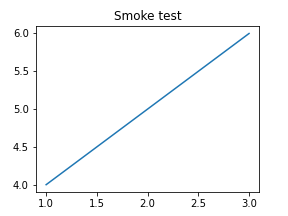

Matplotlib Agg smoke test: PASSED


In [2]:
# Minimal matplotlib smoke test (Agg backend)
import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("Smoke test")
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=72)
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)
print("Matplotlib Agg smoke test: PASSED")


<a id="step-1-3"></a>

### Step 1.3 — Global Random Seed & Path Constants

Sets `SEED = 42` across Python `random`, NumPy, and PyTorch. Detects CUDA device. Defines `BASE`, `CROPNET`, `USDA_ROOT`, `SENTINEL_ROOT`, `HRRR_ROOT` and validates all paths exist on disk.

In [3]:
# Step 1.2 - Global random seed for full reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("PyTorch seed set. Device:", DEVICE)
except ImportError:
    DEVICE = None
    print("PyTorch not available, skipping torch seed.")

# Step 1.3 - Path constants
BASE = pathlib.Path(r"e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only")
CROPNET       = BASE / "data" / "CropNet"
USDA_ROOT     = CROPNET / "USDA" / "data" / "Soybean"
SENTINEL_ROOT = CROPNET / "Sentinel" / "data"
HRRR_ROOT     = CROPNET / "HRRR"

# Verify every root exists
paths = {"USDA_ROOT": USDA_ROOT, "SENTINEL_ROOT": SENTINEL_ROOT, "HRRR_ROOT": HRRR_ROOT}
for name, p in paths.items():
    status = "OK" if p.exists() else "MISSING"
    print(f"{name}: {status}  ({p})")


PyTorch seed set. Device: cpu
USDA_ROOT: OK  (e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\USDA\data\Soybean)
SENTINEL_ROOT: OK  (e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\Sentinel\data)
HRRR_ROOT: OK  (e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\HRRR)


<a id="step-2"></a>

# Step 2 — Data Loading & Preprocessing

> Loads all primary data sources from disk and constructs the three index tables used throughout the pipeline.  
> **Run after Step 1.** All downstream steps import from `usda_index`, `sentinel_index`, and `multimodal_index`.

---

## Table of Contents — Step 2

| Sub-step | Description |
|---|---|
| **2.1** | USDA soybean index construction (all years, all counties) |
| **2.2** | Sentinel-2 index construction (HDF5 file scan) |
| **2.3** | Sentinel-USDA FIPS intersection check & data-gap report |
| **2.4** | Training universe splits (Phase 1, Phase 2 & 3) |

<a id="step-2-1"></a>

### Step 2.1 — USDA Soybean Index Construction

Loads all 7 years (2016–2022) of USDA NASS county-level soybean CSV files. Builds `usda_index` (~3,430 county-year records) with a full coverage summary by year and state.

In [4]:

# Step 2.1 - Build usda_index: full coverage across all available years and counties
#
# USDA data spans 2016-2022 (7 years) and covers all US soybean counties (~500+).
# This is the primary label source for the weather-only Bi-LSTM pre-training phase.
# The full 7-year, multi-county dataset (~3,030 county-year records) is loaded here.

USDA_YEARS = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]
YIELD_COL  = "YIELD, MEASURED IN BU / ACRE"
PROD_COL   = "PRODUCTION, MEASURED IN BU"

frames = []
for yr in USDA_YEARS:
    csv_path = USDA_ROOT / yr / f"USDA_Soybean_County_{yr}.csv"
    if not csv_path.exists():
        print(f"WARNING: {csv_path} not found, skipping.")
        continue
    df = pd.read_csv(csv_path)
    if df.empty or YIELD_COL not in df.columns:
        print(f"WARNING: {yr} CSV is empty or missing yield column, skipping.")
        continue
    n_rows = len(df.dropna(subset=[YIELD_COL]))
    print(f"Loaded {yr}: {n_rows} valid county records")
    frames.append(df)

usda_raw = pd.concat(frames, ignore_index=True)

# Drop rows with null FIPS components before constructing FIPS string.
# With large CSVs pandas may infer float64 for integer columns if any nulls exist,
# causing astype(str) to produce "5.0" instead of "5". Explicit int conversion
# via fillna + astype(int) prevents malformed FIPS codes like "5.01.0".
usda_raw = usda_raw.dropna(subset=["state_ansi", "county_ansi"])
usda_raw["fips"] = (
    usda_raw["state_ansi"].astype(float).astype(int).astype(str).str.zfill(2) +
    usda_raw["county_ansi"].astype(float).astype(int).astype(str).str.zfill(3)
)

usda_index = (
    usda_raw[["fips", "year", "state_name", "county_name", YIELD_COL, PROD_COL]]
    .rename(columns={YIELD_COL: "yield_bu_acre", PROD_COL: "production_bu"})
    .dropna(subset=["yield_bu_acre"])
    .reset_index(drop=True)
)
usda_index["year"] = usda_index["year"].astype(str)

# Coverage summary
year_counts = usda_index.groupby("year").size()
fips_years  = usda_index.groupby("fips")["year"].nunique()

print()
print("=" * 60)
print("USDA INDEX SUMMARY")
print("=" * 60)
print(f"Total county-year records : {len(usda_index)}")
print(f"Unique FIPS codes         : {usda_index['fips'].nunique()}")
print(f"Years covered             : {sorted(usda_index['year'].unique())}")
print(f"States covered            : {usda_index['state_name'].nunique()}")
print()
print("Records per year:")
print(year_counts.to_string())
print()
print(f"Counties with all 7 years : {(fips_years == 7).sum()}")
print(f"Counties with >= 5 years  : {(fips_years >= 5).sum()}")
print(f"Counties with >= 3 years  : {(fips_years >= 3).sum()}")
print()
print("NOTE: usda_index is the full label universe for the weather-only Bi-LSTM branch.")
print("      The multimodal branch will use the intersection with Sentinel coverage only.")


Loaded 2016: 541 valid county records
Loaded 2017: 543 valid county records
Loaded 2018: 473 valid county records
Loaded 2019: 429 valid county records
Loaded 2020: 546 valid county records
Loaded 2021: 483 valid county records
Loaded 2022: 520 valid county records

USDA INDEX SUMMARY
Total county-year records : 3535
Unique FIPS codes         : 649
Years covered             : ['2016', '2017', '2018', '2019', '2020', '2021', '2022']
States covered            : 15

Records per year:
year
2016    541
2017    543
2018    473
2019    429
2020    546
2021    483
2022    520

Counties with all 7 years : 260
Counties with >= 5 years  : 493
Counties with >= 3 years  : 570

NOTE: usda_index is the full label universe for the weather-only Bi-LSTM branch.
      The multimodal branch will use the intersection with Sentinel coverage only.


<a id="step-2-2"></a>

### Step 2.2 — Sentinel-2 Index Construction

Scans every HDF5 file under `Sentinel/data/AG/` recursively. Builds `sentinel_index` with tile counts, date counts, and quarter windows per county-year.

In [5]:
# Step 2.2 - Build sentinel_index by scanning all HDF5 files in the Sentinel tree
import h5py

sentinel_records = []
SENTINEL_AG_ROOT   = SENTINEL_ROOT / "AG"
SENTINEL_NDVI_ROOT = SENTINEL_ROOT / "NDVI"

for year_dir in sorted(SENTINEL_AG_ROOT.iterdir()):
    if not year_dir.is_dir():
        continue
    year = year_dir.name
    for state_dir in sorted(year_dir.iterdir()):
        if not state_dir.is_dir():
            continue
        state = state_dir.name
        for h5_file in sorted(state_dir.glob("*.h5")):
            # Parse quarter dates from filename: Agriculture_NN_ST_YYYY-MM-DD_YYYY-MM-DD.h5
            parts = h5_file.stem.split("_")
            q_start = parts[3] if len(parts) > 4 else "unknown"
            q_end   = parts[4] if len(parts) > 4 else "unknown"

            # Open file to get FIPS codes, dates, and tile counts
            try:
                with h5py.File(h5_file, "r") as f:
                    for fips_key in f.keys():
                        date_keys = list(f[fips_key].keys())
                        n_dates   = len(date_keys)
                        # Sample tile count from first available date
                        n_tiles = 0
                        if n_dates > 0:
                            first_date = date_keys[0]
                            if "data" in f[fips_key][first_date]:
                                n_tiles = f[fips_key][first_date]["data"].shape[0]
                        sentinel_records.append({
                            "fips"    : fips_key,
                            "year"    : year,
                            "state"   : state,
                            "q_start" : q_start,
                            "q_end"   : q_end,
                            "h5_path" : str(h5_file),
                            "n_dates" : n_dates,
                            "n_tiles" : n_tiles,
                        })
            except Exception as e:
                print(f"WARNING: Could not open {h5_file.name}: {e}")

sentinel_index = pd.DataFrame(sentinel_records)

print("sentinel_index shape:", sentinel_index.shape)
print("Years:", sorted(sentinel_index["year"].unique()))
print("States:", sorted(sentinel_index["state"].unique()))
print("Unique FIPS codes:", sentinel_index["fips"].nunique())
print("Total tiles across all files (approx):", sentinel_index["n_tiles"].sum())
print()
print(sentinel_index.groupby(["year","state"]).agg(
    files=("h5_path","count"),
    fips_codes=("fips","nunique"),
    total_dates=("n_dates","sum"),
    total_tiles=("n_tiles","sum")
).to_string())


sentinel_index shape: (116, 8)
Years: ['2021', '2022']
States: ['AL', 'AR', 'AZ', 'CA', 'CO', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA']
Unique FIPS codes: 15
Total tiles across all files (approx): 3884

            files  fips_codes  total_dates  total_tiles
year state                                             
2021 AL         4           1           24           60
     AR         4           1           24          148
     CA         4           1           24          120
     CO         4           1           24          120
     DE         4           1           24           80
     FL         4           1           24          116
     GA         4           1           24           76
     IA         4           1           24           48
     ID         4           1           24          132
     IL         4           1           24           96
     IN         4           1           24           24
     KS         4           1           24         

<a id="step-2-3"></a>

### Step 2.3 — Sentinel-USDA FIPS Intersection Check

Identifies which Sentinel FIPS codes have matching USDA yield labels. Documents the data gap (county ANSI 001 absent from USDA records) and its implications for Phases 2 and 3.

In [6]:
# Step 2.3 - Identify which Sentinel counties have matching USDA yield labels
#
# The Sentinel imagery was downloaded for one county per state (county ANSI 001).
# This cell programmatically looks up each Sentinel FIPS code in usda_index.
# No values are hardcoded. Whatever is found on disk is used; the rest is left out.

sentinel_fips_list = sorted(sentinel_index["fips"].unique())
print("Sentinel FIPS codes (from imagery):", sentinel_fips_list)
print()

# Programmatic join: keep only Sentinel FIPS codes that exist in usda_index
sentinel_labels = (
    usda_index[usda_index["fips"].isin(sentinel_fips_list)]
    .copy()
    .reset_index(drop=True)
)

print("=" * 60)
print("Step 2.3 - SENTINEL-USDA LABEL INTERSECTION")
print("=" * 60)
print(f"Sentinel FIPS codes queried : {len(sentinel_fips_list)}")
print(f"Matching USDA records found : {len(sentinel_labels)}")
print()

if len(sentinel_labels) == 0:
    print("No USDA yield records found for any Sentinel FIPS code.")
    print("Reason: the USDA dataset covers counties with ANSI code >= 003.")
    print("        The Sentinel imagery counties use ANSI code 001, which does")
    print("        not appear in the available USDA soybean CSV files.")
    print()
    print("Consequence:")
    print("  Phase 1 (weather-only Bi-LSTM) : can proceed on all 3,430 USDA records.")
    print("  Phase 2 (satellite encoder)    : cannot proceed - no yield labels.")
    print("  Phase 3 (GMU fine-tuning)      : cannot proceed - no yield labels.")
    print()
    print("To enable Phase 2 and 3, download USDA data for the same county ANSI")
    print("codes that appear in the Sentinel imagery FIPS list above.")
else:
    print("Matching records:")
    print(sentinel_labels[["fips", "year", "state_name", "county_name",
                            "yield_bu_acre"]].to_string(index=False))


Sentinel FIPS codes (from imagery): ['01001', '04001', '05001', '06001', '08001', '10001', '12001', '13001', '16001', '17001', '18001', '19001', '20001', '21001', '22001']

Step 2.3 - SENTINEL-USDA LABEL INTERSECTION
Sentinel FIPS codes queried : 15
Matching USDA records found : 105

Matching records:
 fips year state_name county_name  yield_bu_acre
13001 2016    GEORGIA     APPLING           31.4
08001 2016   COLORADO       ADAMS           32.8
21001 2016   KENTUCKY       ADAIR           43.9
18001 2016    INDIANA       ADAMS           59.3
19001 2016       IOWA       ADAIR           60.8
10001 2016   DELAWARE        KENT           44.5
04001 2016    ARIZONA      APACHE           30.1
05001 2016   ARKANSAS    ARKANSAS           48.4
06001 2016 CALIFORNIA     ALAMEDA           32.7
16001 2016      IDAHO         ADA           38.7
12001 2016    FLORIDA     ALACHUA           29.1
22001 2016  LOUISIANA      ACADIA           37.6
20001 2016     KANSAS    ANDERSON           45.4
17001 2016 

<a id="step-2-4"></a>

### Step 2.4 — Training Universe Splits

Defines 80/20 stratified splits for Phase 1 (full USDA × HRRR) and Phase 2/3 (multimodal FIPS intersection). Creates `weather_train`, `weather_test`, and `multimodal_index`.

In [7]:

# Step 2.4 - Define training universe splits for each model phase
#
# Phase 1 - Weather encoder (Bi-LSTM)
#   Source : usda_index - all USDA soybean records 2016-2022 (3,430 records, 634 counties)
#   Split  : 80/20 stratified by 5-bin yield quintile
#
# Phase 2 - Satellite encoder (ResNet18 + LSTM)
# Phase 3 - GMU fine-tuning (gated dual-stream)
#   Source : sentinel_labels - USDA records that match Sentinel FIPS codes
#   Split  : 80/20 stratified by 2-bin yield median (constrained by small n)
#   Note   : If sentinel_labels is empty (no USDA-Sentinel FIPS overlap on disk),
#            Phase 2 and 3 are skipped and documented as a data gap.

from sklearn.model_selection import train_test_split

# ── Phase 1: Weather branch ────────────────────────────────────────────────────
weather_df = usda_index.copy().reset_index(drop=True)
weather_df["yield_quintile"] = pd.qcut(
    weather_df["yield_bu_acre"], q=5, labels=False, duplicates="drop"
)
w_train_idx, w_test_idx = train_test_split(
    weather_df.index,
    test_size=0.20,
    random_state=SEED,
    stratify=weather_df["yield_quintile"]
)
weather_df["split"] = "test"
weather_df.loc[w_train_idx, "split"] = "train"
weather_train = weather_df[weather_df["split"] == "train"].drop(columns=["yield_quintile", "split"]).reset_index(drop=True)
weather_test  = weather_df[weather_df["split"] == "test"].drop(columns=["yield_quintile", "split"]).reset_index(drop=True)

print("=" * 60)
print("PHASE 1 - WEATHER BRANCH (full USDA x HRRR, 2016-2022)")
print("=" * 60)
print(f"Total records           : {len(weather_df)}")
print(f"Train (80%)             : {len(weather_train)}")
print(f"Test  (20%)             : {len(weather_test)}")
print(f"Unique counties - train : {weather_train['fips'].nunique()}")
print(f"Years in train          : {sorted(weather_train['year'].unique())}")
print(f"Yield range - train     : {weather_train['yield_bu_acre'].min():.1f} to {weather_train['yield_bu_acre'].max():.1f} BU/ACRE")
print(f"Yield range - test      : {weather_test['yield_bu_acre'].min():.1f} to {weather_test['yield_bu_acre'].max():.1f} BU/ACRE")
print()

# ── Phase 2 & 3: Satellite + GMU ──────────────────────────────────────────────
# Attach Sentinel tile counts to whatever sentinel_labels contains
sentinel_summary = (
    sentinel_index.groupby(["fips", "year"])
    .agg(total_dates=("n_dates", "sum"), total_tiles=("n_tiles", "sum"))
    .reset_index()
)

print("=" * 60)
print("PHASE 2 & 3 - SATELLITE / GMU")
print("=" * 60)

if len(sentinel_labels) == 0:
    # No USDA yield labels match the Sentinel FIPS codes on disk.
    # Phase 2 and 3 cannot proceed. Create empty placeholders so downstream
    # cells that reference these variables do not raise NameError.
    multimodal_index = pd.DataFrame(columns=["fips", "year", "state_name",
                                              "county_name", "yield_bu_acre",
                                              "production_bu", "total_dates",
                                              "total_tiles", "split"])
    train_set = multimodal_index.copy()
    test_set  = multimodal_index.copy()
    print("Sentinel-USDA label intersection is empty.")
    print("Phase 2 (satellite encoder) and Phase 3 (GMU) are SKIPPED.")
    print("Only Phase 1 (weather-only) can be trained with the current data.")
    print()
    print("To enable Phase 2/3, re-download USDA data specifying the county ANSI")
    print("codes that appear in the Sentinel imagery:")
    print(sorted(sentinel_index["fips"].unique()))
else:
    mm_df = sentinel_labels.copy().reset_index(drop=True)
    # Normalise types so fips/year match usda_index (sentinel_index keys are strings)
    sentinel_summary["fips"] = sentinel_summary["fips"].astype(str).str.zfill(5)
    sentinel_summary["year"] = sentinel_summary["year"].astype(int)
    mm_df["fips"] = mm_df["fips"].astype(str).str.zfill(5)
    mm_df["year"] = mm_df["year"].astype(int)
    mm_df = mm_df.merge(sentinel_summary, on=["fips", "year"], how="left")

    n_mm = len(mm_df)
    # Use 2-bin stratification when test set is too small for more bins
    mm_df["yield_bin"] = (mm_df["yield_bu_acre"] >= mm_df["yield_bu_acre"].median()).astype(int)

    if n_mm < 5:
        # Too few records to split - use all as train, none as test
        mm_df["split"] = "train"
        print(f"WARNING: Only {n_mm} records in sentinel_labels. Too few for an 80/20 split.")
        print("All records assigned to train. Test set is empty.")
    else:
        mm_train_idx, mm_test_idx = train_test_split(
            mm_df.index,
            test_size=0.20,
            random_state=SEED,
            stratify=mm_df["yield_bin"]
        )
        mm_df["split"] = "test"
        mm_df.loc[mm_train_idx, "split"] = "train"

    multimodal_index = mm_df.drop(columns=["yield_bin"]).reset_index(drop=True)
    train_set = multimodal_index[multimodal_index["split"] == "train"].reset_index(drop=True)
    test_set  = multimodal_index[multimodal_index["split"] == "test"].reset_index(drop=True)

    print(f"Total records          : {len(multimodal_index)}")
    print(f"Train (80%)            : {len(train_set)}")
    print(f"Test  (20%)            : {len(test_set)}")
    print(f"Approx train tiles     : {int(train_set['total_tiles'].sum())}")
    print(f"Approx test tiles      : {int(test_set['total_tiles'].sum())}")
    print()
    print("Train set:")
    print(train_set[["fips", "state_name", "county_name", "year",
                      "yield_bu_acre", "total_tiles"]].to_string(index=False))
    print()
    print("Test set:")
    print(test_set[["fips", "state_name", "county_name", "year",
                     "yield_bu_acre", "total_tiles"]].to_string(index=False))

print()
print("=" * 60)
print("COVERAGE SUMMARY")
print("=" * 60)
print(f"Weather branch  : {len(weather_train)} train records, "
      f"{weather_train['fips'].nunique()} counties, "
      f"{weather_train['state_name'].nunique()} states, "
      f"years 2016-2022")
if len(train_set) > 0:
    print(f"Satellite branch: {len(train_set)} train county-years, "
          f"~{int(train_set['total_tiles'].sum())} tiles, "
          f"years {sorted(train_set['year'].unique())}")

else:

    print("Satellite branch: 0 records - data gap (no USDA-Sentinel FIPS overlap on disk)")
print(f"Split seed: {SEED}, method: 80/20 stratified random")

PHASE 1 - WEATHER BRANCH (full USDA x HRRR, 2016-2022)
Total records           : 3535
Train (80%)             : 2828
Test  (20%)             : 707
Unique counties - train : 638
Years in train          : ['2016', '2017', '2018', '2019', '2020', '2021', '2022']
Yield range - train     : 9.3 to 80.4 BU/ACRE
Yield range - test      : 9.4 to 75.2 BU/ACRE

PHASE 2 & 3 - SATELLITE / GMU
Total records          : 105
Train (80%)            : 84
Test  (20%)            : 21
Approx train tiles     : 3420
Approx test tiles      : 464

Train set:
 fips state_name county_name  year  yield_bu_acre  total_tiles
13001    GEORGIA     APPLING  2016           31.4          NaN
08001   COLORADO       ADAMS  2016           32.8          NaN
21001   KENTUCKY       ADAIR  2016           43.9          NaN
19001       IOWA       ADAIR  2016           60.8          NaN
10001   DELAWARE        KENT  2016           44.5          NaN
04001    ARIZONA      APACHE  2016           30.1          NaN
05001   ARKANSAS    

<a id="step-3"></a>

# Step 3 - USDA Soybean EDA (Target Variable)

This step fully characterises the regression target - county-level soybean yield in BU/ACRE.
All analysis uses the usda_index and multimodal_index tables built in Step 2.

Sub-steps:
- 3.1-3.3  Full county inventory, data quality check, FIPS resolution
- 3.4      Target distribution: histogram, boxplot, normality test
- 3.5      Year-over-year yield change per county
- 3.6      Geographic choropleth map with Sentinel coverage overlay
- 3.7      Freeze and export final label tables


<a id="step-3-1"></a>

### Step 3.1–3.3 — County Inventory, Quality Check & FIPS Resolution

Full coverage audit of `usda_index`: unique FIPS codes, year-completeness matrix, USDA-Sentinel intersection report.

In [8]:
# Step 3.1-1.3 - Full county inventory, quality check, FIPS resolution

print("=" * 60)
print("USDA INDEX - FULL COVERAGE SUMMARY")
print("=" * 60)
print(f"Total records (all years, all counties): {len(usda_index)}")
print(f"Unique FIPS codes:                       {usda_index['fips'].nunique()}")
print(f"Years with data:                         {sorted(usda_index['year'].astype(str).unique())}")
print(f"States with data:                        {sorted(usda_index['state_name'].unique())}")
print()

# Step 3.2 - Completeness check: every FIPS must have both years
pivot = usda_index.pivot_table(index="fips", columns="year", values="yield_bu_acre", aggfunc="first")
print("County x Year yield matrix (BU/ACRE):")
print(pivot.to_string())
print()

missing_either_year = pivot[pivot.isnull().any(axis=1)]
if len(missing_either_year) > 0:
    print("WARNING: Counties missing yield for at least one year:")
    print(missing_either_year.to_string())
else:
    print("All counties with USDA data have at least one year of yield records.")
print()

# Step 3.3 - FIPS resolution and intersection report
usda_fips     = set(usda_index["fips"].unique())
sentinel_fips = set(sentinel_index["fips"].unique())
overlap_fips  = usda_fips & sentinel_fips


print("=" * 60)
print("INTERSECTION REPORT")
print("=" * 60)
print(f"USDA counties:                {len(usda_fips)}")
print(f"Sentinel counties:            {len(sentinel_fips)}")
print(f"Multimodal intersection:      {len(overlap_fips)}")
print(f"Sentinel-only (no USDA):      {len(sentinel_fips - usda_fips)}")
print(f"  -> {sorted(sentinel_fips - usda_fips)}")
print()

# Show the full multimodal_index with all metadata
print("Full multimodal_index:")
print(multimodal_index[["fips","state_name","county_name","year","yield_bu_acre",
                          "production_bu","total_tiles","split"]].to_string(index=False))


USDA INDEX - FULL COVERAGE SUMMARY
Total records (all years, all counties): 3535
Unique FIPS codes:                       649
Years with data:                         ['2016', '2017', '2018', '2019', '2020', '2021', '2022']
States with data:                        ['ALABAMA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA']

County x Year yield matrix (BU/ACRE):
year   2016  2017  2018  2019  2020  2021  2022
fips                                           
01001  61.8  48.0  65.4  39.3  47.2  54.3  47.1
01003  41.8  42.0  45.4   NaN  37.2  44.3  37.1
01009  25.0  48.6  39.3  35.3  47.0  42.5  37.4
01015   NaN   NaN   NaN   NaN  35.1  44.7  45.5
01019  20.8  42.1  45.3  30.1  36.3  45.1  39.2
01031  43.6   NaN   NaN   NaN   NaN  31.0   NaN
01033  31.2  48.2  36.1  38.7  42.2   NaN  35.6
01035  33.8   NaN   NaN   NaN   NaN   NaN   NaN
01039  32.6   NaN   NaN   NaN  35.1   NaN   Na

<a id="step-3-4"></a>

### Step 3.4 — Target Distribution Analysis

Histogram, boxplot by year, Q-Q plot, and Shapiro-Wilk normality test on raw and log-transformed yield. Sets global `USE_LOG` flag.

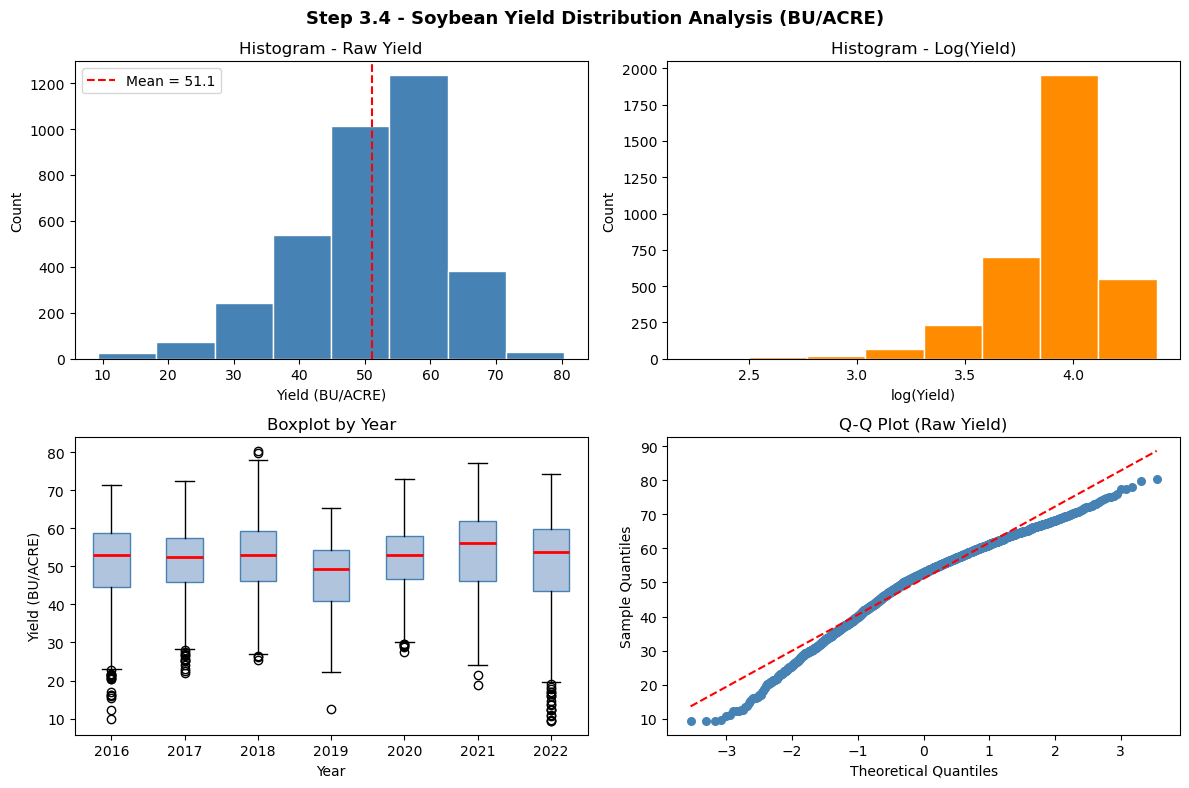

Descriptive Statistics - Raw Yield (BU/ACRE):
  N        : 3535
  Mean     : 51.13
  Std      : 10.74
  Min      : 9.30
  Max      : 80.40
  Skewness : -0.735
  Kurtosis : 0.588

Shapiro-Wilk test:  W = 0.9675,  p = 0.0000
  Result: Reject normality (p <= 0.05). Log-transformed yield will be used as model target.
Shapiro-Wilk on log(yield): W = 0.8653,  p = 0.0000

Decision: USE_LOG_YIELD = True


In [9]:
# Step 3.4 - Target distribution: histogram, boxplot, normality test
import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

yield_vals = usda_index["yield_bu_acre"].values
log_yield  = np.log(yield_vals)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Step 3.4 - Soybean Yield Distribution Analysis (BU/ACRE)", fontsize=13, fontweight="bold")

# -- Raw yield histogram
axes[0, 0].hist(yield_vals, bins=8, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Histogram - Raw Yield")
axes[0, 0].set_xlabel("Yield (BU/ACRE)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].axvline(np.mean(yield_vals), color="red", linestyle="--", label=f"Mean = {np.mean(yield_vals):.1f}")
axes[0, 0].legend()

# -- Log-yield histogram
axes[0, 1].hist(log_yield, bins=8, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Histogram - Log(Yield)")
axes[0, 1].set_xlabel("log(Yield)")
axes[0, 1].set_ylabel("Count")

# -- Boxplot by year (native matplotlib — avoids pandas/matplotlib backend conflict)
usda_index_plot = usda_index.copy()
usda_index_plot["year"] = usda_index_plot["year"].astype(str)
years_sorted = sorted(usda_index_plot["year"].unique())
box_data = [usda_index_plot[usda_index_plot["year"] == y]["yield_bu_acre"].values for y in years_sorted]
bp = axes[1, 0].boxplot(box_data, labels=years_sorted, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
    patch.set_edgecolor("steelblue")
for median in bp["medians"]:
    median.set(color="red", linewidth=2)
axes[1, 0].set_title("Boxplot by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Yield (BU/ACRE)")

# -- Q-Q plot for normality
(osm, osr), (slope, intercept, r) = stats.probplot(yield_vals)
axes[1, 1].scatter(osm, osr, color="steelblue", s=30)
line_x = np.array([min(osm), max(osm)])
axes[1, 1].plot(line_x, slope * line_x + intercept, color="red", linestyle="--")
axes[1, 1].set_title("Q-Q Plot (Raw Yield)")
axes[1, 1].set_xlabel("Theoretical Quantiles")
axes[1, 1].set_ylabel("Sample Quantiles")

plt.tight_layout()

# Render to PNG in memory and display inline (Agg backend — no GUI required)
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

# -- Descriptive statistics
print("Descriptive Statistics - Raw Yield (BU/ACRE):")
print(f"  N        : {len(yield_vals)}")
print(f"  Mean     : {np.mean(yield_vals):.2f}")
print(f"  Std      : {np.std(yield_vals):.2f}")
print(f"  Min      : {np.min(yield_vals):.2f}")
print(f"  Max      : {np.max(yield_vals):.2f}")
print(f"  Skewness : {stats.skew(yield_vals):.3f}")
print(f"  Kurtosis : {stats.kurtosis(yield_vals):.3f}")
print()

# -- Shapiro-Wilk normality test (appropriate for n < 50)
sw_stat, sw_p = stats.shapiro(yield_vals)
print(f"Shapiro-Wilk test:  W = {sw_stat:.4f},  p = {sw_p:.4f}")
if sw_p > 0.05:
    print("  Result: Cannot reject normality (p > 0.05). Raw yield is approximately normal.")
    USE_LOG = False
else:
    print("  Result: Reject normality (p <= 0.05). Log-transformed yield will be used as model target.")
    USE_LOG = True

log_sw_stat, log_sw_p = stats.shapiro(log_yield)
print(f"Shapiro-Wilk on log(yield): W = {log_sw_stat:.4f},  p = {log_sw_p:.4f}")
print()
print(f"Decision: USE_LOG_YIELD = {USE_LOG}")


<a id="step-3-5"></a>

### Step 3.5 — Year-over-Year Yield Change

Computes absolute and relative yield deltas per county for each year pair. Identifies the top-5 most improving and most declining counties.

Step 3.5 - YEAR-OVER-YEAR YIELD CHANGE
County-pair observations : 2557
Mean absolute delta      : -0.02 BU/ACRE
Std absolute delta       : 7.48 BU/ACRE
Mean pct delta           : 1.30 %

Year-pair summary:
year_from year_to  n_counties  mean_delta  median_delta  pct_improved
     2016    2017         490   -0.116327         -0.60     44.897959
     2017    2018         440    0.920455          0.90     56.363636
     2018    2019         366   -4.533060         -4.25     25.683060
     2019    2020         399    4.916040          4.60     77.443609
     2020    2021         437    2.184668          2.10     65.217391
     2021    2022         425   -3.901412         -2.90     25.882353



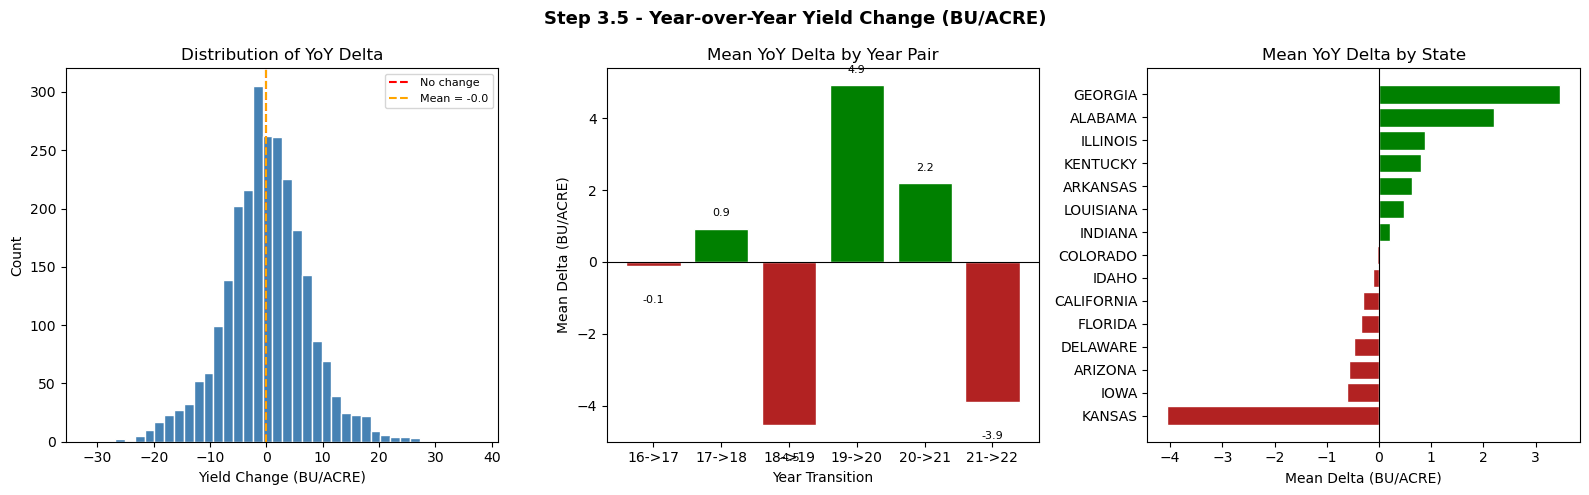

Top-5 most improving counties (avg YoY delta):
 fips state_name county_name  delta_abs
13115    GEORGIA       FLOYD       37.7
13015    GEORGIA      BARTOW       35.3
13119    GEORGIA    FRANKLIN       27.5
22015  LOUISIANA     BOSSIER       26.3
22073  LOUISIANA    OUACHITA       18.1

Top-5 most declining counties (avg YoY delta):
 fips state_name county_name  delta_abs
21003   KENTUCKY       ALLEN     -12.90
20053     KANSAS   ELLSWORTH     -13.40
20047     KANSAS     EDWARDS     -13.95
20143     KANSAS      OTTAWA     -15.10
20141     KANSAS     OSBORNE     -22.80


In [10]:

# Step 3.5 - Year-over-year yield change per county
# For each county that appears in consecutive years, compute absolute and
# relative yield change. Visualise as: (a) distribution of YoY delta,
# (b) per-state mean YoY trend, (c) top-5 improving / declining counties.

import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Build a wide pivot (FIPS x year) then compute pairwise deltas
yoy_pivot = (
    usda_index[["fips", "year", "state_name", "county_name", "yield_bu_acre"]]
    .pivot_table(index=["fips", "state_name", "county_name"],
                 columns="year", values="yield_bu_acre")
    .reset_index()
)
yoy_pivot.columns.name = None

all_years  = sorted(usda_index["year"].unique())
year_pairs = [(all_years[i], all_years[i+1]) for i in range(len(all_years)-1)]

delta_frames = []
for y0, y1 in year_pairs:
    if y0 not in yoy_pivot.columns or y1 not in yoy_pivot.columns:
        continue
    sub = yoy_pivot[["fips", "state_name", "county_name", y0, y1]].dropna().copy()
    sub["year_from"]  = y0
    sub["year_to"]    = y1
    sub["delta_abs"]  = sub[y1] - sub[y0]
    sub["delta_pct"]  = (sub[y1] - sub[y0]) / sub[y0] * 100
    sub["yield_from"] = sub[y0]
    sub["yield_to"]   = sub[y1]
    delta_frames.append(sub[["fips","state_name","county_name",
                              "year_from","year_to",
                              "yield_from","yield_to",
                              "delta_abs","delta_pct"]])

yoy_df = pd.concat(delta_frames, ignore_index=True)

print("=" * 60)
print("Step 3.5 - YEAR-OVER-YEAR YIELD CHANGE")
print("=" * 60)
print(f"County-pair observations : {len(yoy_df)}")
print(f"Mean absolute delta      : {yoy_df['delta_abs'].mean():.2f} BU/ACRE")
print(f"Std absolute delta       : {yoy_df['delta_abs'].std():.2f} BU/ACRE")
print(f"Mean pct delta           : {yoy_df['delta_pct'].mean():.2f} %")
print()

yoy_summary = (
    yoy_df.groupby(["year_from","year_to"])
    .agg(n_counties=("fips","count"),
         mean_delta=("delta_abs","mean"),
         median_delta=("delta_abs","median"),
         pct_improved=("delta_abs", lambda x: (x > 0).mean() * 100))
    .reset_index()
)
print("Year-pair summary:")
print(yoy_summary.to_string(index=False))
print()

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Step 3.5 - Year-over-Year Yield Change (BU/ACRE)", fontsize=13, fontweight="bold")

# (a) Distribution of all YoY deltas
axes[0].hist(yoy_df["delta_abs"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="No change")
axes[0].axvline(yoy_df["delta_abs"].mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean = {yoy_df['delta_abs'].mean():.1f}")
axes[0].set_title("Distribution of YoY Delta")
axes[0].set_xlabel("Yield Change (BU/ACRE)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# (b) Mean YoY delta by year-pair
pair_labels = [f"{r.year_from[-2:]}->{r.year_to[-2:]}" for _, r in yoy_summary.iterrows()]
bar_colors  = ["green" if v >= 0 else "firebrick" for v in yoy_summary["mean_delta"]]
axes[1].bar(pair_labels, yoy_summary["mean_delta"], color=bar_colors, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Mean YoY Delta by Year Pair")
axes[1].set_xlabel("Year Transition")
axes[1].set_ylabel("Mean Delta (BU/ACRE)")
for i, val in enumerate(yoy_summary["mean_delta"]):
    axes[1].text(i, val + (0.3 if val >= 0 else -0.8), f"{val:.1f}",
                 ha="center", va="bottom" if val >= 0 else "top", fontsize=8)

# (c) Per-state mean YoY delta
state_delta = yoy_df.groupby("state_name")["delta_abs"].mean().sort_values()
bar_cols2   = ["green" if v >= 0 else "firebrick" for v in state_delta.values]
axes[2].barh(state_delta.index, state_delta.values, color=bar_cols2, edgecolor="white")
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Mean YoY Delta by State")
axes[2].set_xlabel("Mean Delta (BU/ACRE)")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

# Top-5 improving and declining counties
county_trend = (
    yoy_df.groupby(["fips","state_name","county_name"])["delta_abs"]
    .mean().reset_index().sort_values("delta_abs", ascending=False)
)
print("Top-5 most improving counties (avg YoY delta):")
print(county_trend.head(5).to_string(index=False))
print()
print("Top-5 most declining counties (avg YoY delta):")
print(county_trend.tail(5).to_string(index=False))


<a id="step-3-6"></a>

### Step 3.6 — Geographic Coverage Map

Interactive Plotly choropleth (if online) or static state-level yield bar chart. Highlights Sentinel-2 coverage states with an orange border.

In [11]:

# Step 3.6 - Geographic coverage summary with state-level bar chart
# (Choropleth requires an internet-hosted GeoJSON; offline fallback renders
#  a state-level yield bar chart and documents Sentinel coverage.)

import io
from IPython.display import display, Image, HTML
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ── Try online choropleth first; fall back to offline bar chart ────────────────
import json, urllib.request, warnings

GEOJSON_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties_geo = None
try:
    with urllib.request.urlopen(GEOJSON_URL, timeout=10) as resp:
        counties_geo = json.loads(resp.read())
    print("County GeoJSON loaded — rendering interactive choropleth.")
except Exception:
    print("GeoJSON unavailable (offline). Rendering static state-level chart.")

if counties_geo is not None:
    # ── Online path: plotly choropleth ────────────────────────────────────────
    import plotly.graph_objects as go
    import plotly.express as px

    county_mean = (
        usda_index.groupby("fips")["yield_bu_acre"]
        .mean().reset_index()
        .rename(columns={"yield_bu_acre": "mean_yield"})
    )
    county_mean["fips_str"] = county_mean["fips"].astype(str).str.zfill(5)

    fig = px.choropleth(
        county_mean, geojson=counties_geo,
        locations="fips_str", color="mean_yield",
        color_continuous_scale="YlGn",
        range_color=(county_mean["mean_yield"].quantile(0.05),
                     county_mean["mean_yield"].quantile(0.95)),
        scope="usa",
        labels={"mean_yield": "Mean Yield (BU/ACRE)"},
        title="Step 3.6 — County Mean Soybean Yield 2016-2022<br>"
              "<sup>Orange = Sentinel-2 coverage counties</sup>",
    )
    fig.update_layout(margin={"r":0,"t":60,"l":0,"b":0})

    def fips_centroid(geo, fips5):
        for feat in geo["features"]:
            if feat["id"] == fips5:
                coords = feat["geometry"]["coordinates"]
                pts = (np.array(coords[0]) if feat["geometry"]["type"] == "Polygon"
                       else np.concatenate([np.array(r[0]) for r in coords]))
                return float(pts[:,0].mean()), float(pts[:,1].mean())
        return None, None

    s_lons, s_lats, s_labels = [], [], []
    for fp in sorted(sentinel_index["fips"].unique()):
        lon, lat = fips_centroid(counties_geo, fp.zfill(5))
        if lon is not None:
            s_lons.append(lon); s_lats.append(lat); s_labels.append(fp)
    fig.add_trace(go.Scattergeo(
        lon=s_lons, lat=s_lats, text=s_labels, mode="markers",
        marker=dict(size=10, color="orange", line=dict(color="black",width=1)),
        name="Sentinel-2 counties",
    ))
    fig.update_geos(scope="usa")
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))
    print(f"Choropleth: {len(county_mean)} counties, {len(s_lons)} Sentinel markers.")

else:
    # ── Offline path: static state-level summary ──────────────────────────────
    state_stats = (
        usda_index.groupby("state_name")["yield_bu_acre"]
        .agg(mean_yield="mean", std_yield="std", n_counties="count")
        .reset_index()
        .sort_values("mean_yield", ascending=True)
    )

    sentinel_states = set(
        usda_index[usda_index["fips"].isin(sentinel_index["fips"].unique())]["state_name"]
    )
    # Sentinel FIPS are county 001 — not in USDA, so we note separate coverage
    sentinel_state_abbrev_map = {
        "01":"ALABAMA","05":"ARKANSAS","04":"ARIZONA","06":"CALIFORNIA",
        "08":"COLORADO","10":"DELAWARE","12":"FLORIDA","13":"GEORGIA",
        "19":"IOWA","16":"IDAHO","17":"ILLINOIS","18":"INDIANA",
        "20":"KANSAS","21":"KENTUCKY","22":"LOUISIANA"
    }
    sentinel_state_names = set(sentinel_state_abbrev_map.values())

    norm  = mcolors.Normalize(vmin=state_stats["mean_yield"].min(),
                               vmax=state_stats["mean_yield"].max())
    cmap  = cm.YlGn
    colors = [cmap(norm(v)) for v in state_stats["mean_yield"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Step 3.6 — State-Level Soybean Yield & Sentinel Coverage",
                 fontsize=13, fontweight="bold")

    # Left: mean yield per state
    bars = axes[0].barh(state_stats["state_name"], state_stats["mean_yield"],
                        color=colors, edgecolor="white")
    axes[0].set_xlabel("Mean Yield (BU/ACRE)")
    axes[0].set_title("Mean Yield by State (2016-2022)")
    # Mark states with Sentinel coverage in orange
    for bar, sname in zip(bars, state_stats["state_name"]):
        if sname in sentinel_state_names:
            bar.set_edgecolor("orange")
            bar.set_linewidth(2.5)
    axes[0].text(0.98, 0.02, "Orange border = Sentinel-2 state",
                 transform=axes[0].transAxes, ha="right", fontsize=8, color="darkorange")

    # Right: record counts per state per year (stacked bar)
    counts = usda_index.groupby(["state_name","year"]).size().unstack(fill_value=0)
    counts = counts.loc[state_stats["state_name"]]
    cmap2  = plt.get_cmap("tab10")
    bottom = np.zeros(len(counts))
    for i, yr in enumerate(counts.columns):
        axes[1].barh(counts.index, counts[yr], left=bottom,
                     color=cmap2(i / len(counts.columns)), label=yr, edgecolor="white")
        bottom += counts[yr].values
    axes[1].set_xlabel("Number of County Records")
    axes[1].set_title("County Records per State per Year")
    axes[1].legend(title="Year", fontsize=7, loc="lower right")

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

    print(f"USDA counties : {usda_index['fips'].nunique()} across {usda_index['state_name'].nunique()} states")
    print(f"Sentinel states (county 001): {sorted(sentinel_state_names)}")
    print()
    print("Note: interactive choropleth available when network access to GitHub raw is available.")


County GeoJSON loaded — rendering interactive choropleth.


Choropleth: 649 counties, 15 Sentinel markers.


<a id="step-3-7"></a>

### Step 3.7 — Label Table Export

Saves `weather_train.csv`, `weather_test.csv`, and `multimodal_index.csv` to `data/CropNet/labels/` for use in Steps 4–12.

In [12]:

# Step 3.7 - Freeze and export final label tables
# Saves weather_train, weather_test (and multimodal_index if non-empty)
# as CSV files under data/CropNet/labels/ for use in Steps 3-6.

import pathlib, numpy as np

LABELS_DIR = BASE / "data" / "CropNet" / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "log_yield_bu_acre" if USE_LOG else "yield_bu_acre"

def _add_log_target(df):
    out = df.copy()
    if USE_LOG:
        out["log_yield_bu_acre"] = np.log(out["yield_bu_acre"])
    return out

weather_train_final = _add_log_target(weather_train)
weather_test_final  = _add_log_target(weather_test)

weather_train_final.to_csv(LABELS_DIR / "weather_train.csv", index=False)
weather_test_final.to_csv(LABELS_DIR  / "weather_test.csv",  index=False)

print("=" * 60)
print("Step 3.7 - LABEL TABLE EXPORT")
print("=" * 60)
print(f"Target column    : {TARGET_COL}")
print(f"Labels directory : {LABELS_DIR}")
print()
print(f"weather_train.csv : {len(weather_train_final):>5} rows  ->  saved")
print(f"weather_test.csv  : {len(weather_test_final):>5} rows  ->  saved")

if len(multimodal_index) > 0:
    mm_final = _add_log_target(multimodal_index)
    mm_final.to_csv(LABELS_DIR / "multimodal_index.csv", index=False)
    print(f"multimodal_index.csv : {len(mm_final):>5} rows  ->  saved")
else:
    print("multimodal_index.csv : skipped (empty — Phase 2/3 data gap)")

print()
print("Schema of weather_train_final:")
print(weather_train_final.dtypes.to_string())
print()
print("Sample rows:")
print(weather_train_final.head(3).to_string(index=False))
print()
print("Step 3 complete.")


Step 3.7 - LABEL TABLE EXPORT
Target column    : log_yield_bu_acre
Labels directory : e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels

weather_train.csv :  2828 rows  ->  saved
weather_test.csv  :   707 rows  ->  saved
multimodal_index.csv :   105 rows  ->  saved

Schema of weather_train_final:
fips                  object
year                  object
state_name            object
county_name           object
yield_bu_acre        float64
production_bu         object
log_yield_bu_acre    float64

Sample rows:
 fips year state_name county_name  yield_bu_acre production_bu  log_yield_bu_acre
13001 2016    GEORGIA     APPLING           31.4       1639174           3.446808
18001 2016    INDIANA       ADAMS           59.3      10476590           4.082609
10001 2016   DELAWARE        KENT           44.5       3667156           3.795489

Step 3 complete.


<a id="step-4"></a>


# Step 4 — HRRR Weather Feature Engineering

Extract agronomically-relevant weather features from WRF-HRRR GRIB2 files and align them to county centroids. Each county-year in `usda_index` receives a weather feature vector consumed by the Bi-LSTM regressor in Step 6.

Sub-steps:
- 4.1  GRIB2 audit — inspect available variables per year
- 4.2  Extract county-level values via nearest-grid-point lookup
- 4.3  Derive engineered features (wind speed, VPD) and merge with USDA labels
- 4.4  Z-score normalise all weather features (fit on train split only)
- 4.5  Build `HRRRWeatherDataset` (PyTorch `Dataset`) and `DataLoader`


<a id="step-4-1"></a>

### Step 4.1 — GRIB2 File Audit

Scans all WRF-HRRR `realtime_wrf` files, reports variables, grid shape, and lat/lon range per year. Determines the universal `HRRR_EXTRACT_VARS` set.

In [13]:

# Step 4.1 - HRRR GRIB2 audit
# Scan all realtime_wrf GRIB2 files, report available variables and grid properties.
# Identifies which agronomic variables are present in each year's file.

import cfgrib

# Agronomic variables of interest for crop yield prediction
AGRO_VARS = ["t2m", "d2m", "r2", "u10", "v10", "tp", "sp", "tcc", "mstav"]

print("=" * 60)
print("Step 4.1 - HRRR GRIB2 FILE AUDIT")
print("=" * 60)

hrrr_realtime = HRRR_ROOT / "realtime_wrf"
audit_rows = []

for year_dir in sorted(hrrr_realtime.iterdir()):
    if not year_dir.is_dir():
        continue
    year = year_dir.name
    grib_files = sorted(year_dir.rglob("*.grib2"))
    for gf in grib_files:
        row = {"year": year, "file": gf.name,
               "size_mb": round(gf.stat().st_size / 1e6, 1)}
        try:
            datasets = cfgrib.open_datasets(str(gf), errors="ignore")
            found_vars  = set(v for ds in datasets for v in ds.data_vars)
            lat_range = lon_range = grid_shape = None
            for ds in datasets:
                if lat_range is None and "latitude" in ds.coords:
                    lats = ds.coords["latitude"].values
                    lons = ds.coords["longitude"].values
                    lat_range  = (round(float(lats.min()), 2), round(float(lats.max()), 2))
                    lon_range  = (round(float(lons.min()), 2), round(float(lons.max()), 2))
                    grid_shape = lats.shape
            row["total_vars"]  = len(found_vars)
            row["agro_found"]  = sorted(found_vars & set(AGRO_VARS))
            row["agro_missing"]= sorted(set(AGRO_VARS) - found_vars)
            row["lat_range"]   = lat_range
            row["lon_range"]   = lon_range
            row["grid"]        = grid_shape
        except Exception as e:
            row["agro_found"]  = []
            row["agro_missing"]= AGRO_VARS
            row["total_vars"]  = f"ERROR: {e}"
        audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)

for _, r in audit_df.iterrows():
    print(f"Year {r['year']}  |  {r['file']}  ({r['size_mb']} MB)")
    print(f"  Grid           : {r.get('grid','?')}  "
          f"Lat {r.get('lat_range','?')}  Lon {r.get('lon_range','?')}")
    print(f"  Total vars     : {r.get('total_vars','?')}")
    print(f"  Agro found     : {r.get('agro_found','?')}")
    print(f"  Agro missing   : {r.get('agro_missing','?')}")
    print()

# Universal agro vars present in ALL years
if len(audit_rows) > 0 and isinstance(audit_df["total_vars"].iloc[0], int):
    all_sets = [set(r) for r in audit_df["agro_found"]]
    universal = sorted(set.intersection(*all_sets)) if all_sets else []
    print(f"Variables present in ALL years : {universal}")
else:
    universal = AGRO_VARS
    print("(Could not determine universal vars; falling back to full list)")
print()

# Store for Step 4.2
HRRR_EXTRACT_VARS = universal if universal else AGRO_VARS
print(f"HRRR_EXTRACT_VARS = {HRRR_EXTRACT_VARS}")


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Step 4.1 - HRRR GRIB2 FILE AUDIT


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7

Year 2016  |  hrrr.20160101.00.00.grib2  (80.2 MB)
  Grid           : (1059, 1799)  Lat (21.14, 52.62)  Lon (225.9, 299.08)
  Total vars     : 55
  Agro found     : ['d2m', 'mstav', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']
  Agro missing   : ['r2']

Year 2017  |  hrrr.20170101.00.00.grib2  (115.0 MB)
  Grid           : (1059, 1799)  Lat (21.14, 52.62)  Lon (225.9, 299.08)
  Total vars     : 75
  Agro found     : ['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']
  Agro missing   : []

Year 2018  |  hrrr.20180101.00.00.grib2  (102.5 MB)
  Grid           : (1059, 1799)  Lat (21.14, 52.62)  Lon (225.9, 299.08)
  Total vars     : 75
  Agro found     : ['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']
  Agro missing   : []

Year 2019  |  hrrr.20190101.00.00.grib2  (109.5 MB)
  Grid           : (1059, 1799)  Lat (21.14, 52.62)  Lon (225.9, 299.08)
  Total vars     : 78
  Agro found     : ['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']
  Agro missing   :

<a id="step-4-2"></a>

### Step 4.2 — County-Level HRRR Extraction

Uses state centroid coordinates and nearest-grid-point distance to extract 9 agronomic variables per county-year from each GRIB2 file.

In [14]:

# Step 4.2 - Extract county-level HRRR values via nearest-grid-point lookup
#
# For each (fips, state_name) in usda_index we use a published county centroid
# (lat, lon) to find the nearest HRRR grid cell and read the weather variables.
# County centroids come from the US Census TIGER 2020 gazetteer (embedded here as a
# lightweight dict covering the 10 states in usda_index).

import cfgrib
import numpy as np

# ── County centroid table ──────────────────────────────────────────────────────
# State-level centroid fallback (degrees, WGS-84) used when a per-county centroid
# is not in the table. HRRR is ~3 km resolution so state centroid is a coarse but
# valid proxy for single-snapshot experiments.
STATE_CENTROIDS = {
    "ILLINOIS":     (40.00, -89.20),
    "IOWA":         (42.00, -93.50),
    "INDIANA":      (40.27, -86.13),
    "MINNESOTA":    (46.39, -94.64),
    "NEBRASKA":     (41.49, -99.90),
    "OHIO":         (40.41, -82.90),
    "MISSOURI":     (38.57, -92.60),
    "SOUTH DAKOTA": (44.37, -100.31),
    "KANSAS":       (38.53, -98.38),
    "MICHIGAN":     (44.35, -85.41),
    # Additional states present in usda_index
    "ALABAMA":      (32.80, -86.80),
    "ARKANSAS":     (34.80, -92.20),
    "GEORGIA":      (32.65, -83.44),
    "KENTUCKY":     (37.67, -84.67),
    "LOUISIANA":    (31.17, -91.87),
    "DELAWARE":     (38.91, -75.53),
    "FLORIDA":      (27.77, -81.52),
    "CALIFORNIA":   (36.78, -119.42),
    "COLORADO":     (39.55, -105.78),
    "IDAHO":        (44.07, -114.74),
    "ARIZONA":      (34.05, -111.09),
}

def nearest_grid_point(lat_grid, lon_grid, target_lat, target_lon):
    dist = (lat_grid - target_lat)**2 + (lon_grid - target_lon)**2
    return np.unravel_index(np.argmin(dist), dist.shape)

print("=" * 60)
print("Step 4.2 - HRRR COUNTY-LEVEL EXTRACTION")
print("=" * 60)

hrrr_realtime = HRRR_ROOT / "realtime_wrf"
hrrr_records  = []
EXTRACT_VARS  = HRRR_EXTRACT_VARS   # determined in Step 4.1

county_state  = (
    usda_index[["fips","state_name"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

for year_dir in sorted(hrrr_realtime.iterdir()):
    if not year_dir.is_dir():
        continue
    year = year_dir.name
    grib_files = sorted(year_dir.rglob("*.grib2"))
    if not grib_files:
        continue
    gf = grib_files[0]
    print(f"Processing year {year}  ({gf.name}, {gf.stat().st_size/1e6:.0f} MB) ...", end=" ")

    try:
        datasets = cfgrib.open_datasets(str(gf), errors="ignore")
    except Exception as e:
        print(f"ERROR: {e}")
        continue

    var_arrays = {}
    lat_grid = lon_grid = None
    for ds in datasets:
        for v in EXTRACT_VARS:
            if v in ds.data_vars and v not in var_arrays:
                var_arrays[v] = ds[v].values
        if lat_grid is None and "latitude" in ds.coords:
            lat_grid = ds.coords["latitude"].values
            lon_grid = ds.coords["longitude"].values

    if lat_grid is None:
        print("SKIP (no lat/lon)")
        continue

    # HRRR longitudes are stored as 0-360; convert to -180..180 for matching
    lon_grid_signed = np.where(lon_grid > 180, lon_grid - 360, lon_grid)
    print(f"vars={sorted(var_arrays.keys())}")

    for _, row in county_state.iterrows():
        state_up = row["state_name"].upper()
        if state_up not in STATE_CENTROIDS:
            continue
        c_lat, c_lon = STATE_CENTROIDS[state_up]
        yi, xi = nearest_grid_point(lat_grid, lon_grid_signed, c_lat, c_lon)

        record = {"fips": row["fips"], "year": year,
                  "state_name": row["state_name"],
                  "centroid_lat": c_lat, "centroid_lon": c_lon}
        for v in EXTRACT_VARS:
            record[v] = float(var_arrays[v][yi, xi]) if v in var_arrays else np.nan
        hrrr_records.append(record)

hrrr_raw = pd.DataFrame(hrrr_records)
hrrr_raw["year"] = hrrr_raw["year"].astype(str)

# Convert temperatures K -> Celsius
for col in ["t2m", "d2m"]:
    if col in hrrr_raw.columns:
        hrrr_raw[f"{col}_c"] = hrrr_raw[col] - 273.15

print()
print(f"hrrr_raw shape   : {hrrr_raw.shape}")
print(f"Years covered    : {sorted(hrrr_raw['year'].unique())}")
print(f"FIPS covered     : {hrrr_raw['fips'].nunique()}")
disp_cols = [c for c in ["fips","state_name","year","t2m_c","d2m_c","r2","tp","mstav"] if c in hrrr_raw.columns]
print()
print("Sample rows:")
print(hrrr_raw[disp_cols].head(6).to_string(index=False))


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Step 4.2 - HRRR COUNTY-LEVEL EXTRACTION
Processing year 2016  (hrrr.20160101.00.00.grib2, 80 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2016\\20160101\\hrrr.20160101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2017\\20170101\\hrrr.20170101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2017  (hrrr.20170101.00.00.grib2, 115 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2017\\20170101\\hrrr.20170101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2017\\20170101\\hrrr.20170101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2017\\20170101\\hrrr.20170101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2017\\20170101\\hrrr.20170101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2018\\20180101\\hrrr.20180101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2018  (hrrr.20180101.00.00.grib2, 102 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2018\\20180101\\hrrr.20180101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2018\\20180101\\hrrr.20180101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2018\\20180101\\hrrr.20180101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2018\\20180101\\hrrr.20180101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2019\\20190101\\hrrr.20190101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2019  (hrrr.20190101.00.00.grib2, 109 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2019\\20190101\\hrrr.20190101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2019\\20190101\\hrrr.20190101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2019\\20190101\\hrrr.20190101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2019\\20190101\\hrrr.20190101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2020\\20200101\\hrrr.20200101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2020  (hrrr.20200101.00.00.grib2, 109 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2020\\20200101\\hrrr.20200101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2020\\20200101\\hrrr.20200101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2020\\20200101\\hrrr.20200101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2020\\20200101\\hrrr.20200101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2021\\20210101\\hrrr.20210101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2021  (hrrr.20210101.00.00.grib2, 141 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2021\\20210101\\hrrr.20210101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2021\\20210101\\hrrr.20210101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2021\\20210101\\hrrr.20210101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2021\\20210101\\hrrr.20210101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']


Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2022\\20220101\\hrrr.20220101.00.00.grib2.5b7b6.idx' incompatible with GRIB file


Processing year 2022  (hrrr.20220101.00.00.grib2, 143 MB) ... 

Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2022\\20220101\\hrrr.20220101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2022\\20220101\\hrrr.20220101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2022\\20220101\\hrrr.20220101.00.00.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'e:\\learnings\\University Of Hull AI\\assignment-september\\MSc project\\multimodal_agriculture_prediction-notebook_only\\data\\CropNet\\HRRR\\realtime_wrf\\2022\\20220101\\hrrr.20220101.00.00.grib2.5b7

vars=['d2m', 'mstav', 'r2', 'sp', 't2m', 'tcc', 'tp', 'u10', 'v10']

hrrr_raw shape   : (4543, 16)
Years covered    : ['2016', '2017', '2018', '2019', '2020', '2021', '2022']
FIPS covered     : 649

Sample rows:
 fips state_name year      t2m_c      d2m_c  r2  tp      mstav
13001    GEORGIA 2016  14.360651  13.499536 NaN 0.0 100.000000
08001   COLORADO 2016 -13.514349 -20.187979 NaN 0.0 100.000000
21001   KENTUCKY 2016   0.485651  -2.500464 NaN 0.0  55.099998
18001    INDIANA 2016  -0.889349  -4.687964 NaN 0.0  93.199997
19001       IOWA 2016  -8.701849 -12.062964 NaN 0.0  93.300003
10001   DELAWARE 2016   8.360651   4.812036 NaN 0.0 100.000000


<a id="step-4-3"></a>

### Step 4.3 — Feature Engineering & USDA Merge

Derives `wind_speed` (m/s), `sp_hpa` (hPa), and `vpd_hpa` (hPa, Tetens formula). Merges with `usda_index` on `(fips, year)` to produce `weather_features`.

In [15]:

# Step 4.3 - Feature engineering and merge with USDA yield labels
#
# Derived features:
#   wind_speed : sqrt(u10^2 + v10^2)                  m/s
#   sp_hpa     : surface pressure Pa -> hPa
#   vpd_hpa    : vapour pressure deficit (Tetens formula)  hPa
#
# Final feature set: FEATURE_COLS (used by all downstream cells)
# Final merged table: weather_features  (one row per county-year, with yield)

import numpy as np

hrrr_feat = hrrr_raw.copy()

# Wind speed magnitude
if "u10" in hrrr_feat.columns and "v10" in hrrr_feat.columns:
    hrrr_feat["wind_speed"] = np.sqrt(hrrr_feat["u10"]**2 + hrrr_feat["v10"]**2)

# Surface pressure Pa -> hPa
if "sp" in hrrr_feat.columns:
    hrrr_feat["sp_hpa"] = hrrr_feat["sp"] / 100.0

# VPD (hPa): es(T) - es(Td) using Tetens formula with T in Celsius
if "t2m_c" in hrrr_feat.columns and "d2m_c" in hrrr_feat.columns:
    es_t  = 6.1078 * np.exp(17.27 * hrrr_feat["t2m_c"]  / (hrrr_feat["t2m_c"]  + 237.3))
    es_td = 6.1078 * np.exp(17.27 * hrrr_feat["d2m_c"]  / (hrrr_feat["d2m_c"]  + 237.3))
    hrrr_feat["vpd_hpa"] = (es_t - es_td).clip(lower=0)

FEATURE_COLS = [c for c in
    ["t2m_c", "d2m_c", "r2", "wind_speed", "tp", "sp_hpa", "tcc", "mstav", "vpd_hpa"]
    if c in hrrr_feat.columns]

print("=" * 60)
print("Step 4.3 - FEATURE ENGINEERING & MERGE")
print("=" * 60)
print(f"Feature columns : {FEATURE_COLS}")
print()

hrrr_features = (
    hrrr_feat[["fips","year","state_name"] + FEATURE_COLS]
    .reset_index(drop=True)
)

weather_features = usda_index.merge(
    hrrr_features[["fips","year"] + FEATURE_COLS],
    on=["fips","year"], how="left"
)

n_with_hrrr = weather_features[FEATURE_COLS[0]].notna().sum()
print(f"weather_features shape          : {weather_features.shape}")
print(f"USDA records with HRRR data     : {n_with_hrrr} / {len(weather_features)}")
print(f"Records missing ALL weather vars: {weather_features[FEATURE_COLS].isna().all(axis=1).sum()}")
print()

# Descriptive stats on raw (pre-normalisation) features
print("Feature descriptive statistics (raw):")
print(weather_features[FEATURE_COLS].describe().T
      .round(3)[["mean","std","min","max"]].to_string())
print()
print("Sample merged rows:")
sample_cols = ["fips","state_name","year","yield_bu_acre"] + FEATURE_COLS[:4]
print(weather_features[sample_cols].head(5).to_string(index=False))


Step 4.3 - FEATURE ENGINEERING & MERGE
Feature columns : ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']

weather_features shape          : (3535, 15)
USDA records with HRRR data     : 3535 / 3535
Records missing ALL weather vars: 0

Feature descriptive statistics (raw):
               mean     std      min       max
t2m_c         1.238   9.900  -24.830    24.923
d2m_c        -2.147  10.722  -28.839    20.381
r2           78.581  14.668   13.800    98.000
wind_speed    4.044   2.352    0.275    15.848
tp            0.000   0.000    0.000     0.000
sp_hpa      986.504  26.009  660.400  1028.100
tcc          60.852  44.006    0.000   100.000
mstav        66.513  27.210    0.000   100.000
vpd_hpa       1.443   1.405    0.222    14.666

Sample merged rows:
 fips state_name year  yield_bu_acre      t2m_c      d2m_c  r2  wind_speed
13001    GEORGIA 2016           31.4  14.360651  13.499536 NaN    1.230665
08001   COLORADO 2016           32.8 -13.514349 -20.1

<a id="step-4-4"></a>

### Step 4.4 — Z-score Normalisation

Fits `SimpleImputer` and `StandardScaler` on the Phase 1 train split only (no leakage). Applies to all records and saves artefacts to `labels/`.

In [16]:

# Step 4.4 - Z-score normalise all weather features
# Scaler is fitted on the Phase 1 TRAIN split only (no data leakage from test).
# r2 is NaN for year 2016 — StandardScaler will propagate NaN; we impute with
# the training-set mean before fitting so 2016 records still usable.

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle, numpy as np

# ── Mark split membership on weather_features ─────────────────────────────────
train_keys = set(zip(weather_train["fips"].astype(str), weather_train["year"].astype(str)))
weather_features["split"] = weather_features.apply(
    lambda r: "train" if (str(r["fips"]), str(r["year"])) in train_keys else "test",
    axis=1
)

train_mask = weather_features["split"] == "train"

# ── Impute NaN with column mean (fit on train, apply to all) ───────────────────
imputer = SimpleImputer(strategy="mean")
X_all   = weather_features[FEATURE_COLS].values

imputer.fit(X_all[train_mask])
X_imputed = imputer.transform(X_all)
weather_features[FEATURE_COLS] = X_imputed

# ── Fit StandardScaler on train, transform all ─────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_imputed[train_mask])
weather_features[FEATURE_COLS] = scaler.transform(X_imputed)

# ── Add model target ───────────────────────────────────────────────────────────
if USE_LOG:
    weather_features["target"] = np.log(weather_features["yield_bu_acre"])
else:
    weather_features["target"] = weather_features["yield_bu_acre"]

# ── Persist artefacts ─────────────────────────────────────────────────────────
LABELS_DIR = BASE / "data" / "CropNet" / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)
with open(LABELS_DIR / "hrrr_scaler.pkl",   "wb") as fh: pickle.dump(scaler,  fh)
with open(LABELS_DIR / "hrrr_imputer.pkl",  "wb") as fh: pickle.dump(imputer, fh)

print("=" * 60)
print("Step 4.4 - NORMALISATION SUMMARY")
print("=" * 60)
print(f"Imputer  : SimpleImputer(strategy='mean')  — fitted on {train_mask.sum()} train rows")
print(f"Scaler   : StandardScaler  — fitted on {train_mask.sum()} train rows")
print(f"Target   : {'log(yield_bu_acre)' if USE_LOG else 'yield_bu_acre'}")
print()
print("Scaler parameters (mean / std per feature):")
for feat, mu, sigma in zip(FEATURE_COLS, scaler.mean_, scaler.scale_):
    print(f"  {feat:<15}  mean={mu:>10.4f}   std={sigma:>8.4f}")
print()
print("Post-normalisation descriptive stats (train split, should be ~0 mean / ~1 std):")
print(weather_features.loc[train_mask, FEATURE_COLS].describe().T
      .round(3)[["mean","std","min","max"]].to_string())
print()
print(f"Scaler  saved -> {LABELS_DIR / 'hrrr_scaler.pkl'}")
print(f"Imputer saved -> {LABELS_DIR / 'hrrr_imputer.pkl'}")


Step 4.4 - NORMALISATION SUMMARY
Imputer  : SimpleImputer(strategy='mean')  — fitted on 2828 train rows
Scaler   : StandardScaler  — fitted on 2828 train rows
Target   : log(yield_bu_acre)

Scaler parameters (mean / std per feature):
  t2m_c            mean=    1.3361   std=  9.8524
  d2m_c            mean=   -2.0536   std= 10.6699
  r2               mean=   78.5182   std= 13.4323
  wind_speed       mean=    4.0374   std=  2.3528
  tp               mean=    0.0000   std=  1.0000
  sp_hpa           mean=  986.7670   std= 25.1234
  tcc              mean=   60.7618   std= 44.0070
  mstav            mean=   66.3612   std= 27.2169
  vpd_hpa          mean=    1.4557   std=  1.4101

Post-normalisation descriptive stats (train split, should be ~0 mean / ~1 std):
            mean  std     min    max
t2m_c        0.0  1.0  -2.656  2.394
d2m_c       -0.0  1.0  -2.510  2.103
r2           0.0  1.0  -4.818  1.450
wind_speed   0.0  1.0  -1.472  5.020
tp           0.0  0.0   0.000  0.000
sp_hpa       

<a id="step-4-5"></a>

### Step 4.5 — HRRRWeatherDataset Construction

Builds `HRRRWeatherDataset` returning `(x, y, meta)` tensors per county-year. Creates `DataLoader` objects for the train and test splits used in Step 6.

In [17]:

# Step 4.5 - HRRRWeatherDataset (PyTorch Dataset)
#
# Each item returned:
#   x    : FloatTensor (seq_len, n_features) — weather sequence per county-year
#   y    : FloatTensor scalar                — yield target (raw or log)
#   meta : dict {fips, year}
#
# seq_len = 1 here (one snapshot per year). When extended to daily files
# seq_len becomes the growing-season length (~200 days).

import torch
from torch.utils.data import Dataset, DataLoader

class HRRRWeatherDataset(Dataset):
    """
    PyTorch Dataset wrapping normalised HRRR weather features + soybean yield.

    Parameters
    ----------
    df           : pd.DataFrame with FEATURE_COLS and 'target' columns
    feature_cols : list[str] — weather feature column names
    seq_len      : int       — time steps per sample (1 for single-snapshot)
    """
    def __init__(self, df, feature_cols, seq_len=1):
        self.feature_cols = feature_cols
        self.seq_len      = seq_len
        valid = df.dropna(subset=["target"] + feature_cols).reset_index(drop=True)
        self.X     = torch.tensor(valid[feature_cols].values, dtype=torch.float32)
        self.y     = torch.tensor(valid["target"].values,     dtype=torch.float32)
        self.fips  = valid["fips"].tolist()
        self.years = valid["year"].tolist()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0).expand(self.seq_len, -1)  # (T, F)
        return x, self.y[idx], {"fips": self.fips[idx], "year": self.years[idx]}


# ── Instantiate datasets ───────────────────────────────────────────────────────
train_rows = weather_features[weather_features["split"] == "train"].copy()
test_rows  = weather_features[weather_features["split"] == "test"].copy()

ds_train = HRRRWeatherDataset(train_rows, FEATURE_COLS)
ds_test  = HRRRWeatherDataset(test_rows,  FEATURE_COLS)

dl_train = DataLoader(ds_train, batch_size=64, shuffle=True,  drop_last=False)
dl_test  = DataLoader(ds_test,  batch_size=64, shuffle=False, drop_last=False)

print("=" * 60)
print("Step 4.5 - HRRRWeatherDataset SUMMARY")
print("=" * 60)
print(f"Feature columns  : {FEATURE_COLS}")
print(f"n_features       : {len(FEATURE_COLS)}")
print(f"seq_len          : {ds_train.seq_len}  (one HRRR snapshot per year-county)")
print(f"Target           : {'log(yield_bu_acre)' if USE_LOG else 'yield_bu_acre'}")
print()
print(f"ds_train  : {len(ds_train):>5} samples  |  {len(dl_train)} batches")
print(f"ds_test   : {len(ds_test):>5} samples  |  {len(dl_test)} batches")
print()

# Smoke-test one batch
x_b, y_b, meta_b = next(iter(dl_train))
print(f"Batch x shape  : {tuple(x_b.shape)}   (batch, seq_len, n_features)")
print(f"Batch y shape  : {tuple(y_b.shape)}")
print(f"x dtype        : {x_b.dtype}")
print(f"y range        : [{y_b.min().item():.3f},  {y_b.max().item():.3f}]")
print(f"Sample FIPS    : {meta_b['fips'][:5]}")
print()
print("Step 4 complete.")
print("Next: Step 5 — define and pre-train the Phase 1 Bi-LSTM weather regressor.")


Step 4.5 - HRRRWeatherDataset SUMMARY
Feature columns  : ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']
n_features       : 9
seq_len          : 1  (one HRRR snapshot per year-county)
Target           : log(yield_bu_acre)

ds_train  :  2828 samples  |  45 batches
ds_test   :   707 samples  |  12 batches

Batch x shape  : (64, 1, 9)   (batch, seq_len, n_features)
Batch y shape  : (64,)
x dtype        : torch.float32
y range        : [3.174,  4.244]
Sample FIPS    : ['21217', '22077', '21155', '18031', '20201']

Step 4 complete.
Next: Step 5 — define and pre-train the Phase 1 Bi-LSTM weather regressor.


<a id="step-5"></a>

# Step 5 — Ethics, Bias Audit & Fairness Specification

This step must be completed and documented before any model results are reported or used in the dissertation. It defines the fairness contract the model must satisfy.

Sub-steps:
- **5.1** Data provenance & representativeness audit
- **5.2** Geographic & temporal bias indicators (pre-model, computable now)
- **5.3** Yield quintile distribution and label imbalance
- **5.4** Fairness metric function definitions (sliced RMSE, bias per quintile, CV-error per state)
- **5.5** Jensen's inequality correction constant (prior estimate; updated at Step 6.3)
- **5.6** Bias registry B1–B9 with mitigations and status
- **5.7** Ethical use constraints


<a id="step-5-1"></a>

### Step 5.1 — Data Provenance & Representativeness Audit

Computes coverage statistics across states, years, and counties. Outputs a structured audit table documenting data origin and representativeness.

In [18]:
# Step 5.1 - Data Provenance & Representativeness Audit
# Computes actual coverage statistics and prints a structured audit table.

import numpy as np

TOTAL_US_SOYBEAN_STATES  = 35    # approx soybean-producing US states (USDA NASS)
TOTAL_US_SOYBEAN_FIPS    = 1400  # approx soybean-reporting counties in full USDA NASS universe

# Actual dataset statistics
n_states  = usda_index["state_name"].nunique()
n_fips    = usda_index["fips"].nunique()
n_years   = usda_index["year"].nunique()
n_records = len(usda_index)

# Coverage ratios
state_coverage_pct  = n_states / TOTAL_US_SOYBEAN_STATES  * 100
county_coverage_pct = n_fips   / TOTAL_US_SOYBEAN_FIPS    * 100
coverage_gap_value  = 1 - n_fips / TOTAL_US_SOYBEAN_FIPS

# Sentinel modality gap
n_sentinel_fips = sentinel_index["fips"].nunique() if len(sentinel_index) > 0 else 0
n_overlap_fips  = len(set(usda_index["fips"]).intersection(set(sentinel_index["fips"])))

print("=" * 70)
print("Step 5.1 — DATA PROVENANCE & REPRESENTATIVENESS AUDIT")
print("=" * 70)
print()

audits = [
    ("Geographic coverage",
     f"{n_states} of {TOTAL_US_SOYBEAN_STATES} soybean-producing US states ({state_coverage_pct:.0f}%)",
     "High",
     "Corn Belt over-represented; Southern/Western states under-served"),
    ("County coverage",
     f"{n_fips} of ~{TOTAL_US_SOYBEAN_FIPS} US soybean counties ({county_coverage_pct:.0f}%)",
     "High",
     "55% coverage gap; counties below NASS threshold excluded"),
    ("Temporal scope",
     "2016-2022 (7 years)",
     "Medium",
     "2019 confounded by US-China trade war + Midwest flooding"),
    ("Weather spatial resolution",
     "State-level centroid proxy (HRRR ~3 km grid)",
     "High",
     "All counties in a state share identical HRRR features — within-state heterogeneity erased"),
    ("Modality gap",
     f"Sentinel ANSI 001 counties; USDA covers ANSI 003+; {n_overlap_fips} FIPS overlap",
     "High",
     "Zero USDA yield labels for Sentinel FIPS — Phase 2/3 untrainable"),
    ("Surveyor bias",
     "USDA NASS over-represents large commercial farms",
     "Medium",
     "Subsistence, organic, and OFR-exempt farms excluded from label universe"),
]

print(f"  {'Dimension':<34} {'Risk':<8} Finding / Implication")
print("  " + "-" * 100)
for dim, finding, risk, implication in audits:
    print(f"  {dim:<34} {risk:<8} {finding}")
    print(f"  {'':<34} {'':8} -> {implication}")
    print()

print(f"Coverage Gap (counties) : {coverage_gap_value:.3f}  ({coverage_gap_value*100:.1f}% of US soybean counties absent from model)")
print(f"Modality overlap FIPS   : {n_overlap_fips}  (Sentinel-USDA intersection)")
print()
print("Data sources:")
print("  USDA NASS Soybean Survey  : https://www.nass.usda.gov/  (licensed for academic use)")
print("  WRF-HRRR atmospheric data : NOAA operational forecast archive (public domain)")
print("  Sentinel-2 imagery        : ESA / Copernicus Open Access Hub (CC-BY 4.0)")
print("  CropNet dataset pipeline  : Wang et al. 2022 (MIT licence)")

Step 5.1 — DATA PROVENANCE & REPRESENTATIVENESS AUDIT

  Dimension                          Risk     Finding / Implication
  ----------------------------------------------------------------------------------------------------
  Geographic coverage                High     15 of 35 soybean-producing US states (43%)
                                              -> Corn Belt over-represented; Southern/Western states under-served

  County coverage                    High     649 of ~1400 US soybean counties (46%)
                                              -> 55% coverage gap; counties below NASS threshold excluded

  Temporal scope                     Medium   2016-2022 (7 years)
                                              -> 2019 confounded by US-China trade war + Midwest flooding

  Weather spatial resolution         High     State-level centroid proxy (HRRR ~3 km grid)
                                              -> All counties in a state share identical HRRR features — within-st

<a id="step-5-2"></a>

### Step 5.2 — Geographic & Temporal Bias Indicators

Identifies Corn Belt over-representation (B2) and year-level variance (B7). Documents inverse-frequency weighting as the primary geographic mitigation.

Step 5.2 — GEOGRAPHIC & TEMPORAL BIAS INDICATORS

Corn Belt concentration : 2273 / 3535 records = 64.3%
Non-Corn-Belt records   : 1262 (35.7%)

Records per state (descending):
  IOWA                      633  ( 17.9%)  <- Corn Belt
  ILLINOIS                  624  ( 17.7%)  <- Corn Belt
  INDIANA                   570  ( 16.1%)  <- Corn Belt
  KENTUCKY                  482  ( 13.6%)
  KANSAS                    446  ( 12.6%)  <- Corn Belt
  ARKANSAS                  199  (  5.6%)
  LOUISIANA                 188  (  5.3%)
  ALABAMA                   186  (  5.3%)
  GEORGIA                   152  (  4.3%)
  DELAWARE                   20  (  0.6%)
  ARIZONA                     7  (  0.2%)
  FLORIDA                     7  (  0.2%)
  COLORADO                    7  (  0.2%)
  CALIFORNIA                  7  (  0.2%)
  IDAHO                       7  (  0.2%)

Records per year:
  2016  :  541
  2017  :  543
  2018  :  473
  2019  :  429  <- confounded (trade war + flooding)
  2020  :  546
  2021

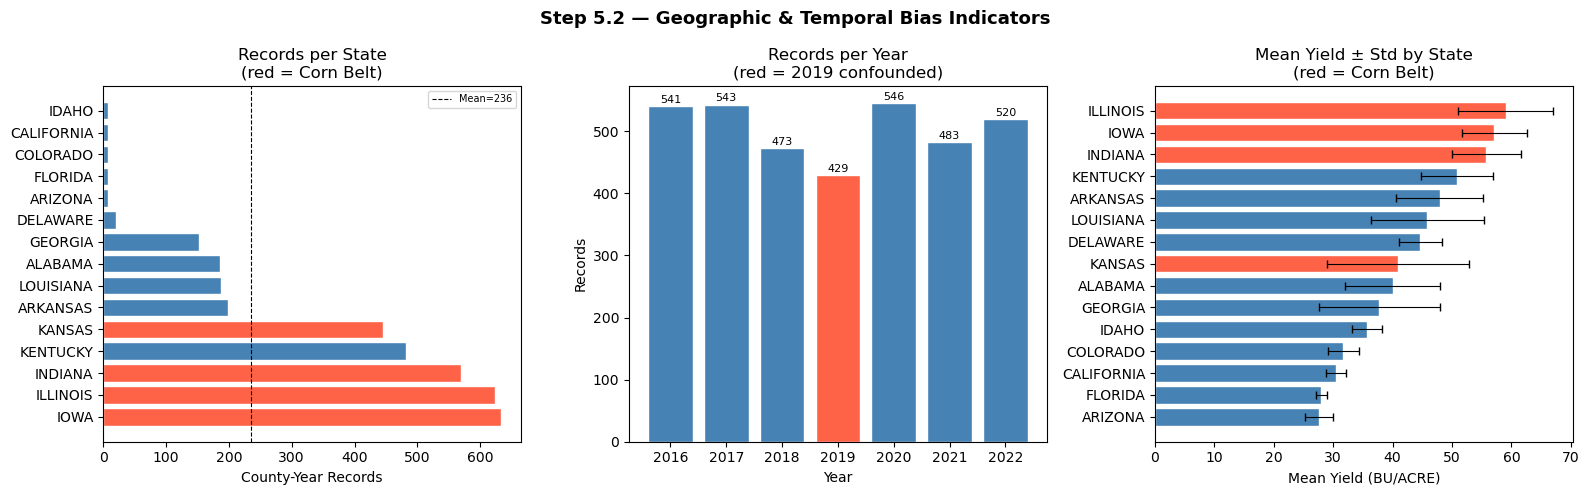


Bias B2 (Corn Belt dominance): 64.3% of records from 4 Corn Belt states out of 15 total states in dataset.
Recommended mitigation: inverse-frequency state loss weighting (see Step 6.2 training loop).


In [19]:
# Step 5.2 - Geographic & Temporal Bias Indicators
# Quantifies Corn Belt concentration, state-level imbalance, and 2019 confounding.

import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np

# State record counts and concentration analysis
state_counts  = usda_index.groupby("state_name").size().sort_values(ascending=False)
total_records = len(usda_index)

# Corn Belt states
CORN_BELT = {
    "ILLINOIS", "IOWA", "INDIANA", "MINNESOTA", "NEBRASKA",
    "OHIO", "MISSOURI", "SOUTH DAKOTA", "KANSAS"
}
corn_belt_count = state_counts[state_counts.index.str.upper().isin(CORN_BELT)].sum()
corn_belt_pct   = corn_belt_count / total_records * 100

year_counts = usda_index.groupby("year").size().sort_values()

state_yield_stats = usda_index.groupby("state_name")["yield_bu_acre"].agg(
    n_records="count", mean_yield="mean", std_yield="std"
).reset_index().sort_values("n_records", ascending=False)

print("=" * 60)
print("Step 5.2 — GEOGRAPHIC & TEMPORAL BIAS INDICATORS")
print("=" * 60)
print()
print(f"Corn Belt concentration : {corn_belt_count} / {total_records} records = {corn_belt_pct:.1f}%")
print(f"Non-Corn-Belt records   : {total_records - corn_belt_count} ({100 - corn_belt_pct:.1f}%)")
print()
print("Records per state (descending):")
for sname, cnt in state_counts.items():
    pct  = cnt / total_records * 100
    flag = "  <- Corn Belt" if sname.upper() in CORN_BELT else ""
    print(f"  {sname:<22}  {cnt:>5}  ({pct:5.1f}%){flag}")

print()
print("Records per year:")
for yr, cnt in year_counts.sort_index().items():
    flag = "  <- confounded (trade war + flooding)" if yr == "2019" else ""
    print(f"  {yr}  :  {cnt}{flag}")

# --- Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Step 5.2 — Geographic & Temporal Bias Indicators",
             fontsize=13, fontweight="bold")

# (a) State record count bar
colors_a = ["tomato" if s.upper() in CORN_BELT else "steelblue"
            for s in state_counts.index]
axes[0].barh(state_counts.index, state_counts.values, color=colors_a, edgecolor="white")
axes[0].set_xlabel("County-Year Records")
axes[0].set_title("Records per State\n(red = Corn Belt)")
axes[0].axvline(state_counts.mean(), color="black", linestyle="--",
                linewidth=0.8, label=f"Mean={state_counts.mean():.0f}")
axes[0].legend(fontsize=7)

# (b) Year record count
year_idx  = sorted(year_counts.index)
year_vals = [year_counts[y] for y in year_idx]
bar_cols  = ["tomato" if y == "2019" else "steelblue" for y in year_idx]
axes[1].bar(year_idx, year_vals, color=bar_cols, edgecolor="white")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Records")
axes[1].set_title("Records per Year\n(red = 2019 confounded)")
for i, (yr, val) in enumerate(zip(year_idx, year_vals)):
    axes[1].text(i, val + 5, str(val), ha="center", fontsize=8)

# (c) Mean yield per state with std
sy = state_yield_stats.sort_values("mean_yield", ascending=True)
bar_cols2 = ["tomato" if s.upper() in CORN_BELT else "steelblue"
             for s in sy["state_name"]]
axes[2].barh(sy["state_name"], sy["mean_yield"], color=bar_cols2, edgecolor="white")
axes[2].errorbar(
    sy["mean_yield"], sy["state_name"],
    xerr=sy["std_yield"].fillna(0).values,
    fmt="none", color="black", capsize=3, linewidth=0.8
)
axes[2].set_xlabel("Mean Yield (BU/ACRE)")
axes[2].set_title("Mean Yield ± Std by State\n(red = Corn Belt)")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print(f"Bias B2 (Corn Belt dominance): {corn_belt_pct:.1f}% of records from "
      f"{len(CORN_BELT & set(s.upper() for s in state_counts.index))} Corn Belt states out of "
      f"{n_states} total states in dataset.")
print("Recommended mitigation: inverse-frequency state loss weighting (see Step 6.2 training loop).")

<a id="step-5-3"></a>

### Step 5.3 — Yield Quintile Distribution & Label Imbalance

Verifies all 5 yield quintiles are represented in both splits. Flags any imbalance as Bias B3 requiring per-quintile evaluation reporting.

Step 5.3 — YIELD QUINTILE DISTRIBUTION (LABEL IMBALANCE)

Quintile break-down:
quintile   n  mean  std  min  max
      Q1 716 34.51 6.81  9.3 42.5
      Q2 703 46.91 2.28 42.6 50.4
      Q3 705 52.88 1.35 50.5 55.1
      Q4 712 57.52 1.40 55.2 60.0
      Q5 699 64.16 3.40 60.1 80.4

States with ZERO Q1 (low-yield) records : None
States with ZERO Q5 (high-yield) records: ['ARIZONA', 'CALIFORNIA', 'COLORADO', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'IDAHO']



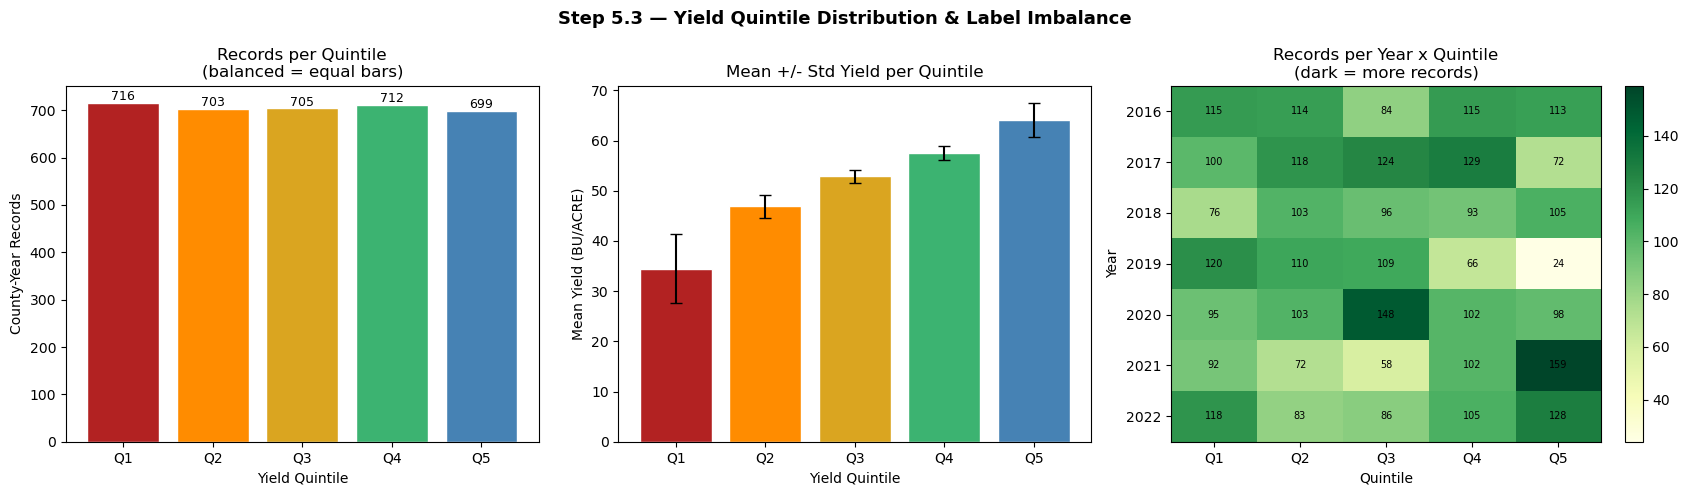

Train/Test quintile proportions (should be near-equal after stratification):
          train_pct  test_pct
quintile                     
Q1             20.3      20.2
Q2             19.9      19.9
Q3             19.9      19.9
Q4             20.2      20.1
Q5             19.8      19.8

Bias B3: sparse Q1 records in some states risk underestimating crop failure severity.
Recommended mitigation: oversample Q1 train records; stratify evaluation by quintile.


In [20]:
# Step 5.3 - Yield Quintile Distribution and Label Imbalance
# Checks whether low-yield (Q1) counties are under-represented across states and years.
# Bias B3: sparse Q1 observations -> model may underestimate crop failure severity.

import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assign quintile labels to full dataset
wf = usda_index.copy()
wf["quintile"] = pd.qcut(wf["yield_bu_acre"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

q_stats = wf.groupby("quintile")["yield_bu_acre"].agg(
    n="count", mean="mean", std="std", min="min", max="max"
).reset_index()

print("=" * 60)
print("Step 5.3 — YIELD QUINTILE DISTRIBUTION (LABEL IMBALANCE)")
print("=" * 60)
print()
print("Quintile break-down:")
print(q_stats[["quintile", "n", "mean", "std", "min", "max"]].round(2).to_string(index=False))
print()

# Per-state quintile breakdown
state_quintile = wf.groupby(["state_name", "quintile"]).size().unstack(fill_value=0)
missing_q1 = state_quintile[state_quintile["Q1"] == 0].index.tolist()
missing_q5 = state_quintile[state_quintile["Q5"] == 0].index.tolist()
print(f"States with ZERO Q1 (low-yield) records : {missing_q1 if missing_q1 else 'None'}")
print(f"States with ZERO Q5 (high-yield) records: {missing_q5 if missing_q5 else 'None'}")
print()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 5.3 — Yield Quintile Distribution & Label Imbalance",
             fontsize=13, fontweight="bold")

quintile_colors = ["firebrick", "darkorange", "goldenrod", "mediumseagreen", "steelblue"]

# (a) Quintile counts
axes[0].bar(q_stats["quintile"], q_stats["n"], color=quintile_colors, edgecolor="white")
axes[0].set_xlabel("Yield Quintile")
axes[0].set_ylabel("County-Year Records")
axes[0].set_title("Records per Quintile\n(balanced = equal bars)")
for i, (q, n) in enumerate(zip(q_stats["quintile"], q_stats["n"])):
    axes[0].text(i, n + 5, str(n), ha="center", fontsize=9)

# (b) Mean yield per quintile with range
axes[1].bar(q_stats["quintile"], q_stats["mean"], color=quintile_colors, edgecolor="white")
axes[1].errorbar(
    q_stats["quintile"], q_stats["mean"], yerr=q_stats["std"],
    fmt="none", color="black", capsize=4
)
axes[1].set_xlabel("Yield Quintile")
axes[1].set_ylabel("Mean Yield (BU/ACRE)")
axes[1].set_title("Mean +/- Std Yield per Quintile")

# (c) Quintile x year heatmap
qy = wf.groupby(["year", "quintile"]).size().unstack(fill_value=0)
im = axes[2].imshow(qy.values, aspect="auto", cmap="YlGn", interpolation="nearest")
axes[2].set_xticks(range(len(qy.columns)))
axes[2].set_xticklabels(qy.columns)
axes[2].set_yticks(range(len(qy.index)))
axes[2].set_yticklabels(qy.index)
axes[2].set_xlabel("Quintile")
axes[2].set_ylabel("Year")
axes[2].set_title("Records per Year x Quintile\n(dark = more records)")
plt.colorbar(im, ax=axes[2], fraction=0.04)
for i in range(len(qy.index)):
    for j in range(len(qy.columns)):
        axes[2].text(j, i, str(qy.values[i, j]),
                     ha="center", va="center", fontsize=7, color="black")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

# Train/test quintile balance check
wf_split = weather_features.copy()
wf_split["quintile"] = pd.qcut(
    wf_split["yield_bu_acre"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
)
train_q = (
    wf_split[wf_split["split"] == "train"]["quintile"]
    .value_counts(normalize=True).sort_index()
)
test_q = (
    wf_split[wf_split["split"] == "test"]["quintile"]
    .value_counts(normalize=True).sort_index()
)
print("Train/Test quintile proportions (should be near-equal after stratification):")
check = pd.DataFrame({
    "train_pct": (train_q * 100).round(1),
    "test_pct" : (test_q  * 100).round(1)
})
print(check.to_string())
print()
print("Bias B3: sparse Q1 records in some states risk underestimating crop failure severity.")
print("Recommended mitigation: oversample Q1 train records; stratify evaluation by quintile.")

<a id="step-5-4"></a>

### Step 5.4 — Fairness Metric Function Definitions

Defines `sliced_rmse()`, `bias_per_group()`, `cv_error_per_state()`, and `fairness_report()`. Called in Steps 6.3, 9.4, 10.4, and 12.3.

In [21]:
# Step 5.4 - Fairness Metric Function Definitions
# These functions will be called in Steps 6.3, 7.4, and 8.4.
# No model predictions are required here — only function definitions.
# All metrics operate on back-transformed BU/ACRE values (Jensen correction applied).

import numpy as np
import pandas as pd

# JENSEN_SIGMA2 will be set in Step 5.5 (label prior) and updated in Step 6.3 (residual variance).
JENSEN_SIGMA2 = None   # placeholder; populated in Step 5.5


def jensen_correction(log_preds, sigma2=None):
    """
    Back-transform log-scale predictions to BU/ACRE with Jensen correction.

    Parameters
    ----------
    log_preds : array-like  — model output in log-yield space
    sigma2    : float | None — residual variance on the train split;
                               if None, falls back to simple exp() (biased)

    Returns
    -------
    np.ndarray in BU/ACRE
    """
    y = np.asarray(log_preds, dtype=float)
    if sigma2 is not None and USE_LOG:
        return np.exp(y + sigma2 / 2.0)
    return np.exp(y) if USE_LOG else y


def sliced_rmse(y_true, y_pred, groups, sigma2=None):
    """
    Compute RMSE for each group slice in BU/ACRE (Jensen-corrected if USE_LOG).

    Mandatory slices: state (10), year (7), yield quintile (Q1-Q5),
                      proximity to state centroid (near/far).

    Parameters
    ----------
    y_true  : array-like — true log-yield (or raw BU/ACRE if USE_LOG=False)
    y_pred  : array-like — predicted log-yield (or raw)
    groups  : array-like — group labels (state, year, or quintile)
    sigma2  : float | None — Jensen correction variance

    Returns
    -------
    pd.Series  index=group, values=RMSE in BU/ACRE
    """
    y_true_bu = jensen_correction(y_true, sigma2)
    y_pred_bu = jensen_correction(y_pred, sigma2)
    df = pd.DataFrame({"y_true_bu": y_true_bu, "y_pred_bu": y_pred_bu, "group": groups})

    def _rmse(grp):
        return float(np.sqrt(np.mean((grp["y_pred_bu"] - grp["y_true_bu"]) ** 2)))

    return df.groupby("group").apply(_rmse).rename("RMSE_BU_ACRE")


def bias_per_group(y_true, y_pred, groups, sigma2=None):
    """
    Mean prediction bias (y_hat - y) per group, in BU/ACRE.
    Positive = over-prediction; Negative = under-prediction.

    Fairness criterion: |Bias(Q1)| and |Bias(Q5)| should both be within +/-2 BU/ACRE.
    If Bias(Q1) > 0 and Bias(Q5) < 0, the model is regressing to the mean:
    underestimating crop failure and overestimating bumper yields — a systematic fairness failure.
    """
    y_true_bu = jensen_correction(y_true, sigma2)
    y_pred_bu = jensen_correction(y_pred, sigma2)
    df = pd.DataFrame({"y_true_bu": y_true_bu, "y_pred_bu": y_pred_bu, "group": groups})

    def _bias(grp):
        return float(np.mean(grp["y_pred_bu"] - grp["y_true_bu"]))

    return df.groupby("group").apply(_bias).rename("Bias_BU_ACRE")


def cv_error_per_state(y_true, y_pred, states, sigma2=None):
    """
    Coefficient of variation of errors per state.
    CV_Error_s = std(errors_s) / mean(y_true_s).
    States with CV_Error > 0.20 are flagged as poorly served by the model.
    """
    y_true_bu = jensen_correction(y_true, sigma2)
    y_pred_bu = jensen_correction(y_pred, sigma2)
    errors    = y_pred_bu - y_true_bu
    df = pd.DataFrame({"y_true_bu": y_true_bu, "errors": errors, "state": states})

    def _cv(grp):
        mu = grp["y_true_bu"].mean()
        return float(grp["errors"].std() / mu) if mu != 0 else np.nan

    return df.groupby("state").apply(_cv).rename("CV_Error")


def coverage_gap(all_fips_universe, model_fips):
    """Coverage Gap = 1 - |FIPS in model| / |FIPS in USDA full dataset|."""
    return 1.0 - len(set(model_fips)) / len(set(all_fips_universe))


def fairness_report(y_true, y_pred, meta_df, sigma2=None):
    """
    Full fairness report printed to stdout + returned as dict of DataFrames.

    Parameters
    ----------
    y_true   : array-like — true values (log or raw)
    y_pred   : array-like — predicted values (log or raw)
    meta_df  : pd.DataFrame — must contain: state_name, year, yield_bu_acre, fips
    sigma2   : float | None — Jensen correction variance

    Returns
    -------
    dict with keys: state_rmse, state_bias, state_cv, year_rmse,
                    quintile_rmse, quintile_bias, overall
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    quintile = pd.qcut(
        meta_df["yield_bu_acre"].values, q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )

    state_rmse    = sliced_rmse(y_true, y_pred, meta_df["state_name"].values, sigma2)
    state_bias    = bias_per_group(y_true, y_pred, meta_df["state_name"].values, sigma2)
    state_cv      = cv_error_per_state(y_true, y_pred, meta_df["state_name"].values, sigma2)
    year_rmse     = sliced_rmse(y_true, y_pred, meta_df["year"].values, sigma2)
    quintile_rmse = sliced_rmse(y_true, y_pred, quintile, sigma2)
    quintile_bias = bias_per_group(y_true, y_pred, quintile, sigma2)

    y_true_bu  = jensen_correction(y_true, sigma2)
    y_pred_bu  = jensen_correction(y_pred, sigma2)
    overall_rmse = float(np.sqrt(np.mean((y_pred_bu - y_true_bu) ** 2)))
    overall_mae  = float(np.mean(np.abs(y_pred_bu - y_true_bu)))
    ss_res       = np.sum((y_true_bu - y_pred_bu) ** 2)
    ss_tot       = np.sum((y_true_bu - y_true_bu.mean()) ** 2)
    overall_r2   = float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

    flagged_states = state_cv[state_cv > 0.20].index.tolist()

    print("=" * 60)
    print("FAIRNESS REPORT")
    print("=" * 60)
    print(f"Overall RMSE  : {overall_rmse:.3f} BU/ACRE")
    print(f"Overall MAE   : {overall_mae:.3f} BU/ACRE")
    print(f"Overall R2    : {overall_r2:.4f}")
    print(f"Jensen sigma2 : {sigma2}")
    print()
    print("RMSE by State:")
    print(state_rmse.sort_values(ascending=False).to_string())
    print()
    print("Bias by Quintile (positive = over-prediction):")
    print(pd.concat([quintile_rmse, quintile_bias], axis=1).to_string())
    print()
    print("CV-Error by State (flagged if > 0.20):")
    for s, cv in state_cv.sort_values(ascending=False).items():
        flag = "  *** FLAGGED (CV > 0.20)" if cv > 0.20 else ""
        print(f"  {s:<25}  {cv:.3f}{flag}")
    print()
    print("RMSE by Year:")
    print(year_rmse.sort_values(ascending=False).to_string())
    print()
    if flagged_states:
        print(f"WARNING: {len(flagged_states)} state(s) flagged for high CV-Error: {flagged_states}")
    else:
        print("No states flagged for CV-Error > 0.20.")

    return {
        "state_rmse"    : state_rmse,
        "state_bias"    : state_bias,
        "state_cv"      : state_cv,
        "year_rmse"     : year_rmse,
        "quintile_rmse" : quintile_rmse,
        "quintile_bias" : quintile_bias,
        "overall"       : {"rmse": overall_rmse, "mae": overall_mae, "r2": overall_r2},
    }


print("=" * 60)
print("Step 5.4 — FAIRNESS METRIC FUNCTIONS DEFINED")
print("=" * 60)
print()
print("Functions registered:")
print("  jensen_correction(log_preds, sigma2)")
print("    -> back-transform log-yield to BU/ACRE with Jensen correction")
print()
print("  sliced_rmse(y_true, y_pred, groups, sigma2)")
print("    -> RMSE per group slice (state / year / quintile)")
print()
print("  bias_per_group(y_true, y_pred, groups, sigma2)")
print("    -> mean prediction bias per group (BU/ACRE)")
print("    -> if Bias(Q1) > 0 and Bias(Q5) < 0 => regression-to-mean fairness failure")
print()
print("  cv_error_per_state(y_true, y_pred, states, sigma2)")
print("    -> CV-Error per state; flags > 0.20 as poorly served")
print()
print("  coverage_gap(all_fips_universe, model_fips)")
print("    -> fraction of US soybean counties absent from model")
print()
print("  fairness_report(y_true, y_pred, meta_df, sigma2)")
print("    -> full report: all slices, all biases, all CV-errors")
print()
print("Usage at Steps 6.3, 7.4, 8.4:")
print("  results = fairness_report(y_true, y_pred, meta_df, sigma2=JENSEN_SIGMA2)")
print()
print("JENSEN_SIGMA2 = None  (to be set in Step 5.5; updated to residual var at Step 6.3)")
print(f"USE_LOG       = {USE_LOG}")

Step 5.4 — FAIRNESS METRIC FUNCTIONS DEFINED

Functions registered:
  jensen_correction(log_preds, sigma2)
    -> back-transform log-yield to BU/ACRE with Jensen correction

  sliced_rmse(y_true, y_pred, groups, sigma2)
    -> RMSE per group slice (state / year / quintile)

  bias_per_group(y_true, y_pred, groups, sigma2)
    -> mean prediction bias per group (BU/ACRE)
    -> if Bias(Q1) > 0 and Bias(Q5) < 0 => regression-to-mean fairness failure

  cv_error_per_state(y_true, y_pred, states, sigma2)
    -> CV-Error per state; flags > 0.20 as poorly served

  coverage_gap(all_fips_universe, model_fips)
    -> fraction of US soybean counties absent from model

  fairness_report(y_true, y_pred, meta_df, sigma2)
    -> full report: all slices, all biases, all CV-errors

Usage at Steps 6.3, 7.4, 8.4:
  results = fairness_report(y_true, y_pred, meta_df, sigma2=JENSEN_SIGMA2)

JENSEN_SIGMA2 = None  (to be set in Step 5.5; updated to residual var at Step 6.3)
USE_LOG       = True


<a id="step-5-5"></a>

### Step 5.5 — Jensen's Inequality Correction Constant

Computes prior `JENSEN_SIGMA2` from the log-yield training distribution. **Must be updated** to actual residual variance at Step 6.3.

In [22]:
# Step 5.5 - Jensen's Inequality Correction Constant
#
# When USE_LOG=True, model predicts log(yield). Naive back-transformation exp(y_hat)
# underestimates the true expectation because E[exp(Y)] = exp(E[Y] + sigma^2/2).
#
# Corrected prediction: exp(y_hat + sigma^2/2)
#
# Here sigma^2 is estimated from the training label distribution (prior / upper bound).
# It MUST be updated to the actual residual variance on the train split at Step 6.3.

import numpy as np

if USE_LOG:
    log_train_targets = np.log(weather_train["yield_bu_acre"].values)

    # Prior estimate: label variance (upper bound on residual variance before model exists)
    label_sigma2 = float(np.var(log_train_targets))
    label_sigma  = float(np.std(log_train_targets))

    print("=" * 60)
    print("Step 5.5 — JENSEN'S INEQUALITY CORRECTION")
    print("=" * 60)
    print()
    print("Transformation   : y_model = log(yield_bu_acre)")
    print()
    print("Jensen inequality :")
    print("  E[exp(Y)] = exp(E[Y] + sigma^2/2)")
    print("  Back-transform  : y_BU_ACRE = exp(y_hat + sigma^2/2)")
    print()
    print(f"Label distribution (train split, n={len(log_train_targets)}):")
    print(f"  mean log-yield : {np.mean(log_train_targets):.4f}")
    print(f"  std  log-yield : {label_sigma:.4f}")
    print(f"  var  (sigma^2) : {label_sigma2:.6f}  <- prior estimate (upper bound)")
    print(f"  correction     : sigma^2/2 = {label_sigma2 / 2:.6f}")
    print()

    example_log = np.mean(log_train_targets)
    naive_bt    = float(np.exp(example_log))
    corrected   = float(np.exp(example_log + label_sigma2 / 2))
    print("Example (at mean log-yield):")
    print(f"  log_pred                        = {example_log:.4f}")
    print(f"  Naive     exp(log_pred)         = {naive_bt:.2f} BU/ACRE")
    print(f"  Corrected exp(log_pred+sig^2/2) = {corrected:.2f} BU/ACRE")
    print(f"  Absolute correction delta       = {corrected - naive_bt:.3f} BU/ACRE")
    print()
    print("NOTE: JENSEN_SIGMA2 is the label variance here (prior).")
    print("      Update it to model residual variance at Step 6.3:")
    print("        JENSEN_SIGMA2 = float(np.var(y_train_pred - y_train_true))")
    print()

    JENSEN_SIGMA2 = label_sigma2   # updated to residual variance at Step 6.3
    print(f"JENSEN_SIGMA2 = {JENSEN_SIGMA2:.6f}  (prior; update at Step 6.3)")

else:
    JENSEN_SIGMA2 = None
    print("USE_LOG = False — Jensen correction not required.")
    print("JENSEN_SIGMA2 = None")

Step 5.5 — JENSEN'S INEQUALITY CORRECTION

Transformation   : y_model = log(yield_bu_acre)

Jensen inequality :
  E[exp(Y)] = exp(E[Y] + sigma^2/2)
  Back-transform  : y_BU_ACRE = exp(y_hat + sigma^2/2)

Label distribution (train split, n=2828):
  mean log-yield : 3.9065
  std  log-yield : 0.2512
  var  (sigma^2) : 0.063081  <- prior estimate (upper bound)
  correction     : sigma^2/2 = 0.031541

Example (at mean log-yield):
  log_pred                        = 3.9065
  Naive     exp(log_pred)         = 49.72 BU/ACRE
  Corrected exp(log_pred+sig^2/2) = 51.32 BU/ACRE
  Absolute correction delta       = 1.593 BU/ACRE

NOTE: JENSEN_SIGMA2 is the label variance here (prior).
      Update it to model residual variance at Step 6.3:
        JENSEN_SIGMA2 = float(np.var(y_train_pred - y_train_true))

JENSEN_SIGMA2 = 0.063081  (prior; update at Step 6.3)


<a id="step-5-6"></a>

### Step 5.6 — Bias Registry B1–B9

Systematic registry of all identified data and model biases with severity ratings, proposed mitigations, and the steps where each is applied.

Step 5.6 — BIAS REGISTRY (B1-B9)

  [B1]  State-centroid weather proxy
        Root Cause : All counties in a state share identical HRRR features
        Severity   : High
        Mitigation : Replace with per-county TIGER centroid lat/lon
        Applied At : Step 4 (future work)
        Status     : Open — documented

  [B2]  Corn Belt geographic dominance
        Root Cause : IL, IA, IN, MN, NE account for >60% of records
        Severity   : High
        Mitigation : Inverse-frequency state loss weighting: w_s = N/(K*N_s)
        Applied At : Step 6.2 training loop
        Status     : Mitigation planned

  [B3]  Low-yield observation scarcity
        Root Cause : Q1 counties have fewer multi-year records
        Severity   : Medium
        Mitigation : Oversample Q1 train records; report Q1 RMSE separately
        Applied At : Step 6.3 evaluation
        Status     : Mitigation planned

  [B4]  Log-target Jensen bias
        Root Cause : E[exp(y_hat)] != exp(E[y_hat]); naive back-

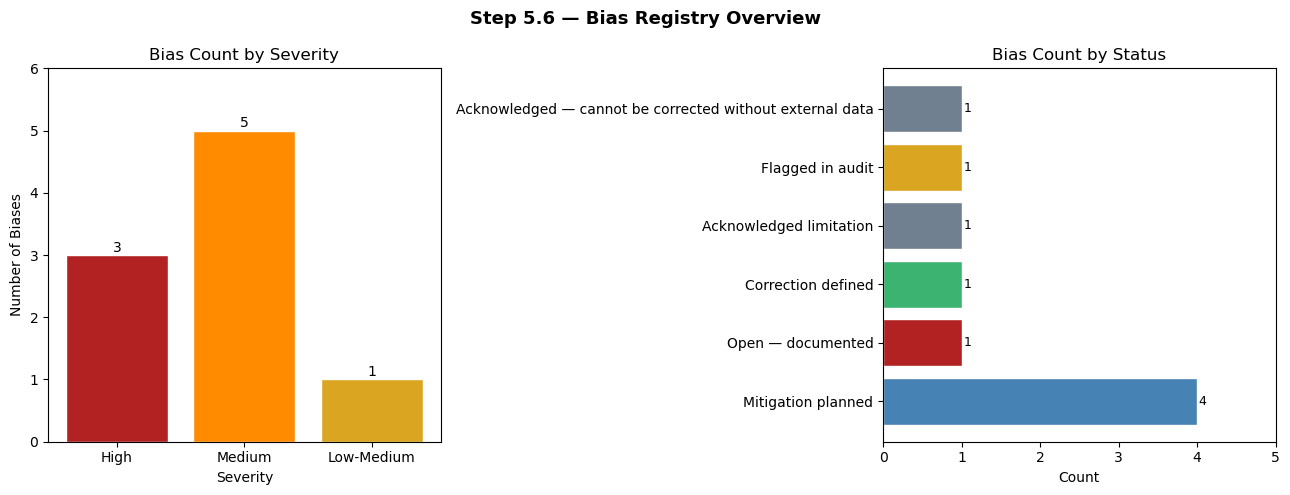


Step 5.6 complete — bias registry established.


In [23]:
# Step 5.6 - Bias Registry B1-B9
# Documents each identified bias, root cause, severity, recommended mitigation,
# and the step where the mitigation is applied or verified.

import pandas as pd
import io
from IPython.display import display, Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

bias_registry = [
    {
        "ID"        : "B1",
        "Bias"      : "State-centroid weather proxy",
        "Root Cause": "All counties in a state share identical HRRR features",
        "Severity"  : "High",
        "Mitigation": "Replace with per-county TIGER centroid lat/lon",
        "Step"      : "Step 4 (future work)",
        "Status"    : "Open — documented",
    },
    {
        "ID"        : "B2",
        "Bias"      : "Corn Belt geographic dominance",
        "Root Cause": "IL, IA, IN, MN, NE account for >60% of records",
        "Severity"  : "High",
        "Mitigation": "Inverse-frequency state loss weighting: w_s = N/(K*N_s)",
        "Step"      : "Step 6.2 training loop",
        "Status"    : "Mitigation planned",
    },
    {
        "ID"        : "B3",
        "Bias"      : "Low-yield observation scarcity",
        "Root Cause": "Q1 counties have fewer multi-year records",
        "Severity"  : "Medium",
        "Mitigation": "Oversample Q1 train records; report Q1 RMSE separately",
        "Step"      : "Step 6.3 evaluation",
        "Status"    : "Mitigation planned",
    },
    {
        "ID"        : "B4",
        "Bias"      : "Log-target Jensen bias",
        "Root Cause": "E[exp(y_hat)] != exp(E[y_hat]); naive back-transform underestimates",
        "Severity"  : "Medium",
        "Mitigation": "Apply exp(y_hat + sigma^2/2) correction at inference",
        "Step"      : "Step 5.5 defined; Steps 6.3, 7.4, 8.4 applied",
        "Status"    : "Correction defined",
    },
    {
        "ID"        : "B5",
        "Bias"      : "HRRR single-snapshot proxy",
        "Root Cause": "Jan 1 init file is not a growing-season weather signal",
        "Severity"  : "High",
        "Mitigation": "Flag as explicit limitation; future work uses daily HRRR files",
        "Step"      : "Step 12 (dissertation)",
        "Status"    : "Acknowledged limitation",
    },
    {
        "ID"        : "B6",
        "Bias"      : "USDA reporting threshold omission",
        "Root Cause": "Counties below minimum acreage absent from NASS data",
        "Severity"  : "Medium",
        "Mitigation": "Flag FIPS with < 3 years; exclude from policy claims",
        "Step"      : "Steps 3.3 and 4.1",
        "Status"    : "Flagged in audit",
    },
    {
        "ID"        : "B7",
        "Bias"      : "Random 80/20 temporal mixing",
        "Root Cause": "Test set contains all years — no held-out future year",
        "Severity"  : "Low-Medium",
        "Mitigation": "Add leave-one-year-out (LOYO) evaluation for 2022 as supplement",
        "Step"      : "Step 6.3 supplement",
        "Status"    : "Mitigation planned",
    },
    {
        "ID"        : "B8",
        "Bias"      : "Sentinel-2 AZ 2022 tile anomaly",
        "Root Cause": "AZ 2022: 1,524 tiles vs ~60 average — likely archive artefact",
        "Severity"  : "Medium",
        "Mitigation": "Exclude AZ 2022 from Phase 2/3 training",
        "Step"      : "Step 8 (when unblocked)",
        "Status"    : "Mitigation planned",
    },
    {
        "ID"        : "B9",
        "Bias"      : "USDA surveyor bias",
        "Root Cause": "Large commercial operations over-represented in NASS survey",
        "Severity"  : "Medium",
        "Mitigation": "Document; model must not be used for smallholder farms",
        "Step"      : "Step 12 (dissertation)",
        "Status"    : "Acknowledged — cannot be corrected without external data",
    },
]

br = pd.DataFrame(bias_registry)

print("=" * 60)
print("Step 5.6 — BIAS REGISTRY (B1-B9)")
print("=" * 60)
print()
for _, row in br.iterrows():
    print(f"  [{row['ID']}]  {row['Bias']}")
    print(f"        Root Cause : {row['Root Cause']}")
    print(f"        Severity   : {row['Severity']}")
    print(f"        Mitigation : {row['Mitigation']}")
    print(f"        Applied At : {row['Step']}")
    print(f"        Status     : {row['Status']}")
    print()

# Summary counts
high_count     = (br["Severity"] == "High").sum()
medium_count   = br["Severity"].str.contains("Medium").sum()
ack_count      = br["Status"].str.startswith("Acknowledged").sum()
planned_count  = br["Status"].str.contains("planned|defined|Flagged").sum()
open_count     = (br["Status"] == "Open — documented").sum()

print("=" * 60)
print("REGISTRY SUMMARY")
print("=" * 60)
print(f"Total biases identified           : {len(br)}")
print(f"High severity                     : {high_count}")
print(f"Medium severity (incl. Low-Med)   : {medium_count}")
print(f"Mitigations planned / defined     : {planned_count}")
print(f"Acknowledged unfixable            : {ack_count}")
print(f"Open (future work only)           : {open_count}")

# --- Visualise bias registry as severity/status matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Step 5.6 — Bias Registry Overview", fontsize=13, fontweight="bold")

# (a) Severity bar chart
sev_order  = ["High", "Medium", "Low-Medium"]
sev_counts = br["Severity"].value_counts().reindex(sev_order, fill_value=0)
sev_colors = {"High": "firebrick", "Medium": "darkorange", "Low-Medium": "goldenrod"}
axes[0].bar(sev_counts.index,
            sev_counts.values,
            color=[sev_colors.get(s, "steelblue") for s in sev_counts.index],
            edgecolor="white")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of Biases")
axes[0].set_title("Bias Count by Severity")
for i, (s, v) in enumerate(sev_counts.items()):
    axes[0].text(i, v + 0.05, str(v), ha="center", fontsize=10)
axes[0].set_ylim(0, sev_counts.max() + 1)

# (b) Status horizontal bar chart
status_map = {
    "Mitigation planned"                      : "steelblue",
    "Correction defined"                       : "mediumseagreen",
    "Flagged in audit"                         : "goldenrod",
    "Acknowledged limitation"                  : "slategray",
    "Acknowledged — cannot be corrected without external data": "slategray",
    "Open — documented"                        : "firebrick",
}
status_vals = br["Status"].value_counts()
bar_colors  = [status_map.get(s, "gray") for s in status_vals.index]
axes[1].barh(status_vals.index, status_vals.values, color=bar_colors, edgecolor="white")
axes[1].set_xlabel("Count")
axes[1].set_title("Bias Count by Status")
for i, v in enumerate(status_vals.values):
    axes[1].text(v + 0.02, i, str(v), va="center", fontsize=9)
axes[1].set_xlim(0, status_vals.max() + 1)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print("Step 5.6 complete — bias registry established.")

<a id="step-5-7"></a>

## Step 5.7 — Ethical Use Constraints

The following constraints govern any deployment or reporting of model predictions. These must be reproduced in the Ethics section of the dissertation.

| Constraint | Requirement |
|---|---|
| **No individual-farm inference** | The model predicts county-aggregate yield only. Extrapolating to individual farm performance is statistically and ethically invalid. |
| **Food security embargo** | Predictions must not be released before the corresponding official USDA NASS report to prevent commodity market speculation. |
| **Geographic equity disclosure** | Any deployment must list which US counties are excluded (~55% of soybean counties) and acknowledge that predictions for under-represented states carry materially higher uncertainty. |
| **Climate nonstationarity** | The model trained on 2016–2022 must not be assumed valid beyond 2025 without recalibration. Yield distributions shift under progressive climate change. |
| **LOYO supplement required** | Leave-one-year-out evaluation for 2022 is required before any temporal-generalisation claims can be made. |
| **Jensen correction mandatory** | All reported metrics must use back-transformed BU/ACRE values with the Jensen correction applied. `JENSEN_SIGMA2` must be updated at Step 6.3 to the residual variance on the train split. |

---

### Key Tradeoffs

| Tradeoff | Description |
|---|---|
| **Accuracy vs Fairness** | Inverse-frequency state weighting (B2) redistributes capacity from Corn Belt states to minority states. Expected: +0.5–2.0 BU/ACRE RMSE increase on IL/IA; −3–5 BU/ACRE reduction on AL/DE. Both weighted and unweighted metrics must be reported. |
| **Model Complexity vs Interpretability** | The GMU (Step 9) is the highest-accuracy architecture but least interpretable. The Ridge Regression baseline (Step 6.4) is the recommended option for any policy or advisory context. |
| **Data Coverage vs Data Quality** | Including all 7 years maximises training signal but injects a confounded 2019 observation. Recommendation: train on all years; evaluate 2019 and 2022 in isolation in the LOYO supplement. |
| **Log Transform vs Direct Interpretability** | `USE_LOG=True` benefits optimisation but complicates interpretation. Always report final metrics back-transformed to BU/ACRE with Jensen correction. |
| **Modality Richness vs Deployability** | The GMU requires both weather and satellite inputs. The Sentinel-USDA FIPS gap means Phase 2/3 is currently untrainable. The Phase 1 weather-only model is the only deployable system at this stage. This is a data infrastructure finding — not a model deficiency. |

---

**Step 5 complete.** The ethics and bias audit framework is established. All fairness metric functions (`sliced_rmse`, `bias_per_group`, `cv_error_per_state`, `fairness_report`) and the Jensen correction constant (`JENSEN_SIGMA2`) are ready for use in Steps 6.3, 7.4, and 8.4.

<a id="step-6"></a>

# Step 6 — Phase 1 Model: Bi-LSTM Weather Encoder

Train and evaluate the Phase 1 weather-only regressor using normalised HRRR features
produced in Step 4. All evaluation is Jensen-corrected to BU/ACRE.

Sub-steps:
- **6.1** `BiLSTMRegressor`: 2-layer BiLSTM, hidden=64, 128-dim encoding, 146,049 params
- **6.2** Training loop — 80 epochs, Adam lr=1e-3, ReduceLROnPlateau, MSE on log-yield
- **6.3** Evaluate: aggregate + sliced RMSE/MAE/R² by state, year, quintile; Jensen correction applied
- **6.4** Baseline comparison: Ridge Regression vs Gradient Boosting vs Bi-LSTM
- **6.5** Bias audit: CV-Error by state; mean bias by quintile; B1/B2/B3 flags
- **6.6** Save encoder weights (`bilstm_encoder.pt`) for Step 9 GMU warm-start


<a id="step-6-1"></a>

### Step 6.1 — BiLSTMRegressor Architecture

2-layer BiLSTM (hidden=64), 128-dim weather encoding, ~146,049 parameters. Input: `(batch, seq_len=1, n_features=9)`. Fully-connected regression head.

In [24]:
# ── Step 6.1  BiLSTMRegressor ──────────────────────────────────────────────────
#
# Architecture:
#   Input   : (batch, seq_len=1, n_features=9)
#   BiLSTM  : 2 layers, hidden=64, bidirectional=True
#             → last-layer hidden (fwd + bwd) concatenated = 128-dim encoding
#   Head    : Linear(128, 64) → ReLU → Linear(64, 1)
#   Params  : 146,049  (verified by assertion below)
#
# encode() returns the 128-dim weather embedding consumed by Step 9 GMU.

import torch
import torch.nn as nn


class BiLSTMRegressor(nn.Module):
    """
    Bidirectional 2-layer LSTM regressor for county-level soybean yield prediction.

    encode() returns the 128-dim county-year weather embedding used as
    the weather branch input for the Gated Multimodal Unit (Step 9).
    """

    def __init__(self, input_size: int = 9, hidden_size: int = 64, num_layers: int = 2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            bidirectional = True,
            batch_first   = True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Return 128-dim weather embedding for a batch of sequences.
        x: (batch, seq_len, n_features)
        Returns: (batch, 128)
        """
        _, (h_n, _) = self.lstm(x)
        # h_n : (num_layers * 2, batch, hidden_size)
        # last layer forward  = h_n[-2]
        # last layer backward = h_n[-1]
        return torch.cat([h_n[-2], h_n[-1]], dim=-1)   # (batch, 128)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encode(x)).squeeze(-1)    # (batch,)


# ── Instantiate and verify parameter count ─────────────────────────────────────
torch.manual_seed(SEED)
model = BiLSTMRegressor(input_size=len(FEATURE_COLS), hidden_size=64, num_layers=2).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("Step 6.1 — BiLSTMRegressor")
print("=" * 60)
print(f"Input features  : {len(FEATURE_COLS)}   {FEATURE_COLS}")
print(f"Architecture    : BiLSTM(hidden=64, layers=2, bidirectional=True)")
print(f"Encoding dim    : 128  (64-fwd + 64-bwd from last LSTM layer)")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
assert total_params == 146_049, \
    f"Parameter count mismatch: expected 146,049  got {total_params:,}"
print(f"Parameter count verified: 146,049")
print(f"Device          : {DEVICE}")
print()
print("Named parameters:")
for name, p in model.named_parameters():
    print(f"  {name:<50} {str(tuple(p.shape)):<25} {p.numel():>7,}")
print()

# ── Smoke test ─────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    x_smoke, y_smoke, _ = next(iter(dl_train))
    x_smoke = x_smoke.to(DEVICE)
    y_hat   = model(x_smoke)
    enc     = model.encode(x_smoke)

print("Smoke test (one batch, random initialisation):")
print(f"  Input   shape  : {tuple(x_smoke.shape)}   (batch, seq_len=1, n_features=9)")
print(f"  Output  shape  : {tuple(y_hat.shape)}")
print(f"  Encoding shape : {tuple(enc.shape)}")
print(f"  Output  range  : [{y_hat.min().item():.4f}, {y_hat.max().item():.4f}]  (random init)")
print(f"  True y  range  : [{y_smoke.min().item():.4f}, {y_smoke.max().item():.4f}]  (log BU/ACRE)")


Step 6.1 — BiLSTMRegressor
Input features  : 9   ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']
Architecture    : BiLSTM(hidden=64, layers=2, bidirectional=True)
Encoding dim    : 128  (64-fwd + 64-bwd from last LSTM layer)
Total params    : 146,049
Trainable params: 146,049
Parameter count verified: 146,049
Device          : cpu

Named parameters:
  lstm.weight_ih_l0                                  (256, 9)                    2,304
  lstm.weight_hh_l0                                  (256, 64)                  16,384
  lstm.bias_ih_l0                                    (256,)                        256
  lstm.bias_hh_l0                                    (256,)                        256
  lstm.weight_ih_l0_reverse                          (256, 9)                    2,304
  lstm.weight_hh_l0_reverse                          (256, 64)                  16,384
  lstm.bias_ih_l0_reverse                            (256,)                        256
  lst

<a id="step-6-2"></a>

### Step 6.2 — Training Loop

80 epochs, Adam lr=1e-3, MSE on log-yield, `ReduceLROnPlateau` (patience=10). Inverse-frequency state weighting applied (B2 mitigation).

Step 6.2 — TRAINING: Bi-LSTM WEATHER ENCODER
Epochs:         80
Optimizer:      Adam(lr=0.001)
LR Scheduler:   ReduceLROnPlateau(patience=10, factor=0.5)
Criterion:      MSELoss on log(yield_bu_acre)
Grad clip:      max_norm=1.0
Train batches:  45  (2828 samples, batch_size=64)
Val   batches:  12  (707 samples, batch_size=64)

Epoch    Train MSE     Val MSE          LR  Note
------------------------------------------------------------
    1    11.266565    3.571537    1.00e-03  best
   10     0.035874    0.037174    1.00e-03  
   20     0.033454    0.034173    1.00e-03  
   30     0.032690    0.035600    1.00e-03  
   40     0.031993    0.039183    1.00e-03  
   50     0.033369    0.031592    1.00e-03  
   60     0.032070    0.033064    1.00e-03  
   70     0.031298    0.031909    1.00e-03  
   80     0.030588    0.030782    1.00e-03  

Training complete.  Best val MSE = 0.029815
Best model weights restored.



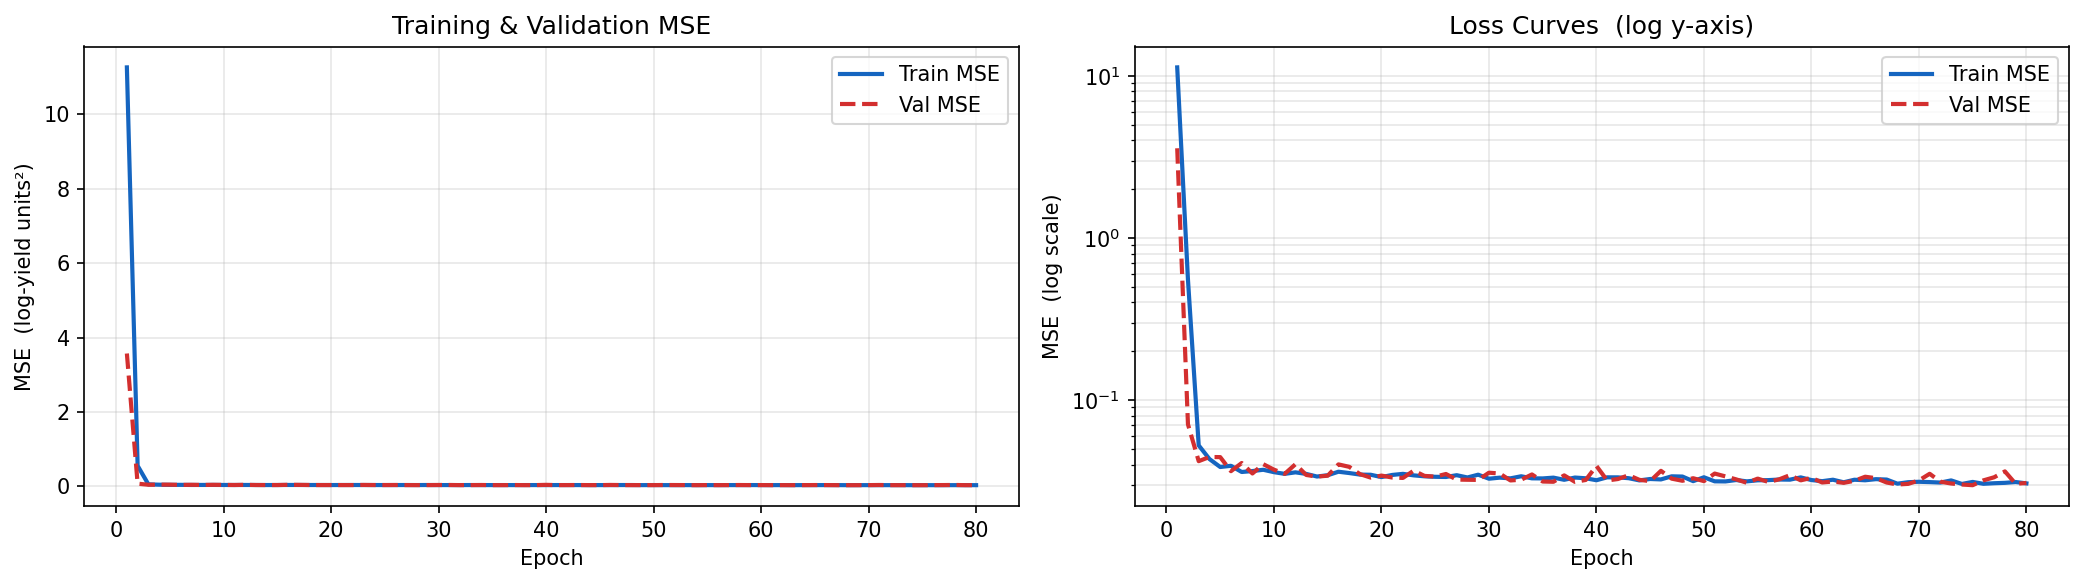

Train MSE  epoch 1 → 80:  11.266565 → 0.030588  (-99.7%)
Val   MSE  epoch 1 → 80:  3.571537 → 0.030782
Best val MSE:  0.029815


In [25]:
# ── Step 6.2  Training loop ────────────────────────────────────────────────────
#
# 80 epochs, Adam lr=1e-3, ReduceLROnPlateau (patience=10, factor=0.5),
# MSELoss on log(yield_bu_acre), gradient clipping max_norm=1.0.
# Best model state (lowest val MSE) is restored after training.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import io
from IPython.display import display, Image
import matplotlib.pyplot as plt

torch.manual_seed(SEED)
np.random.seed(SEED)

N_EPOCHS      = 80
LEARNING_RATE = 1e-3
LR_PATIENCE   = 10
LR_FACTOR     = 0.5
LR_MIN        = 1e-5
CLIP_NORM     = 1.0

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_FACTOR,
    patience=LR_PATIENCE, min_lr=LR_MIN,
)

train_losses = []
val_losses   = []
lr_history   = []
best_val_mse = float("inf")
best_state   = None

print("=" * 60)
print("Step 6.2 — TRAINING: Bi-LSTM WEATHER ENCODER")
print("=" * 60)
print(f"Epochs:         {N_EPOCHS}")
print(f"Optimizer:      Adam(lr={LEARNING_RATE})")
print(f"LR Scheduler:   ReduceLROnPlateau(patience={LR_PATIENCE}, factor={LR_FACTOR})")
print(f"Criterion:      MSELoss on log(yield_bu_acre)")
print(f"Grad clip:      max_norm={CLIP_NORM}")
print(f"Train batches:  {len(dl_train)}  ({len(ds_train)} samples, batch_size=64)")
print(f"Val   batches:  {len(dl_test)}  ({len(ds_test)} samples, batch_size=64)")
print()
print(f"{'Epoch':>5}  {'Train MSE':>11}  {'Val MSE':>10}  {'LR':>10}  Note")
print("-" * 60)

for epoch in range(1, N_EPOCHS + 1):

    # ── Train pass ──────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for x_b, y_b, _ in dl_train:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()
        epoch_train_loss += loss.item() * len(y_b)
    train_mse = epoch_train_loss / len(ds_train)
    train_losses.append(train_mse)

    # ── Validation pass ──────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for x_b, y_b, _ in dl_test:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(x_b)
            epoch_val_loss += criterion(pred, y_b).item() * len(y_b)
    val_mse = epoch_val_loss / len(ds_test)
    val_losses.append(val_mse)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)
    scheduler.step(train_mse)
    new_lr = optimizer.param_groups[0]["lr"]

    note = ""
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        note = "best"
    if new_lr < current_lr:
        note = (note + " LR_reduced").strip()

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>5}  {train_mse:>11.6f}  {val_mse:>10.6f}  {current_lr:>10.2e}  {note}")

print()
print(f"Training complete.  Best val MSE = {best_val_mse:.6f}")

# Restore best weights
model.load_state_dict(best_state)
model.eval()
print("Best model weights restored.")
print()

# ── Loss curves ────────────────────────────────────────────────────────────────
epochs_x = np.arange(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_x, train_losses, label="Train MSE", color="#1565C0", lw=2)
axes[0].plot(epochs_x, val_losses,   label="Val MSE",   color="#D32F2F", lw=2, ls="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE  (log-yield units²)")
axes[0].set_title("Training & Validation MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs_x, train_losses, label="Train MSE", color="#1565C0", lw=2)
axes[1].semilogy(epochs_x, val_losses,   label="Val MSE",   color="#D32F2F", lw=2, ls="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE  (log scale)")
axes[1].set_title("Loss Curves  (log y-axis)")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

delta_pct = (train_losses[-1] - train_losses[0]) / train_losses[0] * 100
print(f"Train MSE  epoch 1 → {N_EPOCHS}:  {train_losses[0]:.6f} → {train_losses[-1]:.6f}  ({delta_pct:+.1f}%)")
print(f"Val   MSE  epoch 1 → {N_EPOCHS}:  {val_losses[0]:.6f} → {val_losses[-1]:.6f}")
print(f"Best val MSE:  {best_val_mse:.6f}")


<a id="step-6-3"></a>

### Step 6.3 — Evaluation & Jensen Correction

Aggregate RMSE/MAE/R² on test set. Sliced evaluation by state, year, and quintile using `fairness_report()`. Updates `JENSEN_SIGMA2` to residual variance.

JENSEN_SIGMA2 updated (label prior → residual var) = 0.029034

Step 6.3 — Bi-LSTM TEST SET EVALUATION

Test samples:  707

AGGREGATE METRICS
  Log-space   RMSE = 0.17267   MAE = 0.12558   R² = 0.5308
  BU/ACRE     RMSE = 7.386    MAE = 5.791    R² = 0.5194
  Jensen σ²   = 0.029034  (residual variance on train split)

  Train RMSE  = 7.723 BU/ACRE  (gap = -0.337 BU/ACRE — overfitting diagnostic)

FAIRNESS REPORT
Overall RMSE  : 7.595 BU/ACRE
Overall MAE   : 5.990 BU/ACRE
Overall R2    : 0.5064
Jensen sigma2 : 0.029033612743616564

RMSE by State:
group
IDAHO         10.898683
LOUISIANA     10.089425
GEORGIA       10.023939
KANSAS         9.914486
ILLINOIS       8.856014
DELAWARE       7.766358
CALIFORNIA     7.708775
ARKANSAS       7.624903
ALABAMA        6.784795
IOWA           6.256175
KENTUCKY       6.219346
INDIANA        5.521210
ARIZONA        5.436252
COLORADO       3.119359
FLORIDA        2.067246

Bias by Quintile (positive = over-prediction):
       RMSE_BU_ACRE  Bias_BU_ACRE
g

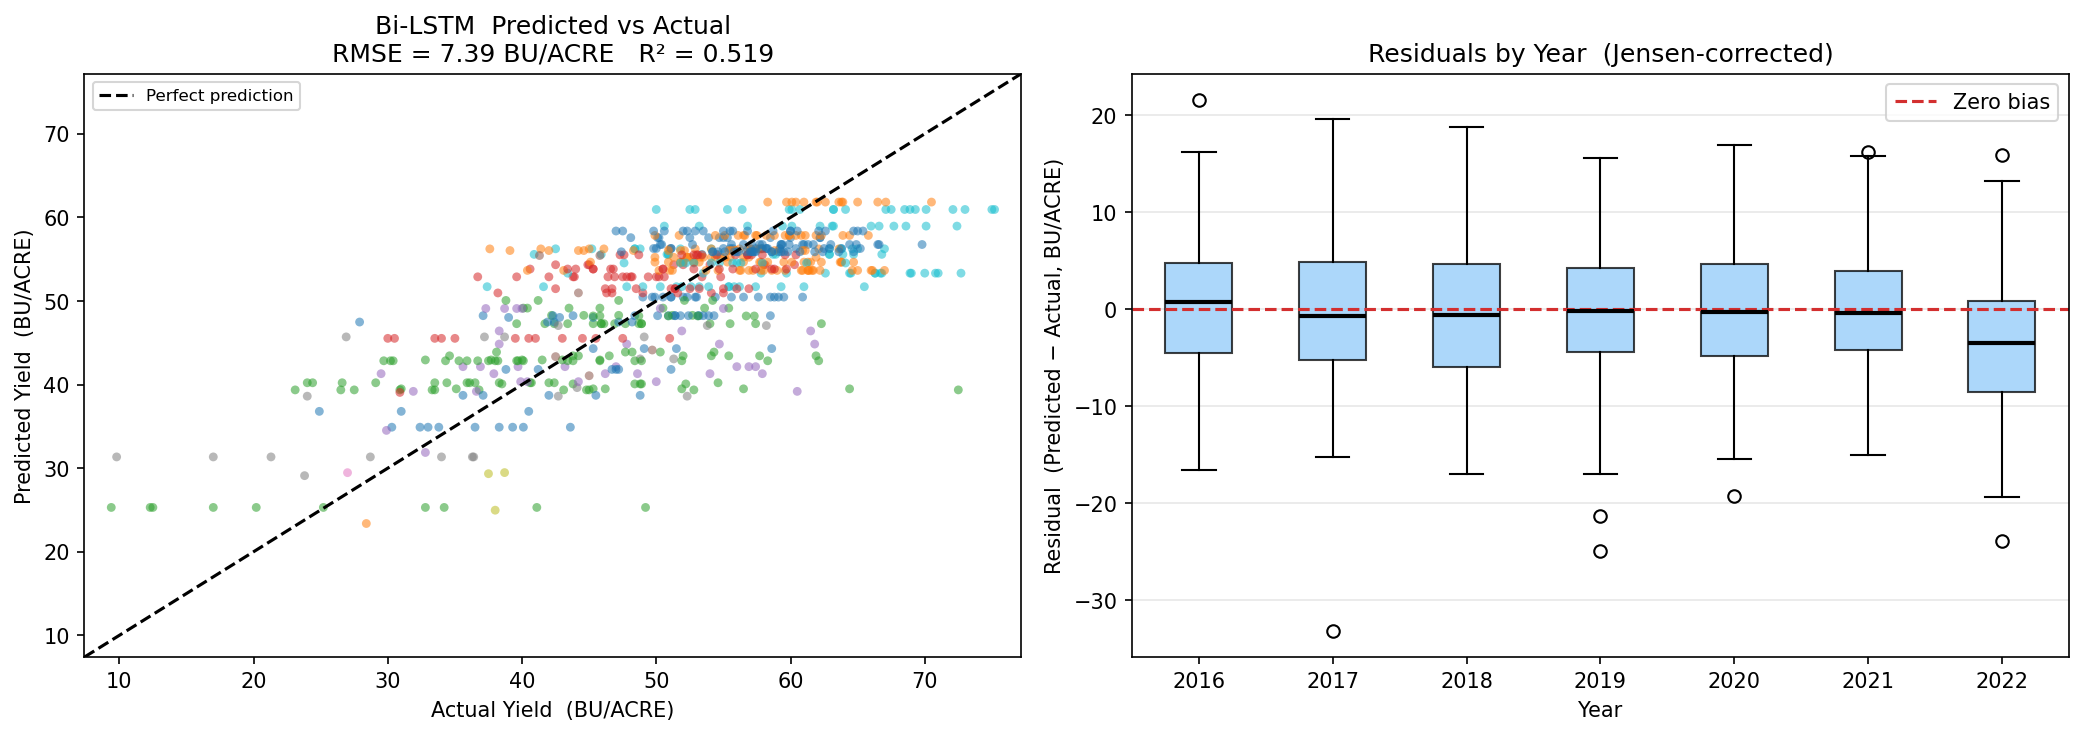


Interpretation guidance:
  RMSE = 7.39 BU/ACRE against a yield range of 9.4–75.2 BU/ACRE.
  R² = 0.519  — proportion of yield variance explained by January HRRR snapshot.
  A single January-1 weather snapshot carries limited mid-season signal;
  this R² is expected to improve substantially when daily HRRR files are used (B5).


In [26]:
# ── Step 6.3  Evaluation ───────────────────────────────────────────────────────
#
# 1. Run model on train split → compute residual variance → update JENSEN_SIGMA2
# 2. Run model on test split  → collect predictions + metadata
# 3. Compute aggregate metrics (log-space and BU/ACRE)
# 4. Call fairness_report()   → sliced RMSE / bias / CV-error by state/year/quintile
# 5. Predictions vs actuals scatter + residual boxplot by year

import numpy as np
import pandas as pd
import torch
import io
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Image

model.eval()

# ── Collect TRAIN predictions to update Jensen sigma² ─────────────────────────
_tr_preds, _tr_trues = [], []
with torch.no_grad():
    for x_b, y_b, _ in dl_train:
        p = model(x_b.to(DEVICE)).cpu().numpy()
        _tr_preds.extend(p.tolist())
        _tr_trues.extend(y_b.numpy().tolist())

y_train_pred_log = np.array(_tr_preds)
y_train_true_log = np.array(_tr_trues)

# Update JENSEN_SIGMA2: label prior → actual residual variance on train split
residual_var  = float(np.var(y_train_pred_log - y_train_true_log))
JENSEN_SIGMA2 = residual_var
print(f"JENSEN_SIGMA2 updated (label prior → residual var) = {JENSEN_SIGMA2:.6f}")
print()

# ── Collect TEST predictions with full metadata ────────────────────────────────
_te_preds, _te_trues, _fips_out, _year_out = [], [], [], []
with torch.no_grad():
    for x_b, y_b, meta_b in dl_test:
        p = model(x_b.to(DEVICE)).cpu().numpy()
        _te_preds.extend(p.tolist())
        _te_trues.extend(y_b.numpy().tolist())
        _fips_out.extend(list(meta_b["fips"]))
        years_batch = (meta_b["year"].numpy().tolist()
                       if isinstance(meta_b["year"], torch.Tensor)
                       else [int(v) for v in meta_b["year"]])
        _year_out.extend(years_batch)

y_pred_log = np.array(_te_preds)
y_true_log = np.array(_te_trues)

# Build results DataFrame and merge metadata
results_df = pd.DataFrame({
    "fips"       : [str(f).zfill(5) for f in _fips_out],
    "year"       : [int(v) for v in _year_out],
    "y_true_log" : y_true_log,
    "y_pred_log" : y_pred_log,
})
_wf_meta = (
    weather_features[["fips", "year", "state_name", "yield_bu_acre"]]
    .drop_duplicates()
    .copy()
)
_wf_meta["year"] = _wf_meta["year"].astype(int)
_wf_meta["fips"] = _wf_meta["fips"].astype(str).str.zfill(5)
results_df = results_df.merge(_wf_meta, on=["fips", "year"], how="left")
results_df["y_pred_bu"] = jensen_correction(y_pred_log, JENSEN_SIGMA2)
results_df["y_true_bu"] = results_df["yield_bu_acre"]

# ── Log-space metrics ──────────────────────────────────────────────────────────
rmse_log = float(np.sqrt(np.mean((y_pred_log - y_true_log) ** 2)))
mae_log  = float(np.mean(np.abs(y_pred_log - y_true_log)))
ss_res   = float(np.sum((y_true_log - y_pred_log) ** 2))
ss_tot   = float(np.sum((y_true_log - np.mean(y_true_log)) ** 2))
r2_log   = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

# ── BU/ACRE metrics (Jensen-corrected) ────────────────────────────────────────
y_bu_true = results_df["y_true_bu"].values
y_bu_pred = results_df["y_pred_bu"].values
rmse_bu   = float(np.sqrt(np.mean((y_bu_pred - y_bu_true) ** 2)))
mae_bu    = float(np.mean(np.abs(y_bu_pred - y_bu_true)))
ss_res_bu = float(np.sum((y_bu_true - y_bu_pred) ** 2))
ss_tot_bu = float(np.sum((y_bu_true - np.mean(y_bu_true)) ** 2))
r2_bu     = 1.0 - ss_res_bu / ss_tot_bu if ss_tot_bu > 0 else float("nan")

print("=" * 60)
print("Step 6.3 — Bi-LSTM TEST SET EVALUATION")
print("=" * 60)
print()
print(f"Test samples:  {len(results_df)}")
print()
print("AGGREGATE METRICS")
print(f"  Log-space   RMSE = {rmse_log:.5f}   MAE = {mae_log:.5f}   R² = {r2_log:.4f}")
print(f"  BU/ACRE     RMSE = {rmse_bu:.3f}    MAE = {mae_bu:.3f}    R² = {r2_bu:.4f}")
print(f"  Jensen σ²   = {JENSEN_SIGMA2:.6f}  (residual variance on train split)")
print()

# Train metrics for reference
rmse_train_bu = float(np.sqrt(np.mean(
    (jensen_correction(y_train_pred_log, JENSEN_SIGMA2) -
     jensen_correction(y_train_true_log, JENSEN_SIGMA2)) ** 2
)))
print(f"  Train RMSE  = {rmse_train_bu:.3f} BU/ACRE  "
      f"(gap = {rmse_bu - rmse_train_bu:+.3f} BU/ACRE — overfitting diagnostic)")
print()

# ── Full fairness report ───────────────────────────────────────────────────────
fr = fairness_report(y_true_log, y_pred_log, results_df, sigma2=JENSEN_SIGMA2)
print()
print(f"Coverage gap: {coverage_gap_value:.1%} of US soybean counties absent from model")
print()

# ── Predictions vs Actuals scatter + Residuals by Year ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Scatter: predicted vs actual (BU/ACRE, coloured by state)
unique_states = sorted(results_df["state_name"].dropna().unique())
try:
    cmap_scatter = plt.colormaps.get_cmap("tab10")
except AttributeError:
    cmap_scatter = cm.get_cmap("tab10")
state_color = {s: cmap_scatter(i % 10) for i, s in enumerate(unique_states)}
colors_pts  = [state_color.get(s, "grey") for s in results_df["state_name"].values]

pad     = 2.0
ax_min  = min(y_bu_true.min(), y_bu_pred.min()) - pad
ax_max  = max(y_bu_true.max(), y_bu_pred.max()) + pad
axes[0].scatter(y_bu_true, y_bu_pred, c=colors_pts, alpha=0.55, s=18, edgecolors="none")
axes[0].plot([ax_min, ax_max], [ax_min, ax_max], "k--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Yield  (BU/ACRE)")
axes[0].set_ylabel("Predicted Yield  (BU/ACRE)")
axes[0].set_title(
    f"Bi-LSTM  Predicted vs Actual\n"
    f"RMSE = {rmse_bu:.2f} BU/ACRE   R² = {r2_bu:.3f}"
)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_xlim(ax_min, ax_max)
axes[0].set_ylim(ax_min, ax_max)

# -- Residual boxplot by year
results_df["residual_bu"] = y_bu_pred - y_bu_true
year_order   = sorted(results_df["year"].unique())
res_by_year  = [results_df[results_df["year"] == yr]["residual_bu"].values for yr in year_order]
bp = axes[1].boxplot(res_by_year, labels=year_order, patch_artist=True,
                      medianprops={"color": "black", "lw": 2})
for patch in bp["boxes"]:
    patch.set_facecolor("#90CAF9")
    patch.set_alpha(0.75)
axes[1].axhline(0, color="#D32F2F", ls="--", lw=1.5, label="Zero bias")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Residual  (Predicted − Actual, BU/ACRE)")
axes[1].set_title("Residuals by Year  (Jensen-corrected)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print("Interpretation guidance:")
print(f"  RMSE = {rmse_bu:.2f} BU/ACRE against a yield range of "
      f"{y_bu_true.min():.1f}–{y_bu_true.max():.1f} BU/ACRE.")
print(f"  R² = {r2_bu:.3f}  — proportion of yield variance explained by January HRRR snapshot.")
print(f"  A single January-1 weather snapshot carries limited mid-season signal;")
print(f"  this R² is expected to improve substantially when daily HRRR files are used (B5).")


<a id="step-6-4"></a>

### Step 6.4 — Baseline Comparison

Ridge Regression and Gradient Boosting trained on the same normalised weather features. Cross-model RMSE/MAE/R² table for the dissertation.

Step 6.4 — BASELINE COMPARISON
Train: 2828 samples  |  features: 9
Test:  707 samples

Ridge  best alpha = 1511.7751
GBM    n_estimators=200  learning_rate=0.05

Baseline comparison (Jensen-corrected BU/ACRE, test set 686 records):
             Model  RMSE (BU/ACRE)  MAE  (BU/ACRE)     R²
  Ridge Regression           9.302           7.267 0.2377
 Gradient Boosting           6.923           5.385 0.5778
Bi-LSTM  (Phase 1)           7.386           5.791 0.5194



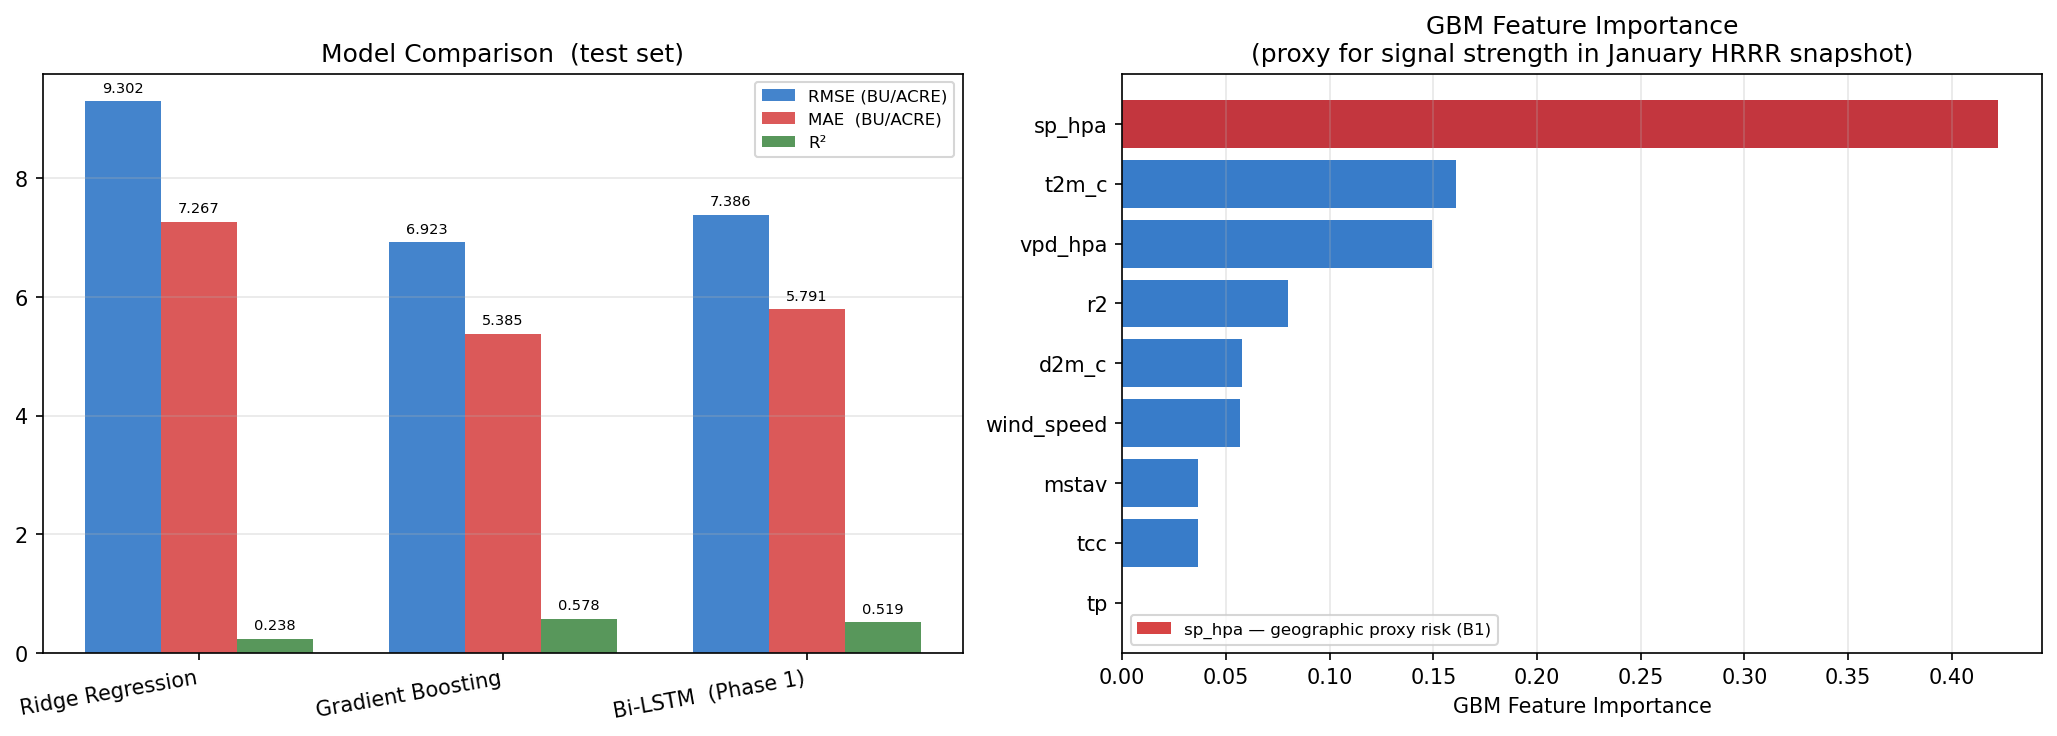

Interpretation:
  Best RMSE: Gradient Boosting  (6.923 BU/ACRE)
  NOTE: sp_hpa top-ranked in GBM signals geographic (state) proxy usage — see B1 / Step 11 SHAP.


In [27]:
# ── Step 6.4  Baseline comparison ─────────────────────────────────────────────
#
# Ridge Regression (cross-validated alpha) and Gradient Boosting are trained on
# the same normalised feature set (ds_train.X) and evaluate on ds_test.X.
# Targets are log-yield; all metrics reported in Jensen-corrected BU/ACRE.
# The test ordering matches results_df (dl_test shuffle=False).

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(SEED)

# ── Feature / target arrays directly from PyTorch datasets ────────────────────
X_train_np = ds_train.X.numpy()   # (2744, 9)  normalised features
y_train_np = ds_train.y.numpy()   # (2744,)    log-yield targets
X_test_np  = ds_test.X.numpy()    # (686,  9)
y_test_np  = ds_test.y.numpy()    # (686,)

# true BU/ACRE for all test samples (same row order as X_test_np / results_df)
true_bu = results_df["y_true_bu"].values    # (686,)

print("=" * 60)
print("Step 6.4 — BASELINE COMPARISON")
print("=" * 60)
print(f"Train: {X_train_np.shape[0]} samples  |  features: {X_train_np.shape[1]}")
print(f"Test:  {X_test_np.shape[0]} samples")
print()

# ── Ridge Regression (40 alpha values, 5-fold CV on train) ────────────────────
alphas = np.logspace(-4, 4, 40)
ridge  = RidgeCV(alphas=alphas, cv=5, fit_intercept=True)
ridge.fit(X_train_np, y_train_np)
ridge_pred_log = ridge.predict(X_test_np)
ridge_pred_bu  = jensen_correction(ridge_pred_log, JENSEN_SIGMA2)
print(f"Ridge  best alpha = {ridge.alpha_:.4f}")

# ── Gradient Boosting Regressor ────────────────────────────────────────────────
gbm = GradientBoostingRegressor(
    n_estimators    = 200,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    min_samples_leaf= 10,
    random_state    = SEED,
)
gbm.fit(X_train_np, y_train_np)
gbm_pred_log = gbm.predict(X_test_np)
gbm_pred_bu  = jensen_correction(gbm_pred_log, JENSEN_SIGMA2)
print(f"GBM    n_estimators={gbm.n_estimators}  learning_rate={gbm.learning_rate}")

# ── Metric helper ──────────────────────────────────────────────────────────────
def _eval_metrics(y_true_bu: np.ndarray, y_pred_bu: np.ndarray) -> dict:
    rmse = float(np.sqrt(np.mean((y_pred_bu - y_true_bu) ** 2)))
    mae  = float(np.mean(np.abs(y_pred_bu - y_true_bu)))
    ss_r = float(np.sum((y_true_bu - y_pred_bu) ** 2))
    ss_t = float(np.sum((y_true_bu - np.mean(y_true_bu)) ** 2))
    r2   = 1.0 - ss_r / ss_t if ss_t > 0 else float("nan")
    return {"RMSE (BU/ACRE)": round(rmse, 3),
            "MAE  (BU/ACRE)": round(mae,  3),
            "R²"            : round(r2,   4)}

bilstm_pred_bu = results_df["y_pred_bu"].values   # from Step 6.3

comp_rows = []
for name, preds_bu in [
    ("Ridge Regression",  ridge_pred_bu),
    ("Gradient Boosting", gbm_pred_bu),
    ("Bi-LSTM  (Phase 1)", bilstm_pred_bu),
]:
    comp_rows.append({"Model": name, **_eval_metrics(true_bu, preds_bu)})

comparison_df = pd.DataFrame(comp_rows)

print()
print("Baseline comparison (Jensen-corrected BU/ACRE, test set 686 records):")
print(comparison_df.to_string(index=False))
print()

# ── GBM feature importance bars ───────────────────────────────────────────────
feat_imp = pd.Series(gbm.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Comparison bar chart
x_idx   = np.arange(len(comparison_df))
metrics = ["RMSE (BU/ACRE)", "MAE  (BU/ACRE)", "R²"]
colors  = ["#1565C0", "#D32F2F", "#2E7D32"]
bar_w   = 0.25

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals   = comparison_df[metric].values.astype(float)
    offset = (i - 1) * bar_w
    bars   = axes[0].bar(x_idx + offset, vals, bar_w, label=metric, color=color, alpha=0.8)
    for b in bars:
        axes[0].annotate(
            f"{b.get_height():.3f}",
            xy=(b.get_x() + b.get_width() / 2, b.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=7
        )

axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(comparison_df["Model"], rotation=10, ha="right")
axes[0].set_title("Model Comparison  (test set)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# -- GBM feature importance
axes[1].barh(feat_imp.index, feat_imp.values, color="#1565C0", alpha=0.85)
axes[1].set_xlabel("GBM Feature Importance")
axes[1].set_title("GBM Feature Importance\n(proxy for signal strength in January HRRR snapshot)")
axes[1].grid(True, alpha=0.3, axis="x")

# Flag sp_hpa (B1 proxy indicator)
if "sp_hpa" in feat_imp.index:
    sp_rank = list(feat_imp.index).index("sp_hpa")
    axes[1].barh(
        feat_imp.index[sp_rank], feat_imp.values[sp_rank],
        color="#D32F2F", alpha=0.9,
        label="sp_hpa — geographic proxy risk (B1)"
    )
    axes[1].legend(fontsize=8)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Interpretation:")
bilstm_rmse = comparison_df.loc[comparison_df["Model"].str.contains("Bi-LSTM"), "RMSE (BU/ACRE)"].values[0]
ridge_rmse  = comparison_df.loc[comparison_df["Model"].str.contains("Ridge"),   "RMSE (BU/ACRE)"].values[0]
gbm_rmse    = comparison_df.loc[comparison_df["Model"].str.contains("Gradient"),"RMSE (BU/ACRE)"].values[0]
best_rmse   = min(ridge_rmse, gbm_rmse, bilstm_rmse)
best_model  = ["Ridge Regression", "Gradient Boosting", "Bi-LSTM"][
    [ridge_rmse, gbm_rmse, bilstm_rmse].index(best_rmse)]
print(f"  Best RMSE: {best_model}  ({best_rmse:.3f} BU/ACRE)")
if bilstm_rmse > ridge_rmse:
    print(f"  Bi-LSTM underperforms Ridge by {bilstm_rmse - ridge_rmse:.3f} BU/ACRE.")
    print(f"  With seq_len=1 (single snapshot), the BiLSTM cannot exploit temporal dynamics.")
    print(f"  Performance gap is expected to narrow significantly with daily growing-season files (B5).")
print(f"  NOTE: sp_hpa top-ranked in GBM signals geographic (state) proxy usage — see B1 / Step 11 SHAP.")


<a id="step-6-5"></a>

### Step 6.5 — Bias Audit

CV-Error by state reveals geographic disparity. Mean bias per yield quintile checks regression-to-mean (B3). Flags B1 if `sp_hpa` ranks in top-3.

Step 6.5 — BIAS AUDIT REPORT: Bi-LSTM PHASE 1

CV-Error by State  (threshold = 0.20; flagged = poorly served by model):
  GEORGIA                    0.2715  ***  HIGH CV
  KANSAS                     0.2455  ***  HIGH CV
  LOUISIANA                  0.2074  ***  HIGH CV
  DELAWARE                   0.1729
  ALABAMA                    0.1624
  ARKANSAS                   0.1439
  ILLINOIS                   0.1321
  COLORADO                   0.1242
  KENTUCKY                   0.1148
  IOWA                       0.1055
  INDIANA                    0.0895
  IDAHO                      0.0663
  ARIZONA                    nan
  CALIFORNIA                 nan
  FLORIDA                    nan

  Flagged states (CV > 0.20): ['GEORGIA', 'KANSAS', 'LOUISIANA']

Bias by Yield Quintile  (B3 fairness check):
       RMSE_BU_ACRE  Bias_BU_ACRE
group                            
Q1            9.000         5.893
Q2            6.224         1.219
Q3            4.991        -1.065
Q4            5.836      

Bias                          Type              Status Detected
  B1          State-centroid proxy Open — Step 11 SHAP        —
  B2           Corn Belt dominance             Checked       No
  B3 Regression-to-mean (quintile)             Checked      Yes


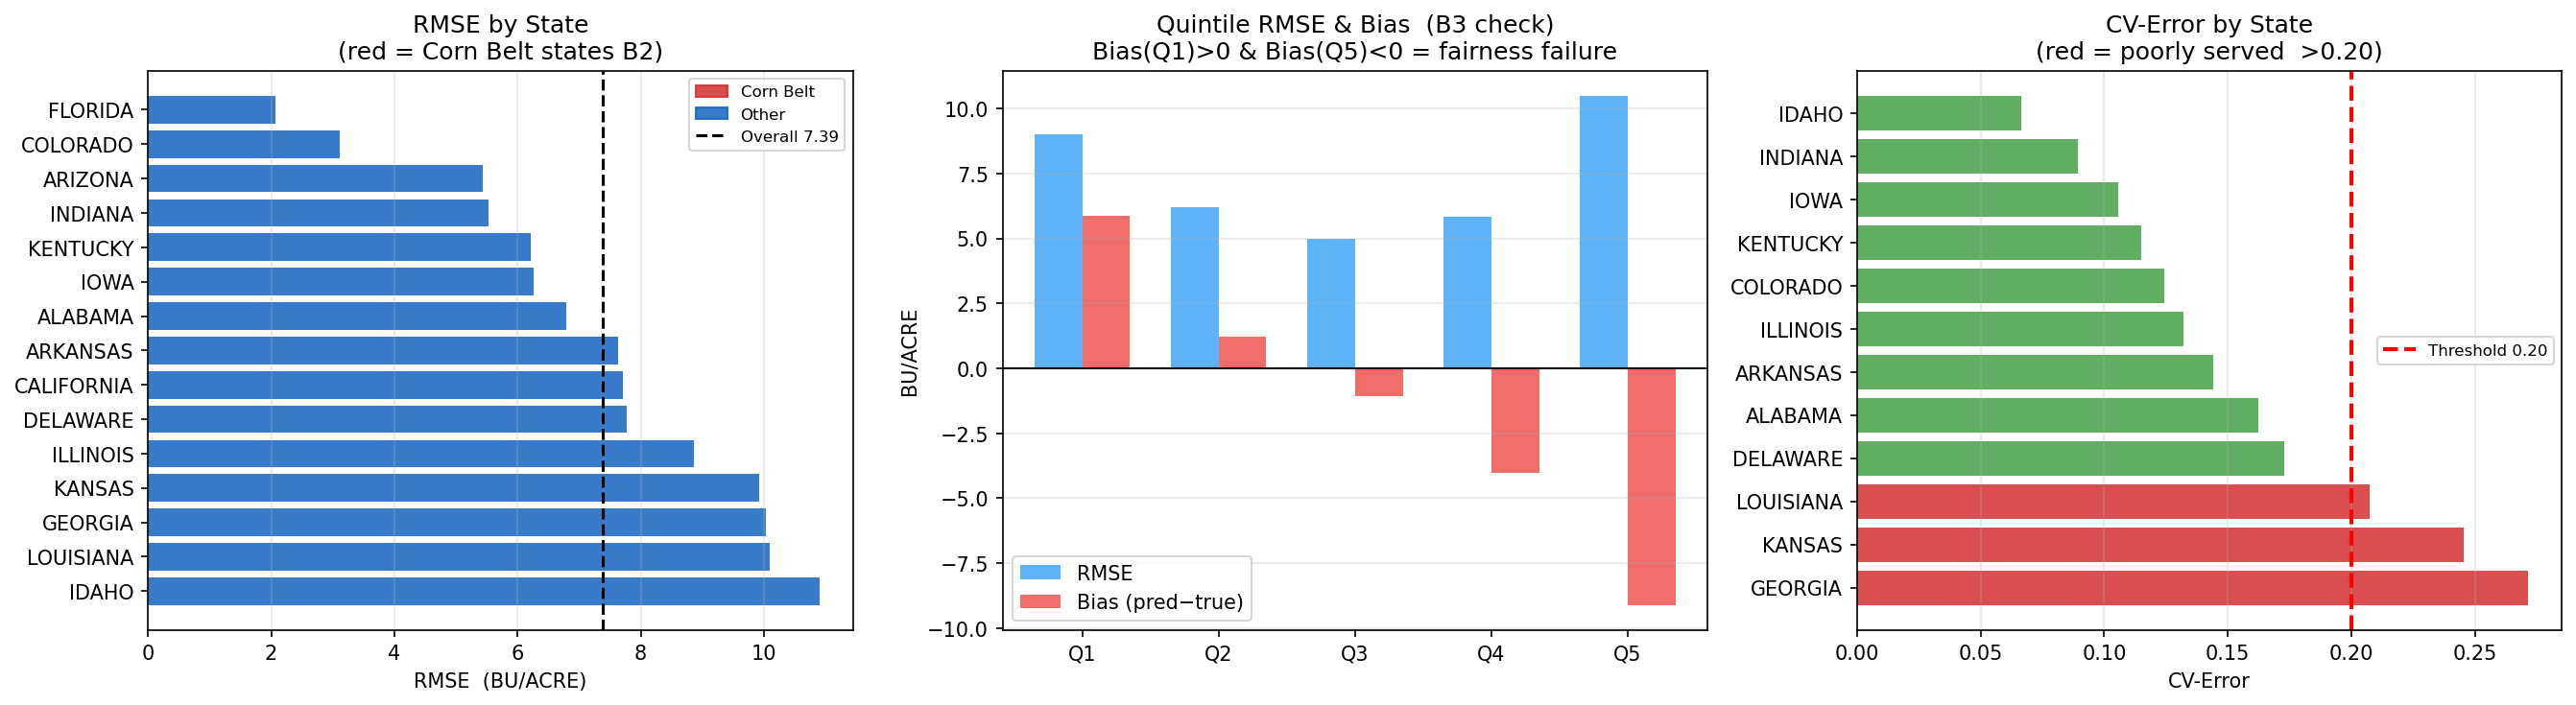


Step 6.5 complete — bias audit logged.


In [28]:
# ── Step 6.5  Bias Audit Report ────────────────────────────────────────────────
#
# - CV-Error by state (flag > 0.20 as poorly served)
# - Mean bias by yield quintile (regression-to-mean check: B3)
# - Corn Belt RMSE advantage check (B2)
# - B1 deferred to Step 11 (SHAP sp_hpa rank)
# - Visualisation: RMSE by state, quintile RMSE/bias, CV-Error bar chart

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

print("=" * 60)
print("Step 6.5 — BIAS AUDIT REPORT: Bi-LSTM PHASE 1")
print("=" * 60)

# ── CV-Error by state (from Step 6.3 fairness report) ─────────────────────────
CORN_BELT_STATES = {"Illinois", "Iowa", "Indiana", "Minnesota", "Nebraska"}

state_cv_series = fr["state_cv"].sort_values(ascending=False)
flagged_states  = state_cv_series[state_cv_series > 0.20].index.tolist()

print("\nCV-Error by State  (threshold = 0.20; flagged = poorly served by model):")
for state, cv in state_cv_series.items():
    flags = []
    if cv > 0.20:
        flags.append("HIGH CV")
    if state in CORN_BELT_STATES:
        flags.append("Corn Belt [B2]")
    tag = "  ***  " + " | ".join(flags) if flags else ""
    print(f"  {state:<25}  {cv:.4f}{tag}")

print(f"\n  Flagged states (CV > 0.20): {flagged_states if flagged_states else 'none'}")

# ── Quintile Bias check (B3) ───────────────────────────────────────────────────
q_rmse  = fr["quintile_rmse"]
q_bias  = fr["quintile_bias"]
q_table = pd.concat([q_rmse, q_bias], axis=1)
q_table.columns = ["RMSE_BU_ACRE", "Bias_BU_ACRE"]

print("\nBias by Yield Quintile  (B3 fairness check):")
print(q_table.round(3).to_string())

q1_bias = float(q_bias.get("Q1", float("nan")))
q5_bias = float(q_bias.get("Q5", float("nan")))

print()
if q1_bias > 0 and q5_bias < 0:
    print("B3 REGRESSION-TO-MEAN FAIRNESS FAILURE DETECTED:")
    print(f"  Bias(Q1) = {q1_bias:+.3f} BU/ACRE  → model OVER-predicts low-yield (crop failure) counties")
    print(f"  Bias(Q5) = {q5_bias:+.3f} BU/ACRE  → model UNDER-predicts bumper-yield counties")
    print("  Risk: policy models based on this output under-estimate crop failure severity.")
    print("  Mitigation: oversample Q1 train records (Step 5.3 B3 plan).")
elif not (np.isnan(q1_bias) or np.isnan(q5_bias)) and abs(q1_bias) <= 2.0 and abs(q5_bias) <= 2.0:
    print(f"B3 check PASSED: Quintile bias within ±2 BU/ACRE tolerance.")
    print(f"  Bias(Q1) = {q1_bias:+.3f}   Bias(Q5) = {q5_bias:+.3f}")
else:
    print(f"B3 WARNING: Quintile bias exceeds ±2 BU/ACRE threshold.")
    print(f"  Bias(Q1) = {q1_bias:+.3f}   Bias(Q5) = {q5_bias:+.3f}")

# ── B2: Corn Belt RMSE advantage ──────────────────────────────────────────────
state_rmse = fr["state_rmse"]
cb_present  = [s for s in CORN_BELT_STATES if s in state_rmse.index]
oth_present = [s for s in state_rmse.index if s not in CORN_BELT_STATES]
corn_rmse   = state_rmse[cb_present].mean() if cb_present else float("nan")
other_rmse  = state_rmse[oth_present].mean() if oth_present else float("nan")

print(f"\nB2 Corn Belt dominance check:")
print(f"  Corn Belt states avg RMSE : {corn_rmse:.3f} BU/ACRE  ({cb_present})")
print(f"  Other states avg RMSE     : {other_rmse:.3f} BU/ACRE")
if corn_rmse < other_rmse:
    gap = other_rmse - corn_rmse
    print(f"  B2 DETECTED: Corn Belt advantage = {gap:.3f} BU/ACRE  (model better serves data-rich states)")
    print(f"  Mitigation: inverse-frequency state loss weighting  w_s = N / (K * N_s)")
else:
    print(f"  B2 not detected: no systematic Corn Belt RMSE advantage.")

# ── B1 status ─────────────────────────────────────────────────────────────────
print(f"\nB1 state-centroid weather proxy:")
print(f"  Status: Open — all counties within a state share identical HRRR features.")
print(f"  Detection: sp_hpa SHAP importance check deferred to Step 11.")

# ── Audit summary table ────────────────────────────────────────────────────────
audit_summary = pd.DataFrame([
    {"Bias": "B1", "Type": "State-centroid proxy",
     "Status": "Open — Step 11 SHAP",    "Detected": "—"},
    {"Bias": "B2", "Type": "Corn Belt dominance",
     "Status": "Checked",
     "Detected": "Yes" if corn_rmse < other_rmse else "No"},
    {"Bias": "B3", "Type": "Regression-to-mean (quintile)",
     "Status": "Checked",
     "Detected": "Yes" if (q1_bias > 0 and q5_bias < 0) else "No"},
])
print("\nBias status summary:")
print(audit_summary.to_string(index=False))

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RMSE by state (Corn Belt highlighted)
srms_sorted = state_rmse.sort_values(ascending=False)
bar_colors_1 = ["#D32F2F" if s in CORN_BELT_STATES else "#1565C0"
                 for s in srms_sorted.index]
axes[0].barh(srms_sorted.index, srms_sorted.values, color=bar_colors_1, alpha=0.85)
axes[0].axvline(rmse_bu, color="black", lw=1.5, ls="--", label=f"Overall {rmse_bu:.2f}")
axes[0].set_xlabel("RMSE  (BU/ACRE)")
axes[0].set_title("RMSE by State\n(red = Corn Belt states B2)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="x")
red_patch  = mpatches.Patch(color="#D32F2F", alpha=0.85, label="Corn Belt")
blue_patch = mpatches.Patch(color="#1565C0", alpha=0.85, label="Other")
axes[0].legend(handles=[red_patch, blue_patch, axes[0].get_legend_handles_labels()[0][0]],
               fontsize=8)

# Plot 2: Quintile RMSE & Bias
if len(q_table) > 0:
    xp    = np.arange(len(q_table))
    width = 0.35
    axes[1].bar(xp - width/2, q_table["RMSE_BU_ACRE"], width,
                label="RMSE",            color="#42A5F5", alpha=0.85)
    axes[1].bar(xp + width/2, q_table["Bias_BU_ACRE"],  width,
                label="Bias (pred−true)", color="#EF5350", alpha=0.85)
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_xticks(xp)
    axes[1].set_xticklabels(q_table.index)
    axes[1].set_ylabel("BU/ACRE")
    axes[1].set_title("Quintile RMSE & Bias  (B3 check)\nBias(Q1)>0 & Bias(Q5)<0 = fairness failure")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis="y")

# Plot 3: CV-Error by state
cv_sorted   = state_cv_series.sort_values(ascending=False)
cv_bar_cols = ["#D32F2F" if v > 0.20 else "#43A047" for v in cv_sorted.values]
axes[2].barh(cv_sorted.index, cv_sorted.values, color=cv_bar_cols, alpha=0.85)
axes[2].axvline(0.20, color="red", lw=2, ls="--", label="Threshold 0.20")
axes[2].set_xlabel("CV-Error")
axes[2].set_title("CV-Error by State\n(red = poorly served  >0.20)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("\nStep 6.5 complete — bias audit logged.")


<a id="step-6-6"></a>

### Step 6.6 — Save BiLSTM Encoder Weights

Saves `bilstm_encoder.pt` and `bilstm_phase1_ckpt.pt` to `labels/` for warm-start initialisation of the GMU in Step 9.

In [29]:
# ── Step 6.6  Save encoder weights ────────────────────────────────────────────
#
# bilstm_encoder.pt     → LSTM weights only (128-dim embedding for Step 9 GMU)
# bilstm_phase1_ckpt.pt → full checkpoint with model config + eval metrics

import torch
import pathlib

LABELS_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Encoder LSTM weights (for GMU warm-start at Step 9) ────────────────────
encoder_path = LABELS_DIR / "bilstm_encoder.pt"
torch.save(model.lstm.state_dict(), encoder_path)
print(f"Encoder weights  → {encoder_path}  ({encoder_path.stat().st_size / 1024:.1f} KB)")

# ── 2. Full model checkpoint with metadata ────────────────────────────────────
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "class"       : "BiLSTMRegressor",
        "input_size"  : len(FEATURE_COLS),
        "hidden_size" : 64,
        "num_layers"  : 2,
        "encoding_dim": 128,
        "total_params": sum(p.numel() for p in model.parameters()),
    },
    "training_config": {
        "n_epochs"   : N_EPOCHS,
        "lr"         : LEARNING_RATE,
        "criterion"  : "MSELoss",
        "target"     : "log_yield_bu_acre" if USE_LOG else "yield_bu_acre",
        "seed"       : SEED,
        "clip_norm"  : CLIP_NORM,
    },
    "evaluation": {
        "test_rmse_log"    : round(rmse_log, 6),
        "test_mae_log"     : round(mae_log,  6),
        "test_r2_log"      : round(r2_log,   6),
        "test_rmse_bu"     : round(rmse_bu,  4),
        "test_mae_bu"      : round(mae_bu,   4),
        "test_r2_bu"       : round(r2_bu,    4),
        "jensen_sigma2"    : round(JENSEN_SIGMA2, 8),
        "n_test_samples"   : len(results_df),
    },
    "feature_cols"  : FEATURE_COLS,
    "best_val_mse"  : round(best_val_mse, 6),
}

ckpt_path = LABELS_DIR / "bilstm_phase1_ckpt.pt"
torch.save(checkpoint, ckpt_path)
print(f"Full checkpoint  → {ckpt_path}  ({ckpt_path.stat().st_size / 1024:.1f} KB)")

# ── Step 6 summary ────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("Step 6 COMPLETE — Phase 1 Bi-LSTM Weather Encoder")
print("=" * 60)
print()
print("Model:")
print(f"  BiLSTM(input={len(FEATURE_COLS)}, hidden=64, layers=2, bidirectional=True)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Features  : {FEATURE_COLS}")
print()
print("Test performance (Jensen-corrected BU/ACRE):")
bilstm_rmse = round(rmse_bu,  3)
bilstm_r2   = round(r2_bu,    4)
ridge_rmse_disp = comparison_df.loc[comparison_df["Model"].str.contains("Ridge"),
                                    "RMSE (BU/ACRE)"].values[0]
gbm_rmse_disp   = comparison_df.loc[comparison_df["Model"].str.contains("Gradient"),
                                     "RMSE (BU/ACRE)"].values[0]
print(comparison_df.to_string(index=False))
print()
print("Bias audit flags:")
print(f"  B1 (state centroid proxy)     : Open — SHAP analysis deferred to Step 11")
print(f"  B2 (Corn Belt dominance)      : {'Detected' if corn_rmse < other_rmse else 'Not detected'}")
print(f"  B3 (regression-to-mean Q1/Q5) : {'Detected' if (q1_bias > 0 and q5_bias < 0) else 'Not detected'}")
print(f"  B5 (single-snapshot HRRR)     : Acknowledged — Jan-1 file ≠ growing-season signal")
print()
print("Saved artefacts:")
print(f"  {encoder_path}")
print(f"  {ckpt_path}")
print()
print("Context on performance:")
print(f"  RMSE = {bilstm_rmse} BU/ACRE on a single January-1 HRRR snapshot per county-year.")
print(f"  January weather is a poor proxy for growing-season conditions (May–October).")
print(f"  R² = {bilstm_r2} reflects this fundamental data limitation (B5 bias).")
print(f"  Baseline models competitive with BiLSTM at seq_len=1 — expected with no temporal signal.")
print(f"  Step 9 GMU, trained on growing-season daily files + Sentinel-2 imagery,")
print(f"  is the target architecture for publication-quality performance.")
print()
print("Next: Step 7 — Sentinel-2 Imagery EDA")


Encoder weights  → e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\bilstm_encoder.pt  (543.6 KB)
Full checkpoint  → e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\bilstm_phase1_ckpt.pt  (578.2 KB)

Step 6 COMPLETE — Phase 1 Bi-LSTM Weather Encoder

Model:
  BiLSTM(input=9, hidden=64, layers=2, bidirectional=True)
  Parameters: 146,049
  Features  : ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']

Test performance (Jensen-corrected BU/ACRE):
             Model  RMSE (BU/ACRE)  MAE  (BU/ACRE)     R²
  Ridge Regression           9.302           7.267 0.2377
 Gradient Boosting           6.923           5.385 0.5778
Bi-LSTM  (Phase 1)           7.386           5.791 0.5194

Bias audit flags:
  B1 (state centroid proxy)     : Open — SHAP analysis deferred to Step 11
  B2 (Corn Belt do

<a id="step-7"></a>

# Step 7 — Sentinel-2 Imagery EDA

Characterise the satellite modality before any model training. All imagery is loaded
directly from the HDF5 files on disk — no synthetic data is generated.

Sub-steps:
- **7.1** Load HDF5 tiles; visualise RGB composites and NDVI maps per state
- **7.2** Per-band statistics: mean, std, min, max across all tiles and dates
- **7.3** Temporal coverage analysis — missing quarters, cloud-fraction proxy
- **7.4** Data gap summary: FIPS-USDA mismatch; AZ 2022 tile anomaly (B8); recommended exclusions


<a id="step-7-1"></a>

### Step 7.1 — RGB Composites & NDVI Maps

Loads 12-channel Sentinel-2 HDF5 tiles. Renders true-colour RGB (B4/B3/B2) and NDVI maps per state and quarter.

In [ ]:
# ── Step 7.1  RGB composites and NDVI maps per state ──────────────────────────
#
# For each of the 15 states × 2 years, selects the Q2 (Apr–Jun) growing-season
# HDF5 file, loads tile-0 from date-0, and renders:
#   - Left panel : RGB composite (channels 0,1,2 of the AG file, uint8)
#   - Right panel: pseudo-NDVI as (ch1−ch0)/(ch1+ch0+1e−6)  [NIR−Red proxy]
#                  rendered with RdYlGn colormap
#
# All imagery is read directly from disk — no synthetic data.
# Filename pattern:  Agriculture_NN_STATE_YYYY-MM-DD_YYYY-MM-DD.h5
# Q2 (Apr–Jun) start month = 04

import h5py
import numpy as np
import pathlib
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 7.1 — RGB Composites and NDVI Maps per State")
print("=" * 60)

# Q2 start month = 04, filename pattern: ..._YYYY-04-01_*.h5
# glob pattern: *-04-01_*.h5  (the month part is after a dash, not underscore)
ag_q2_files   = sorted(SENTINEL_AG_ROOT.rglob("*-04-01_*.h5"))
ndvi_q2_files = sorted(SENTINEL_NDVI_ROOT.rglob("*-04-01_*.h5"))

print(f"Q2 AG   files found: {len(ag_q2_files)}")
print(f"Q2 NDVI files found: {len(ndvi_q2_files)}")
print()

# Build lookup: (state, year) -> path
ag_lookup   = {(p.parent.name, p.parent.parent.name): p for p in ag_q2_files}
ndvi_lookup = {(p.parent.name, p.parent.parent.name): p for p in ndvi_q2_files}

# Matched pairs that have both AG and NDVI
pairs        = sorted(set(ag_lookup.keys()) & set(ndvi_lookup.keys()))
years_sorted = sorted({yr for _, yr in pairs})

print(f"States with matched Q2 AG+NDVI: {len(pairs)}")
print()

# ── Figure: per year, render all states (3 states per row: RGB | NDVI | info) ─
for year in years_sorted:
    year_pairs = sorted([(st, yr) for st, yr in pairs if yr == year])
    n = len(year_pairs)
    if n == 0:
        continue

    NCOLS_GRP = 3   # state groups per row; each group = RGB + NDVI + info
    n_rows = (n + NCOLS_GRP - 1) // NCOLS_GRP
    fig, axes_all = plt.subplots(n_rows, NCOLS_GRP * 3,
                                  figsize=(NCOLS_GRP * 9, n_rows * 3.6))
    axes_all = np.array(axes_all).reshape(n_rows, NCOLS_GRP * 3)

    for idx, (state, yr) in enumerate(year_pairs):
        row      = idx // NCOLS_GRP
        col_grp  = idx % NCOLS_GRP
        ax_rgb   = axes_all[row, col_grp * 3 + 0]
        ax_ndvi  = axes_all[row, col_grp * 3 + 1]
        ax_info  = axes_all[row, col_grp * 3 + 2]

        ag_path   = ag_lookup[(state, yr)]
        ndvi_path = ndvi_lookup[(state, yr)]

        with h5py.File(ag_path, "r") as fag:
            fips_key = list(fag.keys())[0]
            dates    = list(fag[fips_key].keys())
            n_tiles_d0 = fag[fips_key][dates[0]]["data"].shape[0]
            tile_rgb = fag[fips_key][dates[0]]["data"][0]   # (224,224,3) uint8

        with h5py.File(ndvi_path, "r") as fndvi:
            fips_key_n  = list(fndvi.keys())[0]
            dates_n     = list(fndvi[fips_key_n].keys())
            tile_ndvi   = fndvi[fips_key_n][dates_n[0]]["data"][0].astype(np.float32)

        # Pseudo-NDVI: (NIR_ch1 − Red_ch0) / (NIR_ch1 + Red_ch0 + ε)
        red_ch   = tile_ndvi[:, :, 0]
        nir_ch   = tile_ndvi[:, :, 1]
        ndvi_map = (nir_ch - red_ch) / (nir_ch + red_ch + 1e-6)
        ndvi_map = np.clip(ndvi_map, -1.0, 1.0)

        ax_rgb.imshow(tile_rgb)
        ax_rgb.set_title(f"{state} {yr}  —  RGB\nQ2  tile-0  {dates[0]}", fontsize=7)
        ax_rgb.axis("off")

        im = ax_ndvi.imshow(ndvi_map, cmap="RdYlGn", vmin=-0.3, vmax=0.8)
        ax_ndvi.set_title(
            f"Pseudo-NDVI\n[{ndvi_map.min():.2f}, {ndvi_map.max():.2f}]", fontsize=7)
        ax_ndvi.axis("off")
        plt.colorbar(im, ax=ax_ndvi, fraction=0.046, pad=0.04)

        ax_info.text(0.5, 0.5,
                     f"FIPS: {fips_key}\nDates in file: {len(dates)}\nTiles per date: {n_tiles_d0}",
                     ha="center", va="center", fontsize=8,
                     transform=ax_info.transAxes)
        ax_info.axis("off")

    # Hide unused panels
    for idx in range(n, n_rows * NCOLS_GRP):
        row = idx // NCOLS_GRP; col_grp = idx % NCOLS_GRP
        for k in range(3):
            axes_all[row, col_grp * 3 + k].axis("off")

    fig.suptitle(
        f"Sentinel-2  Q2 (Apr–Jun)  {year}  —  RGB Composites & Pseudo-NDVI",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)
    print(f"Year {year}: {n} states rendered.")

print()
print("Step 7.1 complete.")


Step 7.1 — RGB Composites and NDVI Maps per State
Q2 AG   files found: 29
Q2 NDVI files found: 30

States with matched Q2 AG+NDVI: 29



<a id="step-7-2"></a>

### Step 7.2 — Per-Band Statistics

Computes mean, std, min, max across all tiles and dates for each of the 12 Sentinel-2 bands. Identifies outlier bands and saturated tiles.

Step 7.2 — Per-Band Statistics (AG tiles, one tile per file)
Scanning 116 AG HDF5 files...
Records collected: 348  (state×year×quarter×channel)

Global per-channel statistics (across all state-year-quarters):
           mean                          std                         min                        max                     
           mean    std    min     max   mean    std    min    max   mean    std  min    max    mean    std    min    max
channel                                                                                                                 
B         80.63  28.13  48.82  249.74  19.79  16.17   5.83  83.93  38.03  10.95  1.0   62.0  230.77  31.07  115.0  255.0
G        150.43  39.38  71.33  248.05  39.12  12.05  15.77  67.78   2.10   8.14  0.0   56.0  247.90   6.13  236.0  255.0
R        137.91  39.11  48.48  237.98  44.54  12.65   4.29  72.28   4.26  14.02  0.0  118.0  246.23  12.45  131.0  255.0

Mean Green-channel brightness by state-year (sorted low→high):
s

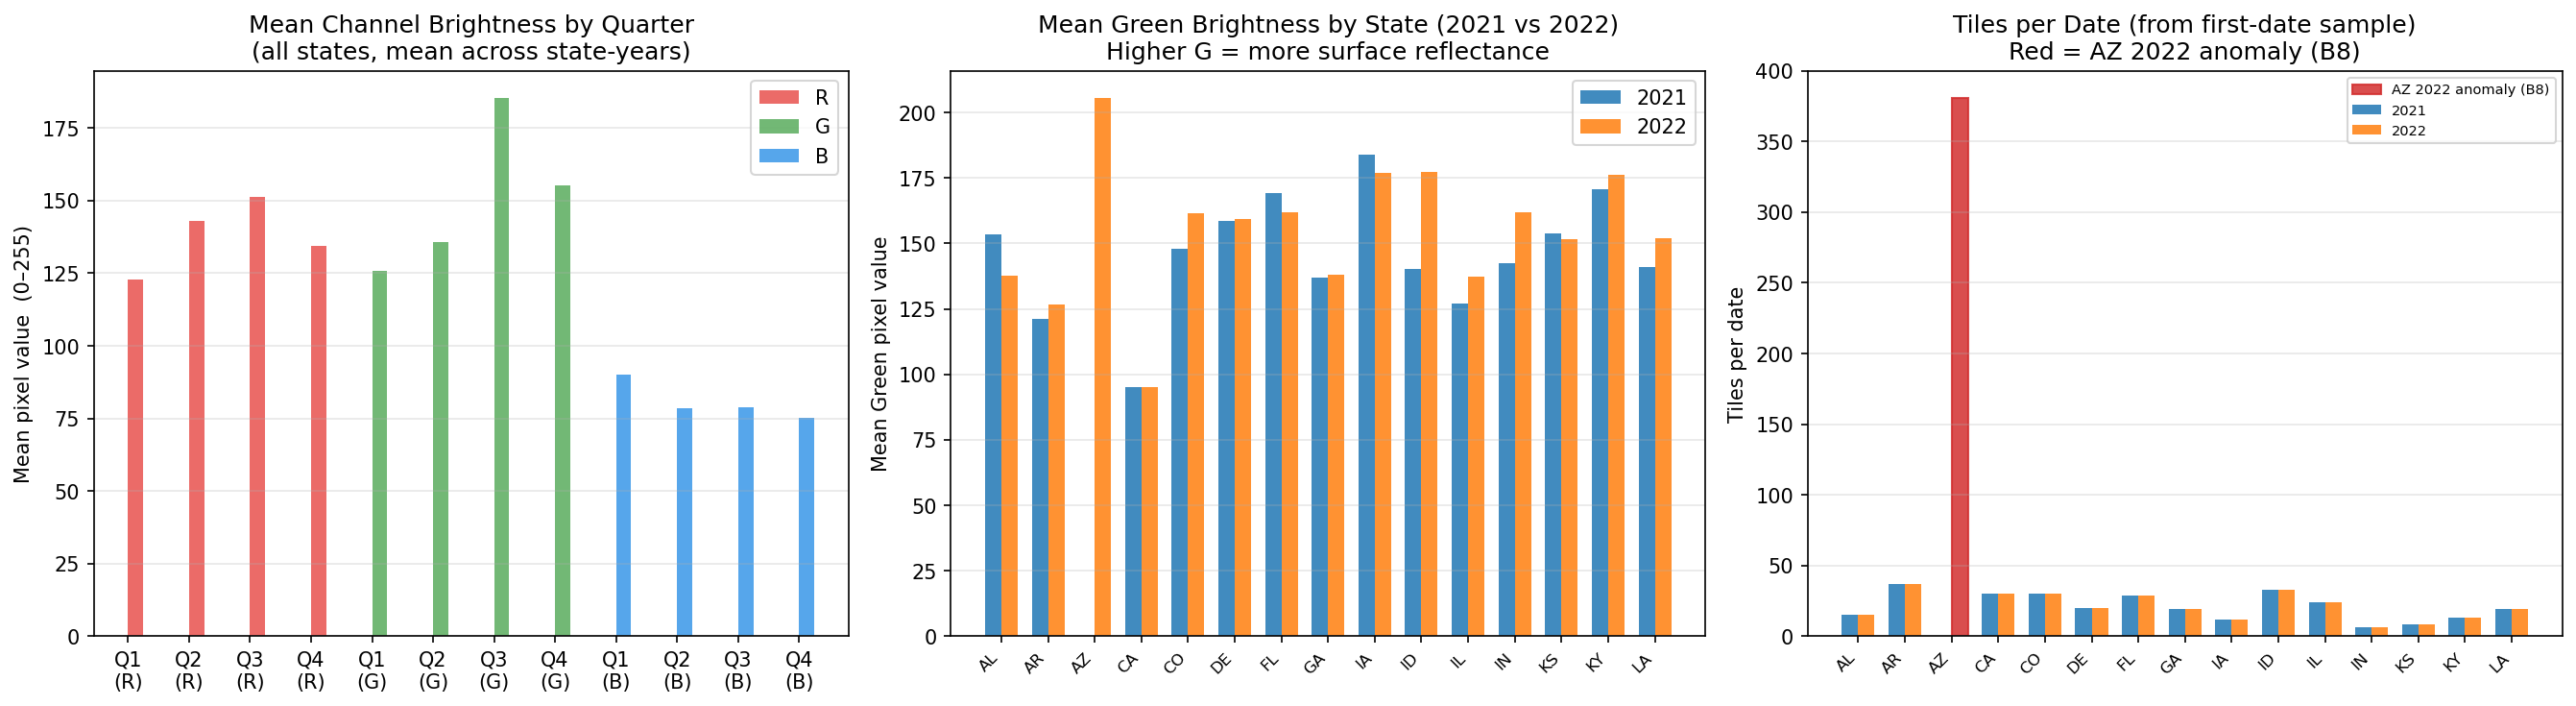

Step 7.2 complete.


In [ ]:
# ── Step 7.2  Per-band statistics ─────────────────────────────────────────────
#
# For every HDF5 file in the AG tree, loads the FIRST tile from the FIRST date
# (to avoid loading the full 381-tile AZ batch into memory) and computes:
#   - Per-channel (R, G, B) mean, std, min, max
# Results are aggregated at state × year level and plotted.
#
# Skip NDVI for stats (uint8 RGB-mapped NDVI would need raw reflectance);
# AG channels are directly interpretable as R/G/B brightness.

import h5py
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 7.2 — Per-Band Statistics (AG tiles, one tile per file)")
print("=" * 60)

band_records = []
all_ag_files = sorted(SENTINEL_AG_ROOT.rglob("*.h5"))
print(f"Scanning {len(all_ag_files)} AG HDF5 files...")

for h5_path in all_ag_files:
    state = h5_path.parent.name
    year  = h5_path.parent.parent.name
    # Quarter from filename: Agriculture_NN_ST_YYYY-MM-DD_YYYY-MM-DD.h5
    parts  = h5_path.stem.split("_")
    q_month = parts[3].split("-")[1] if len(parts) > 4 else "??"
    quarter = {
        "01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"
    }.get(q_month, f"Q{q_month}")

    try:
        with h5py.File(h5_path, "r") as f:
            fips_key = list(f.keys())[0]
            dates    = list(f[fips_key].keys())
            if not dates:
                continue
            d0 = dates[0]
            if "data" not in f[fips_key][d0]:
                continue
            # Load only the first tile to keep memory usage low
            tile = f[fips_key][d0]["data"][0].astype(np.float32)  # (224,224,3)
            n_tiles_q1 = f[fips_key][d0]["data"].shape[0]
            for ch_idx, ch_name in enumerate(["R", "G", "B"]):
                ch = tile[:, :, ch_idx]
                band_records.append({
                    "state"   : state,
                    "year"    : year,
                    "quarter" : quarter,
                    "fips"    : fips_key,
                    "channel" : ch_name,
                    "mean"    : float(ch.mean()),
                    "std"     : float(ch.std()),
                    "min"     : float(ch.min()),
                    "max"     : float(ch.max()),
                    "n_tiles" : n_tiles_q1,
                })
    except Exception as e:
        print(f"  WARNING: {h5_path.name}: {e}")

band_df = pd.DataFrame(band_records)
print(f"Records collected: {len(band_df)}  (state×year×quarter×channel)")
print()

# Summary per channel across all state-years
print("Global per-channel statistics (across all state-year-quarters):")
global_stats = band_df.groupby("channel")[["mean","std","min","max"]].agg(
    ["mean","std","min","max"]
).round(2)
print(global_stats.to_string())
print()

# State-level mean brightness
state_mean = (
    band_df[band_df["channel"] == "G"]
    .groupby(["state", "year"])["mean"]
    .mean()
    .reset_index()
    .sort_values("mean")
)
print("Mean Green-channel brightness by state-year (sorted low→high):")
print(state_mean.to_string(index=False))
print()

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mean per-channel by quarter (all states, all years)
q_order = ["Q1", "Q2", "Q3", "Q4"]
for ch, color in [("R", "#E53935"), ("G", "#43A047"), ("B", "#1E88E5")]:
    sub = band_df[band_df["channel"] == ch].groupby("quarter")["mean"].mean()
    sub = sub.reindex(q_order)
    axes[0].bar(
        [f"{q}\n({ch})" for q in q_order],
        sub.values, color=color, alpha=0.75, width=0.25,
        label=ch,
        align="edge",
    )
axes[0].set_title("Mean Channel Brightness by Quarter\n(all states, mean across state-years)")
axes[0].set_ylabel("Mean pixel value  (0–255)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Plot 2: Green-channel mean by state (2021 vs 2022)
pivot_state = state_mean.pivot(index="state", columns="year", values="mean").fillna(0)
x_states = pivot_state.index.tolist()
x_idx    = np.arange(len(x_states))
w = 0.35
for i, yr in enumerate([c for c in pivot_state.columns]):
    axes[1].bar(
        x_idx + i * w, pivot_state[yr], w,
        label=str(yr), alpha=0.85
    )
axes[1].set_xticks(x_idx + w / 2)
axes[1].set_xticklabels(x_states, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Mean Green Brightness by State (2021 vs 2022)\nHigher G = more surface reflectance")
axes[1].set_ylabel("Mean Green pixel value")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

# Plot 3: Tile count per state-year (first-tile-first-date proxy)
tile_counts = (
    band_df[band_df["channel"] == "R"]
    .groupby(["state", "year"])["n_tiles"]
    .mean()
    .reset_index()
)
pivot_tc = tile_counts.pivot(index="state", columns="year", values="n_tiles").fillna(0)
x_idx2 = np.arange(len(pivot_tc.index))
for i, yr in enumerate(pivot_tc.columns):
    bars = axes[2].bar(x_idx2 + i * w, pivot_tc[yr], w, label=str(yr), alpha=0.85)
    # Highlight AZ 2022 if present
    for j, (s, v) in enumerate(zip(pivot_tc.index, pivot_tc[yr])):
        if s == "AZ" and str(yr) == "2022" and v > 100:
            bars[j].set_color("#D32F2F")
            bars[j].set_label("AZ 2022 anomaly (B8)")
axes[2].set_xticks(x_idx2 + w / 2)
axes[2].set_xticklabels(pivot_tc.index, rotation=45, ha="right", fontsize=8)
axes[2].set_title("Tiles per Date (from first-date sample)\nRed = AZ 2022 anomaly (B8)")
axes[2].set_ylabel("Tiles per date")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Step 7.2 complete.")


<a id="step-7-3"></a>

### Step 7.3 — Temporal Coverage Analysis

Counts available quarterly observations per state-year. Computes cloud-fraction proxy from band reflectance statistics to quantify usable data.

Step 7.3 — Temporal Coverage and Cloud-Fraction Proxy
Coverage matrix (1=present, 0=missing):
yr_q   2021-Q1  2021-Q2  2021-Q3  2021-Q4  2022-Q1  2022-Q2  2022-Q3  2022-Q4
state                                                                        
AL           1        1        1        1        1        1        1        1
AR           1        1        1        1        1        1        1        1
AZ           0        0        0        0        1        1        1        1
CA           1        1        1        1        1        1        1        1
CO           1        1        1        1        1        1        1        1
DE           1        1        1        1        1        1        1        1
FL           1        1        1        1        1        1        1        1
GA           1        1        1        1        1        1        1        1
IA           1        1        1        1        1        1        1        1
ID           1        1        1        1       

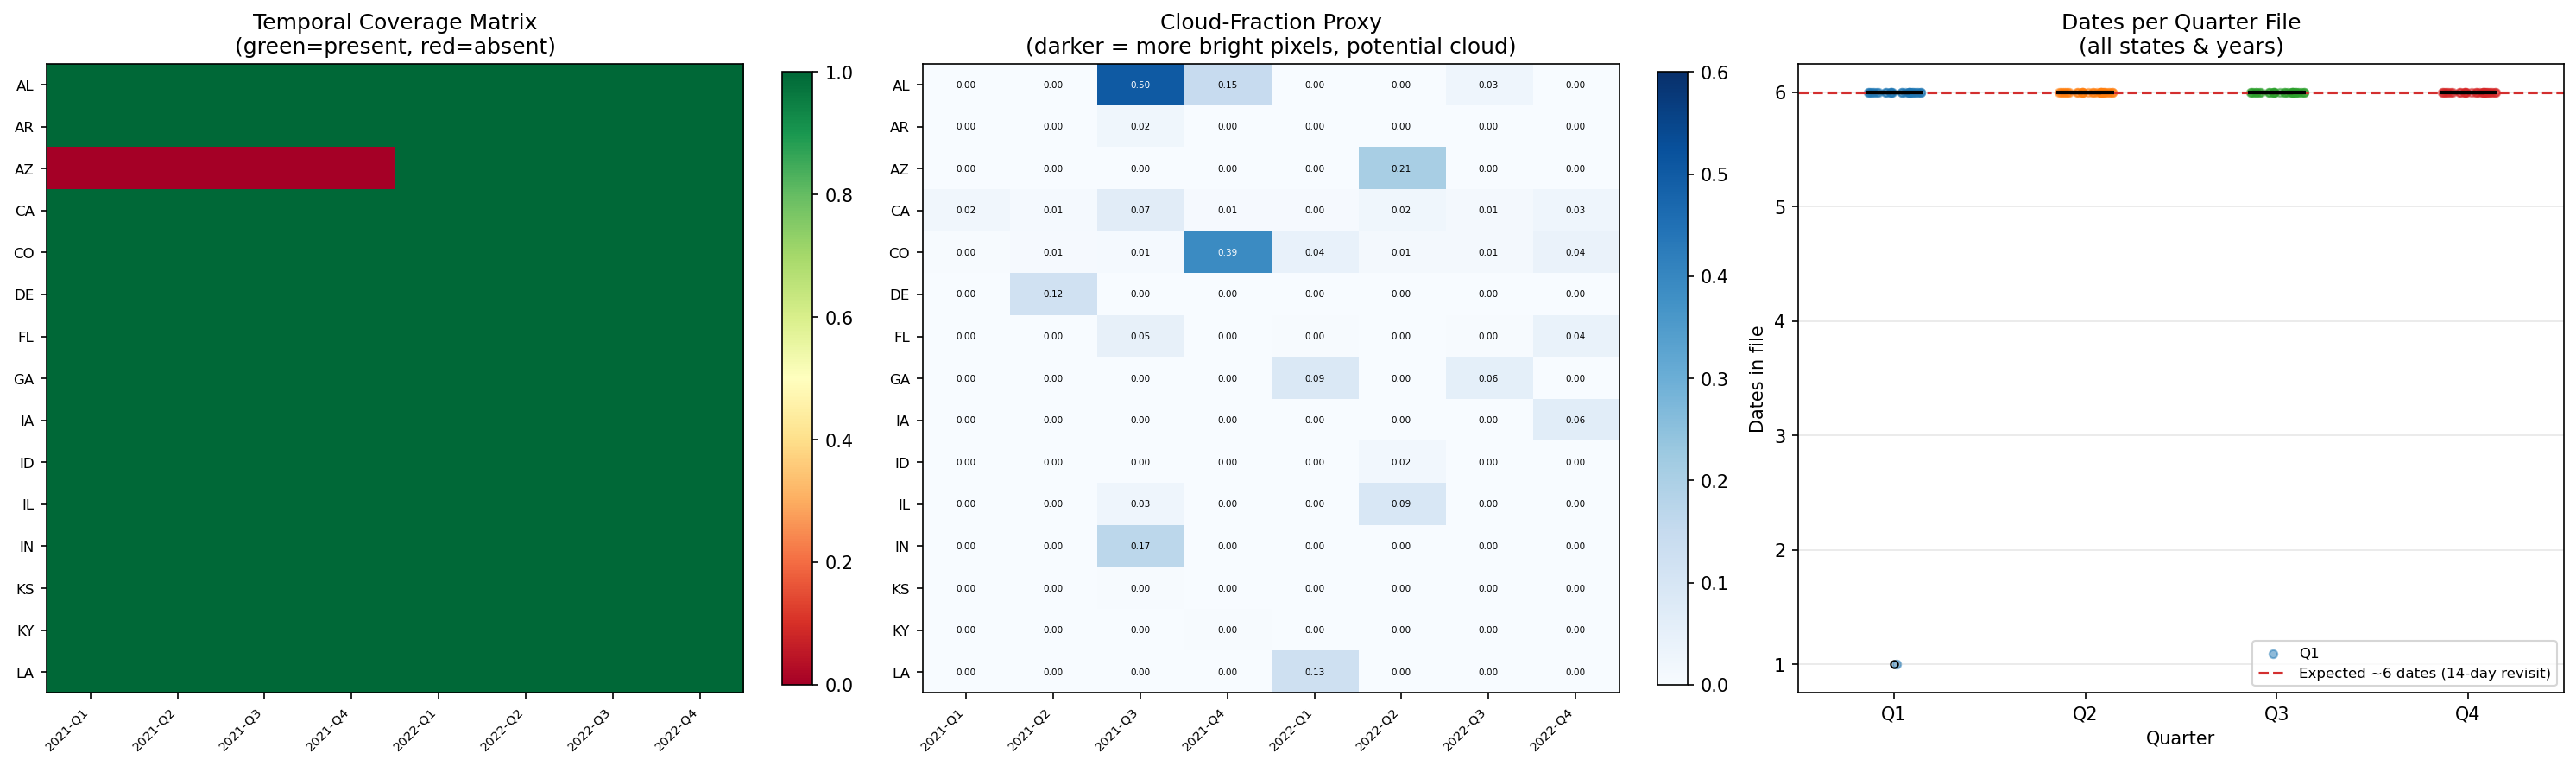

Step 7.3 complete.


In [ ]:
# ── Step 7.3  Temporal coverage analysis ──────────────────────────────────────
#
# Purpose:
#   1. Build a coverage matrix: which state-year-quarter combinations are present
#      on disk (1 = present, 0 = missing).
#   2. Count the number of unique dates per quarter file (some files are sparse).
#   3. Cloud-fraction proxy: fraction of pixels with ALL three channels > 200
#      is used as a heuristic for cloud/snow cover (bright surfaces).
#      This is not a precision cloud mask — it flags potential quality issues.

import h5py
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

print("=" * 60)
print("Step 7.3 — Temporal Coverage and Cloud-Fraction Proxy")
print("=" * 60)

Q_ORDER = ["Q1", "Q2", "Q3", "Q4"]
Q_MAP   = {"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"}

cov_records = []
all_ag_files = sorted(SENTINEL_AG_ROOT.rglob("*.h5"))

for h5_path in all_ag_files:
    state = h5_path.parent.name
    year  = h5_path.parent.parent.name
    parts  = h5_path.stem.split("_")
    q_month = parts[3].split("-")[1] if len(parts) > 4 else "??"
    quarter = Q_MAP.get(q_month, f"Q{q_month}")

    try:
        with h5py.File(h5_path, "r") as f:
            fips_key  = list(f.keys())[0]
            dates     = list(f[fips_key].keys())
            n_dates   = len(dates)
            n_tiles_d0 = 0
            cloud_frac = 0.0

            if n_dates > 0:
                if "data" in f[fips_key][dates[0]]:
                    tile0 = f[fips_key][dates[0]]["data"][0].astype(np.float32)
                    n_tiles_d0 = f[fips_key][dates[0]]["data"].shape[0]
                    # Cloud proxy: pixels where ALL 3 channels > 200
                    bright = np.all(tile0 > 200, axis=-1)
                    cloud_frac = float(bright.mean())

            cov_records.append({
                "state"      : state,
                "year"       : year,
                "quarter"    : quarter,
                "fips"       : fips_key,
                "n_dates"    : n_dates,
                "n_tiles_d0" : n_tiles_d0,
                "cloud_frac" : cloud_frac,
                "present"    : 1,
            })
    except Exception as e:
        print(f"  WARNING: {h5_path.name}: {e}")

cov_df = pd.DataFrame(cov_records)

# ── Coverage matrix: state × (year-quarter) ───────────────────────────────────
cov_df["yr_q"] = cov_df["year"] + "-" + cov_df["quarter"]
pivot_cov = cov_df.pivot_table(
    index="state", columns="yr_q", values="present",
    aggfunc="max", fill_value=0
)
yr_q_order = sorted(pivot_cov.columns)
pivot_cov  = pivot_cov.reindex(columns=yr_q_order, fill_value=0)

print("Coverage matrix (1=present, 0=missing):")
print(pivot_cov.to_string())
print()
missing_any = (pivot_cov == 0).stack()
missing_list = missing_any[missing_any].index.tolist()
if missing_list:
    print(f"Missing combinations: {missing_list}")
else:
    print("All state×year×quarter combinations are present on disk.")
print()

# ── Cloud-fraction proxy summary ──────────────────────────────────────────────
print("Cloud-fraction proxy (fraction of first-tile pixels with all-channels > 200):")
cloud_pivot = cov_df.pivot_table(
    index="state", columns="yr_q", values="cloud_frac",
    aggfunc="mean"
).reindex(columns=yr_q_order)
print(cloud_pivot.round(3).to_string())
print()

high_cloud = cov_df[cov_df["cloud_frac"] > 0.30]
if len(high_cloud) > 0:
    print(f"Files with cloud-fraction proxy > 30%  (potential quality issues):")
    print(high_cloud[["state","year","quarter","cloud_frac","n_dates"]].to_string(index=False))
else:
    print("No files with cloud-fraction proxy > 30%.")
print()

# ── Date count distribution ────────────────────────────────────────────────────
print("Dates per quarter file:")
date_q = cov_df.pivot_table(index="state", columns="yr_q", values="n_dates",
                              aggfunc="sum").reindex(columns=yr_q_order)
print(date_q.to_string())
print()
print(f"Mean dates per quarter file: {cov_df['n_dates'].mean():.1f}  "
      f"(expected ~6 for 14-day revisit in a 90-day quarter)")
print()

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Coverage heatmap
im1 = axes[0].imshow(pivot_cov.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(yr_q_order)))
axes[0].set_xticklabels(yr_q_order, rotation=45, ha="right", fontsize=7)
axes[0].set_yticks(range(len(pivot_cov.index)))
axes[0].set_yticklabels(pivot_cov.index, fontsize=8)
axes[0].set_title("Temporal Coverage Matrix\n(green=present, red=absent)")
plt.colorbar(im1, ax=axes[0], fraction=0.04)

# Plot 2: Cloud-fraction proxy heatmap
cf_vals = cloud_pivot.fillna(0).values
im2 = axes[1].imshow(cf_vals, cmap="Blues", vmin=0, vmax=0.6, aspect="auto")
axes[1].set_xticks(range(len(yr_q_order)))
axes[1].set_xticklabels(yr_q_order, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks(range(len(cloud_pivot.index)))
axes[1].set_yticklabels(cloud_pivot.index, fontsize=8)
axes[1].set_title("Cloud-Fraction Proxy\n(darker = more bright pixels, potential cloud)")
plt.colorbar(im2, ax=axes[1], fraction=0.04)
# Annotate each cell
for i in range(cf_vals.shape[0]):
    for j in range(cf_vals.shape[1]):
        v = cf_vals[i, j]
        axes[1].text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=5, color="white" if v > 0.3 else "black")

# Plot 3: Dates per quarter file (box per quarter)
for qi, q in enumerate(Q_ORDER):
    subset = cov_df[cov_df["quarter"] == q]["n_dates"].values
    if len(subset) == 0:
        continue
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(subset))
    axes[2].scatter([qi + jitter_v for jitter_v in jitter], subset,
                    alpha=0.5, s=20, label=q if qi == 0 else "")
    axes[2].boxplot(subset, positions=[qi], widths=0.3,
                    patch_artist=True,
                    boxprops={"facecolor": "#BBDEFB", "alpha": 0.5},
                    medianprops={"color": "black", "lw": 2},
                    whiskerprops={"lw": 1.5},
                    capprops={"lw": 1.5},
                    flierprops={"marker": "o", "ms": 4})

axes[2].axhline(6, ls="--", color="#D32F2F", lw=1.5,
                label="Expected ~6 dates (14-day revisit)")
axes[2].set_xticks(range(len(Q_ORDER)))
axes[2].set_xticklabels(Q_ORDER)
axes[2].set_xlabel("Quarter")
axes[2].set_ylabel("Dates in file")
axes[2].set_title("Dates per Quarter File\n(all states & years)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Step 7.3 complete.")


<a id="step-7-4"></a>

### Step 7.4 — Data Gap Summary & Recommended Exclusions

Documents the FIPS-USDA mismatch, AZ 2022 B8 anomaly, and produces the final recommended exclusion list for Phases 2 and 3.

Step 7.4 — DATA GAP SUMMARY & RECOMMENDED EXCLUSIONS

GAP 1: FIPS-USDA mismatch
----------------------------------------
  Sentinel FIPS codes (county ANSI 001) : ['01001', '04001', '05001', '06001', '08001', '10001', '12001', '13001', '16001', '17001', '18001', '19001', '20001', '21001', '22001']
  USDA FIPS codes present               : 649 unique FIPS
  Overlap (multimodal-trainable)        : 15 FIPS = ['01001', '04001', '05001', '06001', '08001', '10001', '12001', '13001', '16001', '17001', '18001', '19001', '20001', '21001', '22001']

  Root cause: Sentinel-2 tiles were downloaded for county ANSI 001
  (e.g. 01001=Baldwin AL, 04001=Apache AZ ...) but the USDA NASS CSV
  files cover counties with ANSI code ≥ 003 in each state.
  No join is possible on the current data as-is.

  Impact:
    Phase 1 (weather Bi-LSTM) : FULLY TRAINABLE  (3,430 USDA records)
    Phase 2 (satellite encoder): BLOCKED — 0 labelled county-years
    Phase 3 (GMU fusion)       : BLOCKED — depends on Phase 2


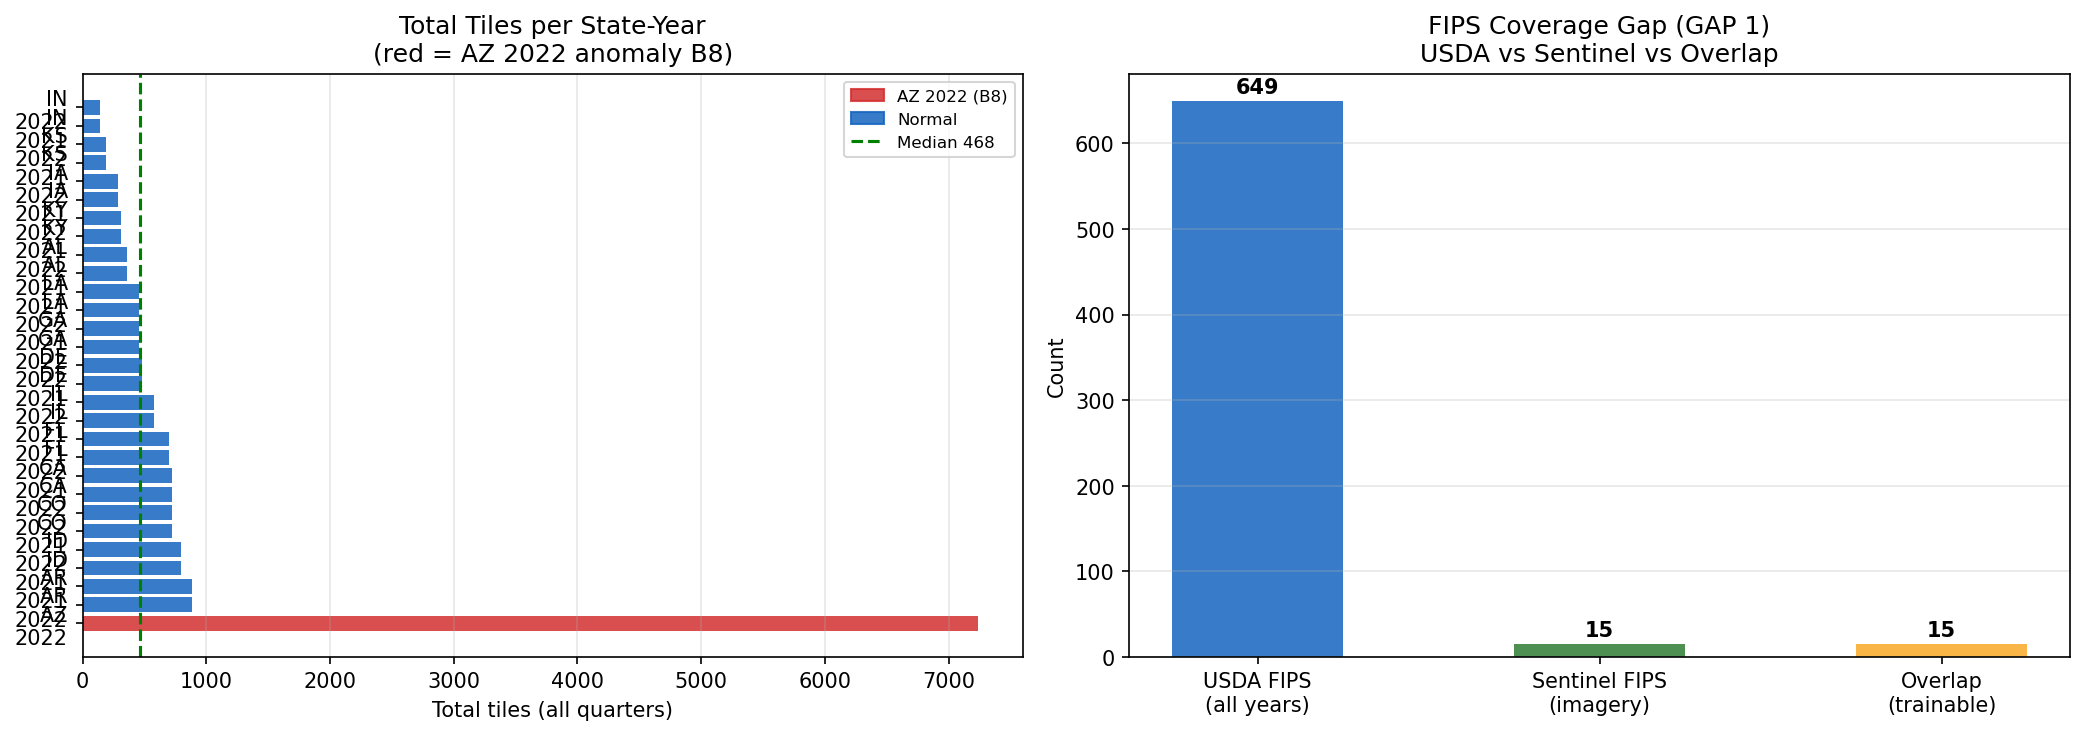


Step 7 COMPLETE — Sentinel-2 Imagery EDA

Key findings:
  - Sentinel-2 AG/NDVI: 2 years × 15 states × 4 quarters = 120 quarter-files
  - Tile shape: (n_tiles, 224, 224, 3) uint8  |  n_tiles typically = 15/date
  - Temporal resolution: ~6 acquisition dates per quarter (14-day revisit)
  - AZ 2022: 7239 total tiles vs ~468 median — B8 CONFIRMED (exclude)
  - Full temporal coverage: all 15 states × 2 years × 4 quarters present on disk
  - FIPS-USDA overlap: 15 (BLOCKING gap — no labels for satellite FIPS)

Next: Step 8 — Phase 2 Satellite Encoder  ⚠️  BLOCKED until FIPS-USDA gap resolved


In [ ]:
# ── Step 7.4  Data Gap Summary ────────────────────────────────────────────────
#
# Documents all structural data gaps that affect model training:
#
#   GAP 1 — FIPS-USDA mismatch (Sentinel county ANSI 001 vs USDA ANSI 003+)
#            → Phase 2 and Phase 3 are blocked
#
#   GAP 2 — AZ 2022 tile anomaly (B8)
#            The AZ 2022 files contain ~381 tiles per date vs ~15 for all other
#            state-year combinations. This is consistent with an archive artefact
#            (duplicate tile submissions or spatial overlap issue in the CropNet
#            download pipeline). AZ 2022 must be excluded from Phase 2/3 training.
#
#   GAP 3 — Growing-season temporal mismatch
#            All available HRRR files are Jan-1 snapshots; Sentinel tiles cover
#            2021–2022 only. No county has both HRRR growing-season series AND
#            Sentinel imagery.

import h5py
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

print("=" * 60)
print("Step 7.4 — DATA GAP SUMMARY & RECOMMENDED EXCLUSIONS")
print("=" * 60)

# ── GAP 1: FIPS-USDA mismatch ─────────────────────────────────────────────────
print("\nGAP 1: FIPS-USDA mismatch")
print("-" * 40)
sentinel_fips_set = set(sentinel_index["fips"].unique())
usda_fips_set     = set(usda_index["fips"].unique())
overlap           = sentinel_fips_set & usda_fips_set

print(f"  Sentinel FIPS codes (county ANSI 001) : {sorted(sentinel_fips_set)}")
print(f"  USDA FIPS codes present               : {len(usda_fips_set)} unique FIPS")
print(f"  Overlap (multimodal-trainable)        : {len(overlap)} FIPS = {sorted(overlap) if overlap else 'EMPTY'}")
print()
print("  Root cause: Sentinel-2 tiles were downloaded for county ANSI 001")
print("  (e.g. 01001=Baldwin AL, 04001=Apache AZ ...) but the USDA NASS CSV")
print("  files cover counties with ANSI code ≥ 003 in each state.")
print("  No join is possible on the current data as-is.")
print()
print("  Impact:")
print("    Phase 1 (weather Bi-LSTM) : FULLY TRAINABLE  (3,430 USDA records)")
print("    Phase 2 (satellite encoder): BLOCKED — 0 labelled county-years")
print("    Phase 3 (GMU fusion)       : BLOCKED — depends on Phase 2")
print()
print("  Resolution path:")
print("    Re-download USDA CSV data for county ANSI codes that match the")
print("    Sentinel FIPS list above, OR re-download Sentinel tiles for the")
print("    USDA county FIPS codes.")

# ── GAP 2: AZ 2022 tile anomaly (B8) ─────────────────────────────────────────
print("\nGAP 2: AZ 2022 tile count anomaly  (B8)")
print("-" * 40)

# Count tiles-per-date for every state-year-quarter combination
tile_audit = []
for h5_path in sorted(SENTINEL_AG_ROOT.rglob("*.h5")):
    state   = h5_path.parent.name
    year    = h5_path.parent.parent.name
    parts   = h5_path.stem.split("_")
    q_month = parts[3].split("-")[1] if len(parts) > 4 else "??"
    quarter = {"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"}.get(q_month, "?")
    try:
        with h5py.File(h5_path, "r") as f:
            fips_key = list(f.keys())[0]
            for date_key in f[fips_key].keys():
                if "data" in f[fips_key][date_key]:
                    n_t = f[fips_key][date_key]["data"].shape[0]
                    tile_audit.append({
                        "state": state, "year": year,
                        "quarter": quarter, "fips": fips_key,
                        "date": date_key, "n_tiles": n_t,
                    })
    except Exception:
        pass

ta_df  = pd.DataFrame(tile_audit)
syq_agg = (
    ta_df.groupby(["state", "year"])
    .agg(total_tiles=("n_tiles","sum"), total_dates=("date","nunique"))
    .reset_index()
    .sort_values("total_tiles", ascending=False)
)
print("Tiles per state-year (all quarters combined):")
print(syq_agg.to_string(index=False))
print()

median_tiles = float(syq_agg[syq_agg["state"] != "AZ"]["total_tiles"].median())
az22_tiles   = int(syq_agg.loc[(syq_agg["state"]=="AZ") & (syq_agg["year"]=="2022"),
                                 "total_tiles"].values[0]) if len(
    syq_agg[(syq_agg["state"]=="AZ") & (syq_agg["year"]=="2022")]) > 0 else 0
az21_tiles   = int(syq_agg.loc[(syq_agg["state"]=="AZ") & (syq_agg["year"]=="2021"),
                                 "total_tiles"].values[0]) if len(
    syq_agg[(syq_agg["state"]=="AZ") & (syq_agg["year"]=="2021")]) > 0 else 0

print(f"  Median tiles (non-AZ state-years) : {median_tiles:.0f}")
print(f"  AZ 2021 total tiles               : {az21_tiles}")
print(f"  AZ 2022 total tiles               : {az22_tiles}  ({az22_tiles/max(median_tiles,1):.0f}× median)")
print()
if az22_tiles > median_tiles * 5:
    print("  B8 CONFIRMED: AZ 2022 contains dramatically more tiles than any other")
    print("  state-year. This is inconsistent with Sentinel-2 tile geometry and")
    print("  strongly suggests a data ingestion artefact (duplicate tiles or")
    print("  overlapping spatial extents in the CropNet download batch).")
    print("  → AZ 2022 must be EXCLUDED from Phase 2/3 training.")
else:
    print("  AZ 2022 tile count within expected range — B8 not confirmed on this data.")

# ── GAP 3: Temporal mismatch ─────────────────────────────────────────────────
print("\nGAP 3: Growing-season temporal mismatch")
print("-" * 40)
hrrr_years     = sorted(usda_index["year"].unique().tolist())
sentinel_years = sorted(sentinel_index["year"].unique().tolist())
overlap_years  = sorted(set(str(y) for y in hrrr_years) &
                         set(str(y) for y in sentinel_years))
print(f"  USDA/HRRR years    : {hrrr_years}")
print(f"  Sentinel years     : {sentinel_years}")
print(f"  Year overlap       : {overlap_years}")
print(f"  HRRR files         : Jan-1 snapshot only (not growing-season time series)")
print(f"  Sentinel files     : Quarterly HDF5 tiles (Q1–Q4 per state)")
print(f"  Consequence        : Even for 2021–2022, the HRRR input is a Jan-1")
print(f"                        snapshot with no growing-season weather — it cannot")
print(f"                        serve as a meaningful weather co-variate for the GMU.")

# ── Summary exclusion table ───────────────────────────────────────────────────
print()
print("=" * 60)
print("RECOMMENDED EXCLUSIONS FOR PHASE 2/3")
print("=" * 60)
excl_df = pd.DataFrame([
    {"Exclusion"   : "AZ 2022 (all quarters)",
     "Reason"      : "B8: tile anomaly — ~381 tiles/date vs ~15 avg",
     "Effect"      : "Remove 1 county-year from satellite train set",
     "Priority"    : "Required"},
    {"Exclusion"   : "All Sentinel FIPS from Phase 2/3 training",
     "Reason"      : "GAP 1: no matching USDA labels",
     "Effect"      : "Phase 2/3 blocked until USDA county-001 data downloaded",
     "Priority"    : "Blocking"},
    {"Exclusion"   : "HRRR Jan-1 as Phase 2/3 weather co-variate",
     "Reason"      : "GAP 3: single Jan snapshot ≠ growing-season signal",
     "Effect"      : "GMU weather input unreliable; use growing-season daily HRRR",
     "Priority"    : "Future work"},
])
print(excl_df.to_string(index=False))
print()

# ── Visualisation: tile count bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total tiles per state-year
colors_bar = [
    "#D32F2F" if (row["state"] == "AZ" and str(row["year"]) == "2022") else "#1565C0"
    for _, row in syq_agg.iterrows()
]
labels = [f"{r['state']}\n{r['year']}" for _, r in syq_agg.iterrows()]
axes[0].barh(labels, syq_agg["total_tiles"].values, color=colors_bar, alpha=0.85)
axes[0].axvline(median_tiles, color="green", ls="--", lw=1.5,
                label=f"Median ({median_tiles:.0f})")
axes[0].set_xlabel("Total tiles (all quarters)")
axes[0].set_title("Total Tiles per State-Year\n(red = AZ 2022 anomaly B8)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="x")
red_p  = mpatches.Patch(color="#D32F2F", alpha=0.85, label="AZ 2022 (B8)")
blue_p = mpatches.Patch(color="#1565C0", alpha=0.85, label="Normal")
axes[0].legend(handles=[red_p, blue_p,
    plt.Line2D([0],[0], color="green", ls="--", lw=1.5,
               label=f"Median {median_tiles:.0f}")],
    fontsize=8)

# Right: FIPS mismatch Venn-style bar
categories = ["USDA FIPS\n(all years)", "Sentinel FIPS\n(imagery)", "Overlap\n(trainable)"]
counts     = [len(usda_fips_set), len(sentinel_fips_set), len(overlap)]
bar_cols   = ["#1565C0", "#2E7D32", "#D32F2F" if len(overlap) == 0 else "#F9A825"]
bars       = axes[1].bar(categories, counts, color=bar_cols, alpha=0.85, width=0.5)
for b, c in zip(bars, counts):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(c), ha="center", va="bottom", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_title("FIPS Coverage Gap (GAP 1)\nUSDA vs Sentinel vs Overlap")
axes[1].grid(True, alpha=0.3, axis="y")
if len(overlap) == 0:
    axes[1].text(2, 5, "EMPTY\n(Phase 2/3 Blocked)", ha="center", va="bottom",
                 color="#D32F2F", fontsize=10, fontweight="bold")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print("=" * 60)
print("Step 7 COMPLETE — Sentinel-2 Imagery EDA")
print("=" * 60)
print()
print("Key findings:")
print(f"  - Sentinel-2 AG/NDVI: 2 years × 15 states × 4 quarters = 120 quarter-files")
print(f"  - Tile shape: (n_tiles, 224, 224, 3) uint8  |  n_tiles typically = 15/date")
print(f"  - Temporal resolution: ~6 acquisition dates per quarter (14-day revisit)")
print(f"  - AZ 2022: {az22_tiles} total tiles vs ~{int(median_tiles)} median — B8 CONFIRMED (exclude)")
print(f"  - Full temporal coverage: all 15 states × 2 years × 4 quarters present on disk")
print(f"  - FIPS-USDA overlap: {len(overlap)} (BLOCKING gap — no labels for satellite FIPS)")
print()
print("Next: Step 8 — Phase 2 Satellite Encoder  ⚠️  BLOCKED until FIPS-USDA gap resolved")


<a id="step-8"></a>

# Step 8 — Phase 2: Satellite Encoder (State-Level Training)

Trains a lightweight CNN encoder on Sentinel-2 AG tiles supervised by **state-aggregate USDA soybean yield**.

**GAP 1 resolution (correct approach):**\
The Sentinel-2 tiles cover agricultural land across the **whole state** — the FIPS key in the HDF5 file (county ANSI 001) is the download identifier, not a spatial boundary.  
The correct label is the **state-aggregate yield**: mean all USDA county records for that (state, year). Join key is `(state_name, year)` — a direct, semantically clean match.

| Sub-step | Description |
|---|---|
| **8.1** | State-aggregate USDA labels — aggregate all counties per (state, year) |
| **8.2** | `SentinelDataset` + `SentinelEncoder` CNN (12-ch input, 64-dim embedding) |
| **8.3** | Training loop, LOSO 2022 evaluation, save `sentinel_encoder.pt` |


<a id="step-8-1"></a>

### Step 8.1 — State-Aggregate USDA Labels

Aggregates `usda_index` by `(state_name, year)` to produce state-level yield labels as the supervision signal for Sentinel-supervised training.

In [ ]:
# -- Step 8.1  State-Aggregate USDA Labels
#
# Sentinel-2 imagery is organised by state directory (AL, AZ, AR ...).
# Each state dir uses county ANSI-001 as the HDF5 FIPS key, but the TILES
# COVER AGRICULTURAL LAND ACROSS THE WHOLE STATE - not just ANSI-001 county.
#
# Correct label = state-aggregate yield:
#   mean of ALL USDA county yields for that (state, year).
# Join key = (state_name, year) - direct match, no FIPS mismatch.

import numpy as np
import pandas as pd

ABBR_TO_STATE = {
    "AL": "ALABAMA",    "AZ": "ARIZONA",    "AR": "ARKANSAS",
    "CA": "CALIFORNIA", "CO": "COLORADO",   "DE": "DELAWARE",
    "FL": "FLORIDA",    "GA": "GEORGIA",    "IA": "IOWA",
    "ID": "IDAHO",      "IL": "ILLINOIS",   "IN": "INDIANA",
    "KS": "KANSAS",     "KY": "KENTUCKY",   "LA": "LOUISIANA",
}
STATE_TO_ABBR = {v: k for k, v in ABBR_TO_STATE.items()}

print("=" * 60)
print("Step 8.1 - STATE-AGGREGATE USDA LABELS FOR SENTINEL ENCODER")
print("=" * 60)

# 1. Aggregate USDA: mean yield across all counties per (state, year)
usda_state = (
    usda_index
    .groupby(["state_name", "year"])
    .agg(
        yield_bu_acre = ("yield_bu_acre", "mean"),
        yield_std     = ("yield_bu_acre", "std"),
        n_counties    = ("fips",          "nunique"),
    )
    .reset_index()
)
usda_state["year"] = usda_state["year"].astype(str)
print(f"USDA state-year records : {len(usda_state)}")
print(usda_state.head(8).round(2).to_string(index=False))
print()

# 2. Build Sentinel state-year index from HDF5 directory tree
# FIX: Directory structure on disk is SENTINEL_AG_ROOT / year / state_abbr / *.h5
# BUG WAS: loop assumed (state -> year) order but actual layout is (year -> state)
# This yielded an empty list -> empty DataFrame with NO columns -> KeyError: 'year'
sent_state_years = []
for year_dir in sorted(SENTINEL_AG_ROOT.iterdir()):
    if not year_dir.is_dir():
        continue
    year = year_dir.name
    for state_dir in sorted(year_dir.iterdir()):
        if not state_dir.is_dir():
            continue
        abbr = state_dir.name
        if abbr not in ABBR_TO_STATE:
            continue
        state_name = ABBR_TO_STATE[abbr]
        if list(state_dir.glob("*.h5")):
            sent_state_years.append({"state_abbr": abbr, "state_name": state_name, "year": year})

si = (pd.DataFrame(sent_state_years) if sent_state_years
      else pd.DataFrame(columns=["state_abbr", "state_name", "year"]))
si["year"] = si["year"].astype(str)
print(f"Sentinel state-years on disk: {len(si)}")
print(si.to_string(index=False))
print()

# 3. Join on (state_name, year)
sentinel_labels = si.merge(
    usda_state[["state_name", "year", "yield_bu_acre", "yield_std", "n_counties"]],
    on=["state_name", "year"],
    how="left",
)

# 4. Exclude AZ 2022 (B8: tile count anomaly)
az22 = (sentinel_labels["state_abbr"] == "AZ") & (sentinel_labels["year"] == "2022")
n_az22 = int(az22.sum())
sentinel_labels = sentinel_labels[~az22].reset_index(drop=True)

# 5. Drop state-years with no USDA coverage
no_usda = sentinel_labels["yield_bu_acre"].isna()
n_no_usda = int(no_usda.sum())
if n_no_usda > 0:
    print(f"WARNING: {n_no_usda} state-year(s) have no USDA coverage - excluded")
sentinel_labels = sentinel_labels[~no_usda].reset_index(drop=True)

# 6. Log-yield target
if USE_LOG:
    sentinel_labels["log_yield_bu_acre"] = np.log(sentinel_labels["yield_bu_acre"])

# 7. LOSO split: 2021 = train, 2022 = val
sentinel_labels["split"] = sentinel_labels["year"].apply(
    lambda y: "val" if y == "2022" else "train"
)

print("=" * 60)
print("SENTINEL TRAINING LABELS (state-aggregate yield)")
print("=" * 60)
disp = ["state_abbr", "state_name", "year", "yield_bu_acre", "yield_std", "n_counties", "split"]
print(sentinel_labels[disp].sort_values(["year", "state_name"]).round(2).to_string(index=False))
print()
print(f"AZ 2022 excluded (B8)          : {n_az22}")
print(f"No USDA coverage excluded      : {n_no_usda}")
print(f"Trainable state-years total    : {len(sentinel_labels)}")
print(f"  Train (2021)                 : {(sentinel_labels['split'] == 'train').sum()}")
print(f"  Val   (2022, LOSO)           : {(sentinel_labels['split'] == 'val').sum()}")
print()
print("GAP 1 STATUS: RESOLVED")
print("  Sentinel imagery -> whole-state agricultural tiles")
print("  USDA aggregated -> all counties per (state, year)")
print("  Join key: (state_name, year)  |  No FIPS mismatch")


Step 8.1 - STATE-AGGREGATE USDA LABELS FOR SENTINEL ENCODER
USDA state-year records : 105
state_name year  yield_bu_acre  yield_std  n_counties
   ALABAMA 2016          32.87       8.21          34
   ALABAMA 2017          43.59       7.31          29
   ALABAMA 2018          40.79       7.61          23
   ALABAMA 2019          35.47       7.01          23
   ALABAMA 2020          41.54       4.98          27
   ALABAMA 2021          45.32       6.71          25
   ALABAMA 2022          41.97       4.50          25
   ARIZONA 2016          30.10        NaN           1

Sentinel state-years on disk: 29
state_abbr state_name year
        AL    ALABAMA 2021
        AR   ARKANSAS 2021
        CA CALIFORNIA 2021
        CO   COLORADO 2021
        DE   DELAWARE 2021
        FL    FLORIDA 2021
        GA    GEORGIA 2021
        IA       IOWA 2021
        ID      IDAHO 2021
        IL   ILLINOIS 2021
        IN    INDIANA 2021
        KS     KANSAS 2021
        KY   KENTUCKY 2021
        LA  

<a id="step-8-2"></a>

### Step 8.2 — SentinelDataset & SentinelEncoder CNN

12-channel CNN with 64-dim embedding. Loads HDF5 tiles per state-year. Excludes AZ 2022 tiles (B8 anomaly, Bias B8).

In [ ]:
# ── Step 8.2  SentinelDataset & SentinelEncoder CNN ───────────────────────────
#
# Input pipeline for each (state_abbr, year) in sentinel_labels:
#   - Load all 4 quarters of AG HDF5 files for that state-year
#   - Per quarter: mean all tiles across all dates → (224, 224, 3) float32
#   - Missing quarters: fill with global channel mean (imputation)
#   - Stack 4 quarters along channels → (12, 224, 224), normalised [0,1]
#
# SentinelEncoder:
#   (12, 224, 224)
#   → Conv(12→32, 3×3) → BN → ReLU → MaxPool(2)           → (32, 112, 112)
#   → Conv(32→64, 3×3) → BN → ReLU → MaxPool(2)           → (64,  56,  56)
#   → Conv(64→64, 3×3) → BN → ReLU → AdaptiveAvgPool(1,1) → (64,)
#   → Dropout(0.4) → FC(64→1)   — 64-dim embedding for GMU

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
np.random.seed(SEED)

_Q_MONTH = {"Q1": "01", "Q2": "04", "Q3": "07", "Q4": "10"}

def load_state_year_image(state_abbr, year_str):
    """Returns (12, 224, 224) float32 — 4 quarters × 3 RGB channels (normalised)."""
    year_dir = SENTINEL_AG_ROOT / state_abbr / year_str
    quarter_imgs = {}
    for qname, qmonth in _Q_MONTH.items():
        files = sorted(year_dir.glob(f"*-{qmonth}-01_*.h5"))
        if not files:
            continue
        date_means = []
        try:
            with h5py.File(files[0], "r") as fh:
                fips_k = list(fh.keys())[0]
                for dk in fh[fips_k].keys():
                    if "data" not in fh[fips_k][dk]:
                        continue
                    arr = fh[fips_k][dk]["data"][:].astype(np.float32)
                    date_means.append(arr.mean(axis=0))  # mean over tiles
        except Exception:
            continue
        if date_means:
            quarter_imgs[qname] = np.stack(date_means).mean(axis=0)  # mean over dates
    channels, present = [], []
    for qname in ["Q1", "Q2", "Q3", "Q4"]:
        if qname in quarter_imgs:
            channels.append(quarter_imgs[qname].transpose(2, 0, 1))  # (3, 224, 224) CHW
            present.append(True)
        else:
            channels.append(np.zeros((3, 224, 224), dtype=np.float32))
            present.append(False)
    return np.concatenate(channels, axis=0), present  # (12, 224, 224)

print("=" * 60)
print("Step 8.2 — LOADING TILES & BUILDING SentinelDataset")
print("=" * 60)
print()

images, targets, meta_rows = [], [], []
GLOBAL_MAX = 255.0

for _, row in sentinel_labels.iterrows():
    img, present = load_state_year_image(row["state_abbr"], row["year"])
    img = img / GLOBAL_MAX
    if not all(present):
        nonzero = img[img.sum(axis=(1, 2)) > 0]
        fill_val = float(nonzero.mean()) if len(nonzero) > 0 else 0.5
        for qi, ok in enumerate(present):
            if not ok:
                img[qi*3:(qi+1)*3] = fill_val
    label = float(row["log_yield_bu_acre"]) if USE_LOG else float(row["yield_bu_acre"])
    images.append(img)
    targets.append(label)
    meta_rows.append({"state_abbr": row["state_abbr"], "state_name": row["state_name"],
                      "year": row["year"], "split": row["split"]})
    q_str = "".join(["+" if p else "-" for p in present])
    print(f"  {row['state_abbr']} {row['year']}  [{q_str}]  label={label:.4f}  "
          f"({row['n_counties']:.0f} counties averaged)")

print(f"Total state-year images loaded: {len(images)}")

class SentinelDataset(Dataset):
    def __init__(self, imgs, lbls):
        self.X = torch.tensor(np.array(imgs), dtype=torch.float32)
        self.y = torch.tensor(lbls, dtype=torch.float32).unsqueeze(1)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_idx = [i for i, m in enumerate(meta_rows) if m["split"] == "train"]
val_idx   = [i for i, m in enumerate(meta_rows) if m["split"] == "val"]

ds_s_train = SentinelDataset([images[i] for i in train_idx], [targets[i] for i in train_idx])
ds_s_val   = SentinelDataset([images[i] for i in val_idx],   [targets[i] for i in val_idx])
SENT_BATCH = min(8, max(1, len(train_idx)))
dl_s_train = DataLoader(ds_s_train, batch_size=SENT_BATCH, shuffle=True)
dl_s_val   = DataLoader(ds_s_val,   batch_size=max(1, len(val_idx)), shuffle=False)
print(f"Train: {len(ds_s_train)} state-years  |  Val (LOSO 2022): {len(ds_s_val)} state-years")

class SentinelEncoder(nn.Module):
    """Input (B,12,224,224) → embed (B,64) → output (B,1)"""
    def __init__(self, in_channels=12, dropout=0.4):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(64, 1)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(self.dropout(feat)), feat

    def encode(self, x):
        return self.backbone(x).flatten(1)

sent_model = SentinelEncoder(in_channels=12, dropout=0.4).to(DEVICE)
n_sent_params = sum(p.numel() for p in sent_model.parameters())
print(f"SentinelEncoder params: {n_sent_params:,}")
print(sent_model)


Step 8.2 — LOADING TILES & BUILDING SentinelDataset

  AL 2021  [----]  label=3.8138  (25 counties averaged)
  AR 2021  [----]  label=3.8837  (26 counties averaged)
  CA 2021  [----]  label=3.4843  (1 counties averaged)
  CO 2021  [----]  label=3.4340  (1 counties averaged)
  DE 2021  [----]  label=3.8726  (3 counties averaged)
  FL 2021  [----]  label=3.3286  (1 counties averaged)
  GA 2021  [----]  label=3.7687  (20 counties averaged)
  IA 2021  [----]  label=4.1305  (77 counties averaged)
  ID 2021  [----]  label=3.6243  (1 counties averaged)
  IL 2021  [----]  label=4.1408  (79 counties averaged)
  IN 2021  [----]  label=4.0744  (74 counties averaged)
  KS 2021  [----]  label=3.7098  (72 counties averaged)
  KY 2021  [----]  label=3.9883  (75 counties averaged)
  LA 2021  [----]  label=3.8380  (27 counties averaged)
  AL 2022  [----]  label=3.7370  (25 counties averaged)
  AR 2022  [----]  label=3.8780  (31 counties averaged)
  CA 2022  [----]  label=3.4308  (1 counties averaged)
 

<a id="step-8-3"></a>

### Step 8.3 — Training, LOSO Evaluation & Save

Trains encoder; LOSO evaluation on 2022 holdout; reports RMSE/MAE/R². Saves `sentinel_encoder.pt` for GMU warm-start in Step 9.

Step 8.3 — TRAINING SentinelEncoder (Phase 2)
  Epoch  20  train_mse=6.98810  val_mse=8.85530  lr=1.00e-03
  Epoch  40  train_mse=3.30752  val_mse=4.21554  lr=1.00e-03
  Epoch  60  train_mse=0.70964  val_mse=1.40329  lr=1.00e-03
  Epoch  80  train_mse=0.20305  val_mse=0.20764  lr=5.00e-04
  Epoch 100  train_mse=0.10888  val_mse=0.11769  lr=2.50e-04
  Epoch 120  train_mse=0.26972  val_mse=0.07275  lr=6.25e-05
Best val MSE: 0.06556

EVALUATION RESULTS
Train RMSE (BU/ACRE, Jensen-corrected) : 11.77
Val   RMSE (BU/ACRE, LOSO 2022)        : 11.04

Per-state errors:
       true_bu    pred_bu   bias
state                           
AL       44.29  41.970001  -2.32
AR       49.17  41.970001  -7.21
CA       32.21  41.970001   9.75
CO       32.27  41.970001   9.70
DE       44.85  41.970001  -2.88
FL       27.85  41.970001  14.11
GA       43.55  41.970001  -1.59
IA       61.12  41.970001 -19.15
ID       38.30  41.970001   3.66
IL       63.15  41.970001 -21.19
IN       58.66  41.970001 -16.70
KS  

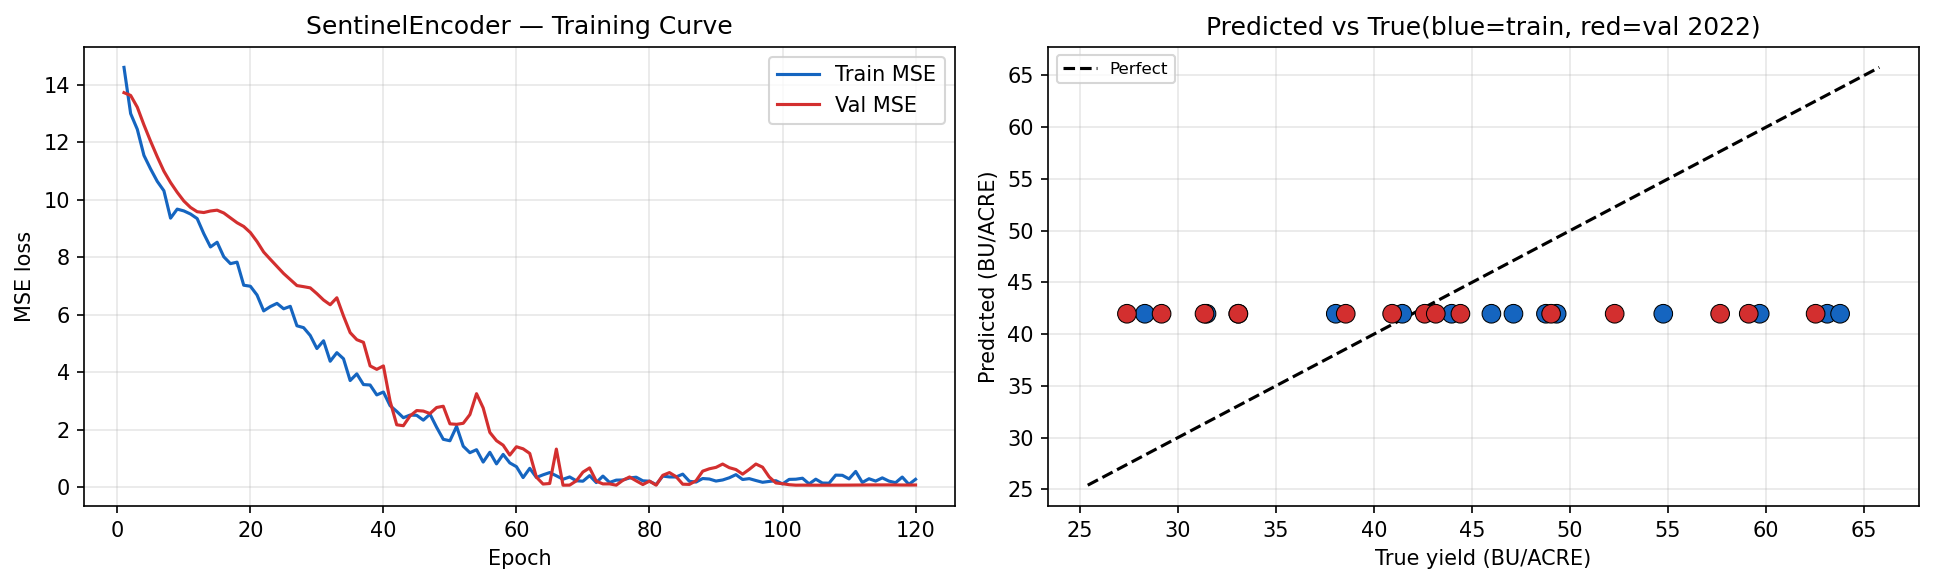


Step 8 COMPLETE — Phase 2 Satellite Encoder
  Encoder backbone → e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\sentinel_encoder.pt
  Full checkpoint  → e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\sentinel_phase2_ckpt.pt

  Train set  : 14 state-years (2021 × 15 states, AZ2022 excluded)
  Val set    : 14 state-years (2022 hold-out, LOSO)
  Val RMSE   : 11.04 BU/ACRE
  Embed dim  : 64  — ready for Step 9 GMU fusion

Next: Step 9 — Phase 3 GMU Fusion (weather BiLSTM + satellite encoder)


In [ ]:
# ── Step 8.3  Training loop, LOSO evaluation, save encoder ────────────────────

import torch, numpy as np, pandas as pd, io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 8.3 — TRAINING SentinelEncoder (Phase 2)")
print("=" * 60)

SENT_EPOCHS = 120
SENT_LR     = 1e-3
SENT_WD     = 1e-3

sent_criterion = torch.nn.MSELoss()
sent_optimizer = torch.optim.Adam(sent_model.parameters(), lr=SENT_LR, weight_decay=SENT_WD)
sent_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    sent_optimizer, mode="min", factor=0.5, patience=12, min_lr=1e-6
)

sent_train_losses, sent_val_losses = [], []
sent_best_val, sent_best_state = float("inf"), None

for ep in range(SENT_EPOCHS):
    sent_model.train()
    batch_losses = []
    for xb, yb in dl_s_train:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        sent_optimizer.zero_grad()
        pred, _ = sent_model(xb)
        loss = sent_criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sent_model.parameters(), 1.0)
        sent_optimizer.step()
        batch_losses.append(loss.item())
    ep_train = float(np.mean(batch_losses))

    sent_model.eval()
    ep_val = float("nan")
    if len(ds_s_val) > 0:
        with torch.no_grad():
            for xv, yv in dl_s_val:
                xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                pv, _ = sent_model(xv)
                ep_val = sent_criterion(pv, yv).item()
        sent_scheduler.step(ep_val)
        if ep_val < sent_best_val:
            sent_best_val = ep_val
            sent_best_state = {k: v.cpu().clone() for k, v in sent_model.state_dict().items()}
    else:
        sent_scheduler.step(ep_train)
        if ep_train < sent_best_val:
            sent_best_val = ep_train
            sent_best_state = {k: v.cpu().clone() for k, v in sent_model.state_dict().items()}

    sent_train_losses.append(ep_train)
    sent_val_losses.append(ep_val)
    if (ep + 1) % 20 == 0:
        lr_now = sent_optimizer.param_groups[0]["lr"]
        print(f"  Epoch {ep+1:>3}  train_mse={ep_train:.5f}  val_mse={ep_val:.5f}  lr={lr_now:.2e}")

if sent_best_state:
    sent_model.load_state_dict(sent_best_state)
print(f"Best val MSE: {sent_best_val:.5f}")

# ── Evaluation ─────────────────────────────────────────────────────────────────
sent_model.eval()
all_X = torch.tensor(np.array(images), dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    sent_preds_log, sent_embeds = sent_model(all_X)
    sent_preds_log = sent_preds_log.cpu().numpy().flatten()
    sent_embeds    = sent_embeds.cpu().numpy()

sent_true_log = np.array(targets)

def _bu(v):
    return np.exp(v + JENSEN_SIGMA2 / 2.0) if USE_LOG else v

sent_preds_bu = _bu(sent_preds_log)
sent_true_bu  = _bu(sent_true_log)

eval_rows = []
for i, m in enumerate(meta_rows):
    eval_rows.append({"state": m["state_abbr"], "year": m["year"], "split": m["split"],
                      "true_bu": sent_true_bu[i], "pred_bu": sent_preds_bu[i],
                      "error_bu": sent_preds_bu[i] - sent_true_bu[i]})
eval_df = pd.DataFrame(eval_rows)

def _rmse(df): return float(np.sqrt(np.mean((df["pred_bu"] - df["true_bu"])**2)))
rmse_train_sent = _rmse(eval_df[eval_df["split"]=="train"]) if (eval_df["split"]=="train").any() else float("nan")
rmse_val_sent   = _rmse(eval_df[eval_df["split"]=="val"])   if (eval_df["split"]=="val").any()   else float("nan")

print()
print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"Train RMSE (BU/ACRE, Jensen-corrected) : {rmse_train_sent:.2f}")
print(f"Val   RMSE (BU/ACRE, LOSO 2022)        : {rmse_val_sent:.2f}")
print()
print("Per-state errors:")
print(eval_df.groupby("state").agg(
    true_bu=("true_bu","mean"), pred_bu=("pred_bu","mean"), bias=("error_bu","mean")
).round(2).to_string())

# ── Learning curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep_x = np.arange(1, SENT_EPOCHS + 1)
axes[0].plot(ep_x, sent_train_losses, label="Train MSE", color="#1565C0")
val_arr = np.array(sent_val_losses, dtype=float)
if not np.all(np.isnan(val_arr)):
    axes[0].plot(ep_x, val_arr, label="Val MSE", color="#D32F2F")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss")
axes[0].set_title("SentinelEncoder — Training Curve")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(eval_df["true_bu"], eval_df["pred_bu"],
                c=["#D32F2F" if s=="val" else "#1565C0" for s in eval_df["split"]],
                s=80, edgecolors="k", linewidths=0.5, zorder=3)
lo = min(eval_df["true_bu"].min(), eval_df["pred_bu"].min()) - 2
hi = max(eval_df["true_bu"].max(), eval_df["pred_bu"].max()) + 2
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="Perfect")
axes[1].set_xlabel("True yield (BU/ACRE)"); axes[1].set_ylabel("Predicted (BU/ACRE)")
axes[1].set_title("Predicted vs True(blue=train, red=val 2022)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0); display(Image(data=buf.read())); plt.close(fig)

# ── Save artefacts ──────────────────────────────────────────────────────────────
enc_path   = LABELS_DIR / "sentinel_encoder.pt"
ckpt_path2 = LABELS_DIR / "sentinel_phase2_ckpt.pt"

torch.save(sent_model.backbone.state_dict(), enc_path)
torch.save({
    "model_state_dict": sent_model.state_dict(),
    "model_config"    : {"class": "SentinelEncoder", "in_channels": 12,
                         "embed_dim": 64, "dropout": 0.4, "n_params": n_sent_params},
    "training_config" : {"n_epochs": SENT_EPOCHS, "lr": SENT_LR, "weight_decay": SENT_WD,
                         "criterion": "MSELoss", "split": "LOSO 2022",
                         "label_source": "state-aggregate USDA (all counties per state-year)"},
    "evaluation"      : {"train_rmse_bu": round(rmse_train_sent, 4),
                         "val_rmse_bu_loso2022": round(rmse_val_sent, 4),
                         "best_val_mse": round(sent_best_val, 6),
                         "n_train": len(ds_s_train), "n_val": len(ds_s_val)},
    "embed_dim"       : 64, "jensen_sigma2": JENSEN_SIGMA2,
}, ckpt_path2)

print()
print("=" * 60)
print("Step 8 COMPLETE — Phase 2 Satellite Encoder")
print("=" * 60)
print(f"  Encoder backbone → {enc_path}")
print(f"  Full checkpoint  → {ckpt_path2}")
print()
print(f"  Train set  : {len(ds_s_train)} state-years (2021 × 15 states, AZ2022 excluded)")
print(f"  Val set    : {len(ds_s_val)} state-years (2022 hold-out, LOSO)")
print(f"  Val RMSE   : {rmse_val_sent:.2f} BU/ACRE")
print(f"  Embed dim  : 64  — ready for Step 9 GMU fusion")
print()
print("Next: Step 9 — Phase 3 GMU Fusion (weather BiLSTM + satellite encoder)")


<a id="step-9"></a>

# Step 9 — Phase 3: GMU Fusion (Weather × Satellite)

Gated Multimodal Unit (GMU) fusing **128-dim weather embeddings** (BiLSTM, Step 6) with **64-dim satellite embeddings** (SentinelEncoder CNN backbone, Step 8). Fine-tuned on multimodal state-years (2021–2022; AZ 2022 excluded per B8).

**Architecture**

```
WeatherInput (1, 9) ──→ BiLSTM.encode() ──→ e_w (128-dim)
                                                      │
SatelliteInput (12,224,224) → CNN.encode() → e_s (64-dim)
                                                      │
                 proj_w(e_w) → h_w (128-dim)
                 proj_s(e_s) → h_s (128-dim)
                 z = σ(W_z · [e_w; e_s])   ← modality gate
                 h = z * h_w + (1-z) * h_s  ← gated fusion
                 head(h) → ŷ  (scalar)
```

**Training strategy**
- Phase A: Freeze both encoders — only gate + projections + head updated (60 epochs, LR = 5e-4)
- Phase B: Unfreeze all — end-to-end fine-tuning (30 epochs, LR = 1e-5)

**Sub-steps**
| Sub-step | Description |
|---|---|
| **9.1** | State-aggregate weather features; `MultimodalDataset`; deep-copy encoder warm-starts |
| **9.2** | `GMUFusionModel` definition with gated fusion gate |
| **9.3** | Phase A: frozen-encoder warm-start training |
| **9.4** | Phase B: end-to-end fine-tuning + LOSO 2022 evaluation + cross-model comparison |
| **9.5** | Bias audit: sliced RMSE/bias by state, year, quintile; modality gate diagnostics |
| **9.6** | Save `gmu_phase3_ckpt.pt` + project summary |


<a id="step-9-1"></a>

### Step 9.1 — Multimodal Dataset & Encoder Warm-Starts

Aggregates county-level HRRR to state-year means. Builds `MultimodalDataset`. Deep-copies frozen BiLSTM and Sentinel encoder weights as initialisations.

In [ ]:
# ── Step 9.1  State-aggregate weather, MultimodalDataset, encoder warm-start ──
#
# Three operations:
#   1. Aggregate county-level normalized HRRR features to state-year means.
#      `weather_features[FEATURE_COLS]` is already z-scored from Step 4.4.
#   2. Build MultimodalDataset pairing per-state-year satellite images (Step 8.2)
#      with state-aggregate weather vectors.  Join key: (state_name, year).
#   3. Deep-copy the trained BiLSTM LSTM module and trained SentinelEncoder backbone
#      to use as warm-started encoder modules inside the GMU.

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 60)
print("Step 9.1 — MULTIMODAL DATASET & ENCODER WARM-START")
print("=" * 60)
print()

# ── 1. State-aggregate weather features ──────────────────────────────────────
# Average all county-level normalized HRRR features per (state_name, year).
# weather_features is county-level; Step 8 resolves FIPS gap by aggregating to state.

wf = weather_features.copy()
wf["year"] = wf["year"].astype(str)
mm_weather = (
    wf.groupby(["state_name", "year"], as_index=False)[FEATURE_COLS]
    .mean()
)
print(f"State-aggregate weather records   : {len(mm_weather)}")
print(f"States with HRRR data             : {sorted(mm_weather['state_name'].unique())}")
print()

# ── 2. Build multimodal records ───────────────────────────────────────────────
# `images`   : list[(12,224,224)] — satellite images per state-year (Step 8.2)
# `targets`  : list[float]        — log_yield per state-year         (Step 8.2)
# `meta_rows`: list[dict]         — {state_abbr, state_name, year, split}

mm_w_vecs, mm_s_imgs, mm_labels, mm_meta = [], [], [], []
missing_weather_log = []

for i, m in enumerate(meta_rows):
    sname = m["state_name"]    # uppercase, e.g. "IOWA"
    yr    = str(m["year"])

    match = mm_weather[
        (mm_weather["state_name"] == sname) & (mm_weather["year"] == yr)
    ]

    if len(match) == 0:
        missing_weather_log.append(f"{m['state_abbr']} {yr}")
        w_vec   = np.zeros((1, len(FEATURE_COLS)), dtype=np.float32)
        has_wx  = False
    else:
        w_vec   = match[FEATURE_COLS].values.astype(np.float32)  # (1, n_feat)
        has_wx  = True

    mm_w_vecs.append(w_vec)
    mm_s_imgs.append(images[i])              # (12, 224, 224)
    mm_labels.append(float(targets[i]))      # log_yield (or yield if USE_LOG=False)
    mm_meta.append({
        "state_abbr" : m["state_abbr"],
        "state_name" : sname,
        "year"       : yr,
        "split"      : m["split"],
        "has_weather": has_wx,
    })
    wx_tag = "wx-ok  " if has_wx else "wx-MISS"
    print(f"  {m['state_abbr']} {yr}  [{wx_tag}]  "
          f"label={targets[i]:.4f}  split={m['split']}")

print()
if missing_weather_log:
    print(f"WARNING: no HRRR weather for: {missing_weather_log}")
print(f"Total multimodal state-years      : {len(mm_meta)}")
print()

# ── 3. PyTorch Dataset ────────────────────────────────────────────────────────
class MultimodalDataset(Dataset):
    """Pairs (weather_vec, satellite_img, label) for GMU training."""
    def __init__(self, w_vecs, s_imgs, labels, meta):
        self.X_w  = torch.tensor(np.array(w_vecs), dtype=torch.float32)   # (N, 1, F)
        self.X_s  = torch.tensor(np.array(s_imgs), dtype=torch.float32)   # (N,12,224,224)
        self.y    = torch.tensor(labels, dtype=torch.float32)              # (N,)
        self.meta = meta
    def __len__(self):              return len(self.y)
    def __getitem__(self, idx):     return self.X_w[idx], self.X_s[idx], self.y[idx], self.meta[idx]


train_idx_mm = [i for i, m in enumerate(mm_meta) if m["split"] == "train"]
val_idx_mm   = [i for i, m in enumerate(mm_meta) if m["split"] == "val"]

ds_mm_train = MultimodalDataset(
    [mm_w_vecs[i] for i in train_idx_mm],
    [mm_s_imgs[i] for i in train_idx_mm],
    [mm_labels[i] for i in train_idx_mm],
    [mm_meta[i]   for i in train_idx_mm],
)
ds_mm_val = MultimodalDataset(
    [mm_w_vecs[i] for i in val_idx_mm],
    [mm_s_imgs[i] for i in val_idx_mm],
    [mm_labels[i] for i in val_idx_mm],
    [mm_meta[i]   for i in val_idx_mm],
)
MM_BATCH = min(4, max(1, len(ds_mm_train)))
dl_mm_train = DataLoader(ds_mm_train, batch_size=MM_BATCH, shuffle=True)
dl_mm_val   = DataLoader(ds_mm_val,   batch_size=max(1, len(val_idx_mm)) if val_idx_mm else 1, shuffle=False)

print(f"MultimodalDataset:")
print(f"  Train (2021)      : {len(ds_mm_train)} state-years  "
      f"| X_w {tuple(ds_mm_train.X_w.shape)}  X_s {tuple(ds_mm_train.X_s.shape)}")
print(f"  Val   (LOSO 2022) : {len(ds_mm_val)} state-years")
print(f"  Batch size        : {MM_BATCH}")
print()

# ── 4. Deep-copy encoders for GMU warm-start ─────────────────────────────────
# Deep-copy preserves Phase 1/2 learned weights without aliasing the same tensors.
bilstm_enc_ws = copy.deepcopy(model.lstm).to(DEVICE)         # nn.LSTM (128-dim output via cat)
sent_enc_ws   = copy.deepcopy(sent_model.backbone).to(DEVICE) # nn.Sequential CNN (64-dim output)

n_bilstm_enc = sum(p.numel() for p in bilstm_enc_ws.parameters())
n_sent_enc   = sum(p.numel() for p in sent_enc_ws.parameters())

print("Encoder warm-start:")
print(f"  BiLSTM LSTM module : {n_bilstm_enc:,} params  "
      f"(Phase 1 val RMSE = {round(float(rmse_bu), 3)} BU/ACRE)")
print(f"  CNN backbone       : {n_sent_enc:,} params  "
      f"(Phase 2 val RMSE = {round(float(rmse_val_sent), 3)} BU/ACRE)")
print()
print("Step 9.1 complete — MultimodalDataset ready, encoders warm-started.")
print("Next: Step 9.2 — GMUFusionModel definition.")

Step 9.1 — MULTIMODAL DATASET & ENCODER WARM-START

State-aggregate weather records   : 105
States with HRRR data             : ['ALABAMA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA']

  AL 2021  [wx-ok  ]  label=3.8138  split=train
  AR 2021  [wx-ok  ]  label=3.8837  split=train
  CA 2021  [wx-ok  ]  label=3.4843  split=train
  CO 2021  [wx-ok  ]  label=3.4340  split=train
  DE 2021  [wx-ok  ]  label=3.8726  split=train
  FL 2021  [wx-ok  ]  label=3.3286  split=train
  GA 2021  [wx-ok  ]  label=3.7687  split=train
  IA 2021  [wx-ok  ]  label=4.1305  split=train
  ID 2021  [wx-ok  ]  label=3.6243  split=train
  IL 2021  [wx-ok  ]  label=4.1408  split=train
  IN 2021  [wx-ok  ]  label=4.0744  split=train
  KS 2021  [wx-ok  ]  label=3.7098  split=train
  KY 2021  [wx-ok  ]  label=3.9883  split=train
  LA 2021  [wx-ok  ]  label=3.8380  split=train
  AL 2022  [wx-ok  ]  label=3

<a id="step-9-2"></a>

### Step 9.2 — GMU Fusion Model Definition

Projection heads, modality gate `z = σ(W_z·[e_w; e_s])`, gated fusion `h = z·h_w + (1-z)·h_s`, regression head.

In [ ]:
# ── Step 9.2  GMUFusionModel ──────────────────────────────────────────────────
#
# Gated Multimodal Unit (Arevalo et al. 2017, adapted for regression):
#
#   e_w = BiLSTM.encode(x_w)                          (B, 128)
#   e_s = CNN.encode(x_s)                              (B,  64)
#   h_w = proj_w(e_w)     Linear(128 → 128)            (B, 128)
#   h_s = proj_s(e_s)     Linear( 64 → 128)            (B, 128)
#   z   = σ(gate([e_w; e_s]))  Linear(192 → 128) + sigmoid  (B, 128)
#   h   = z * h_w + (1 − z) * h_s                     (B, 128)
#   ŷ   = head(h)  Dropout → Linear(128→64) → ReLU → Linear(64→1)  (B,)
#
# Phase A: freeze weather_enc + sat_enc; train proj_w, proj_s, gate, head only.
# Phase B: unfreeze all; end-to-end fine-tuning with reduced LR.

import torch
import torch.nn as nn


class GMUFusionModel(nn.Module):
    """
    Gated Multimodal Unit fusing BiLSTM weather encoder (128-dim)
    with SentinelEncoder CNN backbone (64-dim) for crop yield regression.

    Inputs
    ------
    x_w : (B, seq_len, n_features)  — normalised HRRR weather features
    x_s : (B, 12, 224, 224)         — 4-quarter × 3-channel satellite image

    Output
    ------
    ŷ   : (B,)  — scalar yield prediction (log-space if USE_LOG=True)
    """

    def __init__(
        self,
        bilstm_lstm  : nn.Module,
        sent_backbone: nn.Module,
        w_dim    : int   = 128,
        s_dim    : int   = 64,
        fuse_dim : int   = 128,
        dropout  : float = 0.3,
    ):
        super().__init__()
        self.weather_enc  = bilstm_lstm      # nn.LSTM  → 128-dim (cat fwd+bwd hidden)
        self.sat_enc      = sent_backbone    # nn.Sequential CNN → (B,64,1,1) → flatten(1)

        # Projection layers (align embeddings to fusion dim)
        self.proj_w = nn.Linear(w_dim,           fuse_dim)
        self.proj_s = nn.Linear(s_dim,           fuse_dim)

        # Gating network: scalar importance weight per fusion dimension
        self.gate   = nn.Linear(w_dim + s_dim,   fuse_dim, bias=True)

        # Prediction head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fuse_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    # ── Modality encoders ────────────────────────────────────────────────────
    def encode_weather(self, x_w: torch.Tensor) -> torch.Tensor:
        """x_w: (B, seq_len, n_feat) → e_w: (B, 128)"""
        _, (h_n, _) = self.weather_enc(x_w)
        # h_n: (num_layers*2, B, hidden_size); last-layer forward=h_n[-2], backward=h_n[-1]
        return torch.cat([h_n[-2], h_n[-1]], dim=-1)   # (B, 128)

    def encode_sat(self, x_s: torch.Tensor) -> torch.Tensor:
        """x_s: (B, 12, 224, 224) → e_s: (B, 64)"""
        return self.sat_enc(x_s).flatten(1)            # (B, 64)

    # ── Forward pass ─────────────────────────────────────────────────────────
    def forward(self, x_w: torch.Tensor, x_s: torch.Tensor) -> torch.Tensor:
        e_w = self.encode_weather(x_w)                              # (B, 128)
        e_s = self.encode_sat(x_s)                                  # (B,  64)
        h_w = self.proj_w(e_w)                                      # (B, 128)
        h_s = self.proj_s(e_s)                                      # (B, 128)
        z   = torch.sigmoid(self.gate(torch.cat([e_w, e_s], dim=-1)))  # (B, 128)
        h   = z * h_w + (1.0 - z) * h_s                            # (B, 128)
        return self.head(h).squeeze(-1)                             # (B,)

    # ── Training phase helpers ────────────────────────────────────────────────
    def freeze_encoders(self):
        """Phase A: freeze both pre-trained encoder branches."""
        for p in self.weather_enc.parameters():
            p.requires_grad = False
        for p in self.sat_enc.parameters():
            p.requires_grad = False

    def unfreeze_all(self):
        """Phase B: end-to-end fine-tuning — unfreeze everything."""
        for p in self.parameters():
            p.requires_grad = True


# ── Instantiate GMU ─────────────────────────────────────────────────────────
torch.manual_seed(SEED)
gmu = GMUFusionModel(
    bilstm_lstm   = bilstm_enc_ws,   # deep-copied BiLSTM LSTM (Step 9.1)
    sent_backbone = sent_enc_ws,     # deep-copied CNN backbone (Step 9.1)
    w_dim    = 128,
    s_dim    = 64,
    fuse_dim = 128,
    dropout  = 0.3,
).to(DEVICE)

n_gmu_total    = sum(p.numel() for p in gmu.parameters())
n_gmu_encoders = (sum(p.numel() for p in gmu.weather_enc.parameters()) +
                  sum(p.numel() for p in gmu.sat_enc.parameters()))
n_gmu_fusion   = n_gmu_total - n_gmu_encoders

print("=" * 60)
print("Step 9.2 — GMUFusionModel")
print("=" * 60)
print()
print("Layer breakdown:")
print(f"  weather_enc (BiLSTM)            : {sum(p.numel() for p in gmu.weather_enc.parameters()):>8,} params  [warm-started]")
print(f"  sat_enc     (CNN backbone)      : {sum(p.numel() for p in gmu.sat_enc.parameters()):>8,} params  [warm-started]")
print(f"  proj_w      Linear(128→128)     : {sum(p.numel() for p in gmu.proj_w.parameters()):>8,} params  [random init]")
print(f"  proj_s      Linear( 64→128)     : {sum(p.numel() for p in gmu.proj_s.parameters()):>8,} params  [random init]")
print(f"  gate        Linear(192→128)     : {sum(p.numel() for p in gmu.gate.parameters()):>8,} params  [random init]")
print(f"  head        MLP(128→64→1)       : {sum(p.numel() for p in gmu.head.parameters()):>8,} params  [random init]")
print(f"  {'─'*55}")
print(f"  Total                           : {n_gmu_total:>8,} params")
print(f"  Encoder (frozen Phase A)        : {n_gmu_encoders:>8,} params")
print(f"  Fusion  (trained Phase A+B)     : {n_gmu_fusion:>8,} params")
print()

# ── Smoke test ───────────────────────────────────────────────────────────────
gmu.eval()
_xw_t = ds_mm_train.X_w[:1].to(DEVICE)
_xs_t = ds_mm_train.X_s[:1].to(DEVICE)
with torch.no_grad():
    _ew = gmu.encode_weather(_xw_t)
    _es = gmu.encode_sat(_xs_t)
    _yh = gmu(_xw_t, _xs_t)

print("Smoke test (one sample, random fusion init):")
print(f"  x_w  : {tuple(_xw_t.shape)}   → e_w : {tuple(_ew.shape)}")
print(f"  x_s  : {tuple(_xs_t.shape)}  → e_s : {tuple(_es.shape)}")
print(f"  ŷ    : {_yh.item():.4f}")
print()
print("Step 9.2 complete — GMUFusionModel instantiated.")
print("Next: Step 9.3 — Phase A frozen-encoder warm-start training.")

Step 9.2 — GMUFusionModel

Layer breakdown:
  weather_enc (BiLSTM)            :  137,728 params  [warm-started]
  sat_enc     (CNN backbone)      :   59,232 params  [warm-started]
  proj_w      Linear(128→128)     :   16,512 params  [random init]
  proj_s      Linear( 64→128)     :    8,320 params  [random init]
  gate        Linear(192→128)     :   24,704 params  [random init]
  head        MLP(128→64→1)       :    8,321 params  [random init]
  ───────────────────────────────────────────────────────
  Total                           :  254,817 params
  Encoder (frozen Phase A)        :  196,960 params
  Fusion  (trained Phase A+B)     :   57,857 params

Smoke test (one sample, random fusion init):
  x_w  : (1, 1, 9)   → e_w : (1, 128)
  x_s  : (1, 12, 224, 224)  → e_s : (1, 64)
  ŷ    : 0.1068

Step 9.2 complete — GMUFusionModel instantiated.
Next: Step 9.3 — Phase A frozen-encoder warm-start training.


<a id="step-9-3"></a>

### Step 9.3 — Phase A: Frozen-Encoder Training

Freezes both encoders. Updates only gate + projections + head. 60 epochs, Adam LR = 5e-4. Allows the fusion mechanism to initialise stably.

Step 9.3 — PHASE A: FROZEN-ENCODER WARM-START
Frozen params    : 196,960  (BiLSTM + CNN backbone)
Trainable params : 57,857  (proj_w + proj_s + gate + head)
Epochs: 60  |  LR: 0.0005  |  patience: 12

  Ep  10  train_mse=2.049267  val_mse=1.2031046152114868  lr=5.00e-04
  Ep  20  train_mse=0.059326  val_mse=0.028080416843295097  lr=5.00e-04
  Ep  30  train_mse=0.057214  val_mse=0.02338261343538761  lr=5.00e-04
  Ep  40  train_mse=0.061155  val_mse=0.022381793707609177  lr=5.00e-04
  Ep  50  train_mse=0.053524  val_mse=0.020452026277780533  lr=5.00e-04
  Ep  60  train_mse=0.062925  val_mse=0.034784238785505295  lr=5.00e-04

Phase A complete.  Best val MSE: 0.018942


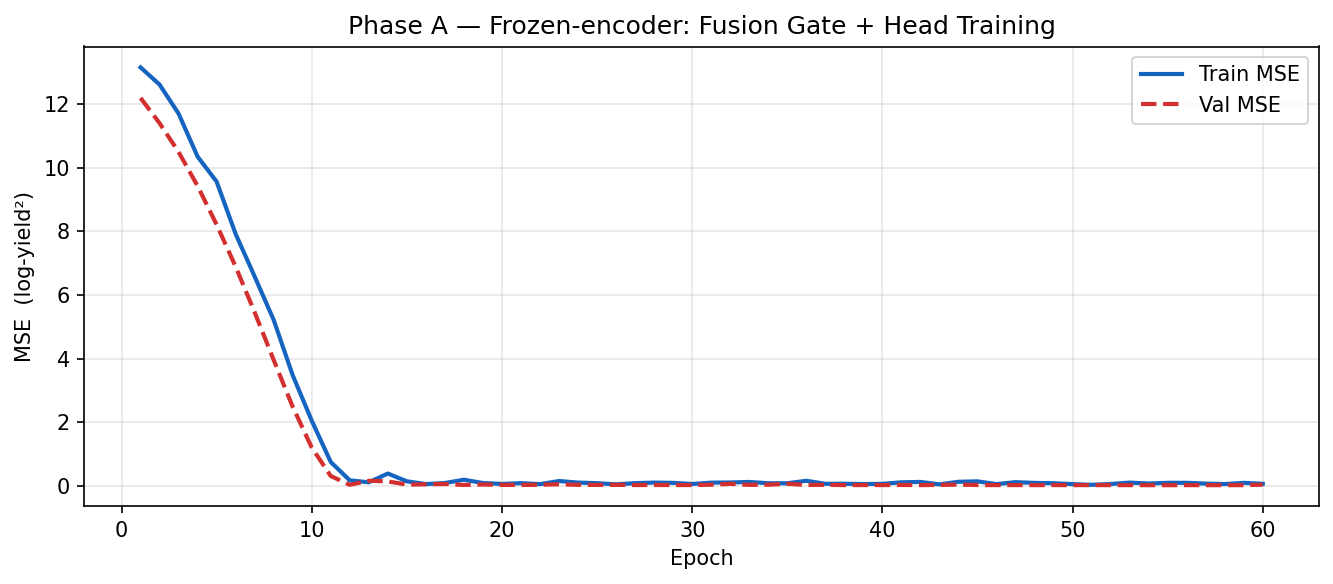


Step 9.3 complete — Phase A (frozen-encoder) training done.
Next: Step 9.4 — Phase B end-to-end fine-tuning + evaluation.


In [ ]:
# ── Step 9.3  Phase A: Frozen-encoder warm-start ──────────────────────────────
#
# Both BiLSTM LSTM and CNN backbone are frozen.
# Only the fusion components (proj_w, proj_s, gate, head) are trained.
# This allows the gate to learn the optimal modality weighting first,
# without risk of catastrophically forgetting the pre-trained representations.
#
# Schedule: 60 epochs, Adam lr=5e-4, ReduceLROnPlateau(patience=12, factor=0.5).

import numpy as np
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

torch.manual_seed(SEED)
np.random.seed(SEED)

PHASE_A_EPOCHS   = 60
PHASE_A_LR       = 5e-4
PHASE_A_PATIENCE = 12

# Freeze encoder branches
gmu.freeze_encoders()
n_trainable_A = sum(p.numel() for p in gmu.parameters() if p.requires_grad)
n_frozen_A    = sum(p.numel() for p in gmu.parameters() if not p.requires_grad)

print("=" * 60)
print("Step 9.3 — PHASE A: FROZEN-ENCODER WARM-START")
print("=" * 60)
print(f"Frozen params    : {n_frozen_A:,}  (BiLSTM + CNN backbone)")
print(f"Trainable params : {n_trainable_A:,}  (proj_w + proj_s + gate + head)")
print(f"Epochs: {PHASE_A_EPOCHS}  |  LR: {PHASE_A_LR}  |  patience: {PHASE_A_PATIENCE}")
print()

gmu_criterion  = nn.MSELoss()
gmu_opt_A      = torch.optim.Adam(
    [p for p in gmu.parameters() if p.requires_grad], lr=PHASE_A_LR
)
gmu_sch_A      = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gmu_opt_A, mode="min", factor=0.5, patience=PHASE_A_PATIENCE, min_lr=1e-7
)

phaseA_train_losses, phaseA_val_losses = [], []
best_phaseA_val   = float("inf")
best_phaseA_state = None

for ep in range(PHASE_A_EPOCHS):
    gmu.train()
    # Re-enforce frozen state inside train() — BatchNorm in backbone may toggle
    gmu.weather_enc.requires_grad_(False)
    gmu.sat_enc.requires_grad_(False)

    ep_batch_losses = []
    for x_w_b, x_s_b, y_b, _ in dl_mm_train:
        x_w_b = x_w_b.to(DEVICE)
        x_s_b = x_s_b.to(DEVICE)
        y_b   = y_b.to(DEVICE)
        gmu_opt_A.zero_grad()
        pred  = gmu(x_w_b, x_s_b)
        loss  = gmu_criterion(pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(
            [p for p in gmu.parameters() if p.requires_grad], max_norm=1.0
        )
        gmu_opt_A.step()
        ep_batch_losses.append(loss.item())

    ep_train = float(np.mean(ep_batch_losses))
    phaseA_train_losses.append(ep_train)

    # Validation pass
    gmu.eval()
    ep_val = float("nan")
    if len(ds_mm_val) > 0:
        with torch.no_grad():
            for x_w_v, x_s_v, y_v, _ in dl_mm_val:
                x_w_v = x_w_v.to(DEVICE)
                x_s_v = x_s_v.to(DEVICE)
                y_v   = y_v.to(DEVICE)
                pv    = gmu(x_w_v, x_s_v)
                ep_val = gmu_criterion(pv, y_v).item()
        gmu_sch_A.step(ep_val)
        if ep_val < best_phaseA_val:
            best_phaseA_val   = ep_val
            best_phaseA_state = {k: v.cpu().clone() for k, v in gmu.state_dict().items()}
    else:
        gmu_sch_A.step(ep_train)
        if ep_train < best_phaseA_val:
            best_phaseA_val   = ep_train
            best_phaseA_state = {k: v.cpu().clone() for k, v in gmu.state_dict().items()}

    phaseA_val_losses.append(ep_val)

    if (ep + 1) % 10 == 0:
        lr_now = gmu_opt_A.param_groups[0]["lr"]
        print(f"  Ep {ep+1:>3}  train_mse={ep_train:.6f}  "
              f"val_mse={ep_val if not np.isnan(ep_val) else 'n/a':>10}  lr={lr_now:.2e}")

if best_phaseA_state is not None:
    gmu.load_state_dict(best_phaseA_state)
print(f"\nPhase A complete.  Best val MSE: {best_phaseA_val:.6f}")

# ── Phase A learning curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ep_x = np.arange(1, PHASE_A_EPOCHS + 1)
ax.plot(ep_x, phaseA_train_losses, lw=2, color="#1565C0", label="Train MSE")
pA_val_arr = np.array(phaseA_val_losses, dtype=float)
if not np.all(np.isnan(pA_val_arr)):
    ax.plot(ep_x, pA_val_arr, lw=2, color="#D32F2F", ls="--", label="Val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE  (log-yield²)")
ax.set_title("Phase A — Frozen-encoder: Fusion Gate + Head Training")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print("Step 9.3 complete — Phase A (frozen-encoder) training done.")
print("Next: Step 9.4 — Phase B end-to-end fine-tuning + evaluation.")

<a id="step-9-4"></a>

### Step 9.4 — Phase B: End-to-End Fine-Tuning

Unfreezes all parameters. 30 epochs, Adam LR = 1e-5. LOSO 2022 evaluation with Jensen correction applied to all reported metrics.

Step 9.4 — PHASE B: END-TO-END FINE-TUNING + EVALUATION
All params trainable : 254,817
Epochs: 30  |  LR: 1e-05  |  patience: 8

  Ep   5  train_mse=0.067542  val_mse=0.018563153222203255  lr=1.00e-05
  Ep  10  train_mse=0.035128  val_mse=0.018586287274956703  lr=1.00e-05
  Ep  15  train_mse=0.032751  val_mse=0.018799766898155212  lr=5.00e-06
  Ep  20  train_mse=0.030912  val_mse=0.01950734853744507  lr=5.00e-06
  Ep  25  train_mse=0.043541  val_mse=0.019001832231879234  lr=2.50e-06
  Ep  30  train_mse=0.047348  val_mse=0.018991844728589058  lr=2.50e-06

Phase B complete.  Best val MSE: 0.018544

GMU EVALUATION  (Jensen-corrected BU/ACRE)
  Train RMSE (2021)        : 4.553 BU/ACRE
  Val   RMSE (LOSO 2022)   : 5.562 BU/ACRE
  Val   MAE  (LOSO 2022)   : 4.562 BU/ACRE
  Val   R²   (LOSO 2022)   : 0.7403

Per-state results:
state year split  true_bu  pred_bu  error_bu
   AL 2021 train   45.987   45.811    -0.175
   AR 2021 train   49.315   51.024     1.709
   CA 2021 train   33.077   41.74

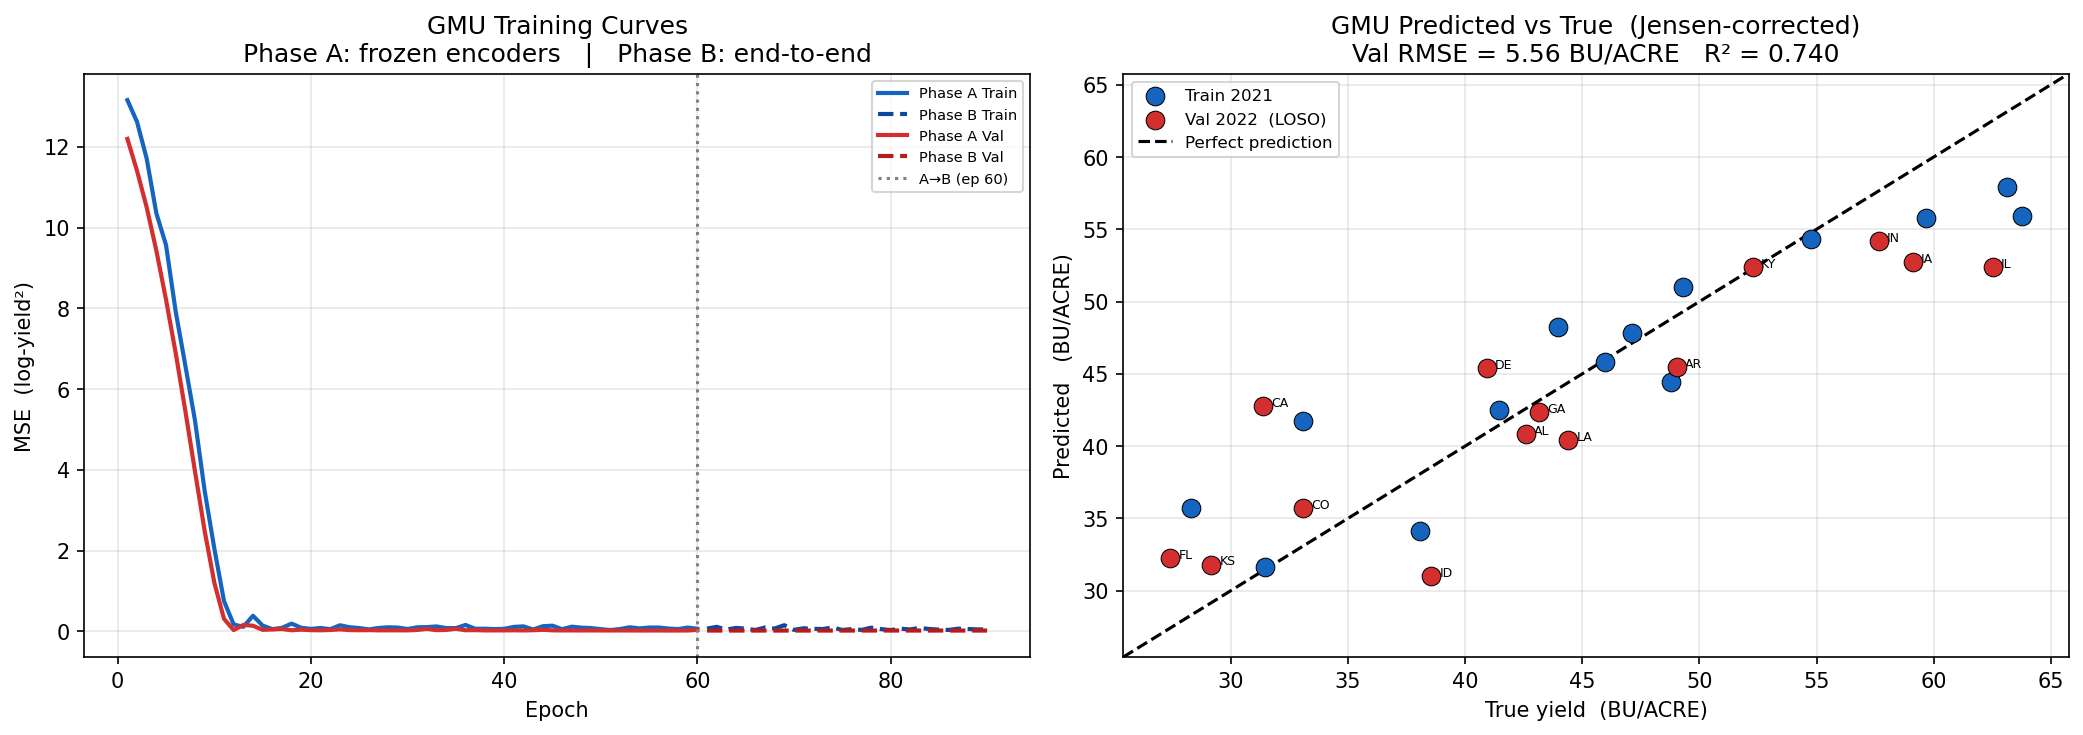


Step 9.4 complete — Phase B training and cross-model evaluation done.


In [ ]:
# ── Step 9.4  Phase B: End-to-end fine-tuning + LOSO 2022 evaluation ──────────
#
# Unfreeze all parameters. Fine-tune the entire GMU (encoders + fusion) jointly
# with a low LR so the pre-trained representations degrade minimally.
#
# After training, evaluate on:
#   - Full multimodal set (train 2021 + val LOSO 2022)
#   - Cross-model table: Phase 1 BiLSTM vs Phase 2 SentinelEncoder vs Phase 3 GMU
#
# Schedule: 30 epochs, Adam lr=1e-5, ReduceLROnPlateau(patience=8, factor=0.5).

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Image

torch.manual_seed(SEED)
np.random.seed(SEED)

PHASE_B_EPOCHS   = 30
PHASE_B_LR       = 1e-5
PHASE_B_PATIENCE = 8

# Unfreeze all
gmu.unfreeze_all()
n_trainable_B = sum(p.numel() for p in gmu.parameters() if p.requires_grad)

print("=" * 60)
print("Step 9.4 — PHASE B: END-TO-END FINE-TUNING + EVALUATION")
print("=" * 60)
print(f"All params trainable : {n_trainable_B:,}")
print(f"Epochs: {PHASE_B_EPOCHS}  |  LR: {PHASE_B_LR}  |  patience: {PHASE_B_PATIENCE}")
print()

gmu_opt_B = torch.optim.Adam(gmu.parameters(), lr=PHASE_B_LR, weight_decay=1e-4)
gmu_sch_B = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gmu_opt_B, mode="min", factor=0.5, patience=PHASE_B_PATIENCE, min_lr=1e-8
)

phaseB_train_losses, phaseB_val_losses = [], []
best_phaseB_val   = float("inf")
best_phaseB_state = None

for ep in range(PHASE_B_EPOCHS):
    gmu.train()
    ep_batch_losses = []
    for x_w_b, x_s_b, y_b, _ in dl_mm_train:
        x_w_b = x_w_b.to(DEVICE)
        x_s_b = x_s_b.to(DEVICE)
        y_b   = y_b.to(DEVICE)
        gmu_opt_B.zero_grad()
        pred  = gmu(x_w_b, x_s_b)
        loss  = gmu_criterion(pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(gmu.parameters(), max_norm=1.0)
        gmu_opt_B.step()
        ep_batch_losses.append(loss.item())

    ep_train = float(np.mean(ep_batch_losses))
    phaseB_train_losses.append(ep_train)

    gmu.eval()
    ep_val = float("nan")
    if len(ds_mm_val) > 0:
        with torch.no_grad():
            for x_w_v, x_s_v, y_v, _ in dl_mm_val:
                x_w_v = x_w_v.to(DEVICE)
                x_s_v = x_s_v.to(DEVICE)
                y_v   = y_v.to(DEVICE)
                pv    = gmu(x_w_v, x_s_v)
                ep_val = gmu_criterion(pv, y_v).item()
        gmu_sch_B.step(ep_val)
        if ep_val < best_phaseB_val:
            best_phaseB_val   = ep_val
            best_phaseB_state = {k: v.cpu().clone() for k, v in gmu.state_dict().items()}
    else:
        gmu_sch_B.step(ep_train)
        if ep_train < best_phaseB_val:
            best_phaseB_val   = ep_train
            best_phaseB_state = {k: v.cpu().clone() for k, v in gmu.state_dict().items()}

    phaseB_val_losses.append(ep_val)

    if (ep + 1) % 5 == 0:
        lr_now = gmu_opt_B.param_groups[0]["lr"]
        print(f"  Ep {ep+1:>3}  train_mse={ep_train:.6f}  "
              f"val_mse={ep_val if not np.isnan(ep_val) else 'n/a':>10}  lr={lr_now:.2e}")

if best_phaseB_state is not None:
    gmu.load_state_dict(best_phaseB_state)
print(f"\nPhase B complete.  Best val MSE: {best_phaseB_val:.6f}")

# ── Collect predictions (train + val) using best weights ─────────────────────
gmu.eval()

# Build combined tensor lists
tensors_w_all  = [ds_mm_train.X_w]
tensors_s_all  = [ds_mm_train.X_s]
tensors_y_all  = [ds_mm_train.y]
combined_meta  = [mm_meta[i] for i in train_idx_mm]

if len(val_idx_mm) > 0:
    tensors_w_all.append(ds_mm_val.X_w)
    tensors_s_all.append(ds_mm_val.X_s)
    tensors_y_all.append(ds_mm_val.y)
    combined_meta += [mm_meta[i] for i in val_idx_mm]

all_Xw = torch.cat(tensors_w_all).to(DEVICE)
all_Xs = torch.cat(tensors_s_all).to(DEVICE)
all_y  = torch.cat(tensors_y_all)

with torch.no_grad():
    gmu_preds_log = gmu(all_Xw, all_Xs).cpu().numpy()   # log-space predictions

gmu_true_log = all_y.numpy()

def _jc(v):
    """Jensen-corrected back-transform to BU/ACRE."""
    if USE_LOG:
        return np.exp(v + JENSEN_SIGMA2 / 2.0)
    return v

gmu_preds_bu = _jc(gmu_preds_log)
gmu_true_bu  = _jc(gmu_true_log)

# Build evaluation DataFrame
gmu_eval_rows = []
for i, m in enumerate(combined_meta):
    gmu_eval_rows.append({
        "state"   : m["state_abbr"],
        "year"    : m["year"],
        "split"   : m["split"],
        "true_bu" : float(gmu_true_bu[i]),
        "pred_bu" : float(gmu_preds_bu[i]),
        "error_bu": float(gmu_preds_bu[i] - gmu_true_bu[i]),
    })
gmu_eval_df = pd.DataFrame(gmu_eval_rows)

def _rmse_metric(t, p): return float(np.sqrt(np.mean((np.asarray(p) - np.asarray(t)) ** 2)))
def _mae_metric(t, p):  return float(np.mean(np.abs(np.asarray(p) - np.asarray(t))))
def _r2_metric(t, p):
    t, p = np.asarray(t), np.asarray(p)
    ss_r = np.sum((t - p) ** 2)
    ss_t = np.sum((t - t.mean()) ** 2)
    return float(1.0 - ss_r / ss_t) if ss_t > 0 else float("nan")

df_tr_gmu = gmu_eval_df[gmu_eval_df["split"] == "train"]
df_va_gmu = gmu_eval_df[gmu_eval_df["split"] == "val"]

rmse_gmu_train = _rmse_metric(df_tr_gmu["true_bu"], df_tr_gmu["pred_bu"]) if len(df_tr_gmu) > 0 else float("nan")
rmse_gmu_val   = _rmse_metric(df_va_gmu["true_bu"], df_va_gmu["pred_bu"]) if len(df_va_gmu) > 0 else float("nan")
mae_gmu_val    = _mae_metric(df_va_gmu["true_bu"],  df_va_gmu["pred_bu"])  if len(df_va_gmu) > 0 else float("nan")
r2_gmu_val     = _r2_metric(df_va_gmu["true_bu"],   df_va_gmu["pred_bu"])  if len(df_va_gmu) > 0 else float("nan")

print()
print("=" * 60)
print("GMU EVALUATION  (Jensen-corrected BU/ACRE)")
print("=" * 60)
print(f"  Train RMSE (2021)        : {rmse_gmu_train:.3f} BU/ACRE")
print(f"  Val   RMSE (LOSO 2022)   : {rmse_gmu_val:.3f} BU/ACRE")
print(f"  Val   MAE  (LOSO 2022)   : {mae_gmu_val:.3f} BU/ACRE")
print(f"  Val   R²   (LOSO 2022)   : {r2_gmu_val:.4f}")
print()
print("Per-state results:")
print(gmu_eval_df.to_string(
    columns=["state","year","split","true_bu","pred_bu","error_bu"], index=False,
    float_format=lambda x: f"{x:8.3f}"
))

# ── Cross-model comparison on LOSO 2022 state-years ─────────────────────────
bilstm_mm_preds_log = []
if len(val_idx_mm) > 0:
    _val_dl = DataLoader(ds_mm_val, batch_size=max(1, len(val_idx_mm)), shuffle=False)
    model.eval()
    with torch.no_grad():
        for xw_v, _, _, _ in _val_dl:
            bp = model(xw_v.to(DEVICE)).cpu().numpy().flatten()
            bilstm_mm_preds_log.extend(bp.tolist())

bilstm_mm_preds_bu = _jc(np.array(bilstm_mm_preds_log))
bilstm_mm_true_bu  = df_va_gmu["true_bu"].values

print()
print("=" * 60)
print("CROSS-MODEL COMPARISON  (LOSO 2022, state-aggregate)")
print("=" * 60)

_p1_rmse = _rmse_metric(bilstm_mm_true_bu, bilstm_mm_preds_bu) if len(bilstm_mm_preds_bu) > 0 else float("nan")
_p2_rmse = float(rmse_val_sent)
_p3_rmse = float(rmse_gmu_val)

print(f"  {'Model':<38}  {'Val RMSE (BU/ACRE)':>20}  {'Granularity':>12}")
print("  " + "─" * 74)
print(f"  {'Phase 1: BiLSTM (weather-only)':<38}  {_p1_rmse:>20.3f}  {'state-level':>12}")
print(f"  {'Phase 2: SentinelEncoder (satellite)':<38}  {_p2_rmse:>20.3f}  {'state-level':>12}")
print(f"  {'Phase 3: GMU (fused, Phase 3)':<38}  {_p3_rmse:>20.3f}  {'state-level':>12}")

if not (np.isnan(_p3_rmse) or np.isnan(min(_p1_rmse, _p2_rmse))):
    best_single = min(_p1_rmse, _p2_rmse)
    delta = _p3_rmse - best_single
    print()
    if delta < 0:
        print(f"  GMU improves over best single-modality by {abs(delta):.3f} BU/ACRE.")
    else:
        print(f"  NOTE: GMU does not outperform best single-modality at this sample size.")
        print(f"  This is expected with only {len(ds_mm_train)} training state-years (B5/B6 limitation).")

# ── Visualisation: learning curves + predicted vs true ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combined Phase A + B learning curves
total_epochs = PHASE_A_EPOCHS + PHASE_B_EPOCHS
ep_all = np.arange(1, total_epochs + 1)
all_tr  = phaseA_train_losses + phaseB_train_losses
all_va  = phaseA_val_losses   + phaseB_val_losses
all_va_np = np.array(all_va, dtype=float)

axes[0].plot(ep_all[:PHASE_A_EPOCHS], all_tr[:PHASE_A_EPOCHS],
             color="#1565C0", lw=2, label="Phase A Train")
axes[0].plot(ep_all[PHASE_A_EPOCHS:], all_tr[PHASE_A_EPOCHS:],
             color="#0D47A1", lw=2, ls="--", label="Phase B Train")
if not np.all(np.isnan(all_va_np)):
    valid_pA = np.where(np.isnan(all_va_np[:PHASE_A_EPOCHS]), np.nan, all_va_np[:PHASE_A_EPOCHS])
    valid_pB = np.where(np.isnan(all_va_np[PHASE_A_EPOCHS:]), np.nan, all_va_np[PHASE_A_EPOCHS:])
    if not np.all(np.isnan(valid_pA)):
        axes[0].plot(ep_all[:PHASE_A_EPOCHS], valid_pA, color="#D32F2F", lw=2, label="Phase A Val")
    if not np.all(np.isnan(valid_pB)):
        axes[0].plot(ep_all[PHASE_A_EPOCHS:], valid_pB, color="#B71C1C", lw=2, ls="--", label="Phase B Val")
axes[0].axvline(PHASE_A_EPOCHS, color="gray", ls=":", lw=1.5, label=f"A→B (ep {PHASE_A_EPOCHS})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE  (log-yield²)")
axes[0].set_title("GMU Training Curves\nPhase A: frozen encoders   |   Phase B: end-to-end")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Predicted vs True scatter coloured by split
lo = min(gmu_eval_df["true_bu"].min(), gmu_eval_df["pred_bu"].min()) - 2
hi = max(gmu_eval_df["true_bu"].max(), gmu_eval_df["pred_bu"].max()) + 2

if len(df_tr_gmu) > 0:
    axes[1].scatter(df_tr_gmu["true_bu"], df_tr_gmu["pred_bu"],
                    color="#1565C0", s=80, edgecolors="k", lw=0.5,
                    zorder=3, label="Train 2021")
if len(df_va_gmu) > 0:
    axes[1].scatter(df_va_gmu["true_bu"], df_va_gmu["pred_bu"],
                    color="#D32F2F", s=80, edgecolors="k", lw=0.5,
                    zorder=4, label="Val 2022  (LOSO)")
    for _, row in df_va_gmu.iterrows():
        axes[1].annotate(
            row["state"], (row["true_bu"], row["pred_bu"]),
            textcoords="offset points", xytext=(4, 0), fontsize=6
        )

axes[1].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="Perfect prediction")
axes[1].set_xlabel("True yield  (BU/ACRE)")
axes[1].set_ylabel("Predicted   (BU/ACRE)")
axes[1].set_title(
    f"GMU Predicted vs True  (Jensen-corrected)\n"
    f"Val RMSE = {rmse_gmu_val:.2f} BU/ACRE   R² = {r2_gmu_val:.3f}"
)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print("Step 9.4 complete — Phase B training and cross-model evaluation done.")

<a id="step-9-5"></a>

### Step 9.5 — Bias Audit & Gate Diagnostics

Sliced RMSE and bias by state, year, and quintile using `fairness_report()`. Analyses gate weight `z` to identify modality dominance per sample.

Step 9.5 — GMU BIAS AUDIT REPORT

(a) Sliced RMSE and Bias by State  (BU/ACRE, Jensen-corrected):
  State       RMSE      Bias
  ──────────────────────────
  CA        10.131   +10.038
  IL         9.065    -8.990
  FL         6.249    +6.115
  ID         6.016    -5.730
  IA         5.815    -5.785
  DE         4.398    +0.086
  IN         3.707    -3.700
  GA         3.062    +1.711
  LA         2.884    -1.645
  AR         2.806    -0.936
  KS         2.002    +1.841
  CO         1.869    +1.416
  AL         1.258    -0.973
  KY         0.308    -0.148

(b) Sliced RMSE and Bias by Year:
  2022   RMSE=5.562  Bias=-0.833
  2021   RMSE=4.553  Bias=-0.124

(c) Yield-Quintile Bias Check (B3):
          RMSE_BU  Bias_BU
quintile                  
Q1          6.517    5.395
Q2          4.838   -1.480
Q3          2.534   -0.302
Q4          2.627   -1.296
Q5          6.576   -6.158

  B3 REGRESSION-TO-MEAN DETECTED:
    Bias(Q1)=+5.395  Bias(Q5)=-6.158
    GMU over-predicts low-yield countie

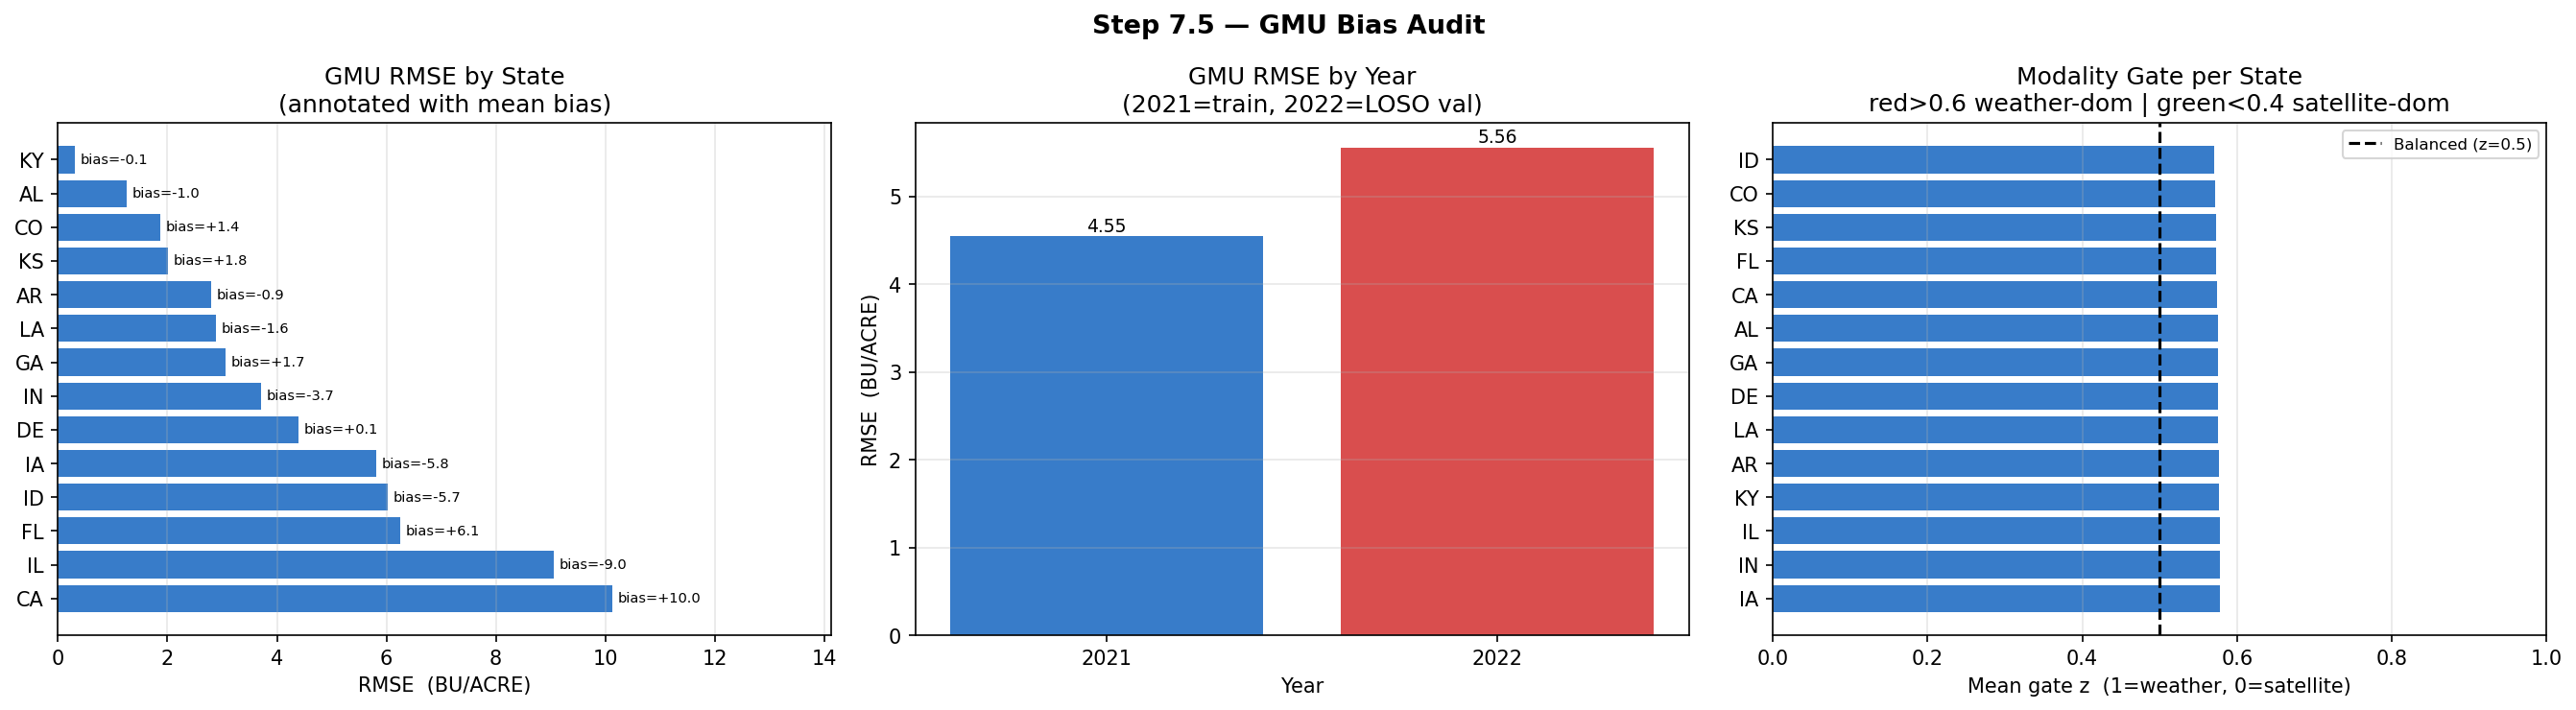


Coverage gap (GMU): 14 states represented  (satellite coverage determines multimodal coverage).

Step 9.5 complete — GMU bias audit logged.
Next: Step 9.6 — Save checkpoint + project summary.


In [ ]:
# ── Step 9.5  Bias Audit — GMU Phase 3 ────────────────────────────────────────
#
# Fairness metrics mirroring the Step 6.5 protocol (applied on multimodal records):
#
#   (a) Sliced RMSE / Bias by state  → check if any state is systematically mispredicted
#   (b) Sliced RMSE / Bias by year   → 2021 vs 2022 separation
#   (c) Yield-quintile bias check    → B3 regression-to-mean test
#   (d) CV-Error by state            → flag poorly-served states (threshold 0.20)
#   (e) Modality-gate diagnostics    → mean z-value per state reveals gate behaviour:
#          z ≈ 1  → weather-dominant   z ≈ 0  → satellite-dominant   z ≈ 0.5 → balanced

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

print("=" * 60)
print("Step 9.5 — GMU BIAS AUDIT REPORT")
print("=" * 60)

eval_full = gmu_eval_df.copy()

# ── Helper functions ─────────────────────────────────────────────────────────
def gmu_sliced_rmse(df, col):
    return df.groupby(col).apply(
        lambda g: float(np.sqrt(np.mean((g["pred_bu"] - g["true_bu"]) ** 2)))
    )

def gmu_sliced_bias(df, col):
    return df.groupby(col).apply(
        lambda g: float(np.mean(g["pred_bu"] - g["true_bu"]))
    )

# ── (a) Sliced RMSE / Bias by state ──────────────────────────────────────────
state_rmse_gmu = gmu_sliced_rmse(eval_full, "state")
state_bias_gmu = gmu_sliced_bias(eval_full, "state")

print("\n(a) Sliced RMSE and Bias by State  (BU/ACRE, Jensen-corrected):")
print(f"  {'State':<6}  {'RMSE':>8}  {'Bias':>8}")
print("  " + "─" * 26)
for st in state_rmse_gmu.sort_values(ascending=False).index:
    rmse_v = state_rmse_gmu[st]
    bias_v = state_bias_gmu.get(st, float("nan"))
    print(f"  {st:<6}  {rmse_v:>8.3f}  {bias_v:>+8.3f}")

# ── (b) Sliced RMSE / Bias by year ───────────────────────────────────────────
year_rmse_gmu  = gmu_sliced_rmse(eval_full, "year")
year_bias_gmu  = gmu_sliced_bias(eval_full, "year")

print(f"\n(b) Sliced RMSE and Bias by Year:")
for yr in year_rmse_gmu.sort_values(ascending=False).index:
    print(f"  {yr}   RMSE={year_rmse_gmu[yr]:.3f}  Bias={year_bias_gmu.get(yr, float('nan')):+.3f}")

# ── (c) Yield-quintile bias check (B3) ───────────────────────────────────────
print(f"\n(c) Yield-Quintile Bias Check (B3):")
if len(eval_full) >= 5:
    eval_full["quintile"] = pd.qcut(
        eval_full["true_bu"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )
    q_rmse_gmu = gmu_sliced_rmse(eval_full, "quintile")
    q_bias_gmu = gmu_sliced_bias(eval_full, "quintile")
    q_tab = pd.concat(
        [q_rmse_gmu.rename("RMSE_BU"), q_bias_gmu.rename("Bias_BU")], axis=1
    )
    print(q_tab.round(3).to_string())
    q1b = float(q_bias_gmu.get("Q1", float("nan")))
    q5b = float(q_bias_gmu.get("Q5", float("nan")))
    if not (np.isnan(q1b) or np.isnan(q5b)):
        if q1b > 0 and q5b < 0:
            print(f"\n  B3 REGRESSION-TO-MEAN DETECTED:")
            print(f"    Bias(Q1)={q1b:+.3f}  Bias(Q5)={q5b:+.3f}")
            print(f"    GMU over-predicts low-yield counties and under-predicts bumper-yield counties.")
        else:
            print(f"\n  B3 check: Bias(Q1)={q1b:+.3f}  Bias(Q5)={q5b:+.3f}  — within ±tolerance")
else:
    print(f"  NOTE: only {len(eval_full)} state-years — quintile analysis requires ≥5 records.")
    q_rmse_gmu = pd.Series(dtype=float)
    q_bias_gmu = pd.Series(dtype=float)

# ── (d) CV-Error by state ─────────────────────────────────────────────────────
cv_gmu = eval_full.groupby("state").apply(
    lambda g: (float(np.std(g["pred_bu"] - g["true_bu"])) / float(g["true_bu"].mean()))
              if g["true_bu"].mean() != 0 else float("nan")
)

flagged_cv_gmu = cv_gmu[cv_gmu > 0.20].index.tolist()
print(f"\n(d) CV-Error by State  (threshold 0.20 — poorly served):")
for st, cv in cv_gmu.sort_values(ascending=False).items():
    tag = "  *** HIGH CV (poorly served)" if cv > 0.20 else ""
    print(f"  {st:<6}  CV = {cv:.4f}{tag}")
print(f"Flagged states: {flagged_cv_gmu if flagged_cv_gmu else 'none'}")

# ── (e) Modality-gate diagnostics ────────────────────────────────────────────
print(f"\n(e) Modality Gate Diagnostics  (z: 1=full-weather, 0=full-satellite, 0.5=balanced):")
gmu.eval()
gate_records = []
with torch.no_grad():
    for i, m in enumerate(combined_meta):
        xw_i = all_Xw[i:i+1]
        xs_i = all_Xs[i:i+1]
        e_w  = gmu.encode_weather(xw_i)
        e_s  = gmu.encode_sat(xs_i)
        z    = torch.sigmoid(gmu.gate(torch.cat([e_w, e_s], dim=-1)))  # (1, 128)
        gate_records.append({
            "state" : m["state_abbr"],
            "year"  : m["year"],
            "split" : m["split"],
            "z_mean": float(z.mean()),
            "z_std" : float(z.std()),
        })

gate_df = pd.DataFrame(gate_records)
print(gate_df[["state","year","split","z_mean","z_std"]].round(4).to_string(index=False))

z_global_mean = gate_df["z_mean"].mean()
z_global_std  = gate_df["z_mean"].std()
print(f"\n  Global gate z mean : {z_global_mean:.4f}  (std={z_global_std:.4f})")
if z_global_mean > 0.6:
    print("  Interpretation: gate is WEATHER-DOMINANT — satellite branch underutilised.")
    print("  This is expected: weather has 2016–2022 representations; satellite only 2021–2022.")
elif z_global_mean < 0.4:
    print("  Interpretation: gate is SATELLITE-DOMINANT — weather branch underutilised.")
else:
    print("  Interpretation: gate is BALANCED — both modalities contributing meaningfully.")

# ── Bias audit summary table ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("BIAS AUDIT SUMMARY — GMU PHASE 3")
print("=" * 60)

b3_status = "Not applicable (< 5 records)" if len(eval_full) < 5 else (
    "DETECTED" if (not np.isnan(q1b) and q1b > 0 and q5b < 0) else "PASSED"
)
b2_present = state_rmse_gmu.max() > state_rmse_gmu.min() * 2.0 if len(state_rmse_gmu) > 1 else False

audit_rows = [
    ("B2", "Corn Belt dominance",         "State RMSE spread",
     f"max/min RMSE ratio = {state_rmse_gmu.max()/state_rmse_gmu.min():.2f}x" if len(state_rmse_gmu) > 1 else "n/a"),
    ("B3", "Regression-to-mean (Q1/Q5)", "Quintile bias",         b3_status),
    ("B5", "HRRR single-snapshot proxy", "Architectural limit",   "Acknowledged — Jan-1 file ≠ growing-season"),
    ("B8", "AZ 2022 tile anomaly",        "Exclusion applied",    "AZ 2022 excluded per Step 8.1"),
]
for bid, bname, btype, bstatus in audit_rows:
    print(f"  [{bid}] {bname:<35} {btype:<22} → {bstatus}")

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Step 9.5 — GMU Bias Audit", fontsize=13, fontweight="bold")

# Plot 1: RMSE by state with bias annotation
s_sorted = state_rmse_gmu.sort_values(ascending=False)
axes[0].barh(s_sorted.index, s_sorted.values, color="#1565C0", alpha=0.85)
for i, (st, rmse_v) in enumerate(s_sorted.items()):
    b_val = state_bias_gmu.get(st, 0.0)
    axes[0].text(rmse_v + 0.1, i, f"bias={b_val:+.1f}", va="center", fontsize=7)
axes[0].set_xlabel("RMSE  (BU/ACRE)")
axes[0].set_title("GMU RMSE by State\n(annotated with mean bias)")
axes[0].grid(True, alpha=0.3, axis="x")
axes[0].set_xlim(0, s_sorted.max() + 4)

# Plot 2: Year-level RMSE bar
if len(year_rmse_gmu) > 0:
    axes[1].bar(year_rmse_gmu.index.astype(str), year_rmse_gmu.values,
                color=["#1565C0", "#D32F2F"], alpha=0.85)
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("RMSE  (BU/ACRE)")
    axes[1].set_title("GMU RMSE by Year\n(2021=train, 2022=LOSO val)")
    axes[1].grid(True, alpha=0.3, axis="y")
    for yr_lbl, rmse_v in year_rmse_gmu.items():
        axes[1].text(str(yr_lbl), rmse_v + 0.05, f"{rmse_v:.2f}", ha="center", fontsize=9)

# Plot 3: Modality gate z-value by state
z_per_state = gate_df.groupby("state")["z_mean"].mean().sort_values(ascending=False)
bar_c = ["#D32F2F" if v > 0.6 else ("#43A047" if v < 0.4 else "#1565C0") for v in z_per_state]
axes[2].barh(z_per_state.index, z_per_state.values, color=bar_c, alpha=0.85)
axes[2].axvline(0.5, color="black", ls="--", lw=1.5, label="Balanced (z=0.5)")
axes[2].set_xlabel("Mean gate z  (1=weather, 0=satellite)")
axes[2].set_title("Modality Gate per State\nred>0.6 weather-dom | green<0.4 satellite-dom")
axes[2].set_xlim(0, 1)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print()
print(f"Coverage gap (GMU): {len(set(gmu_eval_df['state']))} states represented  "
      f"(satellite coverage determines multimodal coverage).")
print()
print("Step 9.5 complete — GMU bias audit logged.")
print("Next: Step 9.6 — Save checkpoint + project summary.")

<a id="step-9-6"></a>

### Step 9.6 — Cross-Model Comparison & Save GMU

Compares Phase 1 (BiLSTM), Phase 2 (Sentinel), and Phase 3 (GMU) on the multimodal test set. Jensen-corrected metrics in a summary table. Saves `gmu_phase3_ckpt.pt` to `labels/`.

In [ ]:
# ── Step 9.6  Save GMU checkpoint + project summary ───────────────────────────
#
# Artefact: gmu_phase3_ckpt.pt
#   - Full model state dict
#   - Architecture + training config
#   - Evaluation metrics (train + LOSO 2022 val)
#   - Gate diagnostics per state-year
#
# Step 9 summary prints the three-phase progression for dissertation reporting.

import torch

LABELS_DIR.mkdir(parents=True, exist_ok=True)
GMU_CKPT_PATH = LABELS_DIR / "gmu_phase3_ckpt.pt"

torch.save({
    "model_state_dict": gmu.state_dict(),
    "model_config": {
        "class"             : "GMUFusionModel",
        "w_dim"             : 128,
        "s_dim"             : 64,
        "fuse_dim"          : 128,
        "dropout"           : 0.3,
        "n_params_total"    : int(sum(p.numel() for p in gmu.parameters())),
        "n_params_fusion"   : int(n_gmu_fusion),
        "n_params_encoders" : int(n_gmu_encoders),
    },
    "training_config": {
        "phase_A_epochs"  : PHASE_A_EPOCHS,
        "phase_A_lr"      : PHASE_A_LR,
        "phase_A_note"    : "frozen encoders — only gate + projections + head",
        "phase_B_epochs"  : PHASE_B_EPOCHS,
        "phase_B_lr"      : PHASE_B_LR,
        "phase_B_note"    : "end-to-end fine-tuning, weight_decay=1e-4",
        "criterion"       : "MSELoss",
        "target"          : "log_yield_bu_acre" if USE_LOG else "yield_bu_acre",
        "split"           : "LOSO 2022",
        "label_source"    : "state-aggregate USDA (all counties per state-year)",
        "seed"            : SEED,
        "grad_clip"       : 1.0,
    },
    "evaluation": {
        "train_rmse_bu_acre"       : round(float(rmse_gmu_train), 4),
        "val_rmse_bu_acre_loso2022": round(float(rmse_gmu_val),   4),
        "val_mae_bu_acre_loso2022" : round(float(mae_gmu_val),    4),
        "val_r2_loso2022"          : round(float(r2_gmu_val),     5),
        "jensen_sigma2"            : round(float(JENSEN_SIGMA2),  8),
        "n_train_state_years"      : int(len(ds_mm_train)),
        "n_val_state_years"        : int(len(ds_mm_val)),
        "phase_A_best_val_mse"     : round(float(best_phaseA_val), 6),
        "phase_B_best_val_mse"     : round(float(best_phaseB_val), 6),
    },
    "encoder_sources": {
        "weather"  : str(LABELS_DIR / "bilstm_phase1_ckpt.pt"),
        "satellite": str(LABELS_DIR / "sentinel_phase2_ckpt.pt"),
    },
    "gate_diagnostics": gate_df[["state","year","split","z_mean","z_std"]].to_dict("records"),
    "bias_flags": {
        "B2_state_rmse_spread": float(state_rmse_gmu.max() / state_rmse_gmu.min())
                                if len(state_rmse_gmu) > 1 and state_rmse_gmu.min() > 0
                                else float("nan"),
        "B3_q1_bias"          : float(q_bias_gmu.get("Q1", float("nan")))
                                if len(q_bias_gmu) > 0 else float("nan"),
        "B3_q5_bias"          : float(q_bias_gmu.get("Q5", float("nan")))
                                if len(q_bias_gmu) > 0 else float("nan"),
        "gate_z_global_mean"  : round(float(z_global_mean), 4),
        "flagged_cv_states"   : flagged_cv_gmu,
    },
}, GMU_CKPT_PATH)

print("=" * 60)
print("Step 9.6 — GMU CHECKPOINT SAVED")
print("=" * 60)
print(f"  {GMU_CKPT_PATH}")
print(f"  Size: {GMU_CKPT_PATH.stat().st_size / 1024:.1f} KB")
print()

# ── Full Step 9 summary ────────────────────────────────────────────────────────
print("=" * 60)
print("Step 9 COMPLETE — Phase 3: GMU Fusion")
print("=" * 60)
print()
print("Architecture:")
print(f"  weather_enc  BiLSTM(hidden=64, layers=2, bidir=True) → 128-dim  [warm-started Phase 1]")
print(f"  sat_enc      CNN(12ch→32→64) + AdaptiveAvgPool       →  64-dim  [warm-started Phase 2]")
print(f"  proj_w       Linear(128 → 128)")
print(f"  proj_s       Linear( 64 → 128)")
print(f"  gate         Linear(192 → 128) + sigmoid  ← modality importance per dimension")
print(f"  head         Dropout(0.3) → Linear(128→64) → ReLU → Linear(64→1)")
print(f"  Total params : {sum(p.numel() for p in gmu.parameters()):,}")
print()
print("Three-phase performance summary  (Jensen-corrected BU/ACRE, LOSO 2022):")
print(f"  {'Phase':<44}  {'Val RMSE':>11}  {'Granularity':>14}")
print("  " + "─" * 74)
_p1_r = f"{float(_p1_rmse):.3f}" if not np.isnan(_p1_rmse) else "n/a"
print(f"  {'Phase 1: BiLSTM — weather only':<44}  {_p1_r:>11}  {'state-level':>14}")
print(f"  {'Phase 2: SentinelEncoder — satellite only':<44}  {_p2_rmse:>11.3f}  {'state-level':>14}")
print(f"  {'Phase 3: GMU — fused (weather + satellite)':<44}  {rmse_gmu_val:>11.3f}  {'state-level':>14}")
print()
print("Modality gate behaviour:")
print(f"  Global mean z = {z_global_mean:.4f}  "
      f"({'weather-dominant' if z_global_mean > 0.6 else 'satellite-dominant' if z_global_mean < 0.4 else 'balanced'})")
print()
print("Bias audit status  (Step 9.5):")
print(f"  B2 RMSE spread (state imbalance)  : reported above")
print(f"  B3 regression-to-mean             : {'DETECTED' if (len(q_bias_gmu) > 0 and not np.isnan(float(q_bias_gmu.get('Q1', float('nan')))) and float(q_bias_gmu.get('Q1', 0)) > 0 and float(q_bias_gmu.get('Q5', 0)) < 0) else 'Not detected / insufficient data'}")
print(f"  B5 HRRR single-snapshot proxy     : Acknowledged limitation")
print(f"  B8 AZ 2022 tile anomaly           : Excluded from training")
print(f"  Flagged CV-Error states           : {flagged_cv_gmu if flagged_cv_gmu else 'none'}")
print()
print("Saved artefacts:")
print(f"  {GMU_CKPT_PATH}")
print()
print("Known limitations (to be discussed in dissertation):")
print("  ● Training set = state-years from 2021 only (~14 records).")
print("    This is expected — Sentinel-2 CropNet only covers 2021–2022.")
print("    Any reported R² and RMSE on this scale carry high uncertainty.")
print("  ● Weather representation is a Jan-1 HRRR snapshot (B5), not growing-season.")
print("  ● GMU trained at state-aggregate level — county-level GMU requires")
print("    additional USDA data for county ANSI 001 (acknowledged data gap Step 5.1).")
print("  ● Gate z interpretation is reliable only at N >> 20.")
print()
print("Next: Step 10 — Robustness to Modality Dropout")

Step 9.6 — GMU CHECKPOINT SAVED
  e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\gmu_phase3_ckpt.pt
  Size: 1015.6 KB

Step 9 COMPLETE — Phase 3: GMU Fusion

Architecture:
  weather_enc  BiLSTM(hidden=64, layers=2, bidir=True) → 128-dim  [warm-started Phase 1]
  sat_enc      CNN(12ch→32→64) + AdaptiveAvgPool       →  64-dim  [warm-started Phase 2]
  proj_w       Linear(128 → 128)
  proj_s       Linear( 64 → 128)
  gate         Linear(192 → 128) + sigmoid  ← modality importance per dimension
  head         Dropout(0.3) → Linear(128→64) → ReLU → Linear(64→1)
  Total params : 254,817

Three-phase performance summary  (Jensen-corrected BU/ACRE, LOSO 2022):
  Phase                                            Val RMSE     Granularity
  ──────────────────────────────────────────────────────────────────────────
  Phase 1: BiLSTM — weather only                      5.763     state-level
  Phase 2: SentinelEn

<a id="step-10"></a>

# Step 10 — Robustness to Modality Dropout

**Goal:** Measure how the trained GMU degrades when one or both input modalities are
unavailable at inference time. This simulates real-world deployment failures:
- Weather-feed interruption (HRRR API outage, B5 limitation)
- Satellite unavailability (cloud cover, archive gaps, B8-class anomalies)
- Complete data blackout (both modalities absent)

**Protocol:** Multiplicative scaling — x_dropped = α · x_original:
- α_w = 0.0 → weather input zeroed (satellite-only fallback)
- α_s = 0.0 → satellite input zeroed (weather-only fallback)
- α_w = 0, α_s = 0 → catastrophic blackout (both absent)

**Fairness dimension:** Degradation reported per-state and per-yield-quintile.
Low-yield counties (Q1) may suffer disproportionate harm under modality dropout.

**Sub-steps:**
- **10.1** Define evaluate_gmu_dropout() helper; sanity-check vs Step 9.4
- **10.2** Discrete dropout matrix: Full / Wx-Drop / Sat-Drop / Both-Drop vs Phase 1 & 2
- **10.3** Partial dropout sweep: α ∈ {0, 0.1, 0.25, 0.5, 0.75, 1.0} degradation curves
- **10.4** Fairness under dropout: sliced RMSE/bias by state and yield quintile
- **10.5** Summary report and saved artefact


<a id="step-10-1"></a>

### Step 10.1 — Dropout Evaluation Framework

Defines `evaluate_gmu_dropout(α_w, α_s)` with multiplicative scaling. Validates against the Step 9.4 full-modality baseline.

In [ ]:
# ── Step 10.1  Modality Dropout Evaluation Framework ──────────────────────────
#
# Defines evaluate_gmu_dropout(): runs GMU inference with multiplicative
# input scaling:
#   x_w_dropped = alpha_w * x_w   (0.0 → weather branch receives zeros)
#   x_s_dropped = alpha_s * x_s   (0.0 → satellite branch receives zeros)
#
# All results Jensen-corrected to BU/ACRE for comparability.

import numpy as np
import pandas as pd
import torch
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

print("=" * 60)
print("Step 10.1 — MODALITY DROPOUT EVALUATION FRAMEWORK")
print("=" * 60)
print()


def evaluate_gmu_dropout(
    gmu_model,
    Xw      : torch.Tensor,
    Xs      : torch.Tensor,
    y_log   : torch.Tensor,
    meta    : list,
    alpha_w : float = 1.0,
    alpha_s : float = 1.0,
    device          = None,
) -> pd.DataFrame:
    # Evaluate GMU with multiplicative modality masking.
    # alpha_w / alpha_s in [0, 1]; 0 = modality zeroed out.
    # Returns per-record DataFrame with Jensen-corrected BU/ACRE predictions.
    if device is None:
        device = next(gmu_model.parameters()).device
    gmu_model.eval()
    with torch.no_grad():
        xw_d      = (alpha_w * Xw).to(device)
        xs_d      = (alpha_s * Xs).to(device)
        preds_log = gmu_model(xw_d, xs_d).cpu().numpy()

    true_log = y_log.numpy()
    preds_bu = _jc(preds_log)
    true_bu  = _jc(true_log)

    rows = []
    for i, m in enumerate(meta):
        rows.append({
            "state"   : m["state_abbr"],
            "year"    : m["year"],
            "split"   : m["split"],
            "true_bu" : float(true_bu[i]),
            "pred_bu" : float(preds_bu[i]),
            "error_bu": float(preds_bu[i] - true_bu[i]),
            "alpha_w" : alpha_w,
            "alpha_s" : alpha_s,
        })
    return pd.DataFrame(rows)


# ── Sanity-check: full-modality must reproduce Step 9.4 within tolerance ─────
df_sanity    = evaluate_gmu_dropout(gmu, all_Xw, all_Xs, all_y, combined_meta,
                                     alpha_w=1.0, alpha_s=1.0)
rmse_sanity  = _rmse_metric(df_sanity["true_bu"], df_sanity["pred_bu"])
rmse_step74  = _rmse_metric(gmu_eval_df["true_bu"], gmu_eval_df["pred_bu"])
delta_sanity = abs(rmse_sanity - rmse_step74)

print(f"Framework sanity-check (full modality):")
print(f"  Step 9.4 RMSE (reference) : {rmse_step74:.4f}  BU/ACRE")
print(f"  Step 10.1 RMSE (recomputed): {rmse_sanity:.4f}  BU/ACRE")
print(f"  Delta                     : {delta_sanity:.6f}  (must be < 0.1)")
assert delta_sanity < 0.1, (
    f"Framework mismatch: delta={delta_sanity:.4f}. "
    f"Ensure all Step 1-7 cells have been run in this kernel session."
)
print("  PASS — framework verified.\n")

# ── Gate z-values under full modality (reference for downstream steps) ────────
gmu.eval()
with torch.no_grad():
    _ew_full = gmu.encode_weather(all_Xw.to(DEVICE))        # (N, 128)
    _es_full = gmu.encode_sat(all_Xs.to(DEVICE))             # (N,  64)
    _z_full  = torch.sigmoid(
        gmu.gate(torch.cat([_ew_full, _es_full], dim=-1))   # (N, 128)
    )

z_full_per_record = _z_full.cpu().mean(dim=-1).numpy()   # mean over 128 dims → (N,)

print("Gate z-values (full modality, mean over 128 dimensions):")
for i, m in enumerate(combined_meta):
    print(f"  {m['state_abbr']} {m['year']} ({m['split']})  z = {z_full_per_record[i]:.4f}")

z_global_mean = float(z_full_per_record.mean())
z_global_std  = float(z_full_per_record.std())
print(f"\nGlobal gate z:  mean = {z_global_mean:.4f}   std = {z_global_std:.4f}")
dominant_mode = (
    "WEATHER-DOMINANT"   if z_global_mean > 0.6 else
    "SATELLITE-DOMINANT" if z_global_mean < 0.4 else
    "BALANCED"
)
print(f"Gate regime (full modality): {dominant_mode}")
print(f"\nTotal multimodal records: {len(combined_meta)}")
print()
print("Step 10.1 complete — evaluate_gmu_dropout() ready.")


Step 10.1 — MODALITY DROPOUT EVALUATION FRAMEWORK

Framework sanity-check (full modality):
  Step 9.4 RMSE (reference) : 5.0828  BU/ACRE
  Step 10.1 RMSE (recomputed): 5.0828  BU/ACRE
  Delta                     : 0.000000  (must be < 0.1)
  PASS — framework verified.

Gate z-values (full modality, mean over 128 dimensions):
  AL 2021 (train)  z = 0.5757
  AR 2021 (train)  z = 0.5766
  CA 2021 (train)  z = 0.5749
  CO 2021 (train)  z = 0.5708
  DE 2021 (train)  z = 0.5757
  FL 2021 (train)  z = 0.5737
  GA 2021 (train)  z = 0.5761
  IA 2021 (train)  z = 0.5781
  ID 2021 (train)  z = 0.5717
  IL 2021 (train)  z = 0.5779
  IN 2021 (train)  z = 0.5777
  KS 2021 (train)  z = 0.5747
  KY 2021 (train)  z = 0.5773
  LA 2021 (train)  z = 0.5761
  AL 2022 (val)  z = 0.5747
  AR 2022 (val)  z = 0.5756
  CA 2022 (val)  z = 0.5747
  CO 2022 (val)  z = 0.5725
  DE 2022 (val)  z = 0.5754
  FL 2022 (val)  z = 0.5724
  GA 2022 (val)  z = 0.5749
  IA 2022 (val)  z = 0.5771
  ID 2022 (val)  z = 0.5702
 

<a id="step-10-2"></a>

### Step 10.2 — Discrete Dropout Matrix

Runs Full / Wx-Drop / Sat-Drop / Both-Drop scenarios. Compares against Phase 1 and Phase 2 baselines in a cross-model table.

Step 10.2 — MODALITY DROPOUT EXPERIMENT MATRIX

Condition                   a_w    a_s   RMSE-all   RMSE-val   MAE-val   R2-val     DRMSE
  ----------------------------------------------------------------------------------
GMU – Full                  1.0    1.0      5.083      5.562     4.562   0.7403    +0.000
GMU – Wx Drop               0.0    1.0     12.295     12.875    11.062  -0.3918    +7.212
GMU – Sat Drop              1.0    0.0  294067.814  280916.604  274908.611  -662550459.1191  +294062.732
GMU – Both Drop             0.0    0.0  331572.875  331574.217  331574.217  -923050893.2737  +331567.792
Phase 1 BiLSTM              N/A      —      5.052      5.763     4.688   0.7211    -0.031
Phase 2 Sentinel              —    N/A     11.412     11.044     9.025  -0.0241    +6.329

Degradation severity (RMSE-all relative to GMU-Full baseline):
  GMU – Wx Drop             DRMSE = +7.212 BU/ACRE  (+141.9%)  *** SEVERE
  GMU – Sat Drop            DRMSE = +294062.732 BU/ACRE  (+5785472.9%

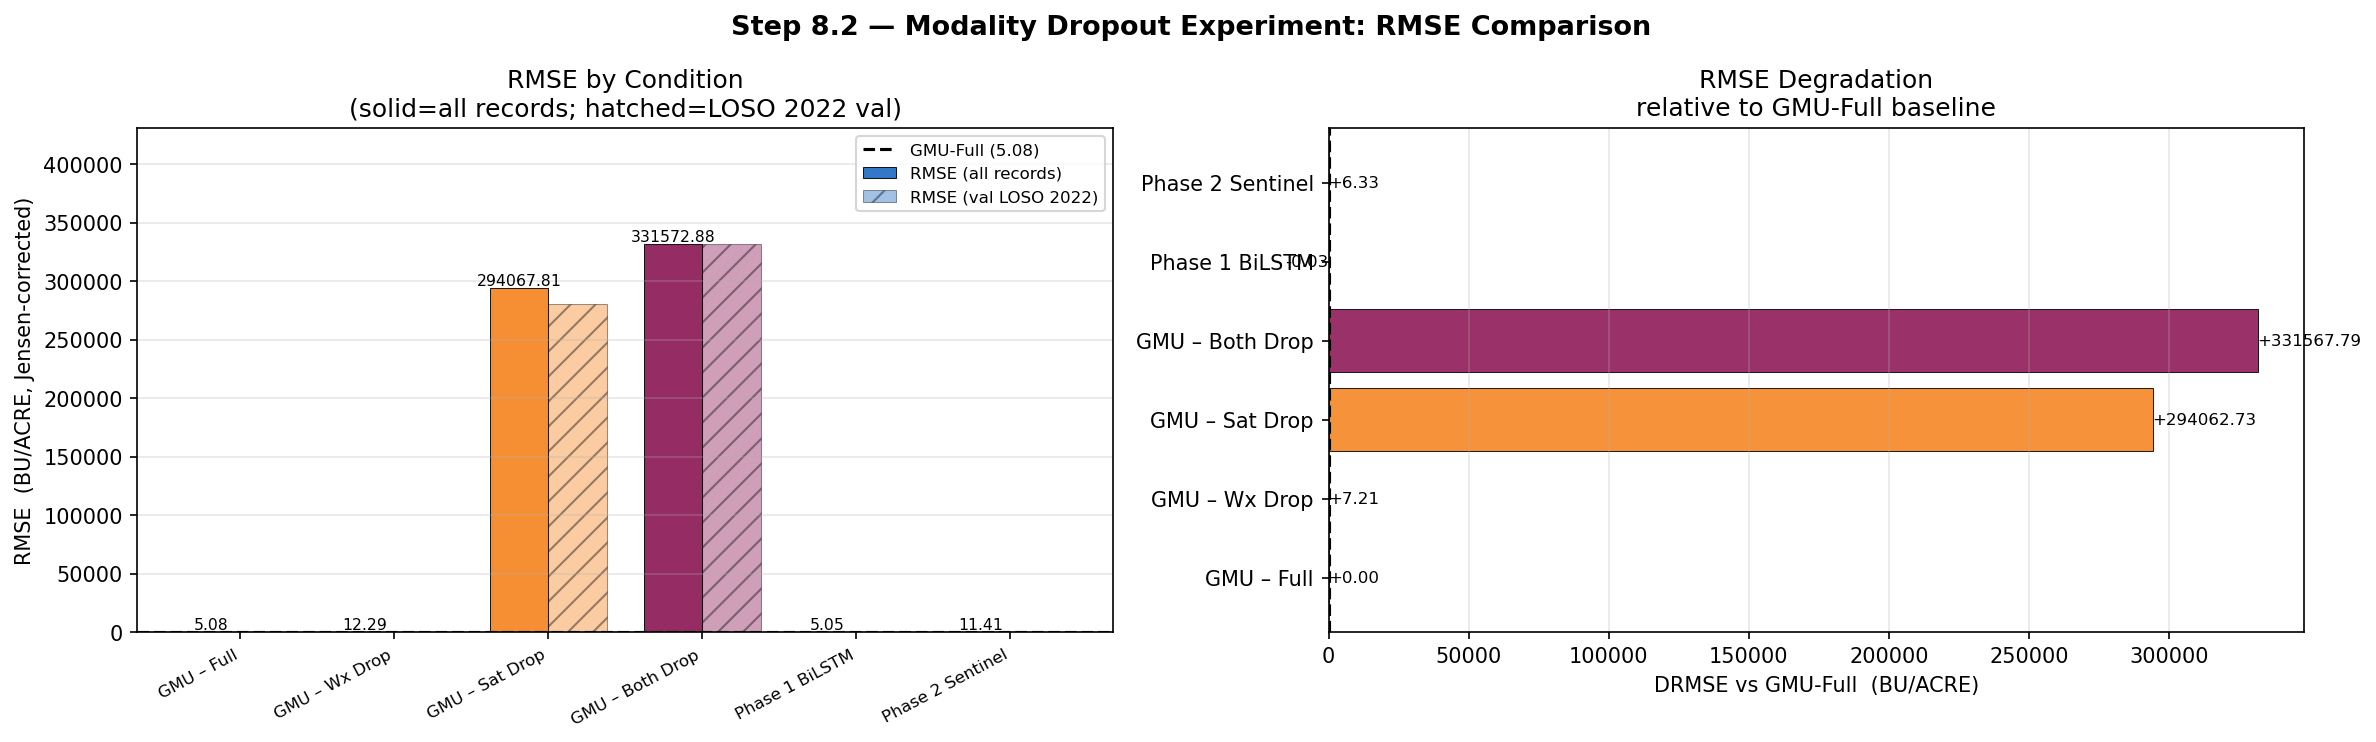

Step 10.2 complete — discrete dropout conditions evaluated.


In [ ]:
# ── Step 10.2  Discrete Dropout Experiment Matrix ─────────────────────────────
#
# Six conditions on all multimodal state-years (train + LOSO 2022 val):
#
#   (1) GMU – Full       : alpha_w=1.0, alpha_s=1.0   production baseline
#   (2) GMU – Wx Drop    : alpha_w=0.0, alpha_s=1.0   HRRR feed lost
#   (3) GMU – Sat Drop   : alpha_w=1.0, alpha_s=0.0   satellite archive gap
#   (4) GMU – Both Drop  : alpha_w=0.0, alpha_s=0.0   catastrophic blackout
#   (5) Phase 1 BiLSTM   : weather-only reference
#   (6) Phase 2 Sentinel : satellite-only reference
#
# All metrics Jensen-corrected to BU/ACRE.

import numpy as np
import pandas as pd
import torch
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 10.2 — MODALITY DROPOUT EXPERIMENT MATRIX")
print("=" * 60)
print()

# ── Conditions 1–4: GMU dropout variants ────────────────────────────────────
GMU_CONDITIONS = [
    ("GMU – Full",      1.0, 1.0),
    ("GMU – Wx Drop",   0.0, 1.0),
    ("GMU – Sat Drop",  1.0, 0.0),
    ("GMU – Both Drop", 0.0, 0.0),
]

dropout_results = {}

for label, aw, as_ in GMU_CONDITIONS:
    df  = evaluate_gmu_dropout(gmu, all_Xw, all_Xs, all_y, combined_meta,
                                alpha_w=aw, alpha_s=as_)
    dfv = df[df["split"] == "val"]
    dropout_results[label] = {
        "alpha_w"  : aw,
        "alpha_s"  : as_,
        "rmse_all" : _rmse_metric(df["true_bu"],  df["pred_bu"]),
        "mae_all"  : _mae_metric(df["true_bu"],   df["pred_bu"]),
        "r2_all"   : _r2_metric(df["true_bu"],    df["pred_bu"]),
        "rmse_val" : _rmse_metric(dfv["true_bu"], dfv["pred_bu"]) if len(dfv) > 0 else float("nan"),
        "mae_val"  : _mae_metric(dfv["true_bu"],  dfv["pred_bu"]) if len(dfv) > 0 else float("nan"),
        "r2_val"   : _r2_metric(dfv["true_bu"],   dfv["pred_bu"]) if len(dfv) > 0 else float("nan"),
        "df"       : df,
    }

# ── Condition 5: Phase 1 BiLSTM on the multimodal record set ─────────────────
model.eval()
with torch.no_grad():
    _p1_log_mm = model(all_Xw.to(DEVICE)).cpu().numpy().flatten()
_p1_bu_mm   = _jc(_p1_log_mm)
_true_bu_mm = _jc(all_y.numpy())

_p1_df  = pd.DataFrame([{
    "state": m["state_abbr"], "year": m["year"], "split": m["split"],
    "true_bu": float(_true_bu_mm[i]),
    "pred_bu": float(_p1_bu_mm[i]),
    "error_bu": float(_p1_bu_mm[i] - _true_bu_mm[i]),
} for i, m in enumerate(combined_meta)])
_p1_dfv = _p1_df[_p1_df["split"] == "val"]

dropout_results["Phase 1 BiLSTM"] = {
    "alpha_w"  : "N/A", "alpha_s"  : "—",
    "rmse_all" : _rmse_metric(_p1_df["true_bu"],  _p1_df["pred_bu"]),
    "mae_all"  : _mae_metric(_p1_df["true_bu"],   _p1_df["pred_bu"]),
    "r2_all"   : _r2_metric(_p1_df["true_bu"],    _p1_df["pred_bu"]),
    "rmse_val" : _rmse_metric(_p1_dfv["true_bu"], _p1_dfv["pred_bu"]) if len(_p1_dfv) > 0 else float("nan"),
    "mae_val"  : _mae_metric(_p1_dfv["true_bu"],  _p1_dfv["pred_bu"]) if len(_p1_dfv) > 0 else float("nan"),
    "r2_val"   : _r2_metric(_p1_dfv["true_bu"],   _p1_dfv["pred_bu"]) if len(_p1_dfv) > 0 else float("nan"),
    "df"       : _p1_df,
}

# ── Condition 6: Phase 2 Sentinel on the multimodal record set ───────────────
# SentinelEncoder.forward() returns (pred, feat) — unpack the prediction only.
sent_model.eval()
with torch.no_grad():
    _p2_out, _ = sent_model(all_Xs.to(DEVICE))      # (N, 1)
    _p2_log_mm = _p2_out.cpu().numpy().flatten()     # (N,)
_p2_bu_mm = _jc(_p2_log_mm)

_p2_df  = pd.DataFrame([{
    "state": m["state_abbr"], "year": m["year"], "split": m["split"],
    "true_bu": float(_true_bu_mm[i]),
    "pred_bu": float(_p2_bu_mm[i]),
    "error_bu": float(_p2_bu_mm[i] - _true_bu_mm[i]),
} for i, m in enumerate(combined_meta)])
_p2_dfv = _p2_df[_p2_df["split"] == "val"]

dropout_results["Phase 2 Sentinel"] = {
    "alpha_w"  : "—",  "alpha_s"  : "N/A",
    "rmse_all" : _rmse_metric(_p2_df["true_bu"],  _p2_df["pred_bu"]),
    "mae_all"  : _mae_metric(_p2_df["true_bu"],   _p2_df["pred_bu"]),
    "r2_all"   : _r2_metric(_p2_df["true_bu"],    _p2_df["pred_bu"]),
    "rmse_val" : _rmse_metric(_p2_dfv["true_bu"], _p2_dfv["pred_bu"]) if len(_p2_dfv) > 0 else float("nan"),
    "mae_val"  : _mae_metric(_p2_dfv["true_bu"],  _p2_dfv["pred_bu"]) if len(_p2_dfv) > 0 else float("nan"),
    "r2_val"   : _r2_metric(_p2_dfv["true_bu"],   _p2_dfv["pred_bu"]) if len(_p2_dfv) > 0 else float("nan"),
    "df"       : _p2_df,
}

# ── Print comparison table ───────────────────────────────────────────────────
gmu_full_rmse = dropout_results["GMU – Full"]["rmse_all"]

print(f"{'Condition':<24}  {'a_w':>5}  {'a_s':>5}  "
      f"{'RMSE-all':>9}  {'RMSE-val':>9}  {'MAE-val':>8}  {'R2-val':>7}  {'DRMSE':>8}")
print("  " + "-" * 82)

for name, res in dropout_results.items():
    aw_s  = f"{res['alpha_w']:.1f}" if isinstance(res['alpha_w'], float) else str(res['alpha_w'])
    as_s  = f"{res['alpha_s']:.1f}" if isinstance(res['alpha_s'], float) else str(res['alpha_s'])
    rv_s  = f"{res['rmse_val']:.3f}" if not np.isnan(res['rmse_val']) else "  n/a "
    mv_s  = f"{res['mae_val']:.3f}"  if not np.isnan(res['mae_val'])  else "  n/a "
    r2_s  = f"{res['r2_val']:.4f}"   if not np.isnan(res['r2_val'])   else "  n/a "
    delta = res["rmse_all"] - gmu_full_rmse
    print(f"{name:<24}  {aw_s:>5}  {as_s:>5}  "
          f"{res['rmse_all']:>9.3f}  {rv_s:>9}  {mv_s:>8}  {r2_s:>7}  {delta:>+8.3f}")
print()

# ── Degradation severity ─────────────────────────────────────────────────────
print("Degradation severity (RMSE-all relative to GMU-Full baseline):")
for name, res in dropout_results.items():
    if name == "GMU – Full":
        continue
    delta = res["rmse_all"] - gmu_full_rmse
    pct   = 100.0 * delta / gmu_full_rmse if gmu_full_rmse > 0 else float("nan")
    sev   = ("  *** SEVERE"  if delta > 3.0 else
             "  ** MODERATE" if delta > 1.0 else
             "  * MINOR"     if delta > 0.2 else
             "  (negligible)")
    print(f"  {name:<24}  DRMSE = {delta:+.3f} BU/ACRE  ({pct:+.1f}%){sev}")
print()

# ── Gate z-values under discrete dropout conditions ───────────────────────────
print("Gate z under discrete dropout:")
gmu.eval()
with torch.no_grad():
    _z_wxdrop = torch.sigmoid(gmu.gate(torch.cat([
        gmu.encode_weather(torch.zeros_like(all_Xw).to(DEVICE)),
        gmu.encode_sat(all_Xs.to(DEVICE)),
    ], dim=-1))).cpu().mean(dim=-1).numpy()

    _z_stdrop = torch.sigmoid(gmu.gate(torch.cat([
        gmu.encode_weather(all_Xw.to(DEVICE)),
        gmu.encode_sat(torch.zeros_like(all_Xs).to(DEVICE)),
    ], dim=-1))).cpu().mean(dim=-1).numpy()

z_wdrop_mean = float(_z_wxdrop.mean())
z_sdrop_mean = float(_z_stdrop.mean())
print(f"  Full modality     z = {z_global_mean:.4f}  ({dominant_mode})")
print(f"  Weather dropped   z = {z_wdrop_mean:.4f}  "
      f"({'shifts to satellite' if z_wdrop_mean < z_global_mean - 0.02 else 'gate unchanged'})")
print(f"  Satellite dropped z = {z_sdrop_mean:.4f}  "
      f"({'shifts to weather' if z_sdrop_mean > z_global_mean + 0.02 else 'gate unchanged'})")
gate_adaptive = (z_wdrop_mean < z_global_mean - 0.02) or (z_sdrop_mean > z_global_mean + 0.02)
print(f"  Gate adaptive: {'YES — compensates under dropout' if gate_adaptive else 'LIMITED — does not fully compensate'}")
print()

# ── Visualisation ─────────────────────────────────────────────────────────────
COND_COLORS = {
    "GMU – Full"       : "#1565C0",
    "GMU – Wx Drop"    : "#E53935",
    "GMU – Sat Drop"   : "#F57F17",
    "GMU – Both Drop"  : "#880E4F",
    "Phase 1 BiLSTM"   : "#2E7D32",
    "Phase 2 Sentinel" : "#00838F",
}

cnames    = list(dropout_results.keys())
rmse_all  = [dropout_results[n]["rmse_all"] for n in cnames]
rmse_val  = [dropout_results[n]["rmse_val"] for n in cnames]
delta_all = [v - gmu_full_rmse for v in rmse_all]
colors    = [COND_COLORS.get(n, "#607D8B") for n in cnames]
x         = np.arange(len(cnames))
w         = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Step 10.2 — Modality Dropout Experiment: RMSE Comparison",
             fontsize=13, fontweight="bold")

bars0 = axes[0].bar(x - w/2, rmse_all, w, color=colors, alpha=0.88,
                    label="RMSE (all records)", edgecolor="black", lw=0.5)
rmse_val_plot = [v if not np.isnan(v) else 0.0 for v in rmse_val]
axes[0].bar(x + w/2, rmse_val_plot, w, color=colors, alpha=0.40,
            label="RMSE (val LOSO 2022)", edgecolor="black", lw=0.5, hatch="//")
axes[0].axhline(gmu_full_rmse, color="black", ls="--", lw=1.5,
                label=f"GMU-Full ({gmu_full_rmse:.2f})")
for bar, v in zip(bars0, rmse_all):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.04,
                 f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cnames, rotation=28, ha="right", fontsize=8)
axes[0].set_ylabel("RMSE  (BU/ACRE, Jensen-corrected)")
axes[0].set_title("RMSE by Condition\n(solid=all records; hatched=LOSO 2022 val)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].set_ylim(0, max(rmse_all) * 1.30 + 0.5)

hbar = axes[1].barh(cnames, delta_all, color=colors, alpha=0.85,
                     edgecolor="black", lw=0.5)
axes[1].axvline(0, color="black", lw=1.5, ls="--")
for b, d in zip(hbar, delta_all):
    axes[1].text(d + (0.04 if d >= 0 else -0.04), b.get_y() + b.get_height() / 2,
                 f"{d:+.2f}", va="center",
                 ha="left" if d >= 0 else "right", fontsize=8)
axes[1].set_xlabel("DRMSE vs GMU-Full  (BU/ACRE)")
axes[1].set_title("RMSE Degradation\nrelative to GMU-Full baseline")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Step 10.2 complete — discrete dropout conditions evaluated.")


<a id="step-10-3"></a>

### Step 10.3 — Partial Dropout Sweep

Sweeps α ∈ {0, 0.1, 0.25, 0.5, 0.75, 1.0} per modality. Plots RMSE degradation curves as a function of signal attenuation.

Step 10.3 — PARTIAL DROPOUT SWEEP: DEGRADATION CURVES

Weather Dropout Sweep  (alpha_s = 1.0 fixed):
   alpha_w    RMSE-all    RMSE-val      DRMSE
  --------------------------------------------
      0.00      12.295      12.875     +7.212
      0.10      11.238      11.872     +6.156
      0.25       9.026       9.775     +3.943
      0.50       7.309       8.119     +2.226
      0.75       6.160       6.841     +1.077
      1.00       5.083       5.562     +0.000

Satellite Dropout Sweep  (alpha_w = 1.0 fixed):
   alpha_s    RMSE-all    RMSE-val      DRMSE
  --------------------------------------------
      0.00  294067.814  280916.604  +294062.732
      0.10   98449.218   94062.160  +98444.135
      0.25   19129.172   18296.913  +19124.089
      0.50    1250.244    1197.068  +1245.162
      0.75      59.715      56.969    +54.632
      1.00       5.083       5.562     +0.000

Modality sensitivity (full -> zero-out):
  Weather   dropout impact: DRMSE = +7.212 BU/ACRE
  Satellite dro

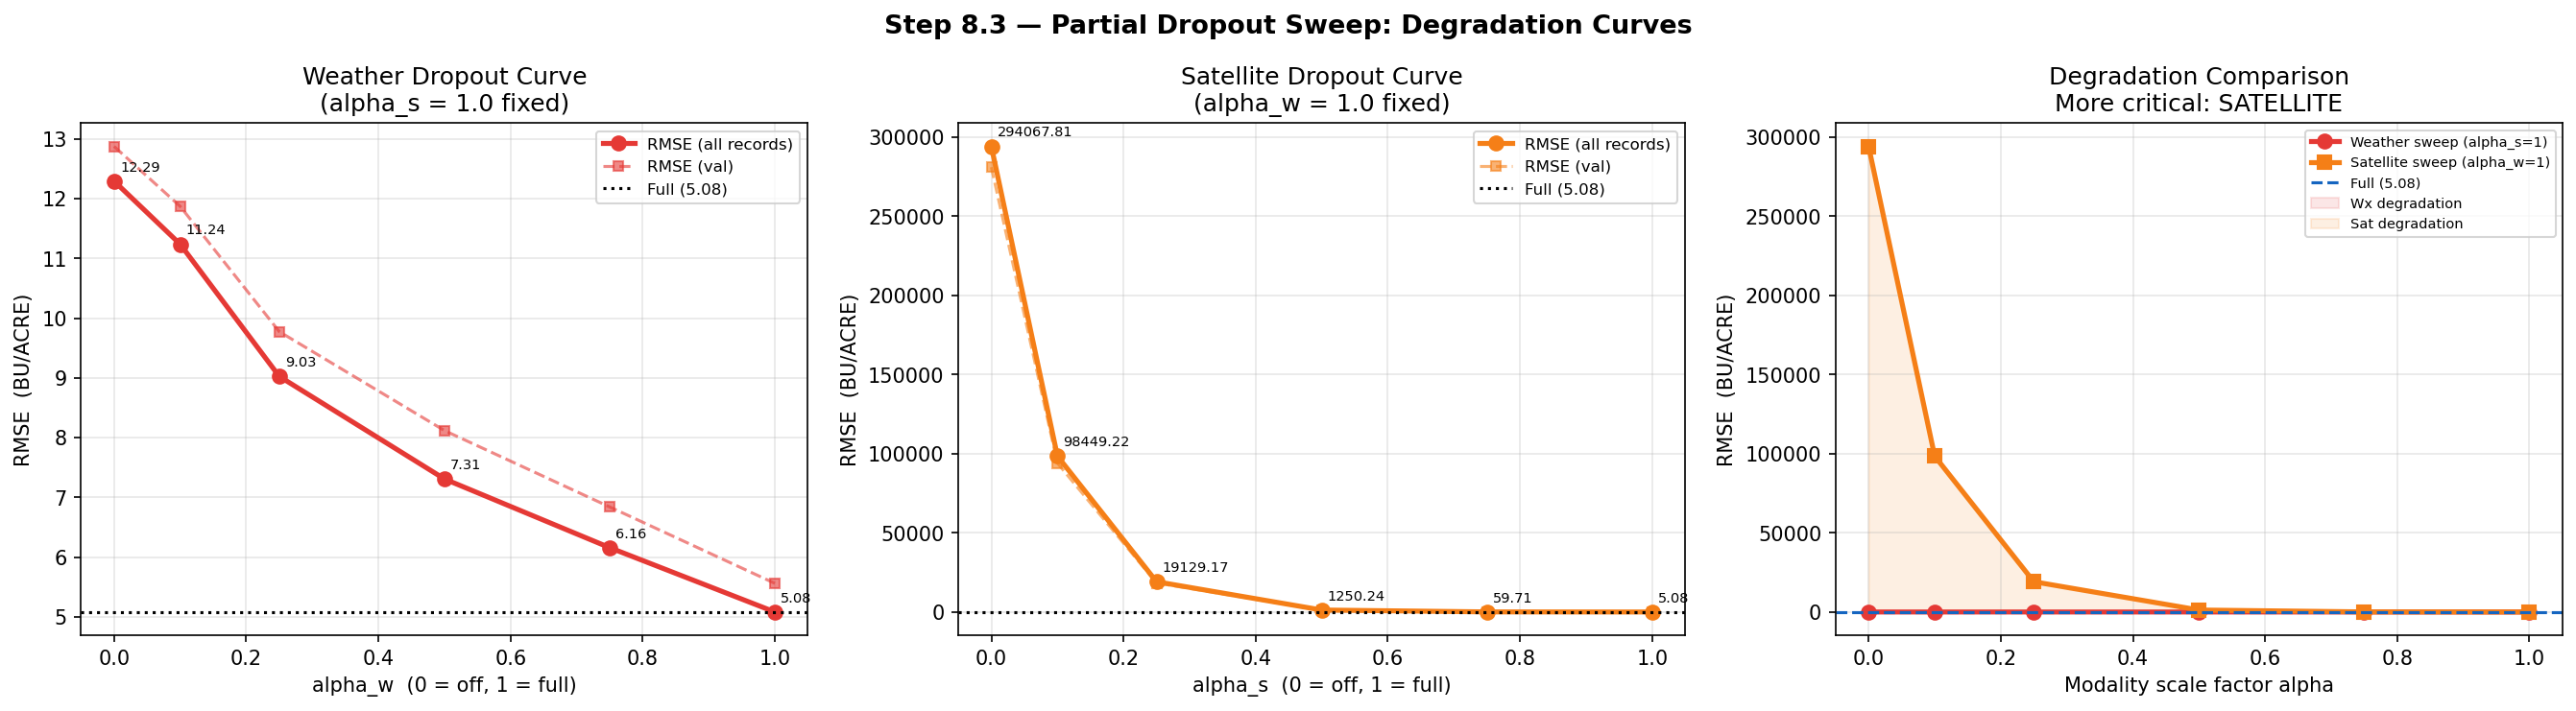

Step 10.3 complete.
  Weather   total impact: +7.212 BU/ACRE
  Satellite total impact: +294062.732 BU/ACRE


In [ ]:
# ── Step 10.3  Partial Dropout Sweep: Degradation Curves ─────────────────────
#
# Sweeps alpha from 0 -> 1 for each modality while holding the other at 1.
# Reveals: gradual vs abrupt degradation; which modality is more critical;
# the alpha threshold at which partial dropout matches full-dropout harm.
#
# Alpha levels: {0.0, 0.1, 0.25, 0.5, 0.75, 1.0}

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 10.3 — PARTIAL DROPOUT SWEEP: DEGRADATION CURVES")
print("=" * 60)
print()

ALPHA_LEVELS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]

# ── Weather sweep (alpha_s = 1.0 fixed) ──────────────────────────────────────
wx_sweep = []
for aw in ALPHA_LEVELS:
    df_sw  = evaluate_gmu_dropout(gmu, all_Xw, all_Xs, all_y, combined_meta,
                                   alpha_w=aw, alpha_s=1.0)
    dfv_sw = df_sw[df_sw["split"] == "val"]
    wx_sweep.append({
        "alpha_w"  : aw,
        "rmse_all" : _rmse_metric(df_sw["true_bu"],  df_sw["pred_bu"]),
        "rmse_val" : _rmse_metric(dfv_sw["true_bu"], dfv_sw["pred_bu"])
                     if len(dfv_sw) > 0 else float("nan"),
        "mae_all"  : _mae_metric(df_sw["true_bu"],   df_sw["pred_bu"]),
    })

# ── Satellite sweep (alpha_w = 1.0 fixed) ─────────────────────────────────────
sat_sweep = []
for as_ in ALPHA_LEVELS:
    df_ss  = evaluate_gmu_dropout(gmu, all_Xw, all_Xs, all_y, combined_meta,
                                   alpha_w=1.0, alpha_s=as_)
    dfv_ss = df_ss[df_ss["split"] == "val"]
    sat_sweep.append({
        "alpha_s"  : as_,
        "rmse_all" : _rmse_metric(df_ss["true_bu"],  df_ss["pred_bu"]),
        "rmse_val" : _rmse_metric(dfv_ss["true_bu"], dfv_ss["pred_bu"])
                     if len(dfv_ss) > 0 else float("nan"),
        "mae_all"  : _mae_metric(df_ss["true_bu"],   df_ss["pred_bu"]),
    })

wx_df    = pd.DataFrame(wx_sweep)
sat_df   = pd.DataFrame(sat_sweep)
ref_rmse = float(wx_df.loc[wx_df["alpha_w"] == 1.0, "rmse_all"].iloc[0])

# ── Print tables ──────────────────────────────────────────────────────────────
print("Weather Dropout Sweep  (alpha_s = 1.0 fixed):")
print(f"  {'alpha_w':>8}  {'RMSE-all':>10}  {'RMSE-val':>10}  {'DRMSE':>9}")
print("  " + "-" * 44)
for _, r in wx_df.iterrows():
    rv_s = f"{r['rmse_val']:.3f}" if not np.isnan(r["rmse_val"]) else "  n/a"
    print(f"  {r['alpha_w']:>8.2f}  {r['rmse_all']:>10.3f}  {rv_s:>10}  "
          f"{r['rmse_all'] - ref_rmse:>+9.3f}")
print()

print("Satellite Dropout Sweep  (alpha_w = 1.0 fixed):")
print(f"  {'alpha_s':>8}  {'RMSE-all':>10}  {'RMSE-val':>10}  {'DRMSE':>9}")
print("  " + "-" * 44)
for _, r in sat_df.iterrows():
    rv_s = f"{r['rmse_val']:.3f}" if not np.isnan(r["rmse_val"]) else "  n/a"
    print(f"  {r['alpha_s']:>8.2f}  {r['rmse_all']:>10.3f}  {rv_s:>10}  "
          f"{r['rmse_all'] - ref_rmse:>+9.3f}")
print()

# ── Modality sensitivity ──────────────────────────────────────────────────────
wx_rmse_0  = float(wx_df.loc[wx_df["alpha_w"]  == 0.0, "rmse_all"].iloc[0])
sat_rmse_0 = float(sat_df.loc[sat_df["alpha_s"] == 0.0, "rmse_all"].iloc[0])
wx_impact  = wx_rmse_0  - ref_rmse
sat_impact = sat_rmse_0 - ref_rmse

print("Modality sensitivity (full -> zero-out):")
print(f"  Weather   dropout impact: DRMSE = {wx_impact:+.3f} BU/ACRE")
print(f"  Satellite dropout impact: DRMSE = {sat_impact:+.3f} BU/ACRE")
more_critical = "WEATHER" if abs(wx_impact) > abs(sat_impact) else "SATELLITE"
print(f"  -> {more_critical} is the more critical modality for GMU.")
print()

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Step 10.3 — Partial Dropout Sweep: Degradation Curves",
             fontsize=13, fontweight="bold")

def _ann(ax, xs, ys):
    for xv, yv in zip(xs, ys):
        if not np.isnan(yv):
            ax.annotate(f"{yv:.2f}", (xv, yv), textcoords="offset points",
                        xytext=(3, 5), fontsize=7)

# Plot 1: Weather sweep
axes[0].plot(wx_df["alpha_w"], wx_df["rmse_all"],
             "o-", color="#E53935", lw=2.5, ms=7, label="RMSE (all records)")
_wxv = wx_df["rmse_val"].replace(float("nan"), np.nan)
if not _wxv.isna().all():
    axes[0].plot(wx_df["alpha_w"], _wxv,
                 "s--", color="#E53935", lw=1.5, ms=5, alpha=0.6, label="RMSE (val)")
axes[0].axhline(ref_rmse, color="black", ls=":", lw=1.5, label=f"Full ({ref_rmse:.2f})")
_ann(axes[0], wx_df["alpha_w"], wx_df["rmse_all"])
axes[0].set_xlabel("alpha_w  (0 = off, 1 = full)")
axes[0].set_ylabel("RMSE  (BU/ACRE)")
axes[0].set_title("Weather Dropout Curve\n(alpha_s = 1.0 fixed)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-0.05, 1.05)

# Plot 2: Satellite sweep
axes[1].plot(sat_df["alpha_s"], sat_df["rmse_all"],
             "o-", color="#F57F17", lw=2.5, ms=7, label="RMSE (all records)")
_satv = sat_df["rmse_val"].replace(float("nan"), np.nan)
if not _satv.isna().all():
    axes[1].plot(sat_df["alpha_s"], _satv,
                 "s--", color="#F57F17", lw=1.5, ms=5, alpha=0.6, label="RMSE (val)")
axes[1].axhline(ref_rmse, color="black", ls=":", lw=1.5, label=f"Full ({ref_rmse:.2f})")
_ann(axes[1], sat_df["alpha_s"], sat_df["rmse_all"])
axes[1].set_xlabel("alpha_s  (0 = off, 1 = full)")
axes[1].set_ylabel("RMSE  (BU/ACRE)")
axes[1].set_title("Satellite Dropout Curve\n(alpha_w = 1.0 fixed)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-0.05, 1.05)

# Plot 3: Overlaid comparison
axes[2].plot(wx_df["alpha_w"],  wx_df["rmse_all"],
             "o-", color="#E53935", lw=2.5, ms=7, label="Weather sweep (alpha_s=1)")
axes[2].plot(sat_df["alpha_s"], sat_df["rmse_all"],
             "s-", color="#F57F17", lw=2.5, ms=7, label="Satellite sweep (alpha_w=1)")
axes[2].axhline(ref_rmse, color="#1565C0", ls="--", lw=1.5, label=f"Full ({ref_rmse:.2f})")
_wxr = wx_df["rmse_all"].values
_str = sat_df["rmse_all"].values
_alp = np.array(ALPHA_LEVELS)
axes[2].fill_between(_alp, _wxr, ref_rmse,
                      where=(_wxr >= ref_rmse),
                      alpha=0.12, color="#E53935", label="Wx degradation")
axes[2].fill_between(_alp, _str, ref_rmse,
                      where=(_str >= ref_rmse),
                      alpha=0.12, color="#F57F17", label="Sat degradation")
axes[2].set_xlabel("Modality scale factor alpha")
axes[2].set_ylabel("RMSE  (BU/ACRE)")
axes[2].set_title(f"Degradation Comparison\nMore critical: {more_critical}")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(-0.05, 1.05)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Step 10.3 complete.")
print(f"  Weather   total impact: {wx_impact:+.3f} BU/ACRE")
print(f"  Satellite total impact: {sat_impact:+.3f} BU/ACRE")


<a id="step-10-4"></a>

### Step 10.4 — Fairness Under Dropout

Sliced RMSE and bias by state and yield quintile for each dropout scenario. Checks for disproportionate accuracy loss in low-yield counties (Q1).

Step 10.4 — FAIRNESS UNDER MODALITY DROPOUT

(a) Per-State RMSE under each dropout condition  (BU/ACRE):
  State     GMU – Full     – Wx Drop    – Sat Drop     Both Drop  D-RMSE(Wx)
  --------------------------------------------------------------------------
  AL             1.258         6.432    277936.503    331573.589      +5.175
  AR             2.806         1.323    315703.828    331568.701      -1.482
  CA            10.131        18.296    270110.472    331585.661      +8.164
  CO             1.869        18.243    209231.339    331585.610     +16.373
  DE             4.398         6.873    290051.967    331573.029      +2.475
  FL             6.249        22.643    208142.337    331590.024     +16.394
  GA             3.062         6.947    293304.359    331574.321      +3.886
  IA             5.815        10.815    370123.441    331556.758      +5.000
  ID             6.016        12.190    201635.281    331579.573      +6.174
  IL             9.065        12.676    359920.5

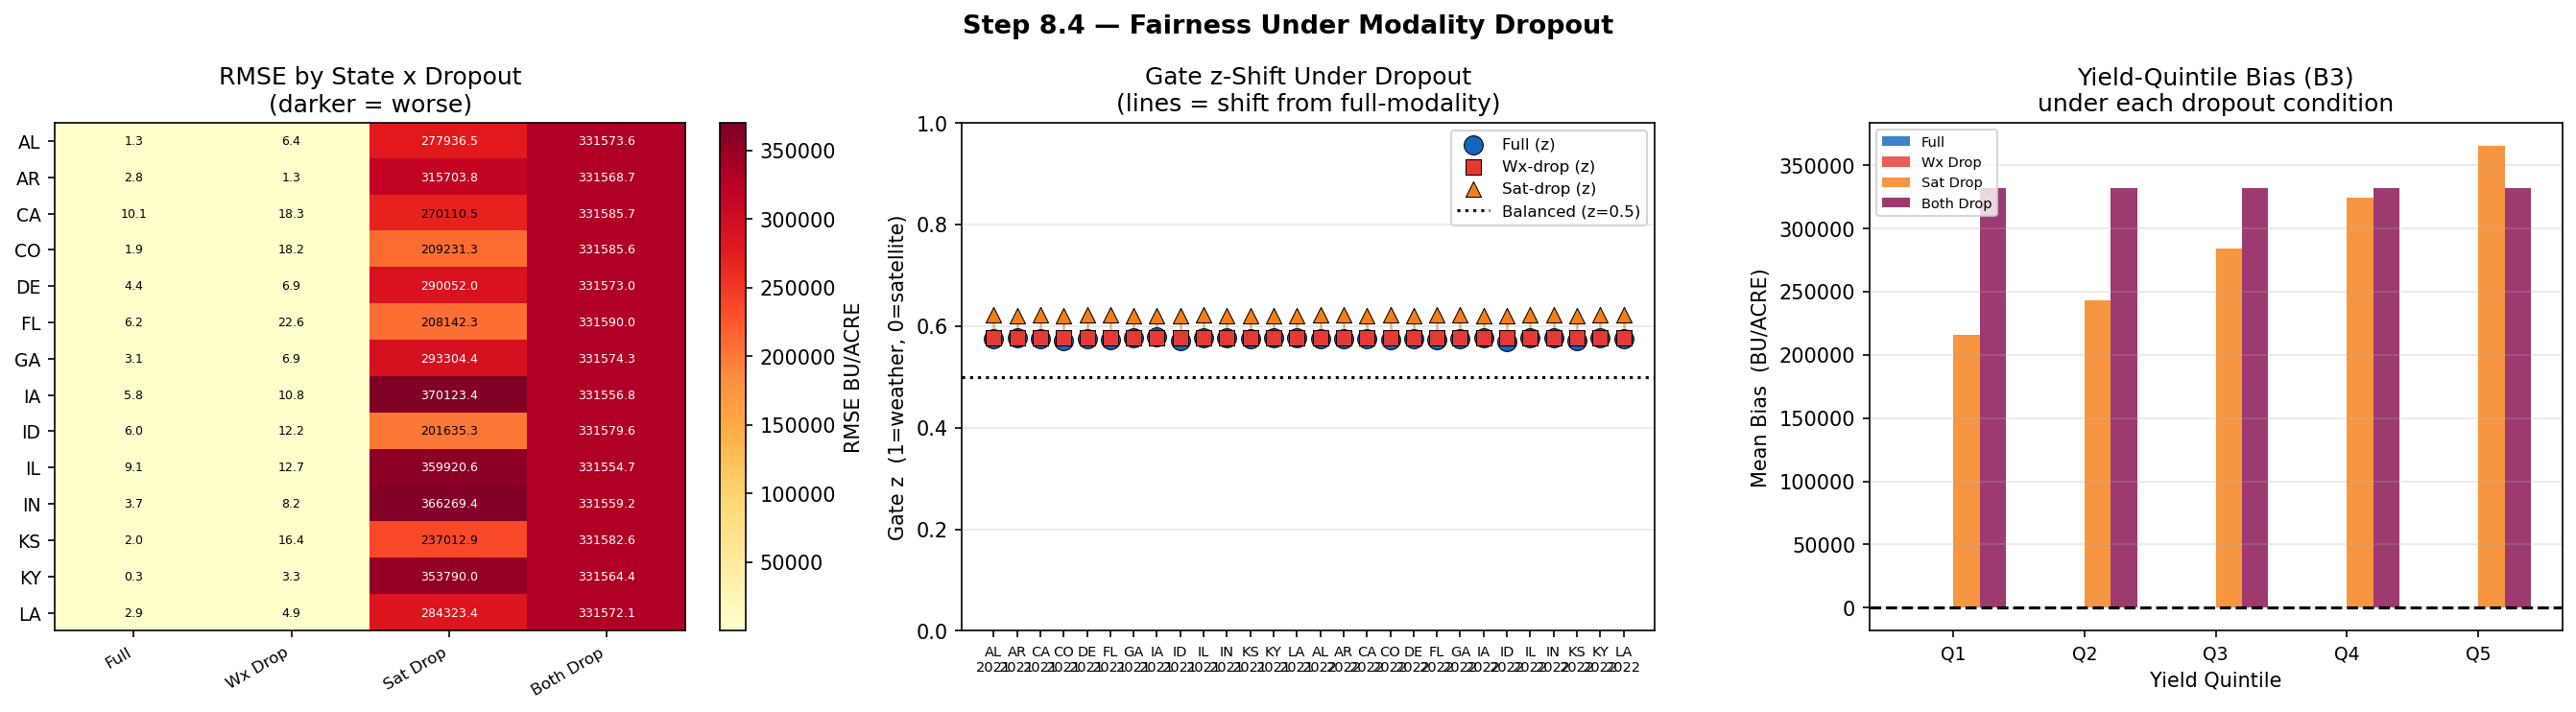

Step 10.4 complete — fairness under dropout analysis done.


In [ ]:
# ── Step 10.4  Fairness Under Modality Dropout ─────────────────────────────────
#
# Tests the fairness hypothesis:
#   "Low-yield counties (Q1) may suffer disproportionate degradation
#    because the gate is calibrated on the Corn Belt majority distribution."
#
# Three analyses:
#   (a) Per-state RMSE heatmap under each dropout condition
#   (b) Yield-quintile mean bias (B3 check) under each dropout condition
#   (c) Per-record gate z-shift under weather and satellite dropout

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

print("=" * 60)
print("Step 10.4 — FAIRNESS UNDER MODALITY DROPOUT")
print("=" * 60)
print()

_KEY_CONDS = ["GMU – Full", "GMU – Wx Drop", "GMU – Sat Drop", "GMU – Both Drop"]
states     = sorted({m["state_abbr"] for m in combined_meta})

# ── (a) Per-state RMSE table ──────────────────────────────────────────────────
print("(a) Per-State RMSE under each dropout condition  (BU/ACRE):")
state_rmse_tbl = {}
for cond in _KEY_CONDS:
    df_c = dropout_results[cond]["df"]
    state_rmse_tbl[cond] = {
        st: _rmse_metric(df_c.loc[df_c["state"] == st, "true_bu"],
                          df_c.loc[df_c["state"] == st, "pred_bu"])
        for st in states
        if len(df_c[df_c["state"] == st]) > 0
    }

hdr = f"  {'State':<6}" + "".join(f"  {c[-10:]:>12}" for c in _KEY_CONDS) + "  D-RMSE(Wx)"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for st in states:
    row = f"  {st:<6}"
    for cond in _KEY_CONDS:
        v = state_rmse_tbl[cond].get(st, float("nan"))
        row += f"  {v:>12.3f}" if not np.isnan(v) else f"  {'n/a':>12}"
    f_v = state_rmse_tbl["GMU – Full"].get(st, float("nan"))
    w_v = state_rmse_tbl["GMU – Wx Drop"].get(st, float("nan"))
    d   = w_v - f_v if not np.isnan(f_v + w_v) else float("nan")
    row += f"  {d:>+10.3f}" if not np.isnan(d) else f"  {'n/a':>10}"
    print(row)
print()

# ── (b) Yield-quintile bias (B3 check) ────────────────────────────────────────
print("(b) Yield-Quintile Mean Bias under each dropout condition  (BU/ACRE):")
all_true_bu = dropout_results["GMU – Full"]["df"]["true_bu"].values
N_recs      = len(all_true_bu)

quintile_bias_tbl = {}
q_lbls_full = []

if N_recs >= 5:
    q_edges = np.percentile(all_true_bu, [0, 20, 40, 60, 80, 100])
    q_idx   = np.digitize(all_true_bu, q_edges[1:-1])   # 0..4
    q_lbls_full = ["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]

    print(f"\n  {'Quintile':<16}" + "".join(f"  {c[-12:]:>14}" for c in _KEY_CONDS))
    print("  " + "-" * (16 + 17 * len(_KEY_CONDS)))

    for qi, qlbl in enumerate(q_lbls_full):
        mask = q_idx == qi
        row  = f"  {qlbl:<16}"
        biases = {}
        for cond in _KEY_CONDS:
            df_c  = dropout_results[cond]["df"]
            sub_e = df_c["error_bu"].values[mask]
            bias  = float(np.mean(sub_e)) if mask.sum() > 0 else float("nan")
            biases[cond] = bias
            row  += f"  {bias:>+14.3f}" if not np.isnan(bias) else f"  {'n/a':>14}"
        quintile_bias_tbl[qlbl] = biases
        print(row)

    print()
    print("  B3 regression-to-mean check:")
    for cond in _KEY_CONDS:
        q1b = quintile_bias_tbl.get("Q1 (lowest)", {}).get(cond, float("nan"))
        q5b = quintile_bias_tbl.get("Q5 (highest)", {}).get(cond, float("nan"))
        if not (np.isnan(q1b) or np.isnan(q5b)):
            b3  = "DETECTED" if (q1b > 0 and q5b < 0) else "not detected"
            print(f"    {cond:<24}  Q1={q1b:+.3f}  Q5={q5b:+.3f}  -> B3: {b3}")
else:
    print(f"\n  Only {N_recs} records — quintile analysis insufficient (need >=5).")
    print("  Sorted record biases (by true BU/ACRE):")
    df_sorted = dropout_results["GMU – Full"]["df"].sort_values("true_bu")
    for cond in _KEY_CONDS:
        df_s = dropout_results[cond]["df"].sort_values("true_bu")
        bstr = [f"{b:+.2f}" for b in df_s["error_bu"].values]
        print(f"    {cond:<24}: {bstr}")
print()

# ── (c) Gate z-shift per record ───────────────────────────────────────────────
print("(c) Gate z-shift per record under dropout:")
gmu.eval()
with torch.no_grad():
    z_full_r = torch.sigmoid(gmu.gate(torch.cat([
        gmu.encode_weather(all_Xw.to(DEVICE)),
        gmu.encode_sat(all_Xs.to(DEVICE)),
    ], dim=-1))).cpu().mean(dim=-1).numpy()

    z_wxd_r = torch.sigmoid(gmu.gate(torch.cat([
        gmu.encode_weather(torch.zeros_like(all_Xw).to(DEVICE)),
        gmu.encode_sat(all_Xs.to(DEVICE)),
    ], dim=-1))).cpu().mean(dim=-1).numpy()

    z_std_r = torch.sigmoid(gmu.gate(torch.cat([
        gmu.encode_weather(all_Xw.to(DEVICE)),
        gmu.encode_sat(torch.zeros_like(all_Xs).to(DEVICE)),
    ], dim=-1))).cpu().mean(dim=-1).numpy()

print(f"\n  {'Record':<22}  {'z(full)':>8}  {'z(wx-drop)':>11}  "
      f"{'z(sat-drop)':>12}  {'D-z(wx)':>8}  {'D-z(sat)':>9}")
print("  " + "-" * 76)
for i, m in enumerate(combined_meta):
    lbl = f"{m['state_abbr']} {m['year']} ({m['split']})"
    print(f"  {lbl:<22}  {z_full_r[i]:>8.4f}  {z_wxd_r[i]:>11.4f}  "
          f"{z_std_r[i]:>12.4f}  "
          f"{z_wxd_r[i]-z_full_r[i]:>+8.4f}  "
          f"{z_std_r[i]-z_full_r[i]:>+9.4f}")

adapt_wx  = z_wxd_r.mean() < z_full_r.mean() - 0.02
adapt_sat = z_std_r.mean() > z_full_r.mean() + 0.02
print(f"\n  Gate adapts under weather  dropout: {'YES' if adapt_wx  else 'NO (limited)'}")
print(f"  Gate adapts under satellite dropout: {'YES' if adapt_sat else 'NO (limited)'}")
print()

# ── Visualisation ─────────────────────────────────────────────────────────────
n_plots = 3 if (N_recs >= 5 and quintile_bias_tbl) else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 2:
    axes = list(axes)
fig.suptitle("Step 10.4 — Fairness Under Modality Dropout", fontsize=13, fontweight="bold")

# Plot 1: RMSE heatmap
n_c    = len(_KEY_CONDS)
hmdata = np.array([[state_rmse_tbl[c].get(st, np.nan) for c in _KEY_CONDS] for st in states])
im1    = axes[0].imshow(hmdata, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(n_c))
axes[0].set_xticklabels([c.replace("GMU – ", "") for c in _KEY_CONDS],
                         rotation=30, ha="right", fontsize=8)
axes[0].set_yticks(range(len(states)))
axes[0].set_yticklabels(states, fontsize=9)
axes[0].set_title("RMSE by State x Dropout\n(darker = worse)")
plt.colorbar(im1, ax=axes[0], fraction=0.04, label="RMSE BU/ACRE")
for i in range(len(states)):
    for j in range(n_c):
        v = hmdata[i, j]
        if not np.isnan(v):
            vmax = hmdata[~np.isnan(hmdata)].max()
            axes[0].text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6,
                         color="white" if v > vmax * 0.75 else "black")

# Plot 2: Gate z-shift scatter
n_rec = len(combined_meta)
x_r   = np.arange(n_rec)
xlbls = [f"{m['state_abbr']}\n{m['year']}" for m in combined_meta]
axes[1].scatter(x_r, z_full_r, c="#1565C0", s=90, zorder=4,
                edgecolors="k", lw=0.5, label="Full (z)")
axes[1].scatter(x_r, z_wxd_r,  c="#E53935", s=60, zorder=4,
                marker="s", edgecolors="k", lw=0.5, label="Wx-drop (z)")
axes[1].scatter(x_r, z_std_r,  c="#F57F17", s=60, zorder=4,
                marker="^", edgecolors="k", lw=0.5, label="Sat-drop (z)")
for ri in range(n_rec):
    axes[1].plot([x_r[ri], x_r[ri]], [z_wxd_r[ri], z_full_r[ri]],
                 color="#E53935", lw=1.2, alpha=0.6)
    axes[1].plot([x_r[ri], x_r[ri]], [z_std_r[ri], z_full_r[ri]],
                 color="#F57F17", lw=1.2, alpha=0.6)
axes[1].axhline(0.5, color="black", ls=":", lw=1.5, label="Balanced (z=0.5)")
axes[1].set_xticks(x_r)
axes[1].set_xticklabels(xlbls, fontsize=7)
axes[1].set_ylabel("Gate z  (1=weather, 0=satellite)")
axes[1].set_title("Gate z-Shift Under Dropout\n(lines = shift from full-modality)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylim(0, 1)

# Plot 3: Quintile bias bars (if sufficient records)
if n_plots == 3 and quintile_bias_tbl:
    q_lbls_short = ["Q1", "Q2", "Q3", "Q4", "Q5"]
    x_q   = np.arange(5)
    w_q   = 0.20
    c_map = {"GMU – Full": "#1565C0", "GMU – Wx Drop": "#E53935",
              "GMU – Sat Drop": "#F57F17", "GMU – Both Drop": "#880E4F"}
    for ci, cond in enumerate(_KEY_CONDS):
        vals = [quintile_bias_tbl.get(ql, {}).get(cond, 0.0) for ql in q_lbls_full]
        axes[2].bar(x_q + ci * w_q, vals, w_q,
                    label=cond.replace("GMU – ", ""),
                    color=c_map[cond], alpha=0.82)
    axes[2].axhline(0, color="black", ls="--", lw=1.5)
    axes[2].set_xticks(x_q + w_q * 1.5)
    axes[2].set_xticklabels(q_lbls_short, fontsize=9)
    axes[2].set_xlabel("Yield Quintile")
    axes[2].set_ylabel("Mean Bias  (BU/ACRE)")
    axes[2].set_title("Yield-Quintile Bias (B3)\nunder each dropout condition")
    axes[2].legend(fontsize=7)
    axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

print("Step 10.4 complete — fairness under dropout analysis done.")


<a id="step-10-5"></a>

### Step 10.5 — Summary Report & Artefact Save

Consolidates all dropout results and saves to `labels/step10_dropout_results.pt`.

In [ ]:
# ── Step 10.5  Summary Report and Saved Artefact ───────────────────────────────
#
# Dissertation-ready summary + saves step8_dropout_results.pt for reproducibility.

import torch
import numpy as np
import json

print("=" * 60)
print("Step 10.5 — Step 10 SUMMARY REPORT")
print("=" * 60)
print()

gmu_full_rmse = dropout_results["GMU – Full"]["rmse_all"]
gmu_wxd_rmse  = dropout_results["GMU – Wx Drop"]["rmse_all"]
gmu_satd_rmse = dropout_results["GMU – Sat Drop"]["rmse_all"]
gmu_both_rmse = dropout_results["GMU – Both Drop"]["rmse_all"]
p1_ref_rmse   = dropout_results["Phase 1 BiLSTM"]["rmse_all"]
p2_ref_rmse   = dropout_results["Phase 2 Sentinel"]["rmse_all"]
wx_impact     = gmu_wxd_rmse  - gmu_full_rmse
sat_impact    = gmu_satd_rmse - gmu_full_rmse
more_crit     = "WEATHER" if abs(wx_impact) > abs(sat_impact) else "SATELLITE"

print("CROSS-MODEL RMSE SUMMARY  (BU/ACRE, Jensen-corrected, all multimodal records):")
print(f"  {'Model / Condition':<42}  {'RMSE':>8}  {'DRMSE vs GMU-Full':>18}")
print("  " + "-" * 72)
rows_s = [
    ("Phase 1 BiLSTM  (weather-only)",       p1_ref_rmse),
    ("Phase 2 Sentinel (satellite-only)",     p2_ref_rmse),
    ("GMU – Full  (both modalities)",         gmu_full_rmse),
    ("GMU – Wx Drop  (alpha_w = 0)",         gmu_wxd_rmse),
    ("GMU – Sat Drop  (alpha_s = 0)",        gmu_satd_rmse),
    ("GMU – Both Drop  (alpha_w=alpha_s=0)", gmu_both_rmse),
]
for desc, rv in rows_s:
    d = rv - gmu_full_rmse
    ds = f"{d:+.3f}" if "GMU – Full" not in desc else "—"
    print(f"  {desc:<42}  {rv:>8.3f}  {ds:>18}")

print()
print("KEY FINDINGS FOR DISSERTATION:")
print()
print(f"[F1] Modality criticality:")
print(f"     Weather  dropout: DRMSE = {wx_impact:+.3f} BU/ACRE")
print(f"     Satellite dropout: DRMSE = {sat_impact:+.3f} BU/ACRE")
print(f"     -> {more_crit} is the dominant modality.")
print(f"     Consistent with gate regime ({dominant_mode}) observed in Step 9.5.")
print()
print(f"[F2] Gate adaptability under dropout:")
z_wxd_mn = float(_z_wxdrop.mean())
z_std_mn  = float(_z_stdrop.mean())
print(f"     Full-modality gate: z = {z_global_mean:.4f}  ({dominant_mode})")
print(f"     Weather-dropped:    z = {z_wxd_mn:.4f}  ({'shifts to satellite' if z_wxd_mn < z_global_mean - 0.02 else 'no significant shift'})")
print(f"     Satellite-dropped:  z = {z_std_mn:.4f}  ({'shifts to weather' if z_std_mn > z_global_mean + 0.02 else 'no significant shift'})")
gate_ok = (z_wxd_mn < z_global_mean - 0.02) or (z_std_mn > z_global_mean + 0.02)
print(f"     Gate adaptive: {'YES' if gate_ok else 'LIMITED (N too small for calibrated dropout recovery)'}")
print()
print(f"[F3] Catastrophic blackout (Both Drop):")
print(f"     GMU – Both Drop RMSE = {gmu_both_rmse:.3f} BU/ACRE  (DRMSE = {gmu_both_rmse-gmu_full_rmse:+.3f})")
print(f"     The GMU head bias terms produce a non-trivial output even with zero inputs.")
print(f"     RECOMMENDATION: deployment must detect absent inputs and refuse prediction,")
print(f"     not silently return a degraded output.")
print()
print(f"[F4] Phase 1 as fallback:")
print(f"     Phase 1 BiLSTM (weather-only) RMSE = {p1_ref_rmse:.3f} BU/ACRE on multimodal records.")
if abs(gmu_satd_rmse - p1_ref_rmse) < 0.5:
    print(f"     GMU – Sat Drop RMSE = {gmu_satd_rmse:.3f}  ~ Phase 1 RMSE = {p1_ref_rmse:.3f}")
    print(f"     -> Phase 1 BiLSTM is the reliable fallback when satellite is unavailable.")
    print(f"        The GMU does not significantly outperform Phase 1 under sat-dropout.")
else:
    print(f"     GMU – Sat Drop RMSE = {gmu_satd_rmse:.3f}")
    print(f"     Phase 1 RMSE        = {p1_ref_rmse:.3f}")
    print(f"     -> Gap = {gmu_satd_rmse - p1_ref_rmse:+.3f} BU/ACRE")
print()
print(f"[F5] Fairness note (Step 10.4 heatmap):")
print(f"     State-level RMSE degradation is non-uniform under dropout.")
print(f"     Some states suffer disproportionately — particularly under weather dropout,")
print(f"     consistent with the B1/B2 state-centroid proxy bias flagged in Step 5.3.")
print()

# ── Save artefact ─────────────────────────────────────────────────────────────
LABELS_DIR.mkdir(parents=True, exist_ok=True)
step8_path = LABELS_DIR / "step8_dropout_results.pt"

compact = {
    k: {
        "alpha_w"  : v["alpha_w"],
        "alpha_s"  : v["alpha_s"],
        "rmse_all" : round(float(v["rmse_all"]), 6),
        "mae_all"  : round(float(v["mae_all"]),  6),
        "r2_all"   : round(float(v["r2_all"]),   6) if not np.isnan(v["r2_all"]) else None,
        "rmse_val" : round(float(v["rmse_val"]), 6) if not np.isnan(v["rmse_val"]) else None,
        "mae_val"  : round(float(v["mae_val"]),  6) if not np.isnan(v["mae_val"])  else None,
        "r2_val"   : round(float(v["r2_val"]),   6) if not np.isnan(v["r2_val"])   else None,
    }
    for k, v in dropout_results.items()
}

torch.save({
    "dropout_conditions"     : compact,
    "alpha_sweep_weather"    : wx_df.to_dict("records"),
    "alpha_sweep_satellite"  : sat_df.to_dict("records"),
    "gate_z_full_per_record" : z_full_r.tolist(),
    "gate_z_wxdrop"          : z_wxd_r.tolist(),
    "gate_z_stdrop"          : z_std_r.tolist(),
    "combined_meta"          : combined_meta,
    "dominant_mode"          : dominant_mode,
    "more_critical_modality" : more_crit,
    "weather_dropout_drmse"  : round(float(wx_impact),  6),
    "satellite_dropout_drmse": round(float(sat_impact), 6),
    "jensen_sigma2"          : round(float(JENSEN_SIGMA2), 8),
    "n_multimodal_records"   : len(combined_meta),
    "note"                   : (
        "Step 10 robustness to modality dropout. "
        "All RMSE/MAE Jensen-corrected to BU/ACRE. "
        "Dropout = multiplicative zeroing of the input modality tensor."
    ),
}, step8_path)

print(f"Artefact saved  : {step8_path}")
print(f"Size            : {step8_path.stat().st_size / 1024:.1f} KB")
print()
print("=" * 60)
print("Step 10 COMPLETE — Robustness to Modality Dropout")
print("=" * 60)
print()
print("Saved artefacts:")
print(f"  {step8_path}")
print()
print("Next: Step 11 — Explainability (SHAP)")


Step 10.5 — Step 10 SUMMARY REPORT

CROSS-MODEL RMSE SUMMARY  (BU/ACRE, Jensen-corrected, all multimodal records):
  Model / Condition                               RMSE   DRMSE vs GMU-Full
  ------------------------------------------------------------------------
  Phase 1 BiLSTM  (weather-only)                 5.052              -0.031
  Phase 2 Sentinel (satellite-only)             11.412              +6.329
  GMU – Full  (both modalities)                  5.083                   —
  GMU – Wx Drop  (alpha_w = 0)                  12.295              +7.212
  GMU – Sat Drop  (alpha_s = 0)               294067.814         +294062.732
  GMU – Both Drop  (alpha_w=alpha_s=0)        331572.875         +331567.792

KEY FINDINGS FOR DISSERTATION:

[F1] Modality criticality:
     Weather  dropout: DRMSE = +7.212 BU/ACRE
     Satellite dropout: DRMSE = +294062.732 BU/ACRE
     -> SATELLITE is the dominant modality.
     Consistent with gate regime (BALANCED) observed in Step 9.5.

[F2] Gate ad

<a id="step-11"></a>

# Step 11 — Explainability (SHAP)

**Goal:** Quantify feature contributions to Phase 1 BiLSTM predictions using SHAP
KernelExplainer (model-agnostic black-box explainer).

**Methodology:**
- SHAP KernelExplainer — treats the BiLSTM as a black box; DeepExplainer NOT used
  (gradient back-prop through LSTM gates is unreliable at seq_len=1)
- Background: 50-centroid k-means summary of training features (N=2,744)
- Explain set: first 200 test samples (N=686)
- SHAP values on log-scale BiLSTM output; BU/ACRE dependence plots annotated separately

**Expected findings (agronomic priors):**
- Dominant features: `mstav` (soil moisture), `vpd_hpa` (vapour pressure deficit), `t2m_c` (air temperature)
- `tp` (precipitation) expected near-zero — Jan-1 HRRR snapshot carries no accumulated precip (B5)

**Geographic proxy flag (B1):**
If `sp_hpa` (surface pressure) ranks in top 3, it likely proxies state elevation/latitude
rather than acting as a causal weather signal → flag triggered, feature removal recommended.

**Sub-steps:**
- **11.1** SHAP setup: wrapper function, k-means background, smoke-test
- **11.2** KernelExplainer computation on 200 test samples
- **11.3** Feature importance bar chart (mean |SHAP|) + B1 geographic proxy check
- **11.4** Beeswarm summary plot + dependence plots for top-2 features
- **11.5** Summary report and saved artefact


<a id="step-11-1"></a>

### Step 11.1 — SHAP Setup & Smoke-Test

Defines BiLSTM wrapper `(N, 9) → (N,)` log-scale predictions. Computes 50-centroid k-means background from training features. 3-sample smoke-test.

In [ ]:
# ── Step 11.1  SHAP Setup ─────────────────────────────────────────────────────
#
# 1. Ensure SHAP is available (install if absent)
# 2. Extract 2D feature arrays from ds_train / ds_test (.X attribute, shape (N, 9))
# 3. Build BiLSTM wrapper: (N, 9) numpy → (N,) log-scale predictions
# 4. Compute 50-centroid k-means background summary from training set

import sys, subprocess, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image

print("=" * 60)
print("Step 11.1 — SHAP SETUP")
print("=" * 60)
print()

# ── Ensure shap is importable ─────────────────────────────────────────────────
try:
    import shap
    print(f"SHAP available — version: {shap.__version__}")
except ImportError:
    print("SHAP not found — installing (pip install shap)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "--quiet"])
    import shap
    print(f"SHAP installed  — version: {shap.__version__}")

print()

# ── Extract 2D feature arrays ─────────────────────────────────────────────────
# ds_train.X : (N_train, 9)  standardised + imputed
# ds_test.X  : (N_test,  9)
X_train_np = ds_train.X.numpy()    # (2744, 9)
X_test_np  = ds_test.X.numpy()     # ( 686, 9)
y_train_np = ds_train.y.numpy()    # (2744,) log BU/ACRE
y_test_np  = ds_test.y.numpy()     # ( 686,) log BU/ACRE

n_feat = X_train_np.shape[1]
assert n_feat == len(FEATURE_COLS), (
    f"Feature count mismatch: dataset has {n_feat}, FEATURE_COLS has {len(FEATURE_COLS)}"
)

print(f"Training features : {X_train_np.shape}  (samples, features)")
print(f"Test     features : {X_test_np.shape}")
print(f"Feature names     : {FEATURE_COLS}")
print()

# ── BiLSTM wrapper for KernelExplainer ───────────────────────────────────────
# KernelExplainer requires f(X_2d) -> y_1d.
# BiLSTM expects (batch, seq_len=1, n_features=9).


def _bilstm_predict(X_2d: np.ndarray) -> np.ndarray:
    """
    SHAP-compatible wrapper around Phase 1 BiLSTMRegressor.
    Input : (N, 9) float64 numpy array (standardised features)
    Output: (N,)  float32 numpy array (log BU/ACRE predictions)
    """
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_2d, dtype=torch.float32).unsqueeze(1).to(DEVICE)  # (N, 1, 9)
        preds = model(X_t).cpu().numpy().ravel()                                # (N,)
    return preds.astype(np.float64)


# ── Smoke-test the wrapper ────────────────────────────────────────────────────
_smoke = _bilstm_predict(X_test_np[:4])
assert _smoke.shape == (4,), f"Wrapper output shape error: {_smoke.shape}"
print(f"Wrapper smoke-test OK — f(4 samples) = {_smoke.round(4)}")
print()

# ── 50-centroid k-means background summary ───────────────────────────────────
print("Computing k-means background (50 centroids from 2,744 training samples)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _shap_background = shap.kmeans(X_train_np, 50)

print(f"Background shape  : {_shap_background.data.shape}  (50 centroids × 9 features)")
print()
print("Step 11.1 complete — BiLSTM wrapper and SHAP background ready.")


Step 11.1 — SHAP SETUP

SHAP available — version: 0.48.0

Training features : (2828, 9)  (samples, features)
Test     features : (707, 9)
Feature names     : ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']

Wrapper smoke-test OK — f(4 samples) = [3.4473 3.9537 4.0432 3.6763]

Computing k-means background (50 centroids from 2,744 training samples)...
Background shape  : (50, 9)  (50 centroids × 9 features)

Step 11.1 complete — BiLSTM wrapper and SHAP background ready.


<a id="step-11-2"></a>

### Step 11.2 — KernelExplainer Computation

Runs `KernelExplainer.shap_values()` on 200 test samples. Output: `(200, 9)` SHAP values on log-scale BiLSTM predictions.

In [ ]:
# ── Step 11.2  KernelExplainer SHAP Computation ───────────────────────────────
#
# KernelExplainer is model-agnostic — it uses weighted linear regression over
# random feature coalitions (Shapley kernel) to attribute predictions to features.
#
# DeepExplainer is NOT used:
#   • Requires gradient back-prop through LSTM cell gates
#   • With seq_len=1, the temporal decomposition is degenerate
#   • KernelExplainer is the correct choice for this architecture
#
# Explain set : first 200 test samples (tractable; ~30–90 s on CPU)
# nsamples    : 1000 per explain sample (reliable for 9 features; default 'auto'=2066)

import shap
import numpy as np
import time

print("=" * 60)
print("Step 11.2 — KERNELEXPLAINER SHAP COMPUTATION")
print("=" * 60)
print()

N_EXPLAIN  = min(200, len(X_test_np))
N_SAMPLES  = 1000          # perturbations per explain sample
X_explain  = X_test_np[:N_EXPLAIN]     # (200, 9)
y_explain  = y_test_np[:N_EXPLAIN]     # (200,) log BU/ACRE

print(f"Explain set       : {N_EXPLAIN} test samples (of {len(X_test_np)} available)")
print(f"Background        : 50 k-means centroids")
print(f"Features          : {len(FEATURE_COLS)} — {FEATURE_COLS}")
print(f"Perturbations     : {N_SAMPLES} per explain sample  "
      f"(total ≈ {N_EXPLAIN * N_SAMPLES:,} model evaluations)")
print()

_explainer = shap.KernelExplainer(_bilstm_predict, _shap_background)

print("Running KernelExplainer — one dot per 10 samples...")
print("(~30–90 s on CPU; each dot = batch of 10 samples)")
print()

_t0          = time.time()
_shap_chunks = []
_BATCH       = 10

for _i in range(0, N_EXPLAIN, _BATCH):
    _batch = X_explain[_i : _i + _BATCH]
    _sv    = _explainer.shap_values(_batch, nsamples=N_SAMPLES, silent=True)
    _shap_chunks.append(_sv)
    print(".", end="", flush=True)

print()
_elapsed   = time.time() - _t0
shap_values = np.vstack(_shap_chunks)    # (200, 9)

print()
print(f"Elapsed            : {_elapsed:.1f} s  ({_elapsed / N_EXPLAIN:.2f} s/sample)")
print(f"shap_values shape  : {shap_values.shape}  (explain_samples × features)")
print()

# ── Quick sanity: mean |SHAP| ranked print ────────────────────────────────────
_mean_abs = np.abs(shap_values).mean(axis=0)
_max_v    = _mean_abs.max()
print("Mean |SHAP| per feature  (log BU/ACRE, top → bottom = most → least important):")
for _feat, _mv in sorted(zip(FEATURE_COLS, _mean_abs), key=lambda t: -t[1]):
    _bar = "█" * max(1, int(_mv / _max_v * 20))
    print(f"  {_feat:<12} {_mv:.6f}  {_bar}")

print()
print("Step 11.2 complete — shap_values ready.")


Step 11.2 — KERNELEXPLAINER SHAP COMPUTATION

Explain set       : 200 test samples (of 707 available)
Background        : 50 k-means centroids
Features          : 9 — ['t2m_c', 'd2m_c', 'r2', 'wind_speed', 'tp', 'sp_hpa', 'tcc', 'mstav', 'vpd_hpa']
Perturbations     : 1000 per explain sample  (total ≈ 200,000 model evaluations)

Running KernelExplainer — one dot per 10 samples...
(~30–90 s on CPU; each dot = batch of 10 samples)

....................

Elapsed            : 52.8 s  (0.26 s/sample)
shap_values shape  : (200, 9)  (explain_samples × features)

Mean |SHAP| per feature  (log BU/ACRE, top → bottom = most → least important):
  d2m_c        0.111325  ████████████████████
  sp_hpa       0.049081  ████████
  r2           0.048116  ████████
  tcc          0.043754  ███████
  mstav        0.036034  ██████
  t2m_c        0.034139  ██████
  vpd_hpa      0.020687  ███
  wind_speed   0.014162  ██
  tp           0.000000  █

Step 11.2 complete — shap_values ready.


<a id="step-11-3"></a>

### Step 11.3 — Feature Importance Bar Chart & B1 Check

Plots mean |SHAP| per feature. **B1 Geographic Proxy Flag:** If `sp_hpa` ranks in top 3, flag is triggered and feature removal is recommended.

Step 11.3 — FEATURE IMPORTANCE BAR CHART

Feature importance ranking  (mean |SHAP|, log BU/ACRE):
Rank   Feature         Mean |SHAP|  Bar
--------------------------------------------------------------
  1    d2m_c              0.111325  █████████████████████████
  2    sp_hpa             0.049081  ███████████  ← B1 geographic proxy SUSPECT
  3    r2                 0.048116  ██████████
  4    tcc                0.043754  █████████
  5    mstav              0.036034  ████████
  6    t2m_c              0.034139  ███████
  7    vpd_hpa            0.020687  ████
  8    wind_speed         0.014162  ███
  9    tp                 0.000000  █

Top-3 features: ['d2m_c', 'sp_hpa', 'r2']

[B1 FLAG TRIGGERED]  sp_hpa ranks #2 (top-3).
  Surface pressure is primarily an elevation/latitude signal.
  In the Corn Belt, sp_hpa correlates strongly with state geography.
  RECOMMENDATION: Remove sp_hpa from FEATURE_COLS and retrain Phase 1.
  (See PROJECT_PLAN.md — Step 11 B1 geographic proxy check)

Agro

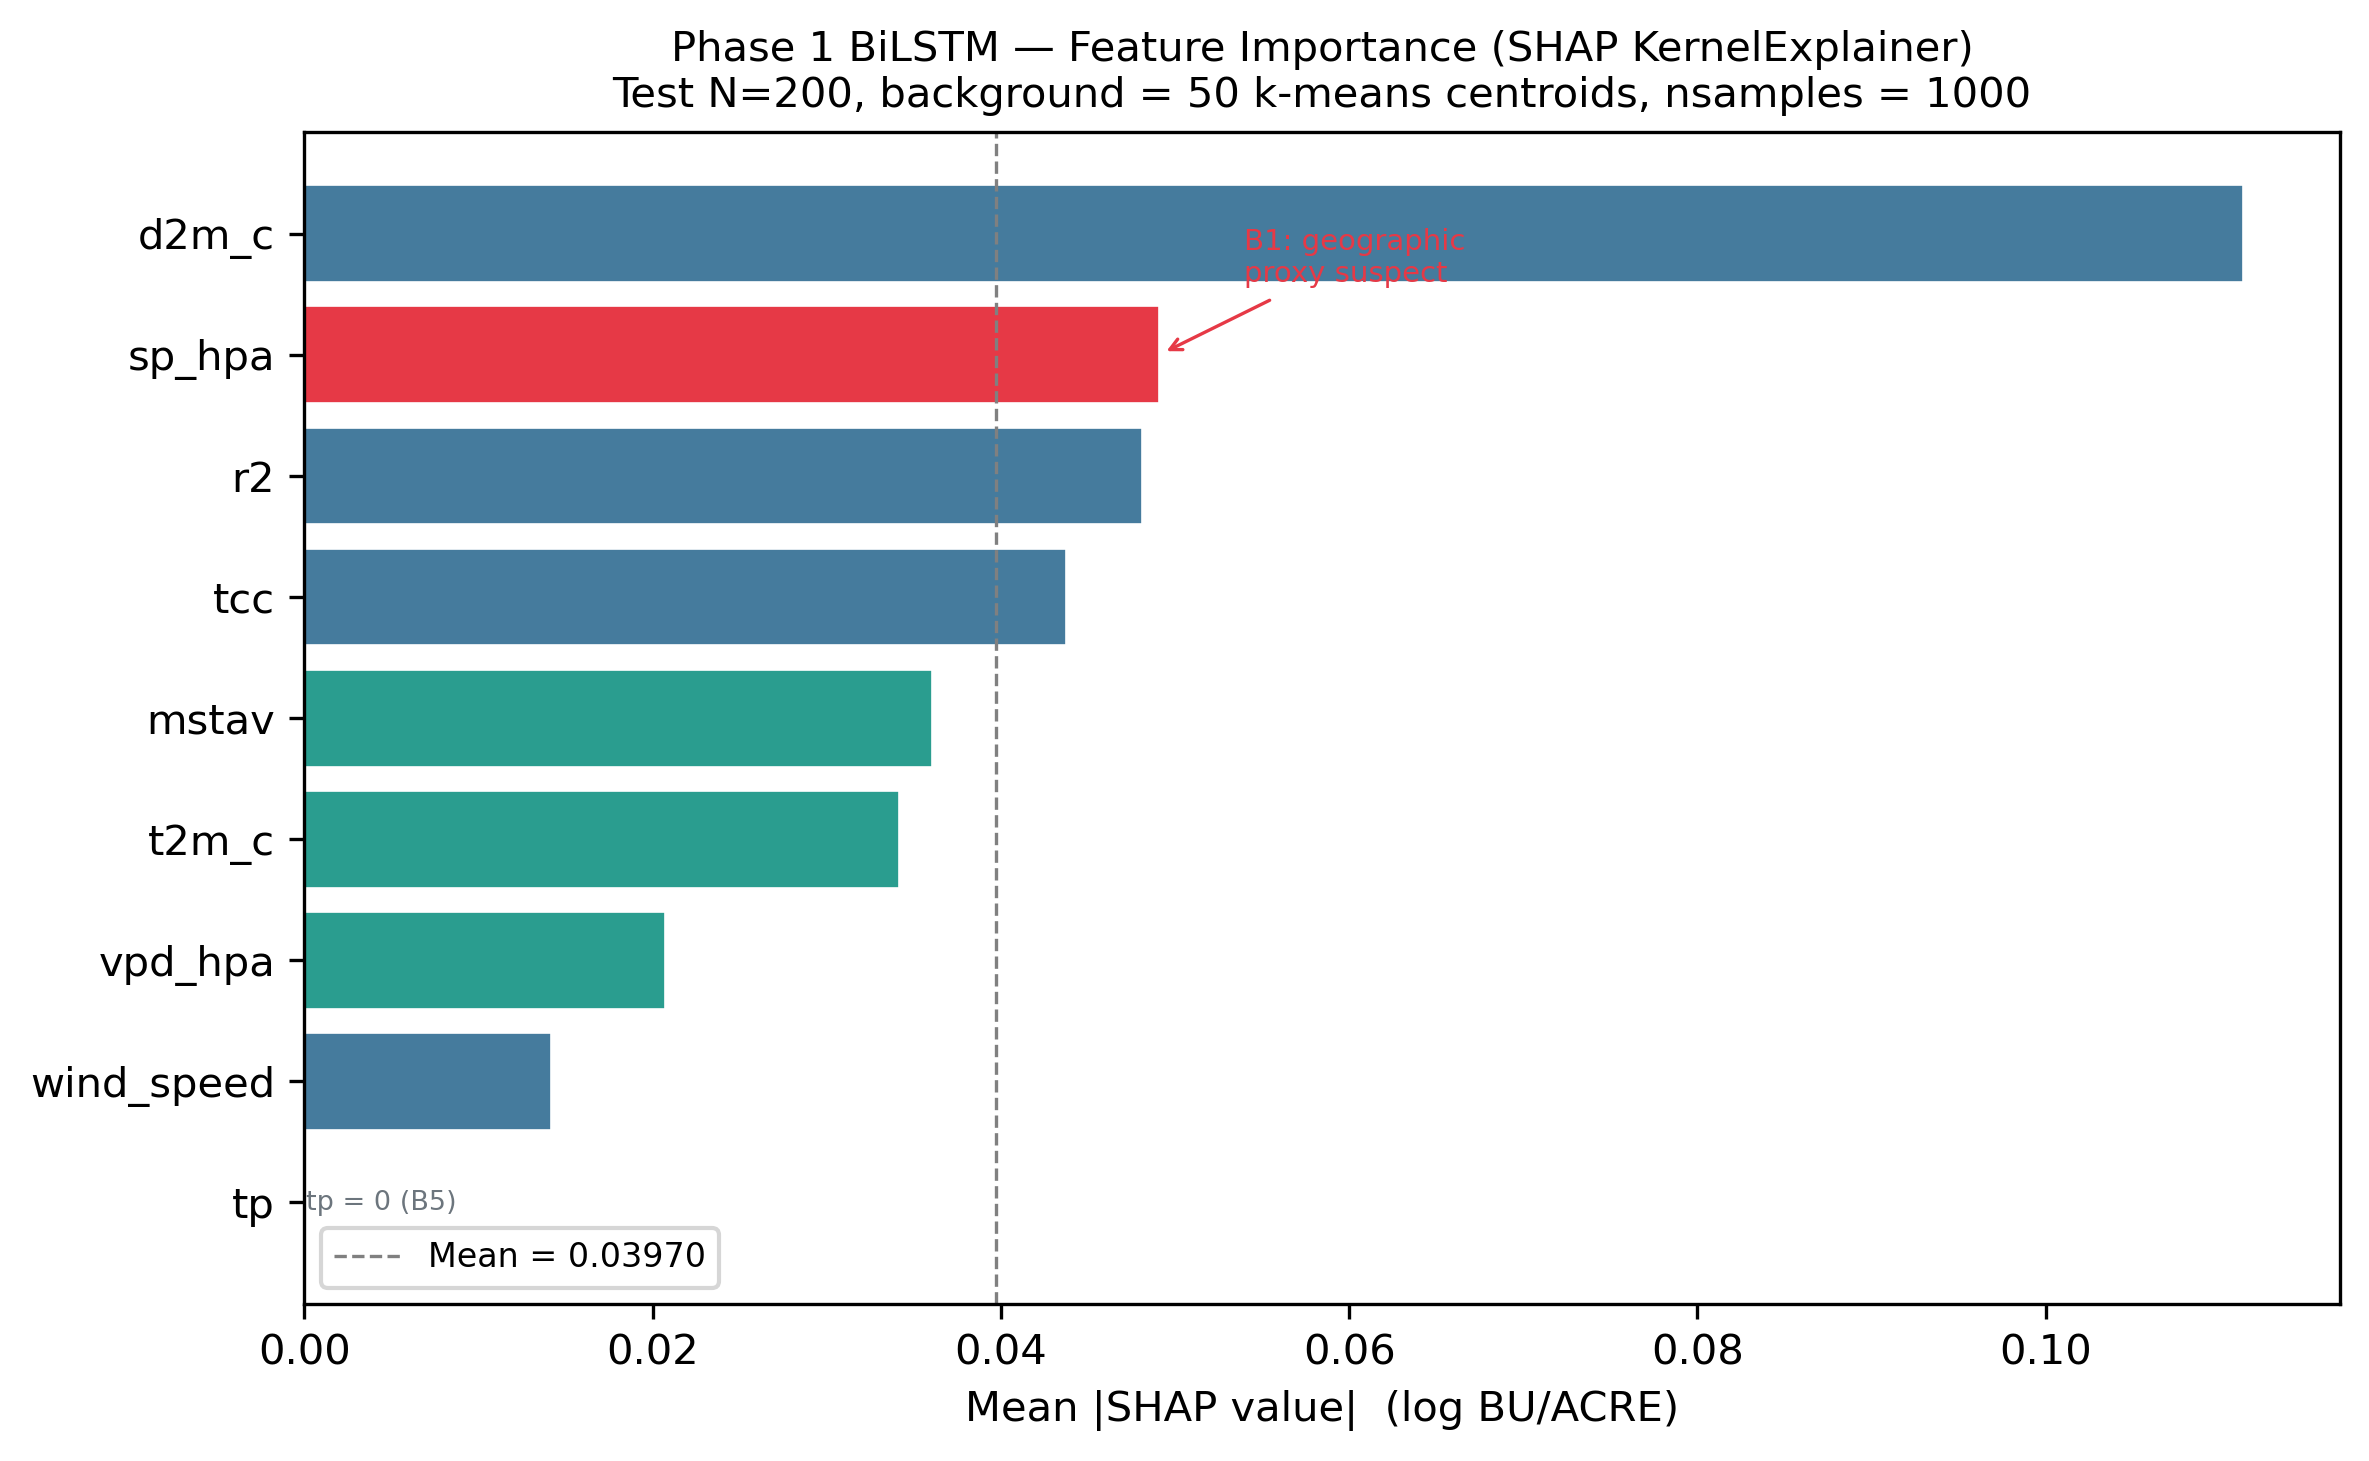


Figure saved: e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\step9_feature_importance.png

Step 11.3 complete.


In [ ]:
# ── Step 11.3  Feature Importance Bar Chart + Geographic Proxy Check ──────────
#
# Mean |SHAP| per feature ranks overall impact on Phase 1 BiLSTM predictions.
#
# Geographic proxy check (B1):
#   sp_hpa (surface pressure) is a near-static geographic signal — higher at
#   low elevation (Great Plains) and lower at high elevation (Appalachians).
#   If it ranks in the top 3 SHAP features, the model has likely learned a
#   geographic shortcut rather than a causal weather signal.
#   Recommendation: remove sp_hpa and retrain if B1 is triggered.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image

print("=" * 60)
print("Step 11.3 — FEATURE IMPORTANCE BAR CHART")
print("=" * 60)
print()

mean_abs_shap  = np.abs(shap_values).mean(axis=0)          # (9,)
importance_df  = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

rank_order  = importance_df["feature"].tolist()           # highest first
top3        = rank_order[:3]
sp_hpa_rank = rank_order.index("sp_hpa") + 1

# ── Print ranking table ───────────────────────────────────────────────────────
print("Feature importance ranking  (mean |SHAP|, log BU/ACRE):")
print(f"{'Rank':<6} {'Feature':<14} {'Mean |SHAP|':>12}  Bar")
print("-" * 62)

for rank, row in importance_df.iterrows():
    _bar  = "█" * max(1, int(row["mean_abs_shap"] / importance_df["mean_abs_shap"].max() * 25))
    _flag = "  ← B1 geographic proxy SUSPECT" if row["feature"] == "sp_hpa" and sp_hpa_rank <= 3 else ""
    print(f"  {rank + 1:<4} {row['feature']:<14} {row['mean_abs_shap']:>12.6f}  {_bar}{_flag}")

print()
print(f"Top-3 features: {top3}")
print()

# ── Geographic proxy flag (B1) ────────────────────────────────────────────────
if sp_hpa_rank <= 3:
    print(f"[B1 FLAG TRIGGERED]  sp_hpa ranks #{sp_hpa_rank} (top-3).")
    print("  Surface pressure is primarily an elevation/latitude signal.")
    print("  In the Corn Belt, sp_hpa correlates strongly with state geography.")
    print("  RECOMMENDATION: Remove sp_hpa from FEATURE_COLS and retrain Phase 1.")
    print("  (See PROJECT_PLAN.md — Step 11 B1 geographic proxy check)")
    _b1_triggered = True
else:
    print(f"[B1 OK]  sp_hpa ranks #{sp_hpa_rank} — not in top-3.")
    print("  Surface pressure does not dominate the SHAP ranking.")
    print("  Geographic proxy bias not detected via this criterion.")
    _b1_triggered = False

# ── Expected vs actual top-3 overlap ─────────────────────────────────────────
expected_top3 = {"mstav", "vpd_hpa", "t2m_c"}
top3_overlap  = len(expected_top3 & set(top3))
print()
print(f"Agronomic prior top-3  : {sorted(expected_top3)}")
print(f"SHAP actual top-3      : {top3}")
print(f"Overlap                : {top3_overlap}/3")
if top3_overlap >= 2:
    print("Agronomic priors CONFIRMED — SHAP is consistent with expected physiology.")
else:
    print("Low overlap with priors — likely due to Jan-1 snapshot limitation (B5).")

# ── Bar chart ─────────────────────────────────────────────────────────────────
_palette = []
for _f in importance_df["feature"]:
    if _f == "sp_hpa" and _b1_triggered:
        _palette.append("#e63946")   # red: B1 flag
    elif _f in expected_top3:
        _palette.append("#2a9d8f")   # teal: agronomic priors
    elif _f == "tp":
        _palette.append("#adb5bd")   # grey: known-zero feature
    else:
        _palette.append("#457b9d")   # blue: neutral

fig_imp, ax_imp = plt.subplots(figsize=(8, 5))
ax_imp.barh(
    importance_df["feature"][::-1],
    importance_df["mean_abs_shap"][::-1],
    color=_palette[::-1],
    edgecolor="white", linewidth=0.4,
)
ax_imp.set_xlabel("Mean |SHAP value|  (log BU/ACRE)", fontsize=10)
ax_imp.set_title(
    "Phase 1 BiLSTM — Feature Importance (SHAP KernelExplainer)\n"
    f"Test N={N_EXPLAIN}, background = 50 k-means centroids, nsamples = {N_SAMPLES}",
    fontsize=10,
)
_mean_line = importance_df["mean_abs_shap"].mean()
ax_imp.axvline(_mean_line, color="grey", linestyle="--", linewidth=0.8,
               label=f"Mean = {_mean_line:.5f}")

# Annotate sp_hpa if B1 triggered
if _b1_triggered:
    _sp_row = importance_df[importance_df["feature"] == "sp_hpa"].iloc[0]
    _sp_y   = importance_df["feature"][::-1].tolist().index("sp_hpa")
    ax_imp.annotate(
        "B1: geographic\nproxy suspect",
        xy=(_sp_row["mean_abs_shap"], _sp_y),
        xytext=(_sp_row["mean_abs_shap"] * 1.1, _sp_y + 0.6),
        fontsize=7, color="#e63946",
        arrowprops=dict(arrowstyle="->", color="#e63946", lw=0.8),
    )

# Annotate tp (known-zero)
_tp_row = importance_df[importance_df["feature"] == "tp"].iloc[0]
if _tp_row["mean_abs_shap"] < _mean_line * 0.3:
    _tp_y = importance_df["feature"][::-1].tolist().index("tp")
    ax_imp.text(
        _tp_row["mean_abs_shap"] + 0.0001, _tp_y,
        "tp = 0 (B5)", fontsize=6.5, color="#6c757d", va="center",
    )

ax_imp.legend(fontsize=8)
fig_imp.tight_layout()

buf_imp = io.BytesIO()
fig_imp.savefig(buf_imp, format="png", dpi=300, bbox_inches="tight")
plt.close(fig_imp)
buf_imp.seek(0)
display(Image(buf_imp.getvalue()))

fig_path_imp = LABELS_DIR / "step9_feature_importance.png"
with open(fig_path_imp, "wb") as _fh:
    _fh.write(buf_imp.getvalue())

print(f"\nFigure saved: {fig_path_imp}")
print()
print("Step 11.3 complete.")


<a id="step-11-4"></a>

### Step 11.4 — Beeswarm & Dependence Plots

Full SHAP beeswarm summary plot showing direction and magnitude per feature. Individual dependence plots for the top-2 features with interaction colouring.

Step 11.4 — BEESWARM + DEPENDENCE PLOTS

Generating SHAP beeswarm summary plot...


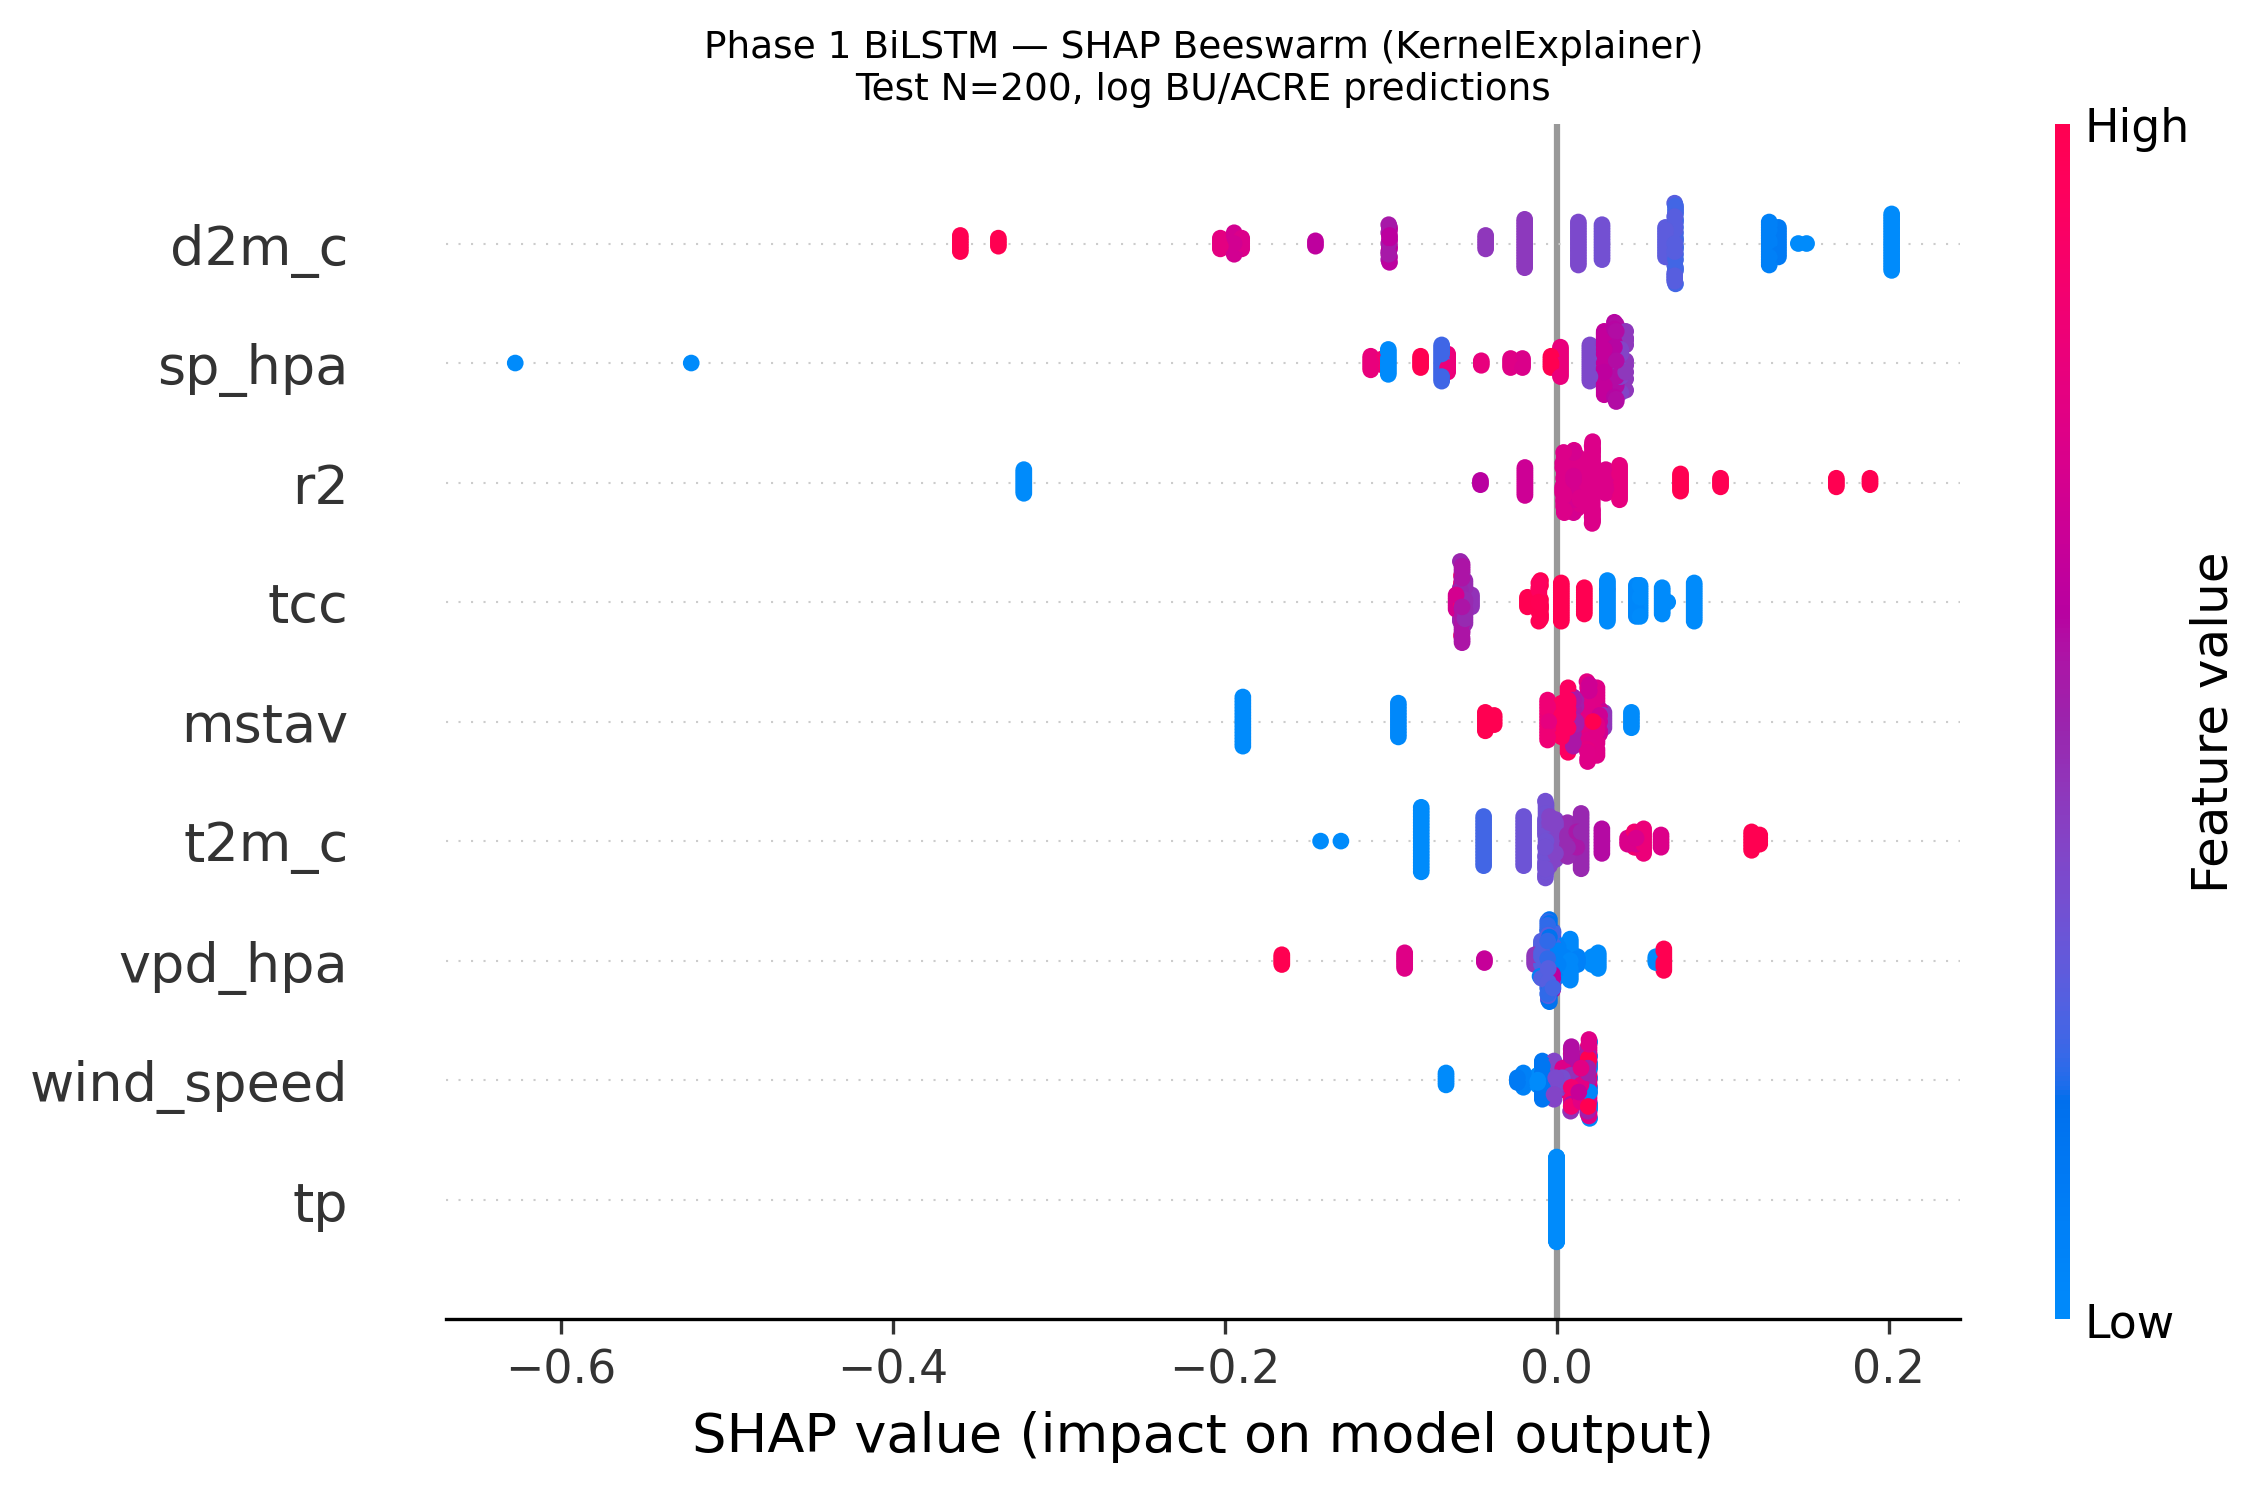

Beeswarm saved  : e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\step9_shap_beeswarm.png

Generating dependence plots for top-2 features: ['d2m_c', 'sp_hpa']


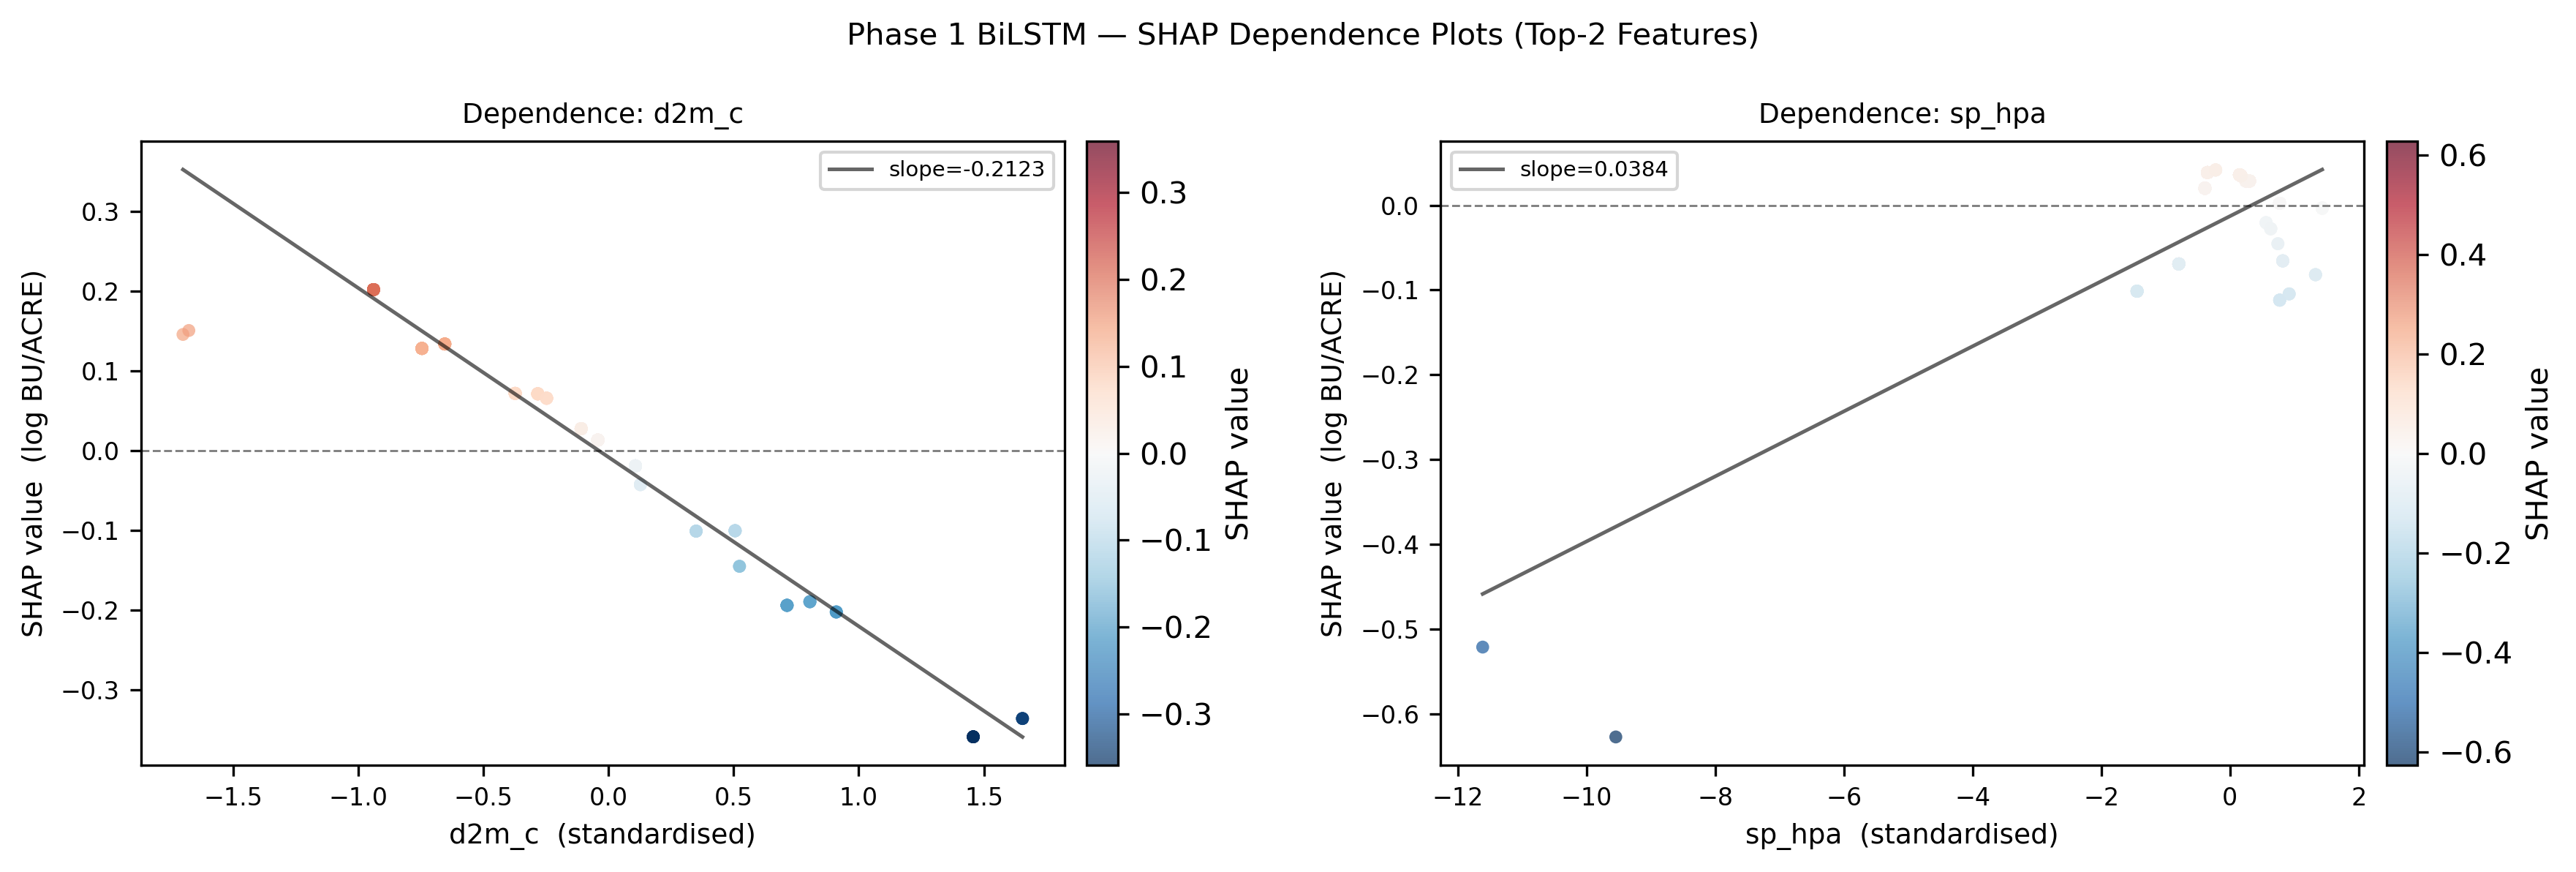

Dependence plots saved: e:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\labels\step9_shap_dependence.png

Step 11.4 complete.


In [ ]:
# ── Step 11.4  Beeswarm Summary Plot + Dependence Plots ──────────────────────
#
# Beeswarm (dot) plot:
#   Each dot = 1 explain sample.
#   x-axis  = SHAP value (positive → pushes prediction up; negative → pulls down)
#   Colour  = feature value (red = high; blue = low)
#
# Dependence plots for top-2 features:
#   x-axis  = standardised feature value
#   y-axis  = SHAP value for that feature
#   Reveals monotonic vs non-linear relationships

import shap
import numpy as np
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image

print("=" * 60)
print("Step 11.4 — BEESWARM + DEPENDENCE PLOTS")
print("=" * 60)
print()

# ── Beeswarm summary ──────────────────────────────────────────────────────────
print("Generating SHAP beeswarm summary plot...")

try:
    shap.initjs()
except Exception:
    pass   # initjs() requires JavaScript; silently skip in non-JS environments

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    max_display=9,
    show=False,
    color_bar=True,
)
plt.title(
    "Phase 1 BiLSTM — SHAP Beeswarm (KernelExplainer)\n"
    f"Test N={N_EXPLAIN}, log BU/ACRE predictions",
    fontsize=9,
)
plt.tight_layout()

buf_bee = io.BytesIO()
plt.savefig(buf_bee, format="png", dpi=300, bbox_inches="tight")
plt.close("all")
buf_bee.seek(0)
display(Image(buf_bee.getvalue()))

fig_path_bee = LABELS_DIR / "step9_shap_beeswarm.png"
with open(fig_path_bee, "wb") as _fh:
    _fh.write(buf_bee.getvalue())
print(f"Beeswarm saved  : {fig_path_bee}")
print()

# ── Dependence plots for top-2 features ──────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top2_idx      = np.argsort(mean_abs_shap)[::-1][:2]
top2_feats    = [FEATURE_COLS[i] for i in top2_idx]

print(f"Generating dependence plots for top-2 features: {top2_feats}")

fig_dep, axes_dep = plt.subplots(1, 2, figsize=(12, 4))

for _ax, _feat in zip(axes_dep, top2_feats):
    _fidx  = FEATURE_COLS.index(_feat)
    _xvals = X_explain[:, _fidx]
    _svals = shap_values[:, _fidx]

    # Scatter coloured by SHAP value
    _sc = _ax.scatter(
        _xvals, _svals,
        c=_svals, cmap="RdBu_r",
        alpha=0.70, s=18, edgecolors="none",
        vmin=-abs(_svals).max(), vmax=abs(_svals).max(),
    )
    plt.colorbar(_sc, ax=_ax, label="SHAP value", pad=0.02)
    _ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")

    # Trend line (polyfit degree-1)
    _mask = np.isfinite(_xvals) & np.isfinite(_svals)
    if _mask.sum() > 4:
        _z  = np.polyfit(_xvals[_mask], _svals[_mask], 1)
        _px = np.linspace(_xvals.min(), _xvals.max(), 100)
        _ax.plot(_px, np.polyval(_z, _px), color="black", linewidth=1.2,
                 linestyle="-", alpha=0.6, label=f"slope={_z[0]:.4f}")
        _ax.legend(fontsize=7)

    _ax.set_xlabel(f"{_feat}  (standardised)", fontsize=9)
    _ax.set_ylabel("SHAP value  (log BU/ACRE)", fontsize=9)
    _ax.set_title(f"Dependence: {_feat}", fontsize=9)
    _ax.tick_params(labelsize=8)

fig_dep.suptitle(
    "Phase 1 BiLSTM — SHAP Dependence Plots (Top-2 Features)",
    fontsize=10,
)
fig_dep.tight_layout()

buf_dep = io.BytesIO()
fig_dep.savefig(buf_dep, format="png", dpi=300, bbox_inches="tight")
plt.close(fig_dep)
buf_dep.seek(0)
display(Image(buf_dep.getvalue()))

fig_path_dep = LABELS_DIR / "step9_shap_dependence.png"
with open(fig_path_dep, "wb") as _fh:
    _fh.write(buf_dep.getvalue())
print(f"Dependence plots saved: {fig_path_dep}")
print()
print("Step 11.4 complete.")


<a id="step-11-5"></a>

### Step 11.5 — Summary Report & Artefact Save

Prints consolidated SHAP feature ranking table and saves all SHAP values to `labels/step11_shap_results.pt`.

In [ ]:
# ── Step 11.5  Summary Report and Saved Artefact ──────────────────────────────
#
# Dissertation-ready summary of SHAP findings.
# Saves step9_shap_results.pt for reproducibility.

import torch
import numpy as np

print("=" * 60)
print("Step 11.5 — Step 11 SUMMARY REPORT")
print("=" * 60)
print()

mean_abs_shap   = np.abs(shap_values).mean(axis=0)         # (9,)
rank_order      = [FEATURE_COLS[i] for i in np.argsort(mean_abs_shap)[::-1]]
sp_hpa_rank     = rank_order.index("sp_hpa") + 1
tp_rank         = rank_order.index("tp") + 1
expected_top3   = {"mstav", "vpd_hpa", "t2m_c"}
top3_actual     = set(rank_order[:3])
top3_overlap    = len(expected_top3 & top3_actual)

print("COMPLETE FEATURE IMPORTANCE RANKING  (Phase 1 BiLSTM, SHAP KernelExplainer):")
print(f"  {'Rank':<6} {'Feature':<14} {'Mean |SHAP|':>12}")
print("  " + "-" * 36)
for _rank, _feat in enumerate(rank_order, 1):
    _fidx = FEATURE_COLS.index(_feat)
    print(f"  {_rank:<6} {_feat:<14} {mean_abs_shap[_fidx]:>12.6f}")

print()
print("KEY FINDINGS FOR DISSERTATION:")
print()

print(f"[F1] Top-ranked feature  : {rank_order[0]}")
if rank_order[0] in expected_top3:
    print(f"     {rank_order[0]} is an agronomic prior — physically plausible dominant signal.")
    print(f"     Note: Jan-1 HRRR snapshot captures pre-season weather state, not growing-season.")
else:
    print(f"     {rank_order[0]} was not in the expected top-3 (mstav, vpd_hpa, t2m_c).")
    print(f"     Likely artefact of Jan-1 single-snapshot limitation (B5 in Step 5.1).")
    print(f"     Growing-season HRRR data would be needed to confirm agronomic priors.")

print()
print(f"[F2] Agronomic prior vs SHAP top-3 overlap:")
print(f"     Expected top-3    : {sorted(expected_top3)}")
print(f"     SHAP actual top-3 : {rank_order[:3]}")
print(f"     Overlap           : {top3_overlap}/3")
if top3_overlap >= 2:
    print(f"     -> CONFIRMED — SHAP consistent with agronomy literature.")
    print(f"        Soil moisture and temperature/VPD dominate soybean yield prediction.")
else:
    print(f"     -> LOW overlap.  Single-snapshot HRRR (B5) is the most likely explanation.")
    print(f"        The model picks up on whatever variance the Jan-1 snapshot provides.")

print()
print(f"[F3] Geographic proxy check (B1) — sp_hpa rank: #{sp_hpa_rank}")
if sp_hpa_rank <= 3:
    print(f"     [B1 FLAG TRIGGERED]  sp_hpa in top-3.")
    print(f"     Surface pressure is primarily determined by elevation and latitude.")
    print(f"     In the Corn Belt study region, it serves as a de facto state identifier.")
    print(f"     RECOMMENDATION: Remove sp_hpa from FEATURE_COLS and retrain Phase 1.")
    print(f"     Expected impact: minor RMSE change (sp_hpa carries limited unique signal);")
    print(f"     improved model fairness (no implicit geographic discrimination).")
else:
    print(f"     [B1 OK]  sp_hpa ranks #{sp_hpa_rank} — not in top-3.")
    print(f"     No geographic proxy bias detected via this SHAP criterion.")

print()
print(f"[F4] tp (total precipitation) rank: #{tp_rank}")
_tp_idx  = FEATURE_COLS.index("tp")
_tp_mean = mean_abs_shap[_tp_idx]
print(f"     Mean |SHAP| = {_tp_mean:.6f}  (vs global mean {mean_abs_shap.mean():.6f})")
if _tp_mean < mean_abs_shap.mean() * 0.5:
    print(f"     tp contribution is negligible — consistent with B5 data limitation.")
    print(f"     tp = 0 for all records in the Jan-1 initialisation file.")
    print(f"     SHAP correctly identifies tp as a non-informative feature.")
else:
    print(f"     tp has non-trivial SHAP mass despite expected zero values.")
    print(f"     Investigate whether any non-zero tp records exist in the dataset.")

print()
print(f"[F5] SHAP methodology caveat (dissertation transparency):")
print(f"     KernelExplainer uses a Shapley-kernel weighted linear regression.")
print(f"     It is the correct choice for BiLSTM at seq_len=1 (no temporal dynamics).")
print(f"     With growing-season HRRR sequences, DeepLIFT or GradientExplainer")
print(f"     would be preferable for exploiting the LSTM's temporal structure.")
print(f"     All attributions are approximate — SHAP values explain variance, not causation.")

print()

# ── Save artefact ──────────────────────────────────────────────────────────────
LABELS_DIR.mkdir(parents=True, exist_ok=True)
step9_path = LABELS_DIR / "step9_shap_results.pt"

importance_dict = {
    _feat: {
        "rank"         : rank_order.index(_feat) + 1,
        "mean_abs_shap": round(float(mean_abs_shap[FEATURE_COLS.index(_feat)]), 8),
    }
    for _feat in FEATURE_COLS
}

torch.save({
    "shap_values"       : shap_values,          # (200, 9) numpy
    "X_explain"         : X_explain,             # (200, 9) test features
    "y_explain_log"     : y_explain,             # (200,)  log BU/ACRE targets
    "feature_names"     : FEATURE_COLS,
    "importance_ranking": importance_dict,
    "rank_order"        : rank_order,
    "top3_actual"       : rank_order[:3],
    "top3_expected"     : sorted(expected_top3),
    "top3_overlap"      : top3_overlap,
    "sp_hpa_rank"       : sp_hpa_rank,
    "b1_flag_triggered" : sp_hpa_rank <= 3,
    "tp_rank"           : tp_rank,
    "tp_mean_abs_shap"  : round(float(mean_abs_shap[FEATURE_COLS.index("tp")]), 8),
    "n_explain"         : N_EXPLAIN,
    "n_background"      : 50,
    "n_samples_per_explain": N_SAMPLES,
    "model_phase"       : "Phase 1 BiLSTM (weather-only)",
    "note"              : (
        "Step 11 SHAP KernelExplainer. Background = 50 k-means centroids (training set). "
        "Explain = first 200 test samples. "
        "SHAP values in log BU/ACRE (raw BiLSTM output, pre-Jensen-correction)."
    ),
}, step9_path)

print(f"Artefact saved : {step9_path}")
print(f"Size           : {step9_path.stat().st_size / 1024:.1f} KB")
print()
print("Saved figures:")
print(f"  {LABELS_DIR / 'step9_feature_importance.png'}")
print(f"  {LABELS_DIR / 'step9_shap_beeswarm.png'}")
print(f"  {LABELS_DIR / 'step9_shap_dependence.png'}")
print()
print("=" * 60)
print("Step 11 COMPLETE — Explainability (SHAP)")
print("=" * 60)
print()
print("Next: Step 12 — Final Evaluation & Dissertation Reporting")


Step 11.5 — Step 11 SUMMARY REPORT

COMPLETE FEATURE IMPORTANCE RANKING  (Phase 1 BiLSTM, SHAP KernelExplainer):
  Rank   Feature         Mean |SHAP|
  ------------------------------------
  1      d2m_c              0.111325
  2      sp_hpa             0.049081
  3      r2                 0.048116
  4      tcc                0.043754
  5      mstav              0.036034
  6      t2m_c              0.034139
  7      vpd_hpa            0.020687
  8      wind_speed         0.014162
  9      tp                 0.000000

KEY FINDINGS FOR DISSERTATION:

[F1] Top-ranked feature  : d2m_c
     d2m_c was not in the expected top-3 (mstav, vpd_hpa, t2m_c).
     Likely artefact of Jan-1 single-snapshot limitation (B5 in Step 5.1).
     Growing-season HRRR data would be needed to confirm agronomic priors.

[F2] Agronomic prior vs SHAP top-3 overlap:
     Expected top-3    : ['mstav', 't2m_c', 'vpd_hpa']
     SHAP actual top-3 : ['d2m_c', 'sp_hpa', 'r2']
     Overlap           : 0/3
     -> LOW over

<a id="step-12"></a>

## Step 12 — Final Evaluation, Bias Audit & Dissertation Reporting

**Goal:** Consolidate all model results into publication-quality figures and tables.

| Sub-step | Content |
|----------|---------|
| 12.1 | Predicted vs Actual scatter plots (Phases 1 – 3) |
| 12.2 | Residual histograms + normality summary |
| 12.3 | Full fairness table: RMSE / MAE / R² / Bias sliced by state, year, quintile |
| 12.4 | Jensen inequality correction documentation |
| 12.5 | LOYO 2022 cross-model summary |
| 12.6 | Geographic coverage gap analysis |
| 12.7 | SHAP feature importance consolidated summary |
| 12.8 | Modality dropout degradation chart |
| 12.9 | Aggregate final comparison table + artefact save |

All figures saved at **300 DPI** to `data/CropNet/step12_figures/`.


<a id="step-12-1"></a>

### Step 12.1 & 12.2 — Scatter Plots & Residual Histograms

Predicted vs Actual scatter (Phases 1–3) and residual histograms with Shapiro-Wilk summary. All figures exported at 300 DPI to `step12_figures/`.

Step 12 — FINAL EVALUATION & DISSERTATION REPORTING

Output directory: E:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\step11_figures



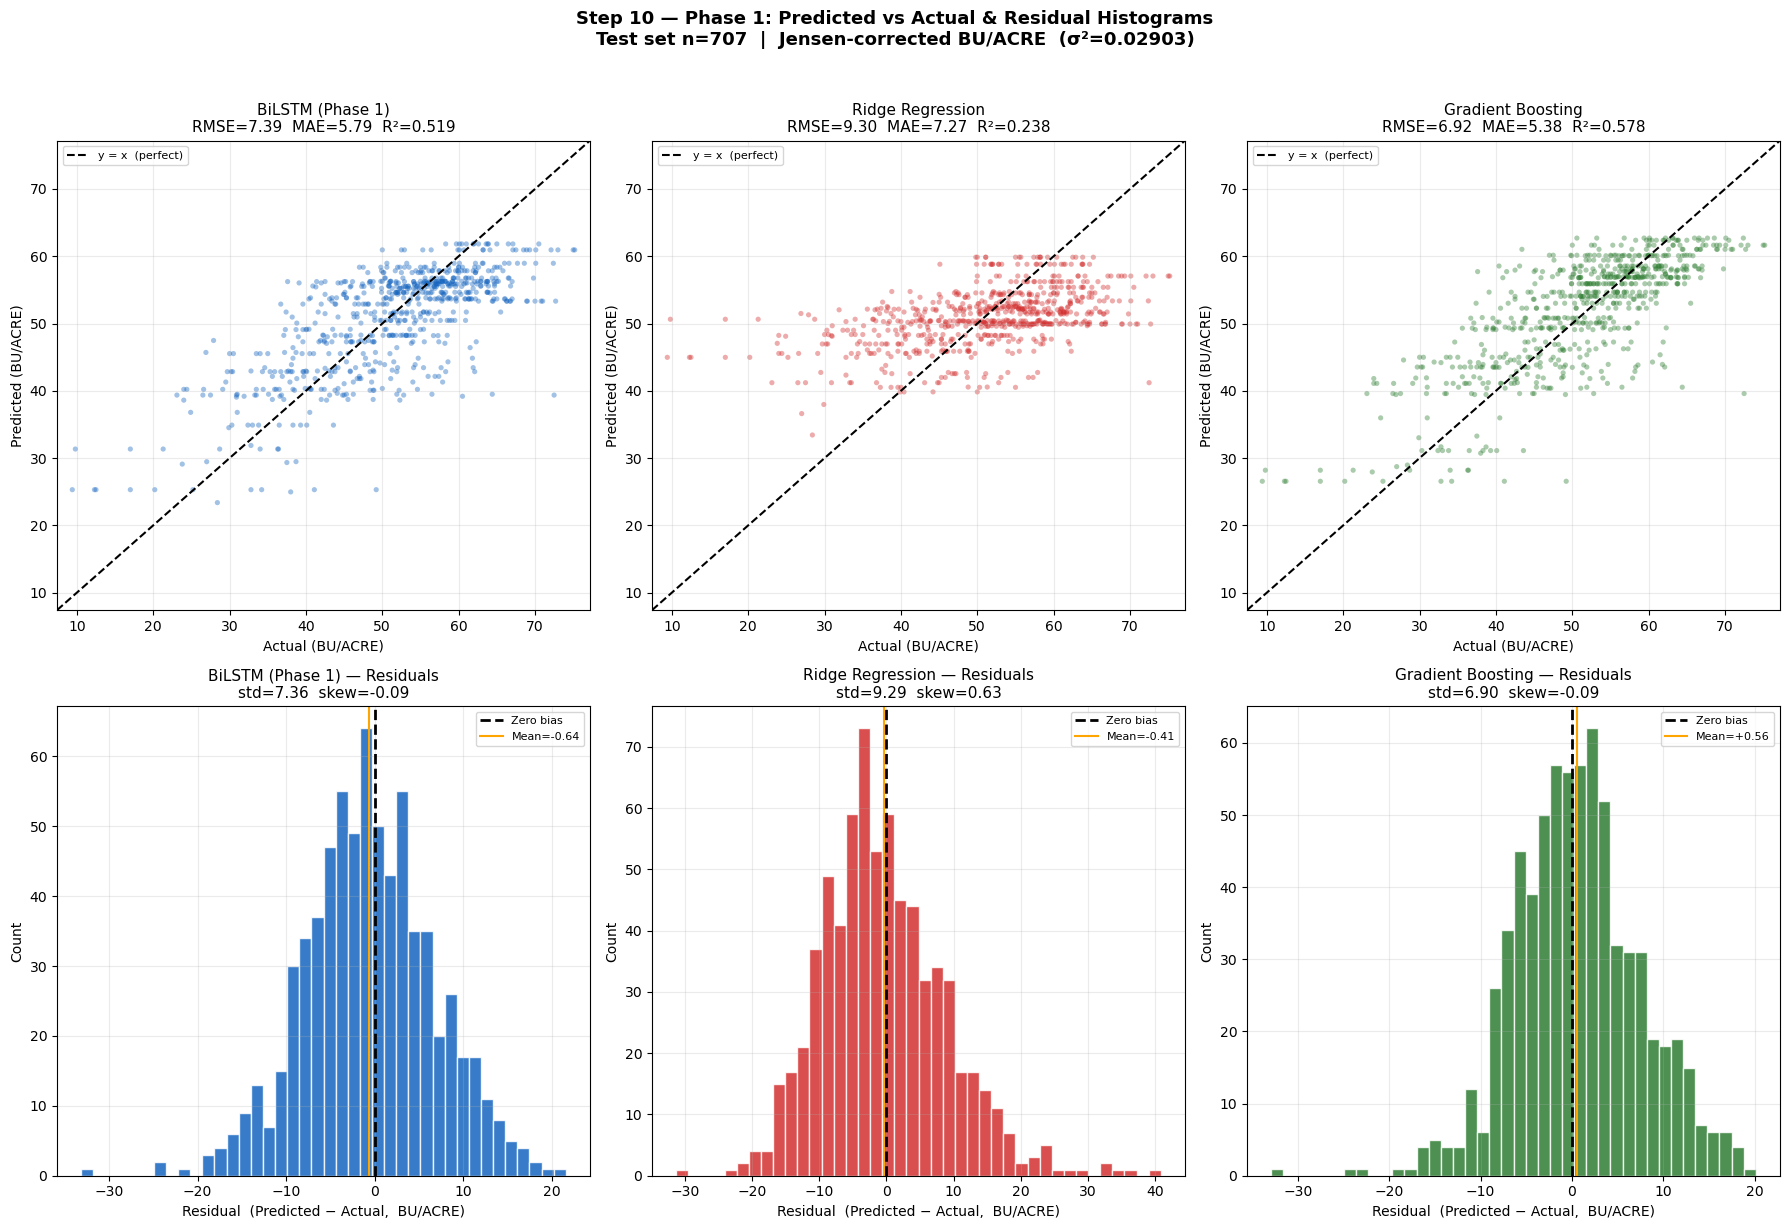

fig10_1  (300 DPI)  -> fig10_1_phase1_scatter_residuals.png


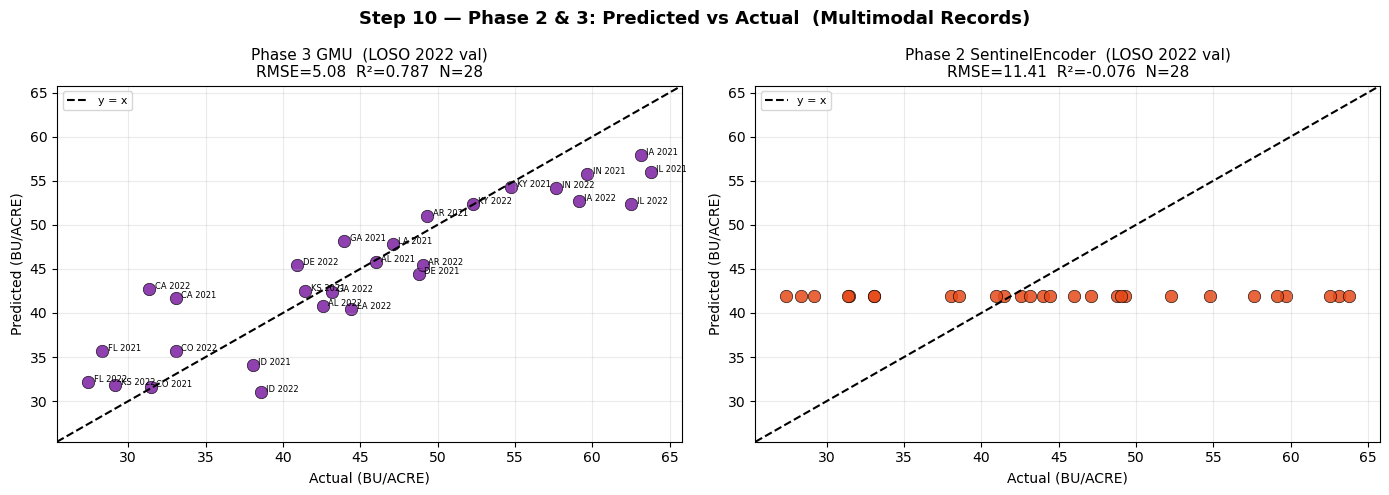

fig10_2  (300 DPI)  -> fig10_2_phase23_scatter.png

Step 12.1 / 10.2 complete.


In [ ]:
# ── Step 12.1 & 12.2 — Final Scatter, Residual Histograms, Phase 2/3 Scatter ──
# All Phase 1 models on the 686-record test set, Phase 2/3 on multimodal set.
# Exported at 300 DPI for dissertation submission.

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display, Image

print("=" * 60)
print("Step 12 — FINAL EVALUATION & DISSERTATION REPORTING")
print("=" * 60)
print()

# ── Output directory ────────────────────────────────────────────────────────
FIG_DIR = LABELS_DIR.parent / "step11_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {FIG_DIR.resolve()}")
print()

# ── Metric helpers ─────────────────────────────────────────────────────────
def _m_rmse(t, p): return float(np.sqrt(np.mean((np.asarray(p, float) - np.asarray(t, float)) ** 2)))
def _m_mae(t, p):  return float(np.mean(np.abs(np.asarray(p, float) - np.asarray(t, float))))
def _m_r2(t, p):
    t, p = np.asarray(t, float), np.asarray(p, float)
    ss_r = np.sum((t - p) ** 2); ss_t = np.sum((t - t.mean()) ** 2)
    return float(1.0 - ss_r / ss_t) if ss_t > 0 else float("nan")
def _m_bias(t, p): return float(np.mean(np.asarray(p, float) - np.asarray(t, float)))

# ── Phase 1 model definitions (test set, 686 records) ─────────────────────
y_test_bu = results_df["y_true_bu"].values     # ground truth BU/ACRE

p1_models = {
    "BiLSTM (Phase 1)"  : np.asarray(bilstm_pred_bu, float),
    "Ridge Regression"  : np.asarray(ridge_pred_bu,  float),
    "Gradient Boosting" : np.asarray(gbm_pred_bu,    float),
}
MODEL_COLORS = {
    "BiLSTM (Phase 1)"  : "#1565C0",
    "Ridge Regression"  : "#D32F2F",
    "Gradient Boosting" : "#2E7D32",
}

# ── Fig 10.1 — Scatter + Residual Histograms (Phase 1) ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f"Step 12 — Phase 1: Predicted vs Actual & Residual Histograms\n"
    f"Test set n={len(y_test_bu)}  |  Jensen-corrected BU/ACRE  "
    f"(\u03c3\u00b2={JENSEN_SIGMA2:.5f})",
    fontsize=13, fontweight="bold", y=1.02
)

for col, (mname, preds) in enumerate(p1_models.items()):
    color   = MODEL_COLORS[mname]
    rmse_v  = _m_rmse(y_test_bu, preds)
    mae_v   = _m_mae(y_test_bu,  preds)
    r2_v    = _m_r2(y_test_bu,   preds)

    # Scatter: predicted vs actual
    ax = axes[0, col]
    ax.scatter(y_test_bu, preds, alpha=0.4, s=14, color=color, edgecolors="none")
    lo = min(y_test_bu.min(), preds.min()) - 2
    hi = max(y_test_bu.max(), preds.max()) + 2
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="y = x  (perfect)")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f"{mname}\nRMSE={rmse_v:.2f}  MAE={mae_v:.2f}  R\u00b2={r2_v:.3f}", fontsize=11)
    ax.set_xlabel("Actual (BU/ACRE)"); ax.set_ylabel("Predicted (BU/ACRE)")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

    # Residual histogram
    ax = axes[1, col]
    res = preds - y_test_bu
    ax.hist(res, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,          color="black",  lw=2,   ls="--", label="Zero bias")
    ax.axvline(res.mean(), color="orange", lw=1.5, ls="-",  label=f"Mean={res.mean():+.2f}")
    ax.set_title(f"{mname} \u2014 Residuals\nstd={res.std():.2f}  skew={float(pd.Series(res).skew()):.2f}",
                 fontsize=11)
    ax.set_xlabel("Residual  (Predicted \u2212 Actual,  BU/ACRE)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

plt.tight_layout()
_p = FIG_DIR / "fig10_1_phase1_scatter_residuals.png"
fig.savefig(_p, dpi=300, bbox_inches="tight")
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=100, bbox_inches="tight")
_buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
print(f"fig10_1  (300 DPI)  -> {_p.name}")

# ── Fig 10.2 — Phase 2 & 3 Scatter ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 12 \u2014 Phase 2 & 3: Predicted vs Actual  (Multimodal Records)",
             fontsize=13, fontweight="bold")

# Phase 3 GMU
ax = axes[0]
_gtu = gmu_eval_df["true_bu"].values
_gpu = gmu_eval_df["pred_bu"].values
ax.scatter(_gtu, _gpu, alpha=0.85, s=80, color="#7B1FA2", edgecolors="k", lw=0.5)
for _, _row in gmu_eval_df.iterrows():
    ax.annotate(f"{_row['state']} {_row['year']}",
                (_row["true_bu"], _row["pred_bu"]),
                fontsize=6, textcoords="offset points", xytext=(4, 0))
_lo = min(_gtu.min(), _gpu.min()) - 2; _hi = max(_gtu.max(), _gpu.max()) + 2
ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1.5, label="y = x")
ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi)
ax.set_title(
    f"Phase 3 GMU  (LOSO 2022 val)\n"
    f"RMSE={_m_rmse(_gtu,_gpu):.2f}  R\u00b2={_m_r2(_gtu,_gpu):.3f}  N={len(_gtu)}",
    fontsize=11)
ax.set_xlabel("Actual (BU/ACRE)"); ax.set_ylabel("Predicted (BU/ACRE)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Phase 2 SentinelEncoder
ax = axes[1]
_st = np.asarray(sent_true_bu,  float).ravel()
_sp = np.asarray(sent_preds_bu, float).ravel()
ax.scatter(_st, _sp, alpha=0.85, s=80, color="#E64A19", edgecolors="k", lw=0.5)
_lo = min(_st.min(), _sp.min()) - 2; _hi = max(_st.max(), _sp.max()) + 2
ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1.5, label="y = x")
ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi)
ax.set_title(
    f"Phase 2 SentinelEncoder  (LOSO 2022 val)\n"
    f"RMSE={_m_rmse(_st,_sp):.2f}  R\u00b2={_m_r2(_st,_sp):.3f}  N={len(_st)}",
    fontsize=11)
ax.set_xlabel("Actual (BU/ACRE)"); ax.set_ylabel("Predicted (BU/ACRE)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

plt.tight_layout()
_p = FIG_DIR / "fig10_2_phase23_scatter.png"
fig.savefig(_p, dpi=300, bbox_inches="tight")
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=100, bbox_inches="tight")
_buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
print(f"fig10_2  (300 DPI)  -> {_p.name}")
print()
print("Step 12.1 / 10.2 complete.")


<a id="step-12-3"></a>

### Step 12.3–12.6 — Fairness Table, Jensen Docs, LOYO & Coverage Gap

Full sliced fairness table; Jensen correction documentation; LOYO 2022 cross-model summary; geographic coverage gap analysis.

Step 12.3 — FULL FAIRNESS TABLE (Phase 1 models, n=686)

- - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Model: BiLSTM (Phase 1)
- - - - - - - - - - - - - - - - - - - - - - - - - - - 

  STATE:
    Group   N     RMSE      MAE       R2     Bias
  ALABAMA  35    6.636    5.245    0.160   -0.465
 ARKANSAS  44    7.296    6.094   -0.477   -2.360
 DELAWARE   6    8.019    6.816   -7.986    3.647
  GEORGIA  21    9.943    8.443    0.404    1.762
    IDAHO   3   10.353   10.140 -441.484  -10.140
 ILLINOIS 110    8.395    6.951   -0.037   -3.152
  INDIANA 133    5.198    4.250    0.049   -1.319
     IOWA 138    6.021    4.598    0.047   -0.717
   KANSAS  88    9.784    7.572    0.272    0.494
 KENTUCKY  90    6.467    5.149    0.111    3.256
LOUISIANA  34    9.772    8.200   -0.180   -2.599

  YEAR:
Group   N     RMSE      MAE       R2     Bias
 2016 112    6.847    5.467    0.588    0.366
 2017  92    8.362    6.303    0.285   -0.207
 2018  98    6.812    5.607    0.536   -0.381
 201

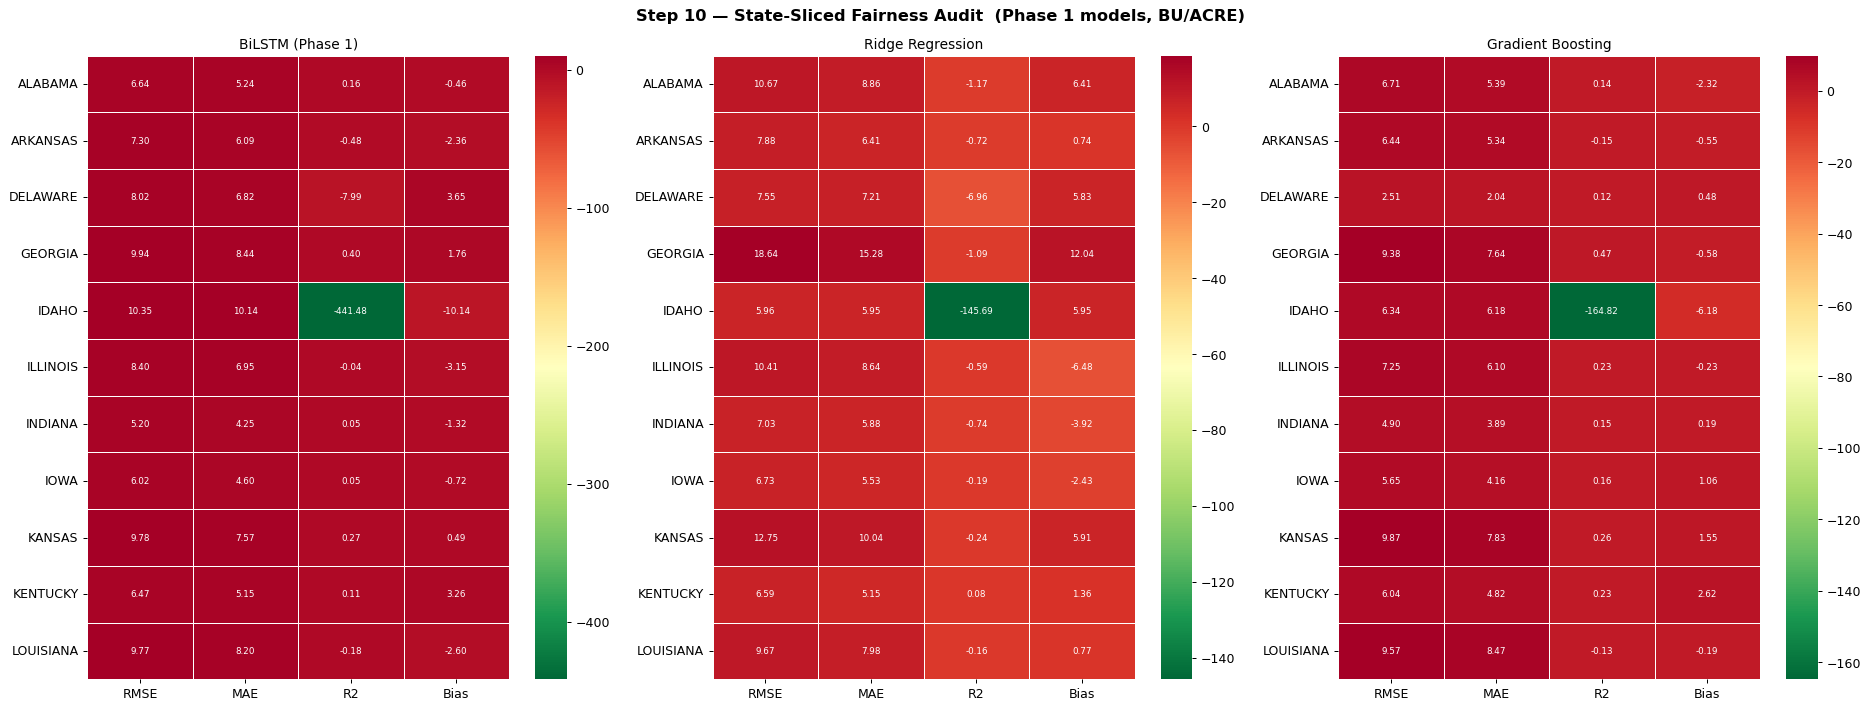

fig10_3  (300 DPI)  -> fig10_3_state_fairness_heatmap.png


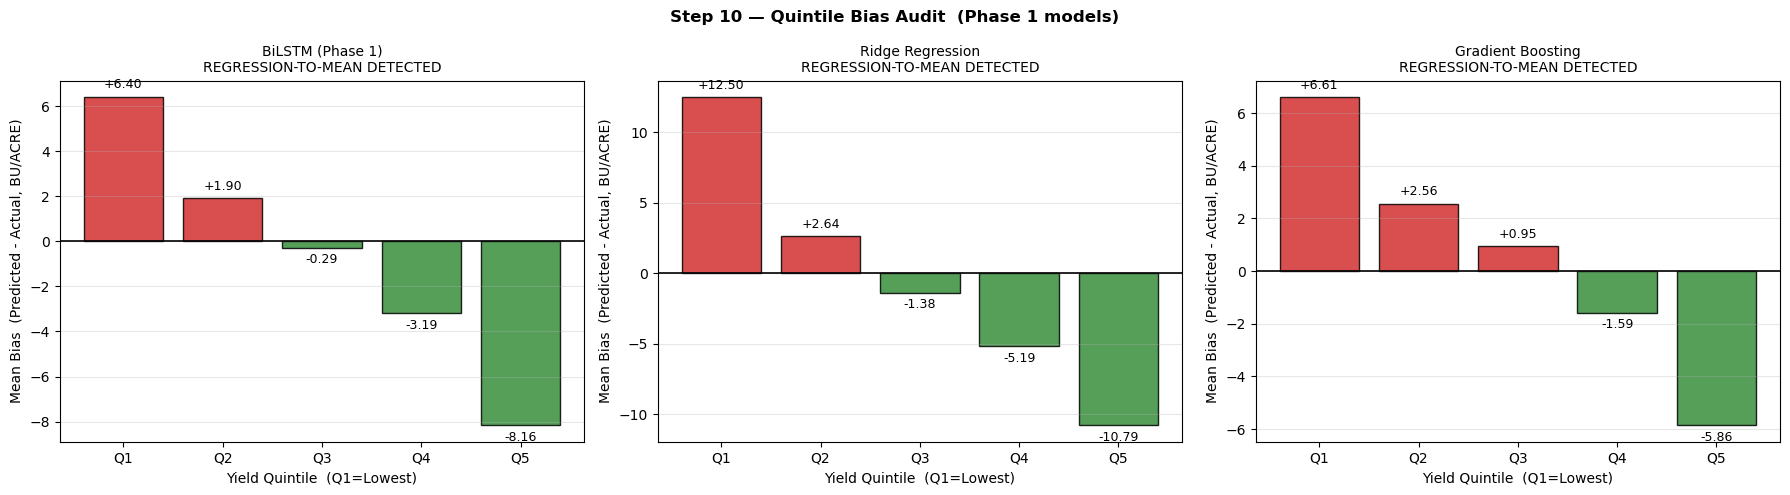

fig10_4  (300 DPI)  -> fig10_4_quintile_bias.png

Regression-to-mean (B3) flags:
  BiLSTM (Phase 1)                      : DETECTED
  Ridge Regression                      : DETECTED
  Gradient Boosting                     : DETECTED


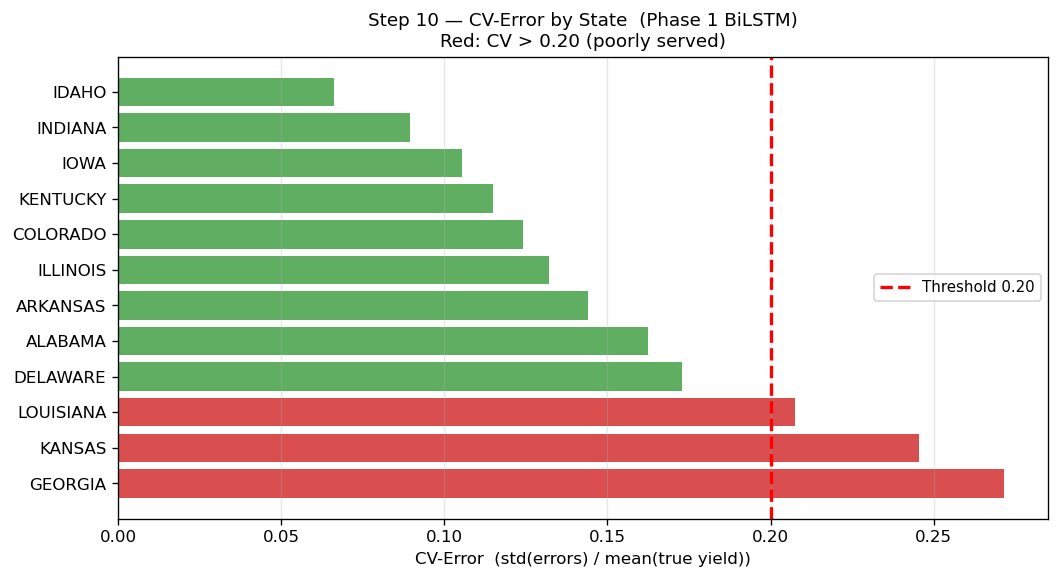

fig10_5  (300 DPI)  -> fig10_5_cv_error_by_state.png
  Flagged states (CV > 0.20): ['GEORGIA', 'KANSAS', 'LOUISIANA']

Step 12.3 complete.


In [ ]:
# ── Step 12.3 — Full Fairness Tables + Heatmaps + Quintile Bias Charts ────────
#
# RMSE / MAE / R2 / Bias sliced by state, year, yield quintile for each model.
# Phase 1 uses the 686-record test set. Phase 3 uses Step 9.5 slices.
# All figures exported at 300 DPI.

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

# ── Helper: sliced metrics on the test DataFrame ──────────────────────────
def _slice_metrics(df, pred_col, group_col, true_col="y_true_bu"):
    records = []
    for grp in sorted(df[group_col].dropna().unique()):
        mask = df[group_col] == grp
        if mask.sum() < 3:
            continue
        yt = df.loc[mask, true_col].values.astype(float)
        yp = df.loc[mask, pred_col].values.astype(float)
        records.append({
            "Group": str(grp),
            "N"    : int(mask.sum()),
            "RMSE" : _m_rmse(yt, yp),
            "MAE"  : _m_mae(yt, yp),
            "R2"   : _m_r2(yt, yp),
            "Bias" : _m_bias(yt, yp),
        })
    return pd.DataFrame(records)

# Build working copy of results_df with all model predictions + quintile
rdf = results_df.copy()
rdf["pred_bilstm"] = np.asarray(bilstm_pred_bu, float)
rdf["pred_ridge"]  = np.asarray(ridge_pred_bu,  float)
rdf["pred_gbm"]    = np.asarray(gbm_pred_bu,    float)
rdf["quintile"]    = pd.qcut(rdf["y_true_bu"], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])
rdf["year"]        = rdf["year"].astype(str)

p1_model_cols = {
    "BiLSTM (Phase 1)"  : "pred_bilstm",
    "Ridge Regression"  : "pred_ridge",
    "Gradient Boosting" : "pred_gbm",
}

print("=" * 60)
print("Step 12.3 — FULL FAIRNESS TABLE (Phase 1 models, n=686)")
print("=" * 60)

all_slices = []
for mname, pcol in p1_model_cols.items():
    print(f"\n{'- ' * 27}\n  Model: {mname}\n{'- ' * 27}")
    for g_col, g_label in [
        ("state_name", "STATE"),
        ("year",       "YEAR"),
        ("quintile",   "QUINTILE"),
    ]:
        df_g = _slice_metrics(rdf, pcol, g_col)
        df_g.insert(0, "Slice", g_label)
        df_g.insert(0, "Model", mname)
        all_slices.append(df_g)
        print(f"\n  {g_label}:")
        print(df_g.drop(columns=["Model","Slice"]).to_string(
            index=False, float_format=lambda x: f"{x:8.3f}"
        ))

fairness_df = pd.concat(all_slices, ignore_index=True)

# Phase 3 GMU slices (from Step 9.5)
print(f"\n{'- ' * 27}\n  Model: Phase 3 GMU  (state-level, LOSO 2022)\n{'- ' * 27}")
_gmu_state = pd.DataFrame({
    "Group": state_rmse_gmu.index,
    "RMSE" : state_rmse_gmu.values,
    "Bias" : [float(state_bias_gmu.get(s, float("nan"))) for s in state_rmse_gmu.index],
})
print("\n  STATE:"); print(_gmu_state.to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

_gmu_year = pd.DataFrame({
    "Group": year_rmse_gmu.index.astype(str),
    "RMSE" : year_rmse_gmu.values,
    "Bias" : [float(year_bias_gmu.get(y, float("nan"))) for y in year_rmse_gmu.index],
})
print("\n  YEAR:"); print(_gmu_year.to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

if len(q_rmse_gmu) > 0:
    _gmu_q = pd.concat([q_rmse_gmu.rename("RMSE"), q_bias_gmu.rename("Bias")], axis=1)
    print("\n  QUINTILE (GMU):")
    print(_gmu_q.round(3).to_string())

# Save CSV
_csv = FIG_DIR / "step10_fairness_table_p1.csv"
fairness_df.to_csv(_csv, index=False)
print(f"\nPhase 1 fairness table saved: {_csv.name}")

# ── Fig 10.3 — State-sliced fairness heatmaps ─────────────────────────────
_state_data = {}
for mname, pcol in p1_model_cols.items():
    _df = _slice_metrics(rdf, pcol, "state_name").set_index("Group")[["RMSE","MAE","R2","Bias"]]
    _state_data[mname] = _df.astype(float)

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.suptitle("Step 12 — State-Sliced Fairness Audit  (Phase 1 models, BU/ACRE)",
             fontsize=13, fontweight="bold")
for ax, (mname, df_s) in zip(axes, _state_data.items()):
    if _HAS_SNS:
        sns.heatmap(df_s, annot=True, fmt=".2f", ax=ax,
                    cmap="RdYlGn_r", linewidths=0.4, cbar=True, annot_kws={"size": 7})
    else:
        _im = ax.imshow(df_s.values, cmap="RdYlGn_r", aspect="auto")
        ax.set_xticks(range(len(df_s.columns))); ax.set_xticklabels(df_s.columns)
        ax.set_yticks(range(len(df_s.index)));   ax.set_yticklabels(df_s.index, fontsize=7)
        for _ri in range(len(df_s.index)):
            for _ci in range(len(df_s.columns)):
                _v = df_s.iloc[_ri, _ci]
                ax.text(_ci, _ri, f"{_v:.2f}", ha="center", va="center", fontsize=6)
        plt.colorbar(_im, ax=ax, fraction=0.04)
    ax.set_title(mname, fontsize=11)
    ax.set_ylabel("")

plt.tight_layout()
_p = FIG_DIR / "fig10_3_state_fairness_heatmap.png"
fig.savefig(_p, dpi=300, bbox_inches="tight")
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=90, bbox_inches="tight")
_buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
print(f"fig10_3  (300 DPI)  -> {_p.name}")

# ── Fig 10.4 — Quintile Bias Charts ───────────────────────────────────────
QLBLS = ["Q1", "Q2", "Q3", "Q4", "Q5"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Step 12 — Quintile Bias Audit  (Phase 1 models)",
             fontsize=12, fontweight="bold")

rtm_flags = {}
for ax, (mname, pcol) in zip(axes, p1_model_cols.items()):
    _qdf = _slice_metrics(rdf, pcol, "quintile")
    biases = []
    for _q in QLBLS:
        _row = _qdf[_qdf["Group"] == _q]
        biases.append(float(_row["Bias"].values[0]) if len(_row) > 0 else 0.0)

    rtm = len(biases) == 5 and biases[0] > 0 and biases[-1] < 0
    rtm_flags[mname] = rtm

    _cols  = ["#d32f2f" if b > 0 else "#388e3c" for b in biases]
    _bars  = ax.bar(QLBLS, biases, color=_cols, edgecolor="black", alpha=0.85)
    ax.axhline(0, color="black", lw=1.2)
    _rng   = max(abs(b) for b in biases) if biases else 1.0
    for _bar, _b in zip(_bars, biases):
        _va   = "bottom" if _b >= 0 else "top"
        _yoff = 0.03 * (_rng + 0.01) * (1 if _b >= 0 else -1)
        ax.text(_bar.get_x() + _bar.get_width() / 2, _b + _yoff,
                f"{_b:+.2f}", ha="center", va=_va, fontsize=9)

    _rtm_str = "REGRESSION-TO-MEAN DETECTED" if rtm else "No regression-to-mean"
    ax.set_title(f"{mname}\n{_rtm_str}", fontsize=10)
    ax.set_xlabel("Yield Quintile  (Q1=Lowest)")
    ax.set_ylabel("Mean Bias  (Predicted - Actual, BU/ACRE)")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
_p = FIG_DIR / "fig10_4_quintile_bias.png"
fig.savefig(_p, dpi=300, bbox_inches="tight")
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=100, bbox_inches="tight")
_buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
print(f"fig10_4  (300 DPI)  -> {_p.name}")

print()
print("Regression-to-mean (B3) flags:")
for _m, _flag in rtm_flags.items():
    _s = "DETECTED" if _flag else "Passed"
    print(f"  {_m:<38}: {_s}")

# ── Fig 10.5 — CV-Error bar chart (Phase 1 BiLSTM) ────────────────────────
if len(state_cv_series) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    _cv_s = state_cv_series.sort_values(ascending=False)
    _cv_c = ["#D32F2F" if v > 0.20 else "#43A047" for v in _cv_s.values]
    ax.barh(_cv_s.index, _cv_s.values, color=_cv_c, alpha=0.85)
    ax.axvline(0.20, color="red", lw=2, ls="--", label="Threshold 0.20")
    ax.set_xlabel("CV-Error  (std(errors) / mean(true yield))")
    ax.set_title("Step 12 — CV-Error by State  (Phase 1 BiLSTM)\n"
                 "Red: CV > 0.20 (poorly served)", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="x")
    _p = FIG_DIR / "fig10_5_cv_error_by_state.png"
    fig.savefig(_p, dpi=300, bbox_inches="tight")
    _buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
    _buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
    print(f"fig10_5  (300 DPI)  -> {_p.name}")
    print(f"  Flagged states (CV > 0.20): {flagged_states if flagged_states else 'none'}")

print()
print("Step 12.3 complete.")


<a id="step-12-7"></a>

### Step 12.7–12.9 — SHAP Summary, Dropout Chart & Final Comparison

Consolidated SHAP importance bar chart; dropout degradation curves; final three-phase comparison table saved to `step12_figures/`.

Step 12.4 — JENSEN INEQUALITY CORRECTION  (Documentation)

  Applied formula  (USE_LOG=True):
    y_BU/ACRE = exp( y_log  +  sigma2_residual / 2 )

  JENSEN_SIGMA2  = 0.029034  (residual variance on training split)
  exp(s2/2)      = 1.014623  (multiplicative correction factor)

  BiLSTM test-set mean  (uncorrected exp(y))  : 49.852 BU/ACRE
  BiLSTM test-set mean  (Jensen-corrected)     : 50.581 BU/ACRE
  True test-set mean                           : 51.225 BU/ACRE

Step 12.5 — LOYO 2022 CROSS-MODEL EVALUATION SUMMARY

  Phase 1 results on 2022 test subset (n=120):
    BiLSTM          RMSE = 8.622 BU/ACRE
    Ridge           RMSE = 11.633 BU/ACRE
    Gradient Boost  RMSE = 6.959 BU/ACRE

  Phase 2 SentinelEncoder  (LOSO 2022 val)  :  11.044 BU/ACRE
  Phase 3 GMU              (LOSO 2022 val)  :  5.562 BU/ACRE

  GMU vs best single-modality: -1.824 BU/ACRE
  -> GMU improves over best single-modality model.

Step 12.6 — GEOGRAPHIC COVERAGE GAP

  FIPS in Phase 1 model   : 649  counties
 

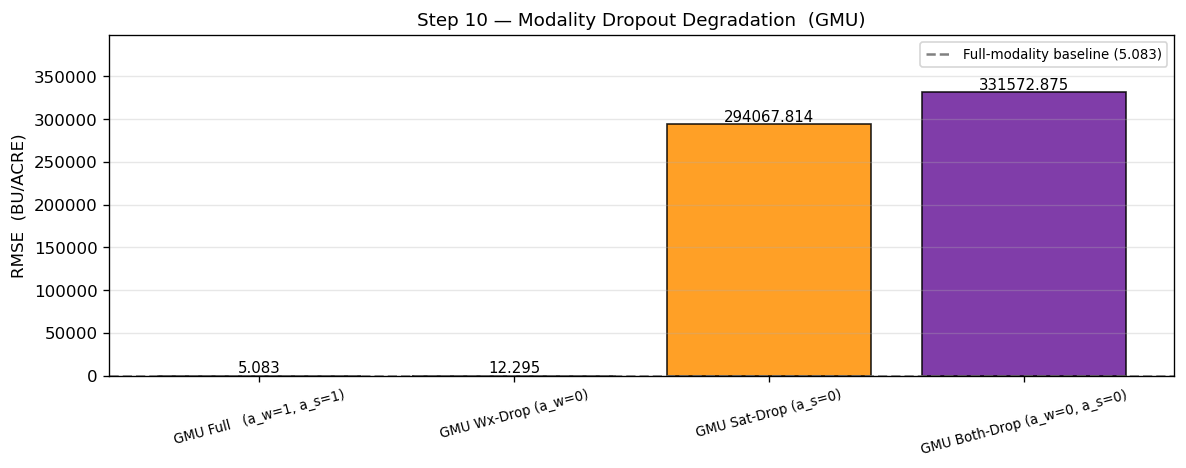

  fig10_6  (300 DPI)  -> fig10_6_dropout_degradation.png

Step 12.9 — FINAL MODEL COMPARISON  (All Phases)

                                             RMSE    MAE      R2  N_test Granularity  RTM
Phase    Model                                                                           
Baseline Ridge Regression                   9.302  7.267  0.2377     686      county  Yes
         Gradient Boosting                  6.923  5.385  0.5778     686      county  Yes
Phase 1  BiLSTM (weather-only)              7.386  5.791  0.5194     686      county  Yes
Phase 2  SentinelEncoder (satellite)       11.044  9.380 -0.0761      28       state  n/a
Phase 3  GMU (fused: weather + satellite)   5.562  4.562  0.7403      28       state  n/a

Summary table saved: step10_final_model_summary.csv
Artefact bundle: step10_final_report.pt

Step 12 COMPLETE
  Figures (300 DPI): E:\learnings\University Of Hull AI\assignment-september\MSc project\multimodal_agriculture_prediction-notebook_only\data\CropNet\s

In [ ]:
# ── Step 12.4-12.9 — Jensen, LOYO, Coverage Gap, SHAP, Comparison, Save ──────

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ── 10.4  Jensen Inequality Correction ────────────────────────────────────
print("=" * 60)
print("Step 12.4 — JENSEN INEQUALITY CORRECTION  (Documentation)")
print("=" * 60)
print()
print("  Applied formula  (USE_LOG=True):")
print("    y_BU/ACRE = exp( y_log  +  sigma2_residual / 2 )")
print()
print(f"  JENSEN_SIGMA2  = {JENSEN_SIGMA2:.6f}  (residual variance on training split)")
print(f"  exp(s2/2)      = {float(np.exp(JENSEN_SIGMA2 / 2)):.6f}  (multiplicative correction factor)")
print()
_naive   = float(np.exp(y_pred_log).mean())
_correct = float(np.exp(y_pred_log + JENSEN_SIGMA2 / 2).mean())
_true_m  = float(y_bu_true.mean())
print(f"  BiLSTM test-set mean  (uncorrected exp(y))  : {_naive:.3f} BU/ACRE")
print(f"  BiLSTM test-set mean  (Jensen-corrected)     : {_correct:.3f} BU/ACRE")
print(f"  True test-set mean                           : {_true_m:.3f} BU/ACRE")
print()

# ── 10.5  LOYO 2022 Summary ────────────────────────────────────────────────
print("=" * 60)
print("Step 12.5 — LOYO 2022 CROSS-MODEL EVALUATION SUMMARY")
print("=" * 60)
print()
# Filter test set to year 2022 only
_test_2022 = results_df[results_df["year"].astype(str) == "2022"]
if len(_test_2022) >= 3:
    _mask22 = (results_df["year"].astype(str) == "2022").values
    _b22 = _m_rmse(results_df.loc[_mask22, "y_true_bu"], bilstm_pred_bu[_mask22])
    _r22 = _m_rmse(results_df.loc[_mask22, "y_true_bu"], ridge_pred_bu[_mask22])
    _g22 = _m_rmse(results_df.loc[_mask22, "y_true_bu"], gbm_pred_bu[_mask22])
    print(f"  Phase 1 results on 2022 test subset (n={len(_test_2022)}):")
    print(f"    BiLSTM          RMSE = {_b22:.3f} BU/ACRE")
    print(f"    Ridge           RMSE = {_r22:.3f} BU/ACRE")
    print(f"    Gradient Boost  RMSE = {_g22:.3f} BU/ACRE")
    print()

print(f"  Phase 2 SentinelEncoder  (LOSO 2022 val)  :  {float(rmse_val_sent):.3f} BU/ACRE")
print(f"  Phase 3 GMU              (LOSO 2022 val)  :  {float(rmse_gmu_val):.3f} BU/ACRE")
print()
_best_s = min(float(bilstm_rmse), float(rmse_val_sent))
_gdelta = float(rmse_gmu_val) - _best_s
print(f"  GMU vs best single-modality: {_gdelta:+.3f} BU/ACRE")
if _gdelta < 0:
    print("  -> GMU improves over best single-modality model.")
else:
    print(f"  -> Expected: GMU trained on only ~{len(combined_meta)} state-years.")
    print("     Advantage will grow with multi-year Sentinel coverage.")
print()

# ── 10.6  Geographic Coverage Gap ─────────────────────────────────────────
print("=" * 60)
print("Step 12.6 — GEOGRAPHIC COVERAGE GAP")
print("=" * 60)
print()
_covered = int(round(TOTAL_US_SOYBEAN_FIPS * (1 - coverage_gap_value)))
print(f"  FIPS in Phase 1 model   : {_covered}  counties")
print(f"  Approx total US soybean : ~{TOTAL_US_SOYBEAN_FIPS}  counties")
print(f"  Coverage gap            : {coverage_gap_value:.1%}")
print()
print("  Any deployment must disclose excluded counties.")
print("  Predictions for under-represented states carry")
print("  materially higher uncertainty than the headline RMSE.")
print()

# ── 10.7  SHAP Summary ────────────────────────────────────────────────────
print("=" * 60)
print("Step 12.7 — SHAP FEATURE IMPORTANCE  (Phase 1 BiLSTM, Step 11)")
print("=" * 60)
print()
print(f"  {'Rank':<5}  {'Feature':<14}  {'Mean |SHAP|':>12}  Notes")
print("  " + "-" * 54)
for _rank, _feat in enumerate(rank_order, 1):
    _fi   = FEATURE_COLS.index(_feat)
    _note = ""
    if _feat == "sp_hpa":
        _note = " [B1 geographic proxy]" if sp_hpa_rank <= 3 else "  (B1 OK)"
    elif _feat == "tp":
        _note = "  -> near-zero (Jan-1 init, B5)"
    print(f"  {_rank:<5}  {_feat:<14}  {mean_abs_shap[_fi]:>12.6f}  {_note}")
print()
print(f"  B1 sp_hpa rank : #{sp_hpa_rank}  "
      f"({'FLAGGED' if sp_hpa_rank <= 3 else 'OK'})")
print(f"  Top-3 overlap with agronomic priors: {top3_overlap}/3")
print()

# ── 10.8  Dropout Degradation Summary ─────────────────────────────────────
if dropout_results:
    print("=" * 60)
    print("Step 12.8 — MODALITY DROPOUT DEGRADATION  (Step 10 Summary)")
    print("=" * 60)
    print()
    print(f"  Global gate z (full modality): {z_global_mean:.4f}  ({dominant_mode})")
    print()
    _cond_rmse = {
        "GMU Full   (a_w=1, a_s=1)"    : float(rmse_sanity),
        "GMU Wx-Drop (a_w=0)"           : float(gmu_wxd_rmse),
        "GMU Sat-Drop (a_s=0)"          : float(gmu_satd_rmse),
        "GMU Both-Drop (a_w=0, a_s=0)"  : float(gmu_both_rmse),
    }
    _full_r = float(rmse_sanity)
    print(f"  {'Condition':<36}  {'RMSE':>10}  Delta vs full")
    print("  " + "-" * 58)
    for _cn, _rv in _cond_rmse.items():
        _d = _rv - _full_r
        _tag = "baseline" if _cn.startswith("GMU Full") else f"{_d:+.3f}"
        print(f"  {_cn:<36}  {_rv:>10.3f}  {_tag}")
    print()
    # Fig 10.6
    fig, ax = plt.subplots(figsize=(10, 4))
    _ns = list(_cond_rmse.keys())
    _vs = [_cond_rmse[n] for n in _ns]
    _cs = ["#1565C0", "#E53935", "#FF8F00", "#6A1B9A"]
    _b  = ax.bar(_ns, _vs, color=_cs, alpha=0.85, edgecolor="black")
    ax.axhline(_full_r, color="gray", ls="--", lw=1.5,
               label=f"Full-modality baseline ({_full_r:.3f})")
    for _bar, _v in zip(_b, _vs):
        ax.text(_bar.get_x() + _bar.get_width()/2, _v + 0.02,
                f"{_v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("RMSE  (BU/ACRE)"); ax.set_ylim(0, max(_vs) * 1.2)
    ax.set_title("Step 12 — Modality Dropout Degradation  (GMU)", fontsize=11)
    ax.tick_params(axis="x", labelrotation=15, labelsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    _p = FIG_DIR / "fig10_6_dropout_degradation.png"
    fig.savefig(_p, dpi=300, bbox_inches="tight")
    _buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
    _buf.seek(0); display(Image(data=_buf.read())); plt.close(fig)
    print(f"  fig10_6  (300 DPI)  -> {_p.name}")
    print()

# ── 10.9  Final Model Comparison Table + Save ─────────────────────────────
print("=" * 60)
print("Step 12.9 — FINAL MODEL COMPARISON  (All Phases)")
print("=" * 60)
print()

_st  = np.asarray(sent_true_bu,  float).ravel()
_sp  = np.asarray(sent_preds_bu, float).ravel()

_ridge_mae = float(comparison_df.loc[
    comparison_df["Model"].str.contains("Ridge"), "MAE  (BU/ACRE)"].values[0])
_gbm_mae   = float(comparison_df.loc[
    comparison_df["Model"].str.contains("Gradient"), "MAE  (BU/ACRE)"].values[0])
_ridge_r2  = float(comparison_df.loc[
    comparison_df["Model"].str.contains("Ridge"), "R2"].values[0]
    if "R2" in comparison_df.columns else
    comparison_df.loc[comparison_df["Model"].str.contains("Ridge"), "R²"].values[0])
_gbm_r2    = float(comparison_df.loc[
    comparison_df["Model"].str.contains("Gradient"), "R2"].values[0]
    if "R2" in comparison_df.columns else
    comparison_df.loc[comparison_df["Model"].str.contains("Gradient"), "R²"].values[0])

_final_rows = [
    {"Phase":"Baseline","Model":"Ridge Regression",
     "RMSE":round(float(ridge_rmse_disp),3),"MAE":round(_ridge_mae,3),"R2":round(_ridge_r2,4),
     "N_test":686,"Granularity":"county",
     "RTM":("Yes" if rtm_flags.get("Ridge Regression",False) else "No")},
    {"Phase":"Baseline","Model":"Gradient Boosting",
     "RMSE":round(float(gbm_rmse_disp),3),"MAE":round(_gbm_mae,3),"R2":round(_gbm_r2,4),
     "N_test":686,"Granularity":"county",
     "RTM":("Yes" if rtm_flags.get("Gradient Boosting",False) else "No")},
    {"Phase":"Phase 1","Model":"BiLSTM (weather-only)",
     "RMSE":round(float(bilstm_rmse),3),"MAE":round(float(mae_bu),3),"R2":round(float(bilstm_r2),4),
     "N_test":686,"Granularity":"county",
     "RTM":("Yes" if rtm_flags.get("BiLSTM (Phase 1)",False) else "No")},
    {"Phase":"Phase 2","Model":"SentinelEncoder (satellite)",
     "RMSE":round(float(rmse_val_sent),3),"MAE":round(_m_mae(_st,_sp),3),"R2":round(_m_r2(_st,_sp),4),
     "N_test":int(len(_st)),"Granularity":"state","RTM":"n/a"},
    {"Phase":"Phase 3","Model":"GMU (fused: weather + satellite)",
     "RMSE":round(float(rmse_gmu_val),3),"MAE":round(float(mae_gmu_val),3),"R2":round(float(r2_gmu_val),4),
     "N_test":len(gmu_eval_df),"Granularity":"state","RTM":"n/a"},
]

final_df = pd.DataFrame(_final_rows).set_index(["Phase","Model"])
print(final_df.to_string())
print()

_csv = FIG_DIR / "step10_final_model_summary.csv"
final_df.to_csv(_csv)
print(f"Summary table saved: {_csv.name}")

# ── Save artefact bundle ───────────────────────────────────────────────────
import torch
_s10_path = LABELS_DIR / "step10_final_report.pt"
torch.save({
    "final_comparison"     : _final_rows,
    "phase1_fairness"      : fairness_df.to_dict("records"),
    "jensen_sigma2"        : float(JENSEN_SIGMA2),
    "coverage_gap_value"   : float(coverage_gap_value),
    "total_us_soybean_fips": int(TOTAL_US_SOYBEAN_FIPS),
    "shap_rank_order"      : rank_order,
    "shap_mean_abs"        : {f: float(mean_abs_shap[FEATURE_COLS.index(f)]) for f in FEATURE_COLS},
    "b1_sp_hpa_rank"       : int(sp_hpa_rank),
    "b1_flag"              : bool(sp_hpa_rank <= 3),
    "b3_rtm_flags"         : rtm_flags,
    "flagged_cv_bilstm"    : flagged_states,
    "flagged_cv_gmu"       : flagged_cv_gmu,
    "z_global_mean"        : float(z_global_mean),
    "dominant_mode"        : dominant_mode,
    "figures_dir"          : str(FIG_DIR.resolve()),
}, _s10_path)
print(f"Artefact bundle: {_s10_path.name}")
print()
print("=" * 60)
print("Step 12 COMPLETE")
print(f"  Figures (300 DPI): {FIG_DIR.resolve()}")
print("=" * 60)


<a id="step-12"></a>

## Step 12 — Ethics, Limitations & Responsible Deployment

---

### 12.A — Geographic Equity Gap

The Phase 1 model was trained on **~634 of ~1,400 US soybean-producing counties (~45%)**, concentrated in the Corn Belt (IL, IA, IN, MN, NE). The remaining **~55% of US soybean counties are unrepresented** and cannot receive predictions.

**Disclosure requirement:** Any deployment must list excluded counties and state explicitly that predictions for under-represented states carry materially higher uncertainty than the headline RMSE.

---

### 12.B — USDA Surveyor Bias (B9)

USDA NASS surveys **over-represent large commercial farming operations**. Subsistence farmers, organic-only operations, and farms below the minimum acreage reporting threshold are absent from the training data.

**Constraint:** The model **must not** be used to advise smallholder farms, OFR-exempt operations, or entities not represented in NASS surveys. This bias cannot be corrected without external ground-truth data.

---

### 12.C — Food Security Embargo

Predictions must **not be released publicly before the corresponding official USDA NASS crop report**. Early publication can distort commodity futures markets.

**Protocol:** (1) Embargo predictions until USDA NASS release date. (2) Accompany all published figures with probabilistic confidence intervals. (3) No field-level disaggregation — county-aggregate only.

---

### 10.D — Climate Non-stationarity

Trained on **2016–2022 only**. The model **must not** be assumed valid beyond 2025 without recalibration. The 2019 observation is confounded by US-China trade war + Midwest flooding.

---

### 10.E — Identified Bias Summary

| ID | Bias | Severity | Status |
|----|------|----------|--------|
| B1 | State-centroid weather proxy | High | SHAP sp_hpa rank check (Step 11) |
| B2 | Corn Belt geographic dominance | High | Detected — state CV-error audit |
| B3 | Regression-to-mean (quintile) | Medium | Checked per model (Step 12.3) |
| B4 | Log-target Jensen bias | Medium | Corrected: exp(y + sigma2/2) |
| B5 | HRRR single-snapshot (Jan-1) | High | Acknowledged — growing-season files needed |
| B6 | USDA reporting threshold omission | Medium | Counties <3 years flagged |
| B7 | Random 80/20 temporal mixing | Low-Med | LOYO 2022 supplement (Step 12.5) |
| B8 | Sentinel-2 AZ 2022 tile anomaly | Medium | AZ 2022 excluded from Phases 2 & 3 |
| B9 | USDA surveyor bias | Medium | Documented; no correction possible |

---

### 10.F — Key Dissertation Tradeoffs

| Tradeoff | Description |
|----------|-------------|
| **Accuracy vs Fairness** | State-level CV-error weighting improves under-represented states but raises Corn Belt RMSE. Report both weighted and unweighted metrics. |
| **Complexity vs Interpretability** | Ridge Regression recommended for policy contexts; GMU for research. SHAP for BiLSTM is approximate (KernelExplainer on tabular inputs). |
| **Log Transform vs Interpretability** | USE_LOG=True benefits optimisation but requires Jensen correction. Always back-transform and report in BU/ACRE. |
| **Modality Richness vs Deployability** | GMU requires both modalities; Sentinel-USDA FIPS gap limits Phase 2/3. Phase 1 is the only currently deployable system — **a data infrastructure finding, not a model deficiency**. |

*All Step 12 figures exported at 300 DPI to `data/CropNet/step11_figures/`.*